# **Atmospheric Sensitivity to Solar Forcing Mini-project using SpeedyWeather.jl**

**Understanding how solar variability impacts climate is an important part of Sun–Earth connection research.**

In [ ]:
## python
# Install Julia
!pip install julia
!curl -fsSL https://install.julialang.org | sh -s -- -y
!ln -s /root/.juliaup/bin/julia /usr/local/bin/julia

# Install SpeedyWeather
!julia -e 'using Pkg; Pkg.add("SpeedyWeather"); Pkg.add("Plots")'




Streaming output truncated to the last 5000 lines.
  ◑ aws_c_auth_jll
  Progress [===============================>         ]  62/82
  ◐ JLD2
  ◐ FFTW
  ◒ aws_c_auth_jll
  Progress [===============================>         ]  62/82
  ◓ JLD2
  ◓ FFTW
  ◐ aws_c_auth_jll
  Progress [===============================>         ]  62/82
  ◑ JLD2
  ◑ FFTW
  ◓ aws_c_auth_jll
  Progress [===============================>         ]  62/82
  ◒ JLD2
  ◒ FFTW
  ◑ aws_c_auth_jll
  Progress [===============================>         ]  62/82
  ◐ JLD2
  ◐ FFTW
  ◒ aws_c_auth_jll
  Progress [===============================>         ]  63/82
  ◓ JLD2
  ◓ FFTW
  ✓ aws_c_auth_jll
  ◑ SpeedyWeatherInternals
  Progress [===============================>         ]  63/82
  ◑ JLD2
  ◑ FFTW
  ✓ aws_c_auth_jll
  ◒ SpeedyWeatherInternals
  Progress [===============================>         ]  63/82
  ◒ JLD2
  ◒ FFTW
  ✓ aws_c_auth_jll
  ◐ SpeedyWeatherInternals
  Progress [===============================>         ]  6

# **1. Baseline Atmospheric Temperature Distribution**

**Global near-surface temperature under standard solar forcing (control simulation)**

In [ ]:
def run_julia(code):
    import subprocess, textwrap
    code = textwrap.dedent(code)
    result = subprocess.run(["julia", "-e", code], capture_output=True, text=True)
    print("STDOUT:\n", result.stdout)
    print("STDERR:\n", result.stderr)

In [ ]:
run_julia("""
using SpeedyWeather
using Dates
using Statistics
using Plots

gr()

spectral_grid = SpectralGrid(trunc=31, nlayers=8)
model = PrimitiveWetModel(spectral_grid)
sim = initialize!(model)

run!(sim, period=Day(10))

println("Simulation complete!")

# variable
T = sim.diagnostic_variables.grid.temp_grid

println("Temperature size: ", size(T))
println("Mean temperature: ", mean(T))

# Plot lowest atmospheric level

p = heatmap(
    T[:,:,end],
    title="Near-Surface Temperature",
    xlabel="Longitude Index",
    ylabel="Latitude Index"
)

savefig(p, "baseline_temperature.png")
""")

STDOUT:
 Simulation complete!
Temperature size: (3168, 8)
Mean temperature: 252.88469

STDERR:
 GKS: cannot open display - headless operation mode active



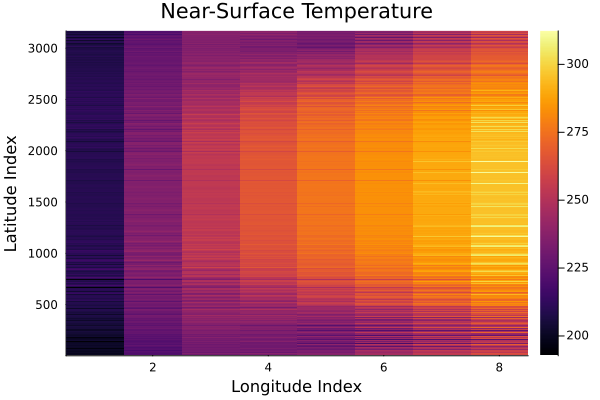

In [ ]:
from IPython.display import Image
Image("baseline_temperature.png")

The plotted figure represents the near-surface atmospheric temperature field produced by a global circulation simulation using SpeedyWeather.jl. The horizontal (x) axis corresponds to the longitude index, which represents positions along the east-west direction around the Earth, while the vertical (y) axis corresponds to the latitude index, representing positions from the South Pole to the North Pole. Although these axes are expressed as indices rather than physical coordinates, they map onto a spherical grid where longitude would span approximately 0°–360° and latitude −90° until 90°. The temperature values shown in the color scale are expressed in Kelvin (K), the standard unit in atmospheric physics, with the simulated mean value (~253 K) corresponding to about −20 °C, which is physically reasonable for a global atmospheric average that includes colder high-latitude and upper-layer influences.

Each pixel in the heatmap represents the temperature at a specific grid point on Earth’s surface layer, effectively providing a spatial snapshot of the atmospheric state after 10 days of model evolution. The large-scale structure in the plot is primarily governed by solar radiative forcing, where incoming solar energy is unevenly distributed due to Earth’s curvature: regions near the equator receive more direct sunlight and thus exhibit higher temperatures, while higher latitudes receive less sunlight per unit area, resulting in cooler temperatures. This fundamental balance between incoming solar radiation and outgoing terrestrial radiation can be described by the radiative equilibrium relation

$$(1−𝛼)\frac{S}{4}= 𝜎𝑇^{4} ,$$

where S is the solar constant, $\alpha$ is planetary albedo, and $\sigma$ is the Stefan-Boltzmann constant. However, the temperature distribution is not perfectly zonally symmetric, indicating that the model is not purely radiative but also includes atmospheric dynamics such as fluid motion, heat transport, and instabilities. These processes redistribute energy through winds and circulation patterns, producing spatial variability beyond simple equator-to-pole gradients.

The discretized appearance of the field reflects the finite resolution of the numerical grid, defined here by a relatively low spectral truncation, which limits the smallest spatial scales that can be resolved. Overall, this baseline simulation represents a dynamically consistent climate state arising from the interaction of radiation, thermodynamics, and fluid dynamics. It serves as a reference configuration for investigating atmospheric sensitivity to solar forcing, where small perturbations in solar irradiance can be introduced to examine how the temperature field and more broadly, atmospheric circulation-responds.

# **2. Temperature Response to Solar Forcing (ΔT)**

**Spatial distribution of temperature change resulting from increased solar irradiance**

**Solar forcing is introduced by modifying the solar constant in the planetary configuration, which alters the incoming shortwave radiation in the model’s radiative transfer scheme, thereby changing the atmospheric energy balance and driving temperature responses.**

-- Small perturbations (0.1 - 0.2%) in solar forcing allow the system to remain within a quasi-linear regime, where the temperature response scales proportionally with the forcing. Larger perturbations push the system into a nonlinear regime, where feedback processes dominate and the model may become unstable or physically unrealistic.

In [ ]:
# Period = 10 days
# Solar Forcing = 0.1%

run_julia("""
using SpeedyWeather
using Dates
using Statistics
using Plots

gr()

spectral_grid = SpectralGrid(trunc=31, nlayers=8)

# --- Control simulation ---
model1 = PrimitiveWetModel(spectral_grid)
sim1 = initialize!(model1)
run!(sim1, period=Day(10))
T1 = sim1.diagnostic_variables.grid.temp_grid[:,:,end]

# --- Perturbed simulation ---

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.001)  #  FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified)

sim2 = initialize!(model2)
run!(sim2, period=Day(10))
T2 = sim2.diagnostic_variables.grid.temp_grid[:,:,end]

println("Solar forcing simulation complete!")

ΔT = T2 - T1

println("Max ΔT: ", maximum(ΔT))
println("Min ΔT: ", minimum(ΔT))

p = heatmap(ΔT, title="Temperature Change (ΔT) due to Solar Forcing")
savefig(p, "deltaT.png")
""")

STDOUT:
 Solar forcing simulation complete!
Max ΔT: 1.5922546
Min ΔT: -0.8876648

STDERR:
 GKS: cannot open display - headless operation mode active



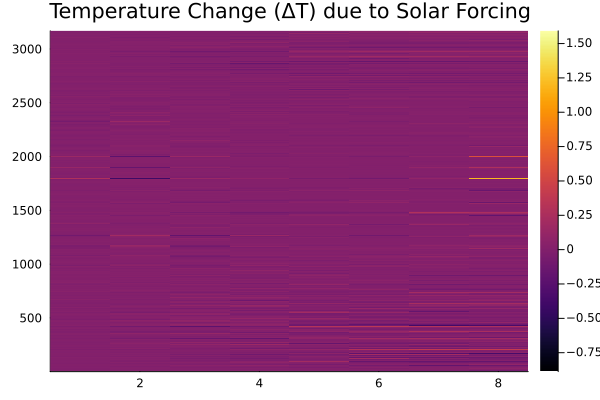

In [ ]:
from IPython.display import Image
Image("deltaT.png")

**The temperature response exhibits spatial variability with both positive and negative anomalies. This reflects the dominance of short-term atmospheric variability over the imposed solar forcing in short simulations -- To get better results: long-term averaging is important to extract the climate signal.**

In [ ]:
# Period = 365 days
# Solar Forcing = 0.1%

run_julia("""
using SpeedyWeather
using Dates
using Statistics
using Plots

gr()

spectral_grid = SpectralGrid(trunc=31, nlayers=8)

# --- Control simulation ---
model1 = PrimitiveWetModel(spectral_grid)
sim1 = initialize!(model1)
run!(sim1, period=Day(365))   #change to 365 days
T1 = sim1.diagnostic_variables.grid.temp_grid[:,:,end]

# --- Perturbed simulation ---

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.001)  #  FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified)

sim2 = initialize!(model2)
run!(sim2, period=Day(365))   #change to 365 days
T2 = sim2.diagnostic_variables.grid.temp_grid[:,:,end]

println("Solar forcing simulation complete!")

ΔT = T2 - T1

println("Max ΔT: ", maximum(ΔT))
println("Min ΔT: ", minimum(ΔT))

pp = heatmap(ΔT, title="Temperature Change (ΔT) due to Solar Forcing")
savefig(pp, "deltaTL.png")
""")

STDOUT:
 Solar forcing simulation complete!
Max ΔT: 30.774231
Min ΔT: -19.923172

STDERR:
 GKS: cannot open display - headless operation mode active



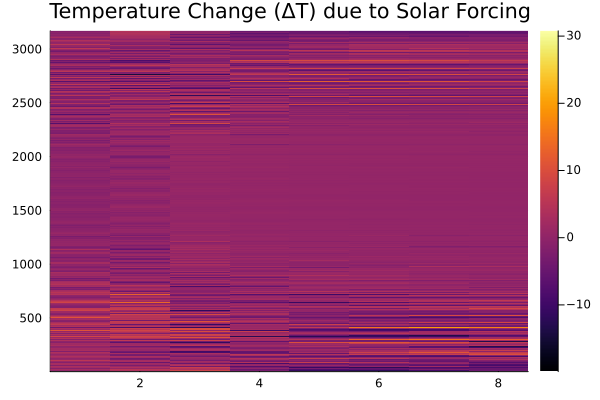

In [ ]:
from IPython.display import Image
Image("deltaTL.png")

# **Simulations for 2000 days, solar forcing 0.1%**

In [ ]:
# Period = 2000 days
# Solar Forcing = 0.1%

run_julia("""
using SpeedyWeather
using Dates
using Statistics
using Plots

gr()

spectral_grid = SpectralGrid(trunc=31, nlayers=8)

# --- Control simulation ---
model1 = PrimitiveWetModel(spectral_grid)
sim1 = initialize!(model1)
run!(sim1, period=Day(2000))   #change to 2000 days
T1 = sim1.diagnostic_variables.grid.temp_grid[:,:,end]
T1_mean = mean(sim1.diagnostic_variables.grid.temp_grid, dims=3)

# --- Perturbed simulation ---

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.001)  # FIX
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified)

sim2 = initialize!(model2)
run!(sim2, period=Day(2000))   #change to 2000 days
T2 = sim2.diagnostic_variables.grid.temp_grid[:,:,end]
T2_mean = mean(sim2.diagnostic_variables.grid.temp_grid, dims=3)

println("Solar forcing simulation complete!")

# ΔT = T2 - T1
ΔT = T2_mean - T1_mean

# T_mean = mean(sim.diagnostic_variables.grid.temp_grid, dims=3)

println("ΔT: ", ΔT)
println("Max ΔT: ", maximum(ΔT))
println("Min ΔT: ", minimum(ΔT))

# p2k = heatmap(ΔT, title="Temperature Change (ΔT) due to Solar Forcing")

p2k = heatmap(
    ΔT,
    title="Temperature Change (ΔT) due to Solar Forcing",
    xlabel="Longitude Index",
    ylabel="Latitude Index",
    colorbar_title="ΔT (K)"
)

savefig(p2k, "deltaT2k.png")
""")

STDOUT:
 Solar forcing simulation complete!
ΔT: Float32[13.112595 -2.8129272 8.303894 4.189026 3.3356323 0.7907257 -2.4855194 -3.7060852; 12.927216 -2.932724 7.889328 4.2722473 2.2430267 -0.5168762 -3.2704926 -4.1328735; 12.599609 -3.0930328 7.5296326 4.4398346 1.0761261 -1.7978973 -3.811966 -4.3062134; 12.090012 -3.2053528 7.2848663 4.6063843 -0.038879395 -2.8980255 -4.061081 -4.205185; 11.421616 -3.2450867 7.151169 4.682953 -0.9573822 -3.670105 -4.009323 -3.8316498; 10.683472 -3.2476807 7.1073303 4.65448 -1.5682526 -4.0534973 -3.7221222 -3.2427216; 9.999023 -3.2605133 7.1664734 4.5620117 -1.8526154 -4.0869293 -3.2922974 -2.520111; 9.489914 -3.29953 7.3751373 4.4306946 -1.886383 -3.8535614 -2.7628326 -1.7133026; 9.247238 -3.3365326 7.75473 4.2332 -1.7762451 -3.4128876 -2.0987244 -0.8156738; 9.310333 -3.3193207 8.244186 3.9253845 -1.5768585 -2.767395 -1.2353973 0.19897461; 9.655594 -3.2138977 8.710037 3.509842 -1.2534332 -1.8792725 -0.16055298 1.3063049; 10.202072 -3.0400085 9.024017 3

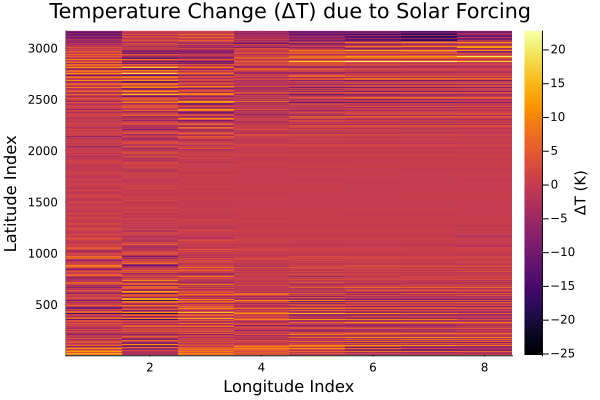

In [ ]:
from IPython.display import Image
Image("deltaT2k.png")

In [ ]:
import statistics


dT = "13.112595 -2.8129272 8.303894 4.189026 3.3356323 0.7907257 -2.4855194 -3.7060852; 12.927216 -2.932724 7.889328 4.2722473 2.2430267 -0.5168762 -3.2704926 -4.1328735; 12.599609 -3.0930328 7.5296326 4.4398346 1.0761261 -1.7978973 -3.811966 -4.3062134; 12.090012 -3.2053528 7.2848663 4.6063843 -0.038879395 -2.8980255 -4.061081 -4.205185; 11.421616 -3.2450867 7.151169 4.682953 -0.9573822 -3.670105 -4.009323 -3.8316498; 10.683472 -3.2476807 7.1073303 4.65448 -1.5682526 -4.0534973 -3.7221222 -3.2427216; 9.999023 -3.2605133 7.1664734 4.5620117 -1.8526154 -4.0869293 -3.2922974 -2.520111; 9.489914 -3.29953 7.3751373 4.4306946 -1.886383 -3.8535614 -2.7628326 -1.7133026; 9.247238 -3.3365326 7.75473 4.2332 -1.7762451 -3.4128876 -2.0987244 -0.8156738; 9.310333 -3.3193207 8.244186 3.9253845 -1.5768585 -2.767395 -1.2353973 0.19897461; 9.655594 -3.2138977 8.710037 3.509842 -1.2534332 -1.8792725 -0.16055298 1.3063049; 10.202072 -3.0400085 9.024017 3.0619965 -0.71533203 -0.7261658 1.034256 2.3855438; 10.840652 -2.8721771 9.139954 2.7010956 0.10974121 0.6375885 2.1615906 3.2295532; 11.475327 -2.798355 9.107147 2.5389252 1.2111359 2.0527039 2.9908752 3.6024475; 12.048248 -2.8566742 9.020691 2.6377258 2.4689484 3.2804108 3.3182983 3.327591; 12.531433 -2.9947662 8.959427 2.9782104 3.6703339 4.077408 3.0387268 2.385025; 12.901932 -3.0960693 8.948471 3.444397 4.568283 4.290985 2.2005463 0.9645233; 13.135208 -3.0710602 8.949463 3.8632355 4.9745026 3.9227295 1.0021362 -0.59513855; 13.227386 -2.93956 8.878845 4.105423 4.8378143 3.1091766 -0.29496765 -1.9721069; 13.208908 -2.8175964 8.663025 4.173996 4.243683 2.0244446 -1.4870148 -3.006607; 11.650009 1.0575256 8.2211 3.9062805 4.6181793 0.6542511 -3.6576843 -4.0893707; 11.721161 0.37545776 7.040146 3.5931702 3.2733002 -0.87831116 -4.6503754 -4.6793213; 11.675705 -0.51872253 6.2417603 4.202072 1.7478333 -2.9699554 -5.9280853 -5.6083984; 11.153397 -1.0878296 5.9575653 5.070282 -0.06680298 -5.131836 -6.9042206 -6.2774963; 10.10347 -1.2520752 5.9698944 5.4463196 -1.8704071 -6.6006317 -7.0121307 -6.2363434; 8.719131 -1.2672882 5.91185 5.131439 -3.135315 -6.985443 -6.2747955 -5.503586; 7.22876 -1.3990784 5.515915 4.520508 -3.4799347 -6.4717712 -5.228531 -4.434189; 5.800766 -1.7603607 4.8411865 4.174637 -2.9187164 -5.5543213 -4.47229 -3.4708252; 4.585449 -2.3428192 4.308914 4.362137 -1.8681793 -4.6897125 -4.292938 -2.9264832; 3.7499542 -3.0485382 4.4419556 4.8718567 -0.9390106 -4.1433716 -4.536957 -2.7749786; 3.4605865 -3.681961 5.467682 5.1987915 -0.60816956 -3.9665375 -4.7400208 -2.6334686; 3.843872 -4.005356 7.103653 4.9302216 -0.94981384 -3.9716034 -4.406845 -2.0336761; 4.9072113 -3.8618164 8.713898 4.0220337 -1.6170197 -3.7679596 -3.249298 -0.7222595; 6.444519 -3.261383 9.716202 2.786316 -2.0771637 -2.943161 -1.278183 1.259491; 8.073105 -2.3925018 9.918671 1.6460571 -1.8878632 -1.280838 1.2339478 3.6514893; 9.44931 -1.6011505 9.550186 0.8964691 -0.83976746 1.131485 3.8584747 6.020752; 10.457306 -1.2910614 9.007462 0.69566345 1.0365143 3.9145966 6.0953674 7.750595; 11.199661 -1.6848602 8.5729065 1.199707 3.5244293 6.4787903 7.396057 8.121704; 11.856903 -2.574707 8.349503 2.5127258 6.216385 8.168854 7.281204 6.661621; 12.496689 -3.3094635 8.391174 4.3824005 8.454147 8.493042 5.651642 3.6434174; 12.937698 -3.176117 8.760727 6.0836487 9.516159 7.395279 3.0112762 0.16990662; 12.904068 -1.9858856 9.337204 6.829651 9.129791 5.402588 0.27635193 -2.4824677; 12.4118805 -0.32130432 9.662903 6.3474884 7.7358704 3.3759003 -1.7546234 -3.7313843; 11.865494 0.8820801 9.27446 5.0775757 6.0842285 1.863678 -2.9004974 -3.9711914; 7.682144 7.1367188 6.5911713 1.9085999 3.3348694 0.78504944 -0.94192505 0.059387207; 8.183899 5.775696 4.9490356 0.96014404 3.1035614 0.23832703 -1.621994 -0.82977295; 8.599503 4.097046 4.2651367 2.1415863 2.5605316 -2.1746216 -4.109131 -3.287201; 8.301895 3.0477142 4.427353 4.309433 1.084137 -5.532959 -6.9378357 -5.818863; 7.244812 2.7350464 5.008438 5.6689453 -1.1211395 -8.092087 -8.287384 -7.052368; 5.81131 2.5987854 5.542801 5.389496 -3.1869354 -8.717087 -7.6336975 -6.787384; 4.400131 2.0357666 5.5329285 3.95932 -4.2641754 -7.4834595 -5.762375 -5.5994873; 3.112564 0.88131714 4.6100616 2.4210815 -3.9381409 -5.2878876 -3.7262115 -3.9911957; 1.822464 -0.6555176 2.8228455 1.7310638 -2.2559967 -3.0743103 -2.2824707 -2.4282227; 0.46452332 -2.3334656 0.771225 2.3768768 0.31115723 -1.3531036 -1.8863678 -1.6135864; -0.88131714 -3.9614258 -0.63197327 4.1017914 2.9212036 -0.3045349 -2.6109314 -2.022232; -2.0340576 -5.33934 -0.6286621 6.0588074 4.6074524 -0.09971619 -4.1145782 -3.3883057; -2.6587372 -6.309265 1.0042725 7.319504 4.7354126 -0.88565063 -5.86203 -4.9723663; -2.3068542 -6.7670593 3.788437 7.309433 3.360382 -2.462204 -7.3134766 -6.125885; -0.69036865 -6.6515503 6.7334747 6.015564 1.15094 -4.1690216 -7.933609 -6.4714813; 1.9630737 -5.9322357 8.844711 3.9696503 -1.0497894 -5.1779327 -7.2313232 -5.714493; 4.858444 -4.57605 9.616638 1.9328156 -2.5525208 -4.8704834 -5.0244446 -3.6015625; 7.1658936 -2.7451477 9.264847 0.42546082 -2.8879395 -3.0570526 -1.6375427 -0.20690918; 8.581665 -1.0238037 8.476547 -0.44496155 -1.9243774 -0.005645752 2.3369446 3.9258423; 9.267822 -0.21058655 7.7993774 -0.6852722 0.111968994 3.688614 6.2617035 7.8542786; 9.540482 -0.8368225 7.302765 -0.0027923584 2.9998627 7.2586365 9.273895 10.268768; 9.820572 -2.7219849 6.7727814 2.0674896 6.609314 9.89003 10.353439 9.927444; 10.501938 -4.74411 6.1536255 5.332367 10.244003 10.861847 9.0082855 6.7005157; 11.433243 -5.262726 5.9011383 8.503235 12.378082 9.737381 5.783188 2.1023407; 11.777954 -3.2868042 6.662979 10.096405 11.84404 6.751297 1.977356 -1.6581573; 10.897308 0.58929443 8.206955 9.604797 9.182907 3.1728668 -1.0022278 -3.1932678; 9.2356415 4.5631104 9.152649 7.476639 6.1701508 0.7716675 -2.1984253 -2.5426025; 7.933731 6.9419403 8.441391 4.5261993 4.1565857 0.32937622 -1.7094421 -0.89553833; 3.8841858 10.859558 2.9715576 -0.21725464 1.5795898 1.945343 2.8061523 3.6790771; 4.4187927 9.991562 1.8000793 -1.8988647 2.226181 2.3341217 2.841339 3.179016; 4.6923065 8.813675 1.9713135 -0.97424316 2.7405396 0.046081543 -0.07347107 0.25357056; 4.3420258 7.953125 2.7720184 1.9776611 2.1520386 -3.9438171 -4.3345337 -3.5460815; 3.4156342 7.5491333 3.6517944 4.5426636 0.30162048 -7.475128 -7.176407 -5.9366302; 2.19133 7.286682 4.430847 5.010681 -1.8687897 -8.916031 -7.3317413 -6.1632385; 1.0532684 6.5757446 4.8615723 3.7349548 -3.3316803 -7.9749756 -5.7616425 -5.3753357; 0.2969818 4.938339 4.621872 1.8861389 -3.7261353 -5.4380493 -3.8878784 -4.589493; -0.15470886 2.416977 3.5204926 0.24639893 -3.1019287 -2.4805908 -2.0944366 -3.4416504; -0.62794495 -0.6057892 1.5865936 -0.55296326 -1.486496 0.05204773 -0.2295227 -1.4442139; -1.3045502 -3.8225403 -0.7876282 0.019760132 1.1085358 2.0088806 1.4211121 0.635025; -2.3013916 -6.768158 -2.998581 1.871994 4.369095 3.6224213 2.3335876 1.5711823; -3.8144226 -8.751495 -4.5817566 4.363846 7.5020294 4.8894653 2.3037872 1.0973053; -5.6719666 -9.626251 -5.097061 6.8130035 9.528641 5.326584 1.2905426 -0.30880737; -7.11145 -9.936493 -4.070984 8.632965 9.798782 4.3388977 -0.8304291 -2.3141174; -7.2700195 -10.079025 -1.5074921 9.283737 8.312836 1.8076324 -4.0435333 -4.875992; -5.6193542 -10.047913 1.9042358 8.448334 5.6351013 -1.6987305 -7.742157 -7.8283234; -2.2949219 -9.689346 5.1024475 6.3552856 2.4191132 -5.1150055 -10.483459 -10.256653; 1.6557465 -8.636734 7.060425 3.7383728 -0.76116943 -7.1978455 -10.793808 -10.708206; 4.9115753 -6.599182 7.4517975 1.3426208 -3.0486145 -7.110443 -8.509949 -8.551056; 6.8796844 -3.9292297 6.9637146 -0.3904724 -3.5886688 -4.9407043 -4.6544037 -4.4826355; 7.747696 -1.4770813 6.5030212 -1.3613892 -2.4749603 -1.4294281 -0.10282898 0.462677; 7.843796 -0.12106323 6.2865906 -1.655365 -0.56510925 2.6507263 4.7046356 5.4753113; 7.376175 -0.57432556 5.9430695 -0.9894104 1.884552 6.6421814 8.942413 9.425415; 6.757675 -2.9510345 5.0663605 1.3372803 5.4947815 9.927032 11.344666 10.839523; 6.724716 -6.1134186 3.4815826 5.1901703 10.1671295 11.997818 11.210815 9.1263275; 7.602249 -7.856659 1.6569519 8.739243 13.865219 12.334961 9.0224 5.5218353; 8.560608 -6.358856 0.98973083 9.927048 14.0403595 10.36763 5.8718567 2.1386871; 8.330505 -1.7803955 2.5392456 8.701553 10.513779 6.305969 2.6315155 0.10722351; 6.726288 3.810913 5.1805267 6.705307 5.904831 1.9319 0.120285034 -0.5324402; 4.844757 8.23053 6.3699036 4.827179 2.7734222 -0.38372803 -0.5774689 0.25637817; 3.8253784 10.522873 5.123337 2.534195 1.5650635 0.16609192 0.8426361 2.1428223; 2.3740387 9.305878 -0.38006592 -0.36824036 0.9504547 2.1820374 2.7341003 2.5257263; 2.1608887 10.53714 -0.30004883 -2.5893402 1.0255585 2.474823 3.1931152 2.8712158; 1.5261993 11.513565 0.70370483 -2.910797 1.6221466 0.81907654 1.4344177 1.3885803; 0.815979 11.657043 1.6485596 -0.5310974 1.7908936 -2.2463226 -2.0025787 -1.6080627; 0.2957306 10.909546 2.2898712 2.6609344 0.71533203 -5.2805023 -4.9379883 -4.0899963; -0.13323975 9.845215 2.929947 4.151825 -1.04982 -7.009186 -5.602768 -4.374298; -0.7221832 8.935516 3.4618073 3.551117 -2.250824 -6.966934 -4.420059 -3.1705933; -1.4057617 7.9310455 3.4167938 2.2277985 -2.374527 -5.4325714 -3.2104187 -2.567566; -1.8557739 6.244171 2.768753 0.9768524 -1.8814545 -3.1074219 -2.8716736 -3.2442932; -2.021576 3.7479553 1.785965 -0.31593323 -1.3629761 -0.80519104 -2.5221558 -3.6288147; -2.0693207 0.5478668 0.52511597 -1.3301849 -0.90893555 1.0243378 -0.98098755 -2.0758667; -1.9811554 -3.497757 -0.8562317 -1.4015045 -0.055526733 2.5490875 1.6671295 0.8998413; -1.9276428 -7.897995 -2.061203 -0.5970917 1.7107086 4.2184906 4.486023 3.486847; -2.6760864 -11.034515 -3.3348389 0.55018616 4.346634 6.300537 6.9605103 5.017853; -4.731781 -11.909882 -5.1713867 1.9807739 7.293625 8.619629 8.96106 6.006714; -7.3736267 -11.534088 -7.1123505 3.9343262 9.86084 10.469803 10.00238 6.472229; -9.353149 -11.409241 -7.969055 6.216446 11.34964 10.85939 9.293945 5.8391113; -9.981354 -11.690765 -7.0936737 8.097809 11.28566 9.028885 6.0438995 3.4874878; -8.903488 -11.815384 -4.572998 8.730804 9.751633 4.8522034 0.19309998 -0.9908142; -5.9783173 -11.555908 -1.0519562 7.7858734 6.959778 -0.7798462 -6.3000336 -6.4752502; -1.9431763 -10.696945 2.1373138 5.6456146 2.9920197 -5.78598 -10.278534 -10.199493; 1.8869171 -8.982788 3.834549 2.8973694 -1.2107391 -8.078873 -10.363937 -10.3918; 4.6229706 -6.637619 4.213379 0.24580383 -3.7483063 -7.3230743 -7.907837 -7.871063; 6.0376587 -4.140274 4.3823547 -1.4650726 -3.6744385 -4.775757 -4.743332 -4.4540405; 6.3026123 -1.8101349 4.991745 -2.038803 -2.0793 -1.5893097 -1.3023224 -0.91848755; 5.739685 -0.17034912 5.6182556 -2.0592194 -0.5218048 1.9453735 2.7075958 2.874176; 4.614807 -0.18417358 5.462555 -1.5783386 1.0072174 5.6922607 6.8769226 6.5932007; 3.2258606 -2.3787231 4.2379 0.36795044 3.8626099 9.126236 10.029083 9.068054; 2.1734924 -5.831848 2.085846 4.0378876 8.641418 11.804123 11.272034 9.361084; 2.0656128 -8.349579 -0.66941833 7.4798584 13.54509 13.550858 10.860947 8.060516; 2.7073517 -7.847885 -2.9728088 7.901245 15.202591 13.800568 9.811935 6.9308624; 3.1429596 -4.0859375 -3.1627655 4.8700714 12.074066 11.725006 8.43898 6.478256; 2.8426208 0.932724 -0.8896637 1.3126678 6.6187286 7.5949707 6.130127 5.2734375; 2.260971 4.8546753 1.7403107 0.19094849 2.6688385 3.2942963 3.1595001 2.9436035; 2.0228424 7.01268 2.3143005 1.0739288 1.3731537 0.9068756 1.2275391 1.3031311; 2.1910095 8.208481 0.92407227 1.3188324 1.1896667 0.98391724 1.4040527 1.4750366; 2.4338226 4.4696045 -1.5714111 0.55307007 1.385025 1.1864166 -0.18740845 -0.8854675; 1.2543793 8.027466 0.1661377 -1.3389893 -0.32081604 -0.10714722 -0.855896 -1.1098022; -0.31240845 11.468079 1.6119843 -2.685257 -0.77137756 -1.3602753 -1.2441406 -1.0214844; -1.3478241 12.7851715 1.9679565 -1.8917694 -0.27272034 -2.3613586 -1.9916382 -1.630249; -1.3374939 11.388016 1.7219849 0.6891022 -0.15431213 -3.29187 -3.154007 -2.8241577; -0.59539795 8.756531 1.898407 3.0011597 -1.1381836 -4.233673 -3.8902283 -3.4189148; 0.045074463 6.8286133 2.6971283 3.5698547 -2.457199 -4.8068695 -3.5250092 -2.6612854; -0.030197144 6.2308044 3.1457672 2.9264374 -2.8026428 -4.6076355 -2.5678253 -1.3471069; -0.63916016 6.12973 2.559906 2.2435913 -1.9237366 -3.6120605 -2.220749 -1.1186218; -1.285141 5.5560913 1.4909058 1.4953308 -0.6903229 -2.235794 -2.887848 -2.4377136; -1.8296051 4.405609 0.6365051 0.0771637 -0.09739685 -1.0754395 -3.5489655 -3.7481384; -2.2003784 2.6103516 -6.1035156e-5 -1.5757599 -0.5647583 -0.30485535 -2.8593903 -3.10672; -2.1076813 -0.49754333 -0.47587585 -2.504013 -1.539917 0.44758606 -0.6380768 -0.528656; -1.6313782 -4.7587433 -0.5314636 -2.7187195 -1.9796448 1.5232544 2.1643524 2.2085266; -1.6436768 -8.341568 -0.39901733 -2.9606018 -1.3512268 3.1273346 4.928879 4.173584; -3.0502167 -9.638321 -1.2244263 -3.2651062 0.3849945 5.5956573 7.922653 6.1493225; -5.631653 -9.305054 -3.666977 -2.7318878 3.2350922 9.07901 11.204575 8.467224; -8.152954 -9.369141 -6.7819366 -0.80574036 6.897537 12.972885 14.24469 10.260773; -9.786331 -10.58786 -9.247253 2.0918732 10.241669 15.925995 16.237274 11.155853; -10.5872345 -11.807404 -10.45192 5.0124054 12.004608 16.364243 15.46254 10.682175; -10.363541 -11.9254 -9.890839 6.8555756 12.002274 13.091263 10.3112335 7.3461304; -8.56955 -10.978027 -7.301483 7.033798 10.429871 6.364044 2.251114 1.331543; -5.4279327 -9.312683 -3.6567993 5.813156 6.8668823 -1.1263733 -4.5323486 -4.269745; -1.7754059 -7.2542725 -0.57743835 3.5390778 1.7673035 -5.8233795 -7.190857 -6.6854553; 1.6360474 -5.288208 1.1829681 0.6775055 -2.5092926 -6.5395813 -6.420471 -5.996887; 4.031494 -3.6220093 2.0823212 -1.5304718 -3.9350128 -4.9433136 -4.623581 -4.126068; 4.8587646 -1.977829 3.134674 -2.0849915 -2.944458 -3.0883636 -3.1727905 -2.5543823; 4.314926 -0.15959167 4.905884 -1.5761414 -1.5088654 -1.4681549 -1.7165833 -1.2121277; 3.0561676 1.3246307 6.662033 -1.3926544 -0.7767029 0.7733612 0.68011475 0.76828; 1.5307617 1.4619293 6.997284 -1.71521 -0.10205078 4.123352 4.2046967 3.6575012; -0.1268158 -0.27337646 5.4551697 -1.1161346 1.8613434 7.7416077 7.8741913 6.6249695; -1.7099304 -3.1876526 2.8177185 1.434372 5.7466125 10.535782 10.222473 8.289337; -2.80365 -5.566742 -0.0054626465 4.784363 10.534363 12.290222 10.73288 8.229095; -3.1156769 -5.690735 -2.4543762 6.1434937 13.356155 13.180588 10.554169 8.065582; -2.7256165 -3.222107 -3.8221283 3.5949402 11.789566 12.942825 10.872192 9.264954; -1.844986 0.21707153 -3.4794464 -1.2465668 7.0393066 11.269379 10.918716 10.198166; -0.5556946 2.4080658 -2.0076294 -4.3132477 3.031723 8.650391 9.250931 8.442093; 0.948761 2.626831 -1.1022034 -3.5984802 2.0787048 6.0209656 6.193741 4.8330383; 2.1853638 2.0524597 -1.5695648 -0.86302185 2.9186249 3.920639 3.238678 1.8702393; 2.7400055 2.3700714 -2.2183838 0.975296 2.95076 2.4110107 1.1315918 0.13195801; 2.0293732 0.35810852 -1.7856598 0.7915039 2.4525146 0.7923279 -1.4377441 -2.048584; 0.7353821 4.855179 1.8051605 -0.14067078 -1.2454529 -3.0886993 -4.7334747 -4.4513245; -0.9586029 9.455414 4.02536 -1.4758453 -3.399994 -5.008377 -5.333954 -4.467987; -1.9870605 11.423523 3.962387 -2.139862 -3.251175 -4.2089996 -3.7390747 -3.086609; -1.5750885 9.489243 2.6083374 -1.4624329 -1.7882538 -2.3527222 -2.0408936 -1.84198; -0.026947021 5.5111847 1.684433 0.26472473 -1.107254 -1.7610779 -1.8601074 -1.9403687; 1.6282196 2.5874634 2.1527557 1.8770142 -2.265686 -2.7243195 -2.8010254 -2.9020386; 2.3923492 2.101654 3.3162384 2.4824219 -3.908432 -3.8337708 -3.3682556 -3.066681; 2.1400604 3.170578 3.6839294 2.3866882 -4.1874695 -4.0169983 -2.970642 -2.1062622; 1.517273 4.09906 2.8644714 2.3454742 -2.9642792 -3.2821045 -2.3543243 -1.3114014; 0.89749146 4.1783447 1.6828308 2.061386 -1.3246613 -2.318985 -2.3788147 -1.6967163; 0.21607971 3.9385834 0.82969666 0.7297363 -0.44247437 -1.9550018 -3.0150604 -2.7437744; -0.33888245 3.4412537 0.4670105 -1.3995056 -1.1260834 -2.2696838 -3.4399567 -3.0671692; -0.4392395 1.8560181 0.5244446 -3.3743134 -2.922821 -2.5236664 -2.9836426 -2.2014465; -0.3423462 -0.66877747 0.89527893 -4.6978455 -4.4972076 -2.4173126 -1.9184265 -0.940979; -0.7593384 -2.6122437 1.4996796 -5.6061554 -5.2996063 -2.141571 -0.80670166 0.089416504; -2.0324097 -3.1570587 1.756546 -6.427597 -5.247284 -1.2490234 0.6817627 1.4237671; -3.9141693 -3.2783508 0.66967773 -6.6306305 -3.7472382 1.2302856 3.209198 3.6593628; -5.903427 -4.488327 -1.8144684 -5.292404 -0.22657776 5.68277 6.680725 5.776825; -7.5289917 -7.242447 -4.7780304 -2.465683 4.832947 11.348953 10.971344 6.9716797; -8.739822 -10.45813 -7.7426605 0.9922638 9.534485 16.651215 15.665497 8.5354; -9.711288 -12.438797 -10.501541 4.1566315 12.115631 19.64627 18.203552 10.523987; -9.96402 -12.427673 -12.028763 5.959503 12.718842 18.381927 15.670044 10.208405; -8.795013 -10.777817 -11.173767 5.944031 12.056244 12.239136 8.725723 6.3060303; -6.419876 -8.039703 -8.091751 4.80278 9.411621 3.7430573 1.2855988 1.0445557; -3.4345856 -4.911148 -4.109787 3.0299225 4.4342957 -2.7165527 -3.272171 -2.729187; -0.20581055 -2.180359 -0.63694763 0.6694336 -0.62210083 -4.9427032 -4.384201 -3.9931335; 2.503662 -0.0476532 1.4926758 -1.434906 -3.1596375 -4.146179 -3.5204773 -3.4075928; 3.8536682 1.6555328 2.4587555 -2.0948029 -3.1367188 -2.6878662 -2.4573517 -2.3936157; 3.8735504 2.8946533 3.5917969 -1.2715302 -2.2966766 -2.1130676 -2.1620789 -1.9707031; 3.1361847 3.5954742 5.9690094 -0.1471405 -2.0088959 -2.157013 -2.1921387 -1.8100891; 1.9463806 3.8047333 8.696854 -0.06742859 -2.1690063 -1.1295929 -1.1413574 -0.7897339; 0.28770447 3.4909668 9.695953 -1.2225342 -1.7984467 1.8613892 1.824646 1.6868591; -1.6820679 2.3998108 8.060333 -2.1802826 -0.35183716 5.696213 5.842041 4.9978943; -3.5236511 0.52305603 4.86705 -1.4934387 2.2654877 8.561783 8.820038 7.4141235; -4.9263 -1.2250061 1.8557587 0.8436127 5.767105 9.601044 9.279358 7.4819946; -5.7260284 -1.5108185 -0.041809082 3.4303894 8.511688 9.225433 7.9962463 6.1134033; -5.5624084 -0.07458496 -0.8126526 3.9010773 8.29567 8.33609 7.222763 5.8511353; -4.118744 1.7753296 -0.8298645 1.2214203 5.2768097 7.6067657 7.852539 7.1293945; -1.7261505 2.4519806 -0.695755 -2.366455 2.362793 7.609482 8.814484 7.9193726; 0.6972809 1.4374237 -1.2065735 -4.030121 1.9673615 8.52713 9.218536 7.343506; 2.3042297 -0.5903778 -2.775528 -3.3069916 3.8352509 9.198181 8.784439 6.281311; 2.8502045 -2.2533875 -4.4712677 -1.348053 5.770355 8.050461 6.8686523 4.7594604; 2.6759796 -2.163971 -4.393692 0.38809204 5.4456635 4.9338684 3.1125793 1.783783; 0.21070862 -1.3721619 -2.6512756 1.0269928 3.3807526 0.9306183 -0.81466675 -1.1610107; -0.111709595 2.5904846 2.3592377 0.40216064 -1.5934906 -4.829117 -6.1381226 -5.1712646; -0.98828125 6.7140045 5.811142 -0.619751 -5.0449677 -8.096817 -8.213882 -6.4888916; -1.6422577 8.682541 6.2131653 -1.9072113 -5.7230377 -6.845352 -6.197052 -4.9110107; -1.0650177 6.8643646 4.3307953 -3.1905365 -3.7307434 -2.7856445 -2.2409058 -1.5975037; 0.7040558 2.6851807 2.1214752 -3.3804474 -1.3427429 -0.23474121 -0.084625244 0.26123047; 2.6523285 -0.3691864 1.3348999 -1.9997101 -1.3724213 -1.1132202 -1.1542358 -1.0103455; 3.610443 -0.3953247 2.343628 -0.18205261 -3.599228 -3.4308472 -3.414856 -3.1317444; 3.243927 1.7148895 3.9463043 0.682251 -5.3258514 -4.633911 -4.3566284 -3.5531921; 2.3342896 3.9278412 4.7820435 0.9202728 -5.0945587 -4.207779 -3.5397644 -2.3444214; 1.7202606 4.772171 4.5457764 1.6640472 -3.654129 -2.8955078 -2.004181 -0.93344116; 1.4894257 4.3563232 3.5041199 2.5292053 -2.0244293 -1.6216583 -0.9483948 -0.4720459; 1.4343109 3.8813934 2.1199799 2.3162994 -1.027771 -1.5447845 -1.1917114 -1.1078186; 1.6621552 3.607788 1.3005066 0.66911316 -1.8060455 -2.9109802 -2.5532532 -2.1740112; 2.2394104 2.7483063 1.4868622 -2.1355438 -4.1102753 -4.3912354 -3.999054 -3.3024292; 2.5500488 1.624588 2.0292206 -5.2511597 -6.1048584 -5.2569275 -4.927185 -4.2937317; 1.7954559 1.6425476 2.4284363 -7.4968414 -7.2400208 -6.0835724 -5.5104065 -4.54422; 0.14672852 2.770172 2.7550812 -8.56427 -7.9980164 -6.7542725 -5.6280212 -3.6964722; -1.4508057 3.0158691 2.5849457 -8.673508 -7.678482 -6.053253 -4.505554 -1.6656799; -2.6996765 0.8367462 1.4158783 -7.3978577 -5.2036896 -3.040329 -1.9372253 0.83184814; -4.091797 -3.349823 -0.3598938 -4.403946 -0.46858215 2.0716248 1.6358948 1.9700012; -5.7773743 -8.106171 -2.3973083 -0.4352417 5.438553 8.21994 6.4855957 2.0118408; -7.444214 -12.067184 -5.0798492 3.4642487 10.426544 14.179794 12.275085 3.6610718; -8.708359 -14.271454 -8.3910675 6.402725 12.95224 18.529251 16.264435 7.1096497; -8.901093 -14.461761 -11.189377 7.2819824 13.515411 19.290634 15.796829 9.223114; -7.555069 -12.872772 -12.022751 6.059326 13.186386 14.969162 11.144791 7.8882446; -5.172516 -9.792648 -10.197617 4.3097534 11.142654 7.07283 4.810852 3.9971924; -2.4541779 -5.849304 -6.234085 2.9517822 6.315811 -0.2157135 -0.59321594 -0.26742554; 0.31481934 -1.848587 -1.6012268 1.5765076 0.71281433 -4.129074 -3.7266083 -3.2299194; 2.515091 1.9820404 2.1669312 0.17210388 -2.5242767 -4.865753 -4.4567566 -4.131073; 3.5515137 5.4276276 4.214096 -0.63201904 -3.0732422 -3.7097778 -3.4359894 -3.3566284; 3.8877106 7.5250244 4.915848 -0.59243774 -2.6481018 -2.3276672 -2.2080536 -2.3924866; 4.2859955 7.5693054 5.7516174 0.11671448 -2.5545044 -2.2030182 -2.112442 -2.266693; 4.6613464 6.0839844 7.6625824 1.1525574 -3.0638123 -2.8405151 -2.6705475 -2.4138184; 4.2429504 4.4508667 9.828323 1.5056305 -3.3869476 -2.3177795 -2.1975708 -1.6800232; 2.503479 3.7571259 10.586319 0.41210938 -2.7906036 0.08937073 0.18466187 0.42401123; -0.025512695 3.628357 9.096008 -1.1486359 -1.5906525 3.3373413 3.6216736 3.339325; -2.1803894 2.9230957 6.017334 -1.8690796 -0.0717926 5.829895 6.253418 5.6123657; -3.4468994 1.6850433 2.883377 -1.4015961 1.9268494 6.383148 6.5651245 5.7540894; -4.0936737 1.1784973 0.96803284 0.39317322 3.6732178 4.9049225 4.516754 3.818451; -4.067932 1.9200134 0.8063812 2.5272522 3.662506 2.4219208 1.7913513 1.6732483; -2.8066864 2.8127136 2.0469208 2.9560547 1.7768402 0.3047943 0.2383728 0.62542725; -0.47705078 2.6985626 3.3392792 1.671936 -0.014022827 -0.04875183 0.52311707 0.5928345; 1.6224213 1.6088867 3.1311188 0.25726318 0.14997864 2.6459503 2.979782 2.084137; 2.3778687 -0.07572937 0.72650146 -0.9215088 2.3469696 7.6260834 7.1923065 5.3254395; 1.8593903 -2.1461945 -3.1391602 -1.6296844 5.5504303 11.267059 10.458633 8.108856; 0.9155884 -3.7770538 -6.243973 -0.96151733 7.9594727 10.751694 9.894684 7.8189697; 0.33674622 -3.692688 -6.223526 0.49002075 7.3466187 6.6805725 5.413574 4.081024; -2.1948395 -2.188568 -3.2138062 2.29039 3.0911255 0.41934204 -0.8401489 -0.7242737; -1.3109131 0.9078827 1.6710052 0.97483826 -2.0008392 -5.1236267 -5.909027 -4.603241; -0.89749146 3.9128418 5.4938965 -0.22857666 -5.4821777 -9.1992035 -9.020309 -6.9908447; -0.8096771 5.511368 6.5780945 -1.6070862 -6.7429657 -8.877853 -8.103516 -6.443512; -0.15785217 4.3690796 4.975525 -3.9081879 -5.285446 -4.476288 -3.8041077 -2.6991577; 1.3534241 1.2079773 2.1693268 -5.7637177 -2.4427338 -0.55218506 -0.1920166 0.6979065; 2.9651031 -1.0678711 0.28181458 -5.273178 -1.523346 -0.6348877 -0.33779907 0.3914795; 3.5666962 -0.5218811 0.73205566 -2.809494 -3.3504333 -3.3269958 -2.8931274 -1.946106; 2.7083435 2.0240784 3.1624146 -0.69496155 -5.180008 -5.0141144 -4.5063477 -3.0747375; 1.0575562 4.690201 6.046295 -0.1136322 -4.8939056 -4.391983 -3.9830627 -2.4108276; -0.46955872 6.2875366 8.137756 0.3984375 -3.2004395 -2.6736755 -2.314331 -0.8930054; -1.3635712 6.249069 8.805222 2.097763 -1.5607758 -0.7666931 -0.36132812 0.7061157; -1.3401337 4.953308 7.642044 3.9670105 -0.11090088 1.0111542 1.14505 1.4865112; -0.39692688 3.7885742 5.1710205 4.7956085 1.0069427 1.2401123 1.0515442 0.9177246; 1.2243347 3.3727417 3.1148682 4.1893463 0.17564392 -0.94441223 -0.79541016 -0.5024109; 3.150299 3.0687714 2.446518 1.5510712 -2.999588 -3.799942 -3.2350464 -2.5397034; 4.639984 2.8764954 2.3739471 -2.8492432 -6.203766 -5.764099 -5.421112 -5.1080933; 4.8719025 3.7328339 2.1952972 -7.0330353 -8.083038 -7.3602753 -7.1654053 -6.792511; 3.85112 5.4513855 2.310669 -9.449493 -9.343445 -8.784622 -8.188049 -6.498596; 2.4967957 6.1121063 2.6404877 -10.110443 -9.647064 -8.999985 -7.9112244 -4.7223816; 1.3353882 4.136215 2.2822113 -9.222305 -7.781616 -7.108536 -5.907379 -2.0058594; -0.26293945 -0.09629822 1.2666321 -6.5980225 -3.7868042 -3.1774292 -2.6331787 0.47808838; -2.84552 -5.122223 0.32037354 -2.4597626 1.4321289 1.78479 1.2778625 1.0844421; -5.829895 -9.873337 -0.79429626 2.2914124 6.908951 6.8138733 5.8847046 0.8513794; -8.305237 -13.755936 -2.8554382 6.6243134 11.51059 11.596649 10.557037 2.3344421; -9.784805 -16.202621 -5.9328613 9.307205 14.183777 15.794647 13.605896 5.636841; -9.890091 -16.811676 -9.214172 9.056717 14.946381 17.859695 13.931274 8.427582; -8.417053 -15.485275 -11.318832 6.5590363 14.566116 15.483215 11.372284 8.468475; -5.8141327 -12.399689 -10.832214 4.419983 12.424103 8.888351 6.590149 5.487976; -2.7321472 -8.153 -7.4837036 3.7489624 7.2949677 1.6448517 1.2421265 1.1562805; 0.41989136 -3.4730225 -2.6555176 3.5528717 0.88941956 -3.452362 -3.1642761 -2.6488037; 2.9358215 1.3658142 2.0946198 3.0700836 -3.2187042 -6.151245 -5.847702 -4.8281555; 4.181473 6.0298767 5.97139 2.4413605 -4.1960144 -6.5082703 -6.175186 -4.949768; 4.72287 9.281494 8.399597 1.9820404 -3.6626282 -4.880554 -4.5889435 -3.7912598; 5.581299 9.984009 9.260956 1.7791901 -2.6633759 -3.1271362 -2.9441528 -2.8716125; 6.8529663 8.367325 9.209747 2.090042 -1.906601 -2.5804138 -2.2798157 -2.492859; 7.8935394 5.550659 8.9791565 3.053833 -1.8295898 -2.2894897 -1.9041748 -1.9147949; 7.889145 3.0757904 8.78981 3.482376 -1.6491547 -1.1371765 -0.9595947 -0.8529053; 6.4044037 2.2199402 8.349899 2.3569336 -0.941803 0.5000763 0.5412903 0.49890137; 4.0503387 2.576233 7.1968994 0.83851624 -0.432724 1.9933472 2.0240784 1.8103027; 2.0212097 2.6403503 5.213928 -0.014450073 -0.2013092 3.0059967 2.973938 2.604889; 0.869751 1.8683014 2.876358 -0.6891632 0.35969543 3.0301056 3.0455322 2.3678284; 0.2321167 1.0845642 0.9342499 -0.8178711 0.9581604 1.7161255 1.7799988 1.0367432; -0.18959045 1.0804901 0.3023224 0.34309387 0.6359863 -0.80856323 -0.85705566 -0.6457825; 0.02861023 1.4692383 1.7336121 1.613739 -0.75354004 -3.9039764 -3.9049072 -2.3291016; 1.1048889 1.4459686 4.5180817 2.1677246 -2.1295776 -6.270462 -6.053314 -4.2606506; 2.0974426 1.0673065 6.4701996 2.806137 -2.2335815 -5.6976013 -5.5176697 -4.6063843; 1.8105621 0.57850647 5.7184753 2.8114624 -0.72650146 -0.5977478 -0.71203613 -0.6303711; 0.2511902 -0.6112976 1.9743042 0.9803009 2.225006 6.607788 6.2377625 5.5914; -1.5539551 -2.7254791 -3.0829315 -0.67803955 6.1145477 10.723007 10.208374 8.700745; -2.7031555 -4.461014 -6.601593 0.21064758 8.812622 9.673706 8.983978 7.2851257; -2.8640442 -4.3124847 -6.604645 2.1148224 7.698303 5.5648804 4.5236816 3.581665; -3.4104614 -3.9244843 -2.2448425 3.5087738 1.3196411 0.0072631836 -1.0513916 -0.6602478; -1.9130707 -1.2806854 0.7789917 1.3794861 -2.843521 -3.8961945 -4.429718 -3.6035461; -0.43084717 1.0579376 3.3403625 -0.26895142 -5.407898 -7.7427673 -7.485779 -6.256317; 0.60476685 2.401474 4.291519 -1.6701202 -6.7929077 -8.752731 -7.8923645 -6.6464233; 1.5459747 1.986908 3.1451416 -4.197403 -6.191025 -5.894409 -4.971649 -3.7233887; 2.6513214 0.30104065 0.57069397 -6.7655945 -3.7331848 -2.3342285 -1.682251 -0.48947144; 3.4333344 -0.6658783 -1.4486694 -6.8476257 -2.508316 -1.7731018 -1.3022461 -0.6019592; 3.2007751 0.404068 -0.908432 -4.114792 -4.041046 -3.8776855 -3.4148865 -2.7227173; 1.7323303 2.7347717 2.3298798 -0.8530426 -5.5453644 -5.2248535 -4.734619 -3.6140137; -0.29733276 4.607254 6.733261 0.7470703 -4.3547974 -3.8266907 -3.4752808 -2.770172; -2.219101 5.4644012 10.698639 1.2198486 -1.2728271 -1.0094604 -1.0047913 -1.1168213; -4.1071167 5.6388702 13.342758 2.6607819 1.4801483 1.2359009 1.1717834 1.1630249; -5.59993 4.782318 14.113129 5.109726 3.1177673 3.0388184 3.1861572 3.9069214; -5.7569275 2.8423615 12.656967 6.8787384 4.46109 5.0457916 4.687561 5.547333; -4.439972 1.2241516 9.735123 7.5033264 5.7275696 5.6496277 4.2688293 4.739197; -2.1558533 1.0147705 7.0363617 7.210556 5.17482 3.201233 1.9353333 2.5020752; 0.72688293 1.7203827 5.271347 5.174591 1.536911 -0.7646942 -0.8960571 0.07098389; 3.5679932 2.7548676 3.7504272 0.99923706 -3.5020447 -4.127365 -3.718689 -2.8875732; 5.474365 4.2640533 2.2265778 -3.8656769 -7.546402 -6.918701 -6.473572 -5.7743835; 6.11734 5.8880005 1.5757599 -7.7012634 -10.063034 -9.052155 -8.276306 -6.7510986; 5.798233 6.354248 2.010559 -9.778824 -10.850037 -9.492477 -8.483978 -5.769348; 4.707245 4.8444824 2.1999512 -9.898102 -9.164337 -7.899582 -7.087097 -3.8504944; 2.4795227 1.7498169 1.4124756 -8.176331 -5.388687 -4.5435486 -4.152771 -1.2859497; -1.14151 -2.1511383 0.6762543 -4.9593506 -0.9432678 -0.2564087 -0.25860596 0.87716675; -5.4580383 -6.4330597 0.54174805 -0.50914 3.2699127 3.7057495 3.6860352 1.6002502; -9.290466 -10.786896 0.06436157 4.644516 7.4098053 6.9145813 7.008667 1.8330383; -11.953384 -14.630051 -1.6275787 9.243164 11.643066 9.958466 9.348938 3.0228577; -13.297195 -17.2191 -4.572159 11.38916 14.830704 13.395126 10.967163 5.5242615; -13.236649 -17.960922 -8.063156 9.895386 15.845367 15.90358 11.784363 8.053436; -11.711746 -16.59082 -10.624054 6.5130157 14.930786 14.434616 10.411835 8.158752; -8.970825 -13.33371 -10.549622 4.469223 12.010803 8.525833 6.3136597 5.0766296; -5.471588 -8.864273 -7.371628 4.313202 6.4490356 1.7208252 1.3134766 0.8100281; -1.6403198 -3.9141693 -2.5490417 4.385788 -0.31924438 -3.2378387 -2.8934937 -2.6653748; 1.8864136 1.0059509 2.4303894 3.8801117 -5.0731506 -6.604645 -6.149658 -5.0414734; 4.370117 5.4869537 7.272049 3.1292114 -6.639847 -8.513214 -7.9419556 -6.165436; 5.812683 8.771652 11.355972 2.9716492 -6.206314 -8.141815 -7.489517 -5.7600403; 6.8536835 10.008896 13.443527 3.8549805 -4.1201477 -6.039917 -5.5863037 -4.660797; 7.783066 9.360901 13.07782 4.94722 -0.6638794 -3.828415 -3.4523163 -3.470642; 8.598877 7.5885925 10.95285 5.5197906 2.0587158 -1.7822113 -1.1195068 -1.5521545; 9.303848 5.0699005 8.365433 5.5675354 2.9866028 0.71520996 1.3589478 0.8746033; 9.560852 2.5587006 6.326187 4.480835 3.3451385 2.8500214 3.0186157 2.4136353; 9.052032 1.0847626 5.072693 2.2574158 3.4222412 3.268219 3.1361084 2.4883423; 7.988785 0.667923 4.3533783 0.7017975 2.3260956 2.3010864 2.039856 1.6187439; 6.7521515 0.6280823 3.7475739 0.5197449 0.5641022 1.0137024 0.6889038 0.46972656; 5.5512543 0.4151001 2.9553223 0.1096344 -0.51535034 -0.029907227 -0.035003662 -0.6310425; 4.34198 -0.17730713 1.8476562 -0.991272 -0.7698059 -0.6119385 -0.256958 -1.599762; 3.0060425 -0.829895 0.72073364 -1.2444763 -0.95344543 -1.440094 -1.1775513 -2.1669922; 1.8163147 -1.0821686 0.71977234 -0.47296143 -1.4448242 -3.473877 -3.3415527 -2.4668884; 1.186676 -0.88568115 2.6069489 0.350235 -2.1026764 -6.2963867 -5.9613037 -3.6496582; 0.9081421 -0.42097473 5.319931 1.7927551 -2.5263977 -8.071915 -7.4538574 -5.394684; 0.24710083 -0.0013885498 6.7951965 3.6072998 -2.2504578 -6.23201 -5.325226 -4.1364136; -1.1239929 -0.43955994 5.4847565 3.1697235 -0.780838 -0.16595459 0.9442444 1.6212769; -2.740448 -2.3952637 1.5293579 0.4641266 2.4407349 6.2420654 6.914551 6.8168335; -3.982727 -5.0260773 -2.8028107 -0.603775 6.537781 8.459976 8.106812 6.8006897; -4.548126 -6.5458984 -5.0159454 1.5791321 8.442139 6.5123596 5.4099426 3.913086; -4.350754 -6.0347595 -4.53862 3.900772 6.1282196 3.2759094 2.021759 1.5870361; -2.8310852 -5.752243 -1.2533569 3.157837 -1.2753296 0.65234375 0.053955078 0.23257446; -1.3300171 -3.5391846 -0.36798096 0.63005066 -4.029175 -1.8605347 -2.039154 -1.8704529; 0.5861206 -1.4904022 0.46058655 -1.3255463 -5.714691 -4.9695587 -4.5667114 -4.0775146; 2.3351135 -0.105026245 0.57263184 -2.8073578 -7.0994873 -6.701233 -5.7273865 -4.902008; 3.718216 0.20315552 -0.5413208 -5.114807 -7.048401 -5.8413696 -4.7111206 -3.4309387; 4.5770416 -0.06259155 -2.5216064 -7.611206 -4.8231964 -4.0528717 -3.1545105 -1.5401611; 4.4433746 0.36065674 -3.7924652 -7.8818665 -3.1544952 -3.7738953 -3.0681763 -2.0691528; 3.2403107 1.8211823 -2.4822998 -5.305298 -4.2998047 -5.029648 -4.433319 -3.92453; 1.2255707 3.6184235 1.4709167 -1.7386475 -5.8694153 -5.4945374 -5.1539307 -4.3782043; -1.024704 4.7257385 6.3194275 0.75679016 -4.517914 -3.395935 -3.340149 -3.2025452; -2.839264 4.618469 10.457245 1.8693085 -0.5289917 0.45339966 0.26696777 -1.2661438; -4.5790405 3.9644775 13.258957 3.2803192 3.5553284 3.7832031 3.4767456 1.1784668; -6.7620087 3.2073975 14.711594 6.1072235 6.282318 5.5815735 5.771881 4.4784546; -8.50499 1.6053314 14.849304 9.069611 7.8468018 6.948944 7.9375305 8.520599; -8.897018 -0.838974 13.788467 10.588348 8.865555 8.760162 9.355438 11.064697; -8.37207 -2.4083862 12.178787 10.626923 9.575806 9.522919 8.461884 9.877838; -7.17157 -1.9110718 10.726944 9.573441 9.289459 7.3398743 5.5295715 6.184204; -4.577011 -0.14782715 9.258728 7.30217 6.457794 3.0030212 2.178833 2.5382385; -0.78163147 1.8245392 7.1244507 3.894699 0.6746063 -1.5326996 -1.3253784 -0.87609863; 2.7316742 3.9396667 4.593994 -0.115219116 -5.847809 -5.8039703 -5.193512 -4.5728455; 5.0039673 5.860428 2.8688202 -4.235428 -10.313568 -9.084656 -7.9624634 -6.9313354; 5.9779205 6.426895 2.4935608 -7.6222534 -11.549133 -9.7864685 -8.370605 -6.6464233; 5.508957 5.129013 2.4653473 -9.00824 -9.739975 -8.051666 -7.1078186 -4.9914856; 3.206833 2.7274933 1.6177216 -8.050034 -5.9939117 -5.0053406 -4.8250732 -3.0578613; -0.8628082 -0.08618164 0.56892395 -5.6498413 -1.8718262 -1.1644287 -1.382843 -0.87094116; -5.7405396 -3.4595032 0.56155396 -2.369339 1.5692139 2.5203247 2.5457764 0.9067993; -10.144714 -7.515213 1.0500183 2.0652008 4.3403473 5.1223755 5.490631 1.8547058; -13.353256 -11.699051 0.56500244 7.2340546 7.5702057 6.8761597 6.6813965 2.379547; -15.191284 -15.239777 -1.4692688 11.302032 11.647873 8.789459 7.1049805 3.2392578; -15.595535 -17.618423 -4.7063446 12.129974 14.711624 11.596832 8.347351 5.2671814; -14.603287 -18.402145 -7.9879913 9.394913 15.146149 13.619995 9.516602 7.2373657; -12.44931 -17.16475 -9.643082 5.8667755 13.24054 11.441452 7.7946167 6.2356567; -9.50415 -13.908356 -8.474365 4.3872833 9.38678 5.0543976 2.9979858 2.113739; -6.1593018 -9.193115 -4.6453247 4.1444397 3.804596 -1.343399 -1.8268433 -2.0939636; -2.7279358 -3.7357178 0.2735443 3.0321198 -2.1705322 -5.086563 -4.8200073 -4.4559326; 0.50720215 1.6743164 5.0209656 1.1318359 -6.5401764 -7.32576 -6.8831787 -5.7745056; 3.1643066 6.3170776 9.633453 -0.43493652 -8.516663 -9.253281 -8.576721 -6.9074707; 4.915497 9.842087 13.666077 -0.6048584 -8.716339 -10.038834 -8.951965 -7.145813; 5.785614 11.810455 15.738083 1.6500397 -6.818161 -8.80307 -7.7487793 -6.275421; 6.080475 11.910324 15.28833 5.3806 -1.9904633 -5.9589844 -5.559799 -4.9418945; 6.294159 10.751663 12.878342 7.7442474 3.6731262 -2.303894 -2.3221588 -2.5353394; 6.92659 9.014053 9.643341 7.510315 6.7445984 1.7989655 1.8547974 1.3970337; 7.8424225 6.8852386 6.7382965 5.5455017 7.202759 5.529129 5.403534 4.8838196; 8.491989 4.7849884 4.415024 2.6106415 7.0484467 6.9976654 6.4871826 5.7282104; 8.813126 3.0360718 2.631546 -0.34262085 6.1074066 5.402832 4.9007874 4.073883; 8.897522 1.6135254 1.9201355 -1.7695465 3.2733765 2.2647095 1.9567871 1.4577637; 8.458878 0.74806213 2.4116516 -1.4479218 -0.43743896 -0.8613281 -0.9662781 -0.9256897; 7.3793335 0.3968048 3.3446045 -1.0108795 -2.8775177 -3.0150757 -2.739685 -2.528534; 5.8264465 -0.15301514 3.68219 -1.5810242 -3.2581635 -3.0850525 -2.6679688 -3.1282349; 3.8942719 -1.2128143 2.7608795 -2.1528015 -2.4548798 -1.8589172 -1.7484741 -2.722992; 1.8897095 -2.2099457 1.219223 -1.6700287 -1.5791931 -1.7040405 -1.7261963 -1.7869263; 0.34335327 -2.487381 0.6799164 -0.8652191 -1.088562 -3.0246887 -2.7962646 -1.3967896; -0.52593994 -2.1002808 1.8988342 0.052322388 -0.9302368 -4.5581665 -4.109741 -2.2782898; -0.92926025 -1.7738953 4.0213623 1.8465271 -0.81103516 -4.935684 -4.194153 -2.9427795; -1.2609558 -2.2805176 5.2097626 3.0172577 -0.4152832 -2.5252228 -1.1069336 -0.5300293; -1.7658081 -3.9880981 3.8923645 1.5390625 0.9421234 2.2621307 3.952942 4.1462708; -2.463684 -6.387451 0.64437866 -0.57528687 3.81839 5.9251404 6.5461426 6.0271606; -3.2654114 -8.145157 -2.0284119 0.096221924 6.5459595 6.179535 5.245178 3.616333; -3.79953 -8.454346 -2.6827545 2.905136 6.2717743 4.339142 2.8535156 1.2304993; -3.664795 -7.5366364 -2.0762634 4.4084015 2.8171387 2.4181519 1.3322754 0.9196167; -2.0159912 -5.3770447 -2.0464478 1.100296 -3.3861084 1.4743042 1.4790039 1.2798462; -0.74806213 -3.9645386 -2.266388 -1.3362427 -5.088623 -0.354187 -0.1298523 -0.24441528; 1.1108856 -2.4939575 -2.3935394 -3.2380981 -6.556015 -2.767395 -2.1852722 -1.6992798; 3.0755768 -1.1066742 -2.9612427 -4.7725525 -8.000763 -4.58313 -3.5973206 -2.6901245; 4.644226 0.026901245 -4.142578 -6.6370544 -8.122131 -5.143341 -4.0590515 -2.943634; 5.346451 1.0743561 -5.1981506 -8.488327 -5.9825287 -5.3015137 -4.429779 -2.9170532; 4.635788 2.5937347 -4.98526 -8.550293 -3.8424988 -5.8845367 -5.0732117 -3.6966858; 2.9301758 4.1298065 -2.6090393 -6.314163 -4.1883545 -6.448242 -5.479431 -4.43042; 1.1016846 4.9449005 1.4193573 -3.3275452 -5.4625244 -5.832611 -5.0765076 -3.7696228; -0.64315796 5.24852 5.3075714 -0.94992065 -4.566986 -3.3390503 -3.1994019 -2.1549377; -2.2165527 5.180908 7.892212 0.5645447 -1.1268005 0.4685974 0.20565796 0.065979004; -3.8291168 4.7457123 9.1392975 1.924469 2.9604797 4.1535645 3.865509 2.8105774; -6.045166 4.1153107 9.404114 4.250824 6.1963806 6.701233 6.6986084 5.1996155; -8.332474 2.8312073 9.134872 7.5254974 8.495026 8.278931 9.016632 7.6285706; -9.445206 0.3486023 8.786407 10.607712 10.056488 9.660797 11.212402 11.093964; -9.481827 -2.5586853 8.883179 12.5298 10.566895 11.067017 12.420776 13.736237; -9.753601 -3.9229279 9.643021 12.648834 10.349899 11.5448 11.43045 12.868317; -10.264954 -2.6734924 10.554062 10.882629 10.244522 9.64502 8.425629 8.97583; -9.116455 0.0059509277 10.742676 8.216156 8.924835 5.3660126 4.63855 4.3674927; -5.5181274 2.6012878 9.600037 5.721344 3.7513428 0.26979065 0.4416504 -0.048858643; -1.1751099 5.0203094 7.546631 3.0838013 -4.1984253 -4.691498 -4.2217407 -4.49704; 2.140625 7.2149963 5.787613 -0.7256775 -10.238998 -8.617035 -7.7773438 -7.72641; 3.9622345 8.088379 4.8104553 -5.08226 -11.662994 -9.623596 -8.368347 -7.7328796; 4.090164 6.9171295 4.020523 -7.6835327 -9.451965 -7.666107 -6.68219 -5.3910217; 2.210022 4.443115 2.7179565 -7.3543243 -5.7447815 -4.7351074 -4.4283752 -3.1646423; -1.4344025 1.6656647 1.1796112 -5.1433716 -2.119049 -1.6177063 -1.6539001 -1.3671265; -5.8292847 -1.3943939 0.6262665 -2.4058838 0.83932495 1.5206299 1.8755493 0.49313354; -9.748886 -5.0841675 1.2921448 0.8253784 3.2098389 3.7913818 4.8783875 1.9500122; -12.469711 -9.164429 1.7071991 4.983734 5.5569916 5.027893 5.88739 2.6879578; -13.880081 -12.987595 0.62953186 9.24646 8.758575 5.9586487 5.2433167 2.8611755; -13.990845 -16.12326 -1.9675598 11.65271 12.193176 7.45401 5.113312 3.3834229; -12.797256 -18.343338 -5.276825 10.820663 13.714081 9.691345 6.5525513 5.0545044; -10.583099 -19.218796 -7.6871033 7.6382294 12.687256 10.354874 7.012329 5.8341675; -7.9171906 -18.15129 -7.6571045 5.052887 9.94133 6.5397186 3.6132507 2.9725647; -5.335266 -14.903122 -4.976059 4.488373 5.767166 -0.40351868 -2.1946106 -2.2093506; -3.1126099 -9.905151 -0.6782532 3.767212 0.8767395 -5.929291 -6.539276 -6.057434; -1.3058777 -3.880783 3.7599182 1.0386658 -3.3336182 -8.088867 -8.157074 -7.294342; 0.108673096 2.3716583 7.549774 -2.23201 -6.2805023 -8.739685 -8.746918 -7.373169; 1.1728516 7.9739227 10.984802 -4.117676 -8.075684 -9.725082 -9.466217 -7.696747; 1.8293762 12.485092 13.903809 -4.2346344 -8.794434 -10.697784 -9.667664 -7.789978; 1.9924927 15.613724 15.253159 -2.2494812 -7.8433685 -10.336899 -8.802704 -6.875885; 1.850647 16.563461 14.796616 1.7956848 -4.160431 -7.829941 -6.986084 -5.480438; 1.9493408 15.230774 13.161499 5.717041 1.3610535 -3.4895782 -3.9491272 -3.5029907; 2.8118744 12.940598 10.820541 6.918976 5.4716034 1.3556061 0.28848267 0.050811768; 4.159607 11.029953 8.429291 5.3094025 6.4537964 5.380356 4.371765 4.212311; 5.065872 9.982574 6.2475433 2.4550323 5.9216614 7.557968 6.506317 6.386139; 5.359421 9.502869 3.4975586 -0.45890808 5.399292 6.8971252 5.8780518 5.49765; 5.647934 8.729675 0.47229004 -2.7040253 3.9536438 3.742859 3.2069702 2.7395325; 5.925995 7.301285 -0.8313446 -3.877655 0.5785217 -0.05126953 -0.06838989 -0.30532837; 5.725128 5.7555237 0.42637634 -3.9075623 -3.565155 -3.4483643 -3.2164001 -2.953003; 5.125946 4.3420105 2.874054 -2.9919434 -6.19458 -5.8671265 -5.605957 -4.738037; 4.3013306 2.741211 4.555023 -2.072815 -6.0005035 -5.7010193 -5.673218 -4.7225037; 3.012848 0.90278625 4.1942444 -1.8303223 -3.8632202 -3.1891174 -3.213501 -2.67099; 1.4244995 -0.9049072 2.0201263 -1.5431213 -1.8114929 -1.1781921 -0.66778564 -0.17977905; 0.2546692 -2.3638 -0.21282959 -0.98664856 -0.680603 -0.57855225 0.20794678 0.89315796; -0.13104248 -3.3047943 -0.7424774 -0.8298645 0.17321777 -0.24801636 -0.20880127 0.35116577; 0.09490967 -4.047699 0.7374573 -0.35264587 1.3102112 -0.33294678 -1.153717 -0.7850647; 0.51330566 -4.9879 2.893509 1.0001831 2.2627563 -0.6513977 -1.151825 -0.9406128; 0.6399231 -6.0973053 3.6085358 1.4598694 2.4721832 0.5019531 1.1002197 1.0550842; 0.2619629 -7.2257996 1.929596 0.32800293 2.830246 2.970459 3.735443 3.5751953; -0.61505127 -8.027832 -0.62342834 0.011749268 4.0859222 4.5059814 4.079834 3.497284; -1.8232269 -7.9730377 -1.977829 1.871521 4.5052185 4.3267517 2.9012146 1.3744812; -2.7072296 -7.2472534 -2.008789 3.7278442 2.460846 3.45755 2.2643738 0.65997314; -2.7126617 -6.4242706 -1.8544617 3.311142 -0.7871094 2.5767822 2.1427002 1.5073242; -2.3110352 -3.2402954 -3.4444275 -1.5147552 -3.3750305 1.5443115 1.8059692 1.4066772; -1.4372406 -2.3476257 -4.0475006 -3.3377838 -4.8423004 0.23580933 0.6010742 0.12875366; 0.12510681 -1.4490814 -4.5945435 -4.614044 -6.7210236 -1.6923828 -1.1358643 -0.982666; 1.8697357 -0.1570282 -5.2856903 -5.8862457 -8.376526 -3.6046143 -2.8486023 -2.112091; 3.1590881 1.6761322 -5.917038 -7.282501 -8.666458 -5.1885376 -4.3416443 -3.4754639; 3.636612 3.5864563 -5.497238 -8.372665 -6.9533386 -6.7672577 -5.9439087 -4.922943; 2.9328766 5.3522186 -3.4290924 -7.999756 -4.95195 -7.993408 -7.1037903 -6.027069; 1.5317535 6.3923187 -0.13461304 -5.9140625 -4.7153473 -7.877014 -6.740204 -5.638977; 0.55888367 6.1743927 3.147995 -3.565445 -5.181671 -6.142639 -5.0617676 -3.75943; 0.08598328 5.597275 5.042816 -1.9160309 -4.148346 -3.3642273 -2.952362 -1.9768066; -0.42884827 5.468338 5.430954 -0.62994385 -1.6245117 -0.28457642 -0.5593567 -0.10443115; -1.3786011 5.5239716 5.131851 0.60165405 1.1777649 2.5376587 2.1176758 3.1100159; -3.3706818 5.5620575 4.4247284 1.9847412 3.6250916 4.8901367 4.7756653 6.0276794; -6.17128 5.149231 3.2869415 3.7381287 5.660492 6.963928 7.331421 6.703369; -8.371063 3.689621 1.9528046 5.719467 7.5226746 9.015869 9.715942 7.1567383; -9.02536 1.2586975 1.1245728 7.8459015 9.061615 10.773712 11.468414 9.535461; -8.380066 -1.6397552 1.8899689 9.711212 9.633453 11.755524 12.018768 11.899445; -7.657715 -3.6480713 4.186371 10.160797 9.677185 11.696259 10.97876 11.776428; -7.735672 -3.1346436 6.6760254 9.011261 10.359436 9.761902 8.348206 9.360626; -7.4765778 -0.4126587 8.463562 7.7087097 10.124847 5.406433 4.6798706 5.63855; -5.367325 2.9630127 9.067657 7.0731506 5.418564 0.13821411 0.5552063 1.1372681; -2.0047455 6.266281 8.451706 5.803726 -3.018158 -4.320038 -3.69516 -3.4975586; 0.9924469 9.013916 7.654999 2.2002106 -9.523041 -7.469879 -7.0001526 -6.8523254; 2.7398224 10.148254 7.2015076 -2.905426 -10.66951 -8.299561 -7.725891 -7.044983; 2.8223267 9.107758 6.305664 -6.390381 -8.094269 -6.367401 -5.9503174 -4.4228516; 1.0433807 6.6199646 4.5457916 -6.4805145 -4.596466 -3.5222778 -3.5238953 -1.9004822; -2.082428 3.6984863 2.5017395 -4.257965 -1.6264648 -1.1157227 -1.2163086 -0.59872437; -5.467575 0.5504303 1.1551819 -1.4792633 0.528656 1.12146 1.6065063 0.8599243; -8.208252 -2.9987488 1.1147614 1.2094116 2.3554077 2.8058472 4.5177917 2.6669312; -9.899231 -6.8005676 1.7101746 4.03537 4.383148 3.420105 5.9716797 3.7887878; -10.471405 -10.508957 1.5584106 7.03421 6.846298 3.631134 5.5186157 3.9706116; -10.004761 -13.888748 0.031555176 9.352493 9.548416 4.2306213 4.5601807 3.717102; -8.633957 -16.732773 -2.588745 9.822296 11.172592 5.5951233 4.812866 3.9996948; -6.6442413 -18.584442 -5.372238 8.208633 10.547607 7.072174 5.7221985 4.8069153; -4.5027466 -18.848785 -6.772003 5.886505 8.485214 6.1557465 4.378662 3.7939148; -2.6782532 -17.14212 -5.733139 4.8094635 5.8763275 1.3927002 -0.36495972 -0.3770752; -1.4890442 -13.441025 -2.7415771 4.79422 2.3978424 -4.5899353 -5.687622 -5.1588745; -0.9299164 -8.254272 0.8638153 3.350998 -1.1935577 -8.090973 -8.490814 -7.672699; -0.73121643 -2.4128113 4.0166626 -0.2598877 -3.507721 -8.668259 -8.906982 -8.029572; -0.7552185 3.490326 6.409439 -3.534256 -4.9125366 -8.438782 -8.893646 -7.7581787; -1.0021973 8.996841 8.420181 -4.445801 -6.1840973 -8.901047 -9.26651 -7.753784; -1.3232422 13.587372 10.248627 -3.616211 -6.907135 -9.800537 -9.343506 -7.653778; -1.4343567 16.720978 11.499329 -2.2636108 -6.378662 -10.034744 -8.658447 -6.6860046; -1.0963135 17.618347 12.037506 -0.43772888 -4.280609 -8.557892 -7.302429 -5.2738037; -0.24279785 16.02829 12.063629 1.9750061 -1.1960144 -5.056793 -4.8897705 -3.841858; 1.0499115 13.3229065 11.312668 3.9103546 1.2900696 -0.70562744 -1.3039246 -1.4898376; 2.3539429 11.536224 9.702911 4.100769 2.161255 2.5929565 2.128601 1.679779; 2.78096 11.612076 7.9122925 2.6352692 1.9395447 4.0994873 3.9372559 3.8017578; 2.2217255 12.897522 5.8198853 0.5571594 1.5841675 4.089813 3.8505554 3.7328491; 1.9006805 13.851395 2.4355621 -1.2163239 1.07724 2.5558167 2.273346 2.003601; 2.333603 13.611389 -1.3946533 -2.4817963 -0.40908813 -0.14639282 -0.08633423 -0.15994263; 2.493576 12.699432 -3.1125488 -3.7787476 -3.0472412 -2.869812 -2.4578247 -2.085083; 1.9535828 11.610306 -1.8054657 -4.8854218 -5.901886 -5.1907654 -4.8198547 -4.0608215; 1.6464539 9.834442 1.0083313 -4.304474 -7.6134033 -6.938202 -6.9873657 -5.843689; 1.9751129 7.108673 3.2407532 -2.1330261 -7.037964 -6.6499634 -7.039978 -5.632904; 2.173233 4.099762 3.5390015 -0.66915894 -4.551361 -3.979065 -3.689148 -2.3103027; 1.8968964 1.2132721 1.9269562 -0.63253784 -2.207672 -1.2125244 0.67440796 1.9084167; 1.7810516 -1.6573486 -0.24220276 -0.86717224 -1.0624084 0.583374 2.8081665 3.5255127; 2.2215881 -4.224594 -1.3519745 -1.2929993 0.05331421 2.3967896 2.444275 2.079834; 2.912674 -6.014038 -0.7796631 -1.7912903 2.1929016 3.3987732 0.83236694 -0.16619873; 3.3912506 -6.883835 0.6399994 -1.033371 4.3707123 2.112732 -0.8804321 -1.4567566; 3.276825 -6.824753 1.3398132 0.600235 4.686859 0.28134155 -1.0991516 -1.1826172; 2.5125427 -6.1677704 0.39924622 1.0985107 3.1577911 0.43856812 0.46261597 0.40374756; 1.4440002 -5.677597 -1.4555817 0.61709595 2.00943 2.001892 1.8232422 1.7506409; 0.23980713 -5.559128 -2.625412 1.1459045 2.0318909 3.0021362 1.9380188 1.5257568; -1.1282806 -5.2377625 -2.710678 2.6975555 1.433197 3.032257 1.8786011 0.73153687; -2.2370148 -4.588608 -2.6203156 3.0105286 -0.44229126 2.7008057 2.2148743 1.0610046; -2.5976715 -3.9633331 -2.8975525 1.0822754 -2.181488 2.25531 2.3280334 1.836792; -2.8621979 -2.1591644 -3.5999146 -2.8489685 -1.2964478 1.1592407 1.3169556 1.118927; -2.6130981 -0.94184875 -4.3624268 -4.0258484 -2.905182 0.23657227 0.5804138 0.07055664; -1.58255 0.07273865 -5.1126404 -4.518753 -5.2460938 -1.487793 -0.99432373 -1.2669983; -0.34986877 1.4244537 -5.4096985 -5.1911163 -7.219055 -3.7208862 -3.2105103 -2.8319397; 0.4178772 3.4574738 -4.861496 -6.104294 -7.963852 -6.1224365 -5.5685425 -4.41687; 0.6600952 5.389694 -2.9671173 -6.67305 -7.126816 -8.408997 -7.6715393 -6.0310974; 0.4324646 6.504654 0.12742615 -6.064804 -5.7551575 -9.618042 -8.706665 -7.2902527; -0.007369995 6.619873 3.2703094 -4.1915283 -5.2831726 -8.726624 -7.7641907 -6.7717896; -0.026885986 5.925461 5.0890045 -2.2879333 -5.0660706 -6.0991516 -5.308319 -4.621399; 0.28193665 5.547226 4.867401 -1.2464447 -3.5951233 -3.1262817 -2.8593445 -3.2279358; 0.43707275 5.991791 3.5065002 -0.4913025 -1.3577576 -0.80166626 -1.122406 -2.696289; 0.56259155 6.079895 2.734497 0.5212097 0.34570312 0.8356018 0.27215576 -0.4083557; 0.24525452 5.427353 2.665039 1.5189209 1.5657349 2.3256226 1.8444519 3.304596; -1.3348541 4.7465057 2.1869354 2.270935 2.7877808 4.0675354 3.954773 4.9973145; -3.7917938 4.092636 0.8873596 2.6297607 4.0155945 6.145813 6.514801 4.3646545; -6.365158 3.6837006 -1.1147766 2.6063385 5.303467 8.384125 8.713867 4.791687; -8.234741 3.3240967 -2.8332214 2.8191833 6.593994 9.988922 9.675476 7.185425; -7.7251587 1.2715149 -2.5243378 3.5056763 7.628937 10.317383 9.235657 8.722504; -4.719452 -2.440277 -0.37660217 4.201538 8.821869 9.640717 7.6728516 8.023163; -1.7341919 -4.8721924 1.9931335 5.156555 10.492218 7.5964966 5.1538696 6.381592; -0.18537903 -4.2553406 4.449478 6.8504486 10.490234 3.3960876 2.0025024 4.317566; 0.9272461 -1.2323303 6.908478 8.243454 5.762726 -1.4561462 -1.105835 1.3616333; 2.319168 3.0000305 8.196213 7.4184265 -2.248413 -4.6132507 -3.7321777 -2.002533; 3.507248 6.974457 8.480057 3.6300201 -7.9119263 -6.029724 -5.6041565 -4.4778137; 3.8413239 9.157043 8.652237 -1.534729 -8.373779 -6.176178 -6.0004883 -4.734558; 2.906067 9.0767975 8.062668 -4.9947357 -5.823639 -4.6299133 -4.59494 -2.7271118; 0.6820679 7.4703674 6.0823517 -5.0494843 -3.010376 -2.2167053 -2.4596252 -0.6147461; -2.178772 5.192154 3.6134949 -2.794632 -0.8168335 -0.36636353 -0.6592102 0.06756592; -4.6452484 2.3848724 1.7655487 -0.07524109 0.6020813 1.0290833 1.2180176 0.6821289; -6.120865 -1.0080261 0.942688 2.3640137 1.4890442 2.1997986 3.5984802 2.427063; -6.727997 -4.5716095 0.9530792 4.448639 2.5935059 2.538086 5.4692993 4.1443176; -6.7476196 -7.833191 1.0717468 6.1442566 4.225464 2.2280273 5.8615723 4.76178; -6.2604065 -10.687775 0.53382874 7.3378754 5.890808 2.1845703 5.3644104 4.694336; -5.3254395 -13.154404 -0.9152527 7.7210083 6.84404 2.818573 5.211731 4.636841; -4.1473694 -15.001526 -3.0105743 7.0897827 6.465088 4.000824 5.6071167 4.794739; -3.0790863 -15.632782 -4.975464 5.8108063 5.004837 4.607483 5.153076 4.370575; -2.3956146 -14.596954 -5.7104187 4.770508 3.5726776 2.7825317 2.3674316 1.9971619; -2.1219177 -12.020035 -4.6919556 4.5202026 2.251175 -1.2963867 -1.8922424 -1.8397217; -2.2175903 -8.244888 -2.5446777 4.099289 0.24006653 -4.7944336 -4.9647217 -4.5968323; -2.552353 -3.74263 -0.33911133 1.9028778 -1.7677917 -5.8114624 -5.6644287 -5.1281433; -2.7746277 0.72299194 1.3488007 -1.5296478 -2.673355 -5.2904663 -5.2558594 -4.7767944; -2.7381897 4.717102 2.5652924 -3.6310577 -3.2661896 -4.9454346 -5.285614 -4.7901917; -2.6817932 8.328705 3.6639557 -3.1827698 -4.3466797 -5.41333 -5.9244995 -5.2345886; -2.655548 11.357895 5.027832 -1.4667969 -5.0924683 -6.3702393 -6.3407593 -5.5668335; -2.2385864 13.101425 6.8368073 -0.28431702 -4.807617 -7.1190186 -6.0380554 -5.010498; -1.0032349 12.937668 8.853699 -0.11593628 -3.7499695 -6.931427 -5.2539062 -3.8139038; 0.86135864 11.032532 10.352982 0.1618042 -2.5489502 -5.3661194 -3.9365845 -2.9604492; 2.6665802 8.66507 10.536377 1.6105652 -1.8859253 -2.8587036 -1.7832031 -2.0177307; 3.872635 7.4477234 9.297409 3.4023743 -1.6033936 -0.76571655 0.44049072 -0.355896; 3.932434 8.294418 7.4341583 3.886261 -0.89401245 -0.012176514 1.4812317 0.9227905; 2.5325012 10.818817 5.7642975 2.8042755 0.033813477 -0.13217163 1.2920227 0.9920044; 1.0048828 13.059372 4.020447 1.2396545 0.18133545 -0.38241577 0.57901 0.33013916; 1.2077789 13.164932 1.4668427 0.16088867 -0.7801819 -0.9215393 -0.427063 -0.6329956; 2.4494476 11.899506 -1.3206482 -0.5798645 -2.4269104 -2.0273132 -1.6497498 -1.475708; 2.509613 11.470123 -2.8306427 -1.9888 -4.061859 -3.2635193 -2.821228 -1.9750671; 1.3294373 12.0155945 -2.528473 -3.931305 -5.216522 -4.294861 -4.027954 -2.7747803; 0.80381775 11.537537 -1.0134125 -4.327774 -5.8585815 -5.0257263 -5.170044 -3.9156494; 1.6980591 9.003937 0.72821045 -2.3576813 -5.661957 -4.613922 -4.7686157 -3.6513062; 3.0128632 5.33844 1.6615753 -0.43426514 -4.3406982 -2.5972595 -1.5219116 -0.5335388; 3.8884125 1.5347595 1.3889313 -0.43748474 -2.796875 -0.23962402 2.8128967 3.7418518; 4.497635 -2.1410675 0.3944702 -1.2285156 -1.829895 1.6375122 4.8486023 5.474701; 5.111038 -5.182968 -0.54167175 -1.7198792 -0.517395 3.6372986 3.7155762 3.4296875; 5.509796 -6.7985687 -0.940979 -2.0415955 2.093048 4.9038696 1.1396179 -0.016204834; 5.437973 -6.740158 -1.1053467 -1.463089 4.813965 3.5097961 -1.2113037 -2.236023; 4.885956 -5.4727173 -1.7405396 0.39819336 5.3255615 0.52682495 -2.1591797 -2.428894; 4.0402527 -3.967865 -2.887619 1.7878113 3.1071472 -0.75549316 -1.2018433 -1.1507874; 3.2267761 -3.3419037 -3.7942657 1.4330902 0.48062134 0.5201416 0.4584961 0.308136; 2.582718 -4.026703 -3.6794586 0.5850525 -0.23605347 2.2960815 1.3483582 0.9258423; 1.789856 -5.205673 -2.6611176 0.8085327 0.27902222 2.896515 1.605011 0.85198975; 0.48399353 -5.557663 -1.9474487 1.6588898 0.12142944 2.4990234 1.8197327 0.877655; -1.0993042 -4.752228 -2.2668152 1.3866119 -0.5935364 1.9374695 1.8575134 1.31073; -2.3241577 -3.475891 -2.9776611 -0.59780884 -0.86364746 1.559906 1.6400757 1.5885925; -2.3995361 -2.823227 -3.1487274 -1.9623413 0.50982666 0.7633667 0.7503662 0.98721313; -2.6855316 -1.2468109 -3.4201202 -3.0089264 -0.9619446 -0.16174316 0.12445068 0.533905; -2.2706451 0.08921814 -3.7026215 -3.3066254 -3.2020264 -1.8170776 -1.3164368 -0.8565674; -1.585434 1.3901215 -3.2344666 -3.5355377 -5.184662 -4.0839233 -3.6262817 -3.0507202; -1.1552124 2.9099426 -1.6389923 -4.020111 -6.2664795 -6.6488647 -6.3068542 -4.8756714; -0.97984314 4.183609 0.80314636 -4.3207855 -6.272156 -8.851227 -8.408752 -5.962799; -0.7824249 4.6525116 3.2917938 -3.7793732 -5.6240234 -9.558868 -8.963959 -6.7049866; -0.47032166 4.465378 4.8399963 -2.4031372 -5.0245667 -8.117615 -7.621887 -6.332855; -0.014083862 4.239914 4.864929 -1.098175 -4.3399963 -5.32135 -5.1000366 -4.5063477; 0.2294159 5.05661 3.3463898 -0.53097534 -2.890747 -2.6441345 -2.7153625 -3.2835999; -0.12654114 7.1776733 1.2877502 -0.22402954 -1.0618896 -0.91934204 -1.2180481 -3.5989075; -0.27008057 8.518097 0.58883667 0.474823 0.13912964 -0.07232666 -0.4173584 -2.9961243; 0.6140137 7.3866577 1.6439209 1.3766174 0.8146057 0.6069336 0.26138306 -0.15563965; 1.5932007 5.0467834 2.6250305 2.090149 1.6459656 1.7987976 1.3596191 2.5479126; 1.5777435 3.0838623 2.4120483 2.4641724 2.5733948 3.4194336 3.1012878 3.2039185; 0.25930786 2.2169495 1.2524567 2.1108704 3.337738 5.1012573 5.124481 3.2126465; -2.9035034 3.5076141 -0.86405945 0.9002533 4.069763 6.652191 6.6817627 4.521393; -6.7292175 5.706436 -2.9758759 -0.37028503 4.7881165 7.4222107 7.113037 6.36557; -7.447235 4.8199615 -3.2033234 -0.7451935 5.48085 6.904175 6.212311 6.4150696; -3.6508942 0.012542725 -2.0190735 0.45661926 6.551193 5.663269 4.284973 4.41037; 1.5608826 -5.1225586 -0.8665924 3.6302948 7.862808 3.7855835 1.8078918 2.2928772; 5.222122 -7.641449 1.3115387 7.5354156 7.4737396 0.57040405 -0.7045288 0.9786682; 7.088867 -6.931885 5.1785583 9.2892 3.4595337 -2.8938599 -2.6463928 -0.22439575; 7.699951 -3.4618225 8.474625 7.3336487 -2.4536743 -4.4943542 -3.7548828 -1.6207275; 7.205948 1.1390991 9.736496 2.954132 -5.9836426 -4.4232483 -4.242218 -2.7124634; 5.6718597 4.8352356 9.746796 -1.3641052 -5.6174316 -4.0029907 -4.102051 -2.8538513; 3.2680206 6.709976 8.716385 -3.644867 -3.5672607 -3.074524 -3.0802002 -1.8010559; 0.47984314 6.902359 6.3881836 -3.284607 -1.7815552 -1.4630127 -1.533905 -0.4505005; -1.9603271 5.7967834 3.7753906 -1.3106995 -0.42114258 -0.08905029 -0.24810791 0.06283569; -3.4951782 3.6139832 2.0827637 0.8174286 0.5102844 0.77349854 0.7991638 0.29962158; -4.0448456 0.5793457 1.3635406 2.5786438 0.78411865 1.560791 2.3043213 1.5281677; -4.0434265 -2.6542816 1.1147919 4.0695953 0.79400635 2.0479126 4.1022644 3.3062744; -4.008087 -5.3611603 0.98620605 5.1879272 1.2415466 1.9744263 5.1610413 4.2908325; -4.080078 -7.344452 0.7442932 5.736328 2.0181274 1.8464661 5.267029 4.43692; -4.1826477 -8.709961 0.15603638 5.676468 2.3093567 2.128418 5.282654 4.5844116; -4.279785 -9.543472 -0.9138794 5.0719147 1.7754517 2.816864 5.634094 4.9346924; -4.3805695 -9.831223 -2.2860718 4.177017 0.91067505 3.578827 5.596985 4.8826294; -4.5783997 -9.310562 -3.410614 3.394455 0.45596313 3.4624329 4.200653 3.6872864; -4.9179993 -7.806488 -3.685669 2.9262695 0.6466675 1.7104187 1.5709839 1.3509216; -5.221115 -5.629181 -2.9530334 2.514328 0.76065063 -0.6477051 -0.7923889 -0.8680725; -5.3405304 -3.1262207 -1.6890564 1.4198914 0.15066528 -1.7289124 -1.5508423 -1.5557861; -5.277832 -0.43443298 -0.610199 -0.80526733 -0.49630737 -1.316742 -1.0343323 -0.9022522; -4.918396 2.100769 -0.056671143 -3.1433105 -0.571228 -0.7121277 -0.51776123 -0.32730103; -4.1805573 4.162506 0.18826294 -3.8783722 -0.9711609 -0.68395996 -0.6719055 -0.52841187; -3.2849731 5.8732758 0.62286377 -2.8169403 -2.205597 -1.1190186 -1.335846 -1.2119751; -2.3981934 7.1896973 1.809967 -1.3418579 -3.2911987 -1.8535461 -1.9541016 -1.9425964; -1.3396301 7.5950623 4.110565 -0.59277344 -3.7326355 -2.7505493 -2.010498 -2.0251465; 0.119628906 6.8535614 6.9950256 -0.6535797 -3.9863892 -3.4969788 -1.5582275 -1.208435; 1.8025818 5.499298 8.907089 -0.5769348 -4.0982056 -3.7279663 -0.9831543 -0.5887146; 3.143982 4.385254 8.778015 0.91833496 -3.9178772 -3.3017578 -0.38589478 -0.70983887; 3.9838104 3.8349 7.360718 3.5544128 -3.307129 -2.5324097 0.08441162 -0.69125366; 4.60907 3.821701 5.984024 5.229828 -1.6549683 -1.916565 0.059783936 -0.49926758; 4.570053 4.919464 4.8511505 4.6593933 0.79016113 -1.57901 -0.2854309 -0.6218262; 3.414566 7.1543884 3.6843567 2.8260803 2.2178955 -1.2888184 -0.38519287 -0.38815308; 2.5781403 8.441544 2.600235 1.3589172 1.6303711 -0.9260864 -0.28234863 0.21774292; 3.5482025 7.192154 1.6134033 0.79418945 -0.0051879883 -0.73236084 -0.43789673 0.11383057; 4.981476 5.304596 0.5804596 0.44854736 -1.4941711 -0.97839355 -0.87802124 -0.45480347; 4.74559 5.535095 -0.45762634 -0.7182007 -2.3316345 -1.4399719 -1.3027344 -0.6003723; 3.3341064 7.4318237 -1.2841187 -2.7076416 -2.5268555 -1.6691284 -1.5898132 -0.6418152; 2.8031006 8.232971 -1.3900299 -3.917328 -2.6784668 -1.5366516 -1.5675659 -0.8217163; 3.8266602 6.484726 -0.5234833 -3.141632 -3.1255493 -0.9178772 -0.57733154 -0.20681763; 5.4191284 3.0435638 0.6016998 -1.6463776 -3.2972717 0.3017273 1.8410034 1.9489441; 6.5598755 -0.64860535 1.1004486 -1.2671661 -2.8504944 1.6204834 4.5816345 4.62735; 7.031296 -3.6958313 0.7355652 -1.6261139 -2.047638 2.6393433 5.4537964 5.497162; 7.007843 -5.4826355 -0.3494568 -1.5464172 -0.6517029 3.673645 3.6695862 3.5175781; 6.6044006 -5.663574 -1.787262 -1.0687256 1.6968079 4.2204285 0.6710205 0.2555542; 5.950882 -4.5278625 -3.2454834 -0.23571777 3.9512634 2.911377 -1.6891785 -2.0880737; 5.310852 -2.9463806 -4.6632843 1.2205048 4.146515 0.34881592 -2.368927 -2.512146; 5.034958 -2.159439 -5.598114 2.297882 1.8409119 -0.821167 -1.220459 -1.229065; 5.321121 -3.1625671 -5.243271 1.7804108 -0.836853 0.4842224 0.6347351 0.45889282; 5.8237762 -5.696686 -3.5593872 0.35450745 -1.4637451 2.6141663 1.6802063 1.1601257; 5.837036 -8.372925 -1.4273682 -0.44857788 -0.1946106 3.6522827 1.8370361 1.0242615; 4.935028 -9.791504 -0.022659302 -0.17282104 0.8786011 3.250061 1.8970032 1.0336914; 3.1181183 -9.230667 -0.24797058 0.5643921 0.8137207 2.2563782 1.8602905 1.2777405; 0.7978058 -7.113907 -1.6843414 0.72036743 0.5617676 1.52005 1.4672546 1.3216248; -1.2303009 -4.735855 -2.817505 -0.33422852 0.74435425 1.1651611 1.045044 1.1628113; -1.128891 -3.673996 -3.0869446 -0.24737549 0.61676025 0.39157104 0.37319946 0.6903076; -1.4111633 -2.6572266 -2.3955994 -1.3199463 -0.37628174 -0.54489136 -0.38552856 0.62020874; -1.2910461 -1.6360779 -1.8500366 -1.851532 -1.931366 -1.8699646 -1.5352478 -0.3611145; -0.908371 -0.7832794 -0.8677368 -2.0093384 -3.386444 -3.5191956 -3.193756 -2.5740356; -0.5081787 -0.102127075 0.8783722 -2.2645874 -4.2420654 -5.3786926 -5.253296 -4.7015686; -0.2443695 0.47743225 2.8058777 -2.532959 -4.5284424 -6.901825 -6.850586 -5.6145935; -0.0049438477 0.9438629 3.929428 -2.2869568 -4.462311 -7.1549377 -7.008423 -5.7088013; 0.24308777 1.5265045 3.739151 -1.4901123 -4.0751953 -5.805084 -5.7028503 -5.1565857; 0.37860107 2.5792542 2.5754242 -0.81637573 -3.2619324 -3.7164917 -3.8021545 -3.60849; 0.16517639 4.5486755 0.98420715 -0.7029724 -2.0987854 -2.0147705 -2.171936 -2.1429749; -0.6677704 7.643936 -0.5857239 -0.74957275 -1.0405579 -1.0304565 -1.1302795 -2.0301208; -1.584198 10.477219 -1.1647034 -0.39102173 -0.46343994 -0.536438 -0.5619507 -2.1004028; -1.2935486 10.819672 -0.08302307 0.35543823 -0.034973145 -0.20892334 -0.1816101 -0.73410034; 0.37835693 8.651367 1.4761505 1.1700745 0.78292847 0.4008484 0.356781 1.3382568; 2.2944794 5.7376556 2.0100098 1.927887 1.7951965 1.4490051 1.2253723 2.8516846; 3.6827545 3.0234985 1.8460236 2.4204102 2.5263672 2.51297 2.2279358 3.8882446; 3.6824036 1.6431427 1.4700165 2.1247864 3.0716248 3.3814087 3.155182 4.654419; 1.0480042 3.1207886 0.31636047 0.9114075 3.5924683 4.166107 4.0013733 5.043335; -3.0259857 5.737793 -0.97450256 -0.4670868 3.7554932 4.3828125 4.477936 5.140381; -4.899246 5.55011 -0.994812 -0.87945557 3.3877869 3.5420532 4.0342712 4.6326904; -3.0532837 1.9143066 -0.5070038 0.66926575 2.9456177 2.209137 2.6167603 3.1477356; 0.7384796 -2.6680298 -0.4480133 4.2535095 2.7044983 0.82870483 0.7351074 1.3430176; 4.580414 -6.3319855 1.0053711 7.834732 1.8785248 -0.97872925 -1.0490723 0.12295532; 7.4933167 -7.868927 4.9776917 8.393143 -0.40911865 -2.7513428 -2.3142395 -0.51434326; 8.60524 -6.295944 8.986664 5.3069305 -3.1597595 -3.2730408 -2.9314575 -0.99487305; 7.655777 -2.3973236 10.561356 1.0409851 -4.2419434 -2.7640686 -3.0672302 -1.4298401; 5.2770844 1.8252411 9.882965 -1.8024292 -3.3731995 -2.3527832 -2.780182 -1.5999146; 2.326126 5.027069 7.834732 -2.5186157 -2.1367188 -1.994751 -2.015747 -1.2823792; -0.30934143 6.5693665 5.0947876 -1.748703 -1.3025818 -1.1856384 -1.03302 -0.6756897; -1.9078674 6.1815186 2.895111 -0.46923828 -0.5071106 -0.30963135 -0.27597046 -0.2387085; -2.4336395 4.225067 2.1397858 0.570282 0.20617676 0.27005005 0.24279785 0.112854004; -2.4161377 1.4858246 2.4041138 1.2149963 0.41104126 0.83865356 1.0249023 0.9466553; -2.4528503 -1.1761017 2.7552948 1.7641602 0.12710571 1.4476318 2.307953 2.2062073; -2.9306793 -3.0685883 2.7473297 2.3956757 -0.18054199 1.8249512 3.515442 3.0936584; -3.8404388 -4.06279 2.4392242 2.9223022 -0.14099121 2.050537 3.9978638 3.2742615; -4.910431 -4.4467316 2.0146484 3.0618286 0.015686035 2.3710022 3.9859009 3.2702026; -5.9518433 -4.4240723 1.498642 2.6969147 -0.21994019 2.796875 4.114685 3.5327454; -6.8266296 -4.1736145 0.8228607 1.9511871 -0.70843506 3.244812 4.3434143 3.8199158; -7.357559 -3.9267578 0.10305786 1.1761017 -0.74383545 3.4786072 4.0331726 3.5531616; -7.5391846 -3.6492615 -0.35914612 0.65779114 -0.03277588 3.049469 2.9264526 2.5463562; -7.5086517 -3.14122 -0.34472656 0.2855835 0.958313 1.9953918 1.6144714 1.3468628; -7.2615356 -2.438446 0.116241455 -0.26914978 1.5213013 1.1896057 0.95791626 0.7228699; -6.733368 -1.6443481 0.74108887 -1.1899414 1.4965515 1.2510071 1.1335754 0.8819275; -6.012863 -0.64463806 1.0952148 -2.352707 1.4441833 1.6613464 1.5098572 1.3531494; -5.1924744 0.61286926 0.8877106 -3.1921844 1.5870361 1.6558533 1.539917 1.5265198; -4.2717133 1.9636383 0.30108643 -3.0938873 1.2350464 1.2731018 1.2658691 1.2516174; -3.2762756 3.2183685 0.012039185 -2.309845 0.082855225 0.8864441 0.8432617 0.770813; -2.1771088 4.01445 0.8775482 -1.7794952 -1.1729126 0.47842407 0.33883667 0.21890259; -0.9278259 3.9379883 3.2683563 -1.8215485 -2.2848206 -0.13604736 0.05392456 -0.12918091; 0.24583435 3.292694 6.244446 -1.7938385 -3.6705627 -0.9833374 0.24835205 0.20321655; 0.9513092 3.034195 7.795822 -0.8595581 -4.853119 -1.9294434 0.6517029 0.77645874; 1.0107727 3.5829926 6.8910675 1.3851624 -4.786438 -2.6364746 0.79052734 0.6126709; 0.83602905 4.0251465 5.1173553 4.256256 -3.3851318 -2.720398 0.45999146 -0.0473938; 1.4840393 2.9463196 4.8148956 5.946808 -1.1002502 -2.0707703 -0.21469116 -0.5452881; 3.320694 0.72242737 5.6474915 5.287506 1.6512756 -0.9086609 -0.69833374 -0.965271; 4.906082 -0.1708374 5.312973 3.164917 3.6560059 0.26669312 -0.40444946 -0.6730957; 5.0159607 1.1868744 3.4864655 1.3302307 3.627533 0.9445801 0.4585266 1.0554199; 4.7086487 2.3849487 2.044571 0.5395813 2.154663 1.0976257 1.0575256 2.6087646; 5.288254 1.6124268 1.8366852 0.3257141 0.9019165 1.0247192 1.0449524 2.251587; 6.022354 0.4547119 2.0104065 -0.1560669 0.3847351 0.80670166 0.7635803 1.0876465; 5.8013 0.9362488 1.7105255 -1.3746948 0.20639038 0.53878784 0.5704956 0.67752075; 5.1668854 2.4546204 0.8983917 -3.060791 0.17416382 0.6038513 0.6456299 0.81378174; 5.299835 2.9842377 0.2770996 -4.2519226 -0.033569336 1.1421204 1.1810913 1.1283264; 6.3587036 1.6288757 0.447052 -4.076355 -0.76934814 1.8753052 2.2550964 1.8945312; 7.5614166 -0.8310089 0.92041016 -2.8753967 -1.561554 2.5429993 3.5940552 3.0794678; 8.145523 -3.0738373 0.7705841 -1.8107605 -1.6535034 2.9311218 4.524872 4.0675964; 7.9089813 -4.231674 -0.25759888 -1.1910858 -1.0156555 2.9125366 4.2409973 3.9603882; 7.1295624 -4.0728455 -1.9287262 -0.47177124 0.03717041 2.7021484 2.5340576 2.3738708; 6.24205 -2.9570312 -3.8303528 0.40292358 1.3536072 2.3041687 0.24987793 0.18850708; 5.633148 -1.710022 -5.385498 1.1626587 2.4170837 1.2266846 -1.3761292 -1.2889404; 5.5424957 -1.1959229 -6.20549 1.8157043 2.18042 -0.19540405 -1.602356 -1.4871216; 6.0758057 -2.1076202 -6.0056763 1.9691772 0.3395691 -0.44418335 -0.3973999 -0.4661255; 7.2380676 -4.869583 -4.4035797 1.0317688 -1.5733337 1.0682373 1.3903503 1.1004333; 8.590195 -8.846115 -1.7599335 -0.3975525 -1.5387573 3.0095215 2.3869019 1.9530945; 9.155746 -12.176285 0.54078674 -1.0529785 0.39886475 3.9196167 2.2094727 1.6871033; 8.360107 -13.448471 1.4420776 -0.75042725 2.1710815 3.5957947 1.8214722 1.3208008; 6.561157 -12.6935425 0.87501526 -0.13250732 2.3832092 2.6381226 1.7779541 1.4616394; 4.266449 -10.459503 -0.79615784 0.509552 1.6315918 1.7270508 1.6251526 1.5371399; 1.8306427 -7.521118 -2.6751404 0.9729614 1.0688477 1.211029 1.1996765 1.192688; -0.11956787 -5.089203 -3.5044708 0.7485657 0.92297363 0.9057312 0.80926514 0.7937317; 0.047927856 -4.16304 -2.5080872 0.35324097 0.018981934 0.036743164 0.20269775 0.51000977; 0.15150452 -4.0731354 -1.6447754 -0.3847351 -0.41638184 -0.48083496 -0.3897705 0.07998657; 0.37677002 -3.684433 -1.0524445 -0.9155884 -1.1428528 -1.1529541 -1.1166687 -0.64556885; 0.71621704 -3.2653198 -0.39039612 -1.0721741 -1.8857117 -1.9336853 -1.975769 -2.0200806; 1.1312714 -2.9869385 0.61935425 -1.2109375 -2.2901306 -2.8145447 -3.0549316 -3.5493774; 1.3927765 -2.5620575 1.6044006 -1.5226746 -2.4718933 -3.5682983 -3.911316 -4.280243; 1.4215546 -1.7277374 1.8726654 -1.6471252 -2.682434 -3.6782227 -3.8721924 -4.190094; 1.2823639 -0.37677002 1.192749 -1.3471069 -2.727356 -2.9519348 -2.9751587 -3.6730957; 0.95903015 1.5164795 0.093307495 -1.0142517 -2.2756653 -1.9266663 -1.9449768 -2.658844; 0.45622253 3.835083 -0.79074097 -1.064148 -1.5197144 -1.2599792 -1.2849426 -1.4507141; -0.17430115 6.4643707 -1.3671112 -1.3210449 -1.0187683 -1.0117493 -0.9327698 -0.8878174; -0.858902 9.105881 -1.6449432 -1.382721 -0.95321655 -0.856781 -0.70059204 -0.84085083; -1.1974335 10.845291 -1.315918 -1.114563 -0.89190674 -0.6395569 -0.5148926 -0.36053467; -0.6866455 10.924561 -0.50364685 -0.53692627 -0.39572144 -0.3421936 -0.23730469 0.52993774; 0.58914185 9.5963745 0.07258606 0.30014038 0.36871338 0.09863281 0.27859497 1.3363647; 2.2612 7.2341766 0.38693237 1.1722107 0.9284668 0.5710449 0.84317017 2.5288086; 4.0203705 4.1713104 1.0818329 1.697815 1.2874756 0.877655 1.1048279 4.0882874; 4.89151 1.9704132 1.8254395 1.6100159 1.8176575 1.2142334 1.2121582 4.5308533; 3.8043823 2.0162506 1.7907104 1.0142517 2.4181824 1.8065796 1.6463318 3.4988708; 1.4190063 3.0425415 1.5165863 0.37945557 2.4825134 2.1906128 2.2800293 2.6999817; -0.5339508 3.0515442 1.8079071 0.31477356 1.7110596 1.8399353 2.4476929 2.9983826; -1.288971 2.0271606 1.9763184 1.3347168 0.48431396 1.0635071 1.9110107 3.3141174; -0.71995544 0.42034912 1.7559204 3.2977905 -0.58773804 0.32330322 0.96481323 2.796753; 1.3325195 -1.9078064 2.766571 4.8285675 -1.3473206 -0.46817017 -0.07928467 1.8507996; 3.921997 -3.809372 5.661789 4.2830963 -2.0714111 -1.2359009 -0.98690796 1.0317688; 5.1669006 -3.3714752 8.428223 1.7635498 -2.6400452 -1.5437317 -1.6187744 0.3461914; 4.350067 -0.61828613 9.1089325 -0.8270874 -2.5202942 -1.4759827 -1.9457397 -0.30526733; 2.3345032 2.800644 7.7385864 -1.9474182 -1.8734741 -1.4612427 -1.8410645 -0.71292114; 0.21072388 5.5737762 5.249405 -1.6748962 -1.4277344 -1.38031 -1.2679138 -0.67907715; -1.2786713 6.878235 2.756073 -0.913147 -1.1835327 -0.9748535 -0.6262207 -0.40899658; -1.7730408 6.2449646 1.5404205 -0.3279419 -0.67559814 -0.51846313 -0.32452393 -0.20309448; -1.5869751 4.159683 2.0317993 -0.12765503 -0.07736206 -0.22872925 -0.21655273 0.00579834; -1.4509735 1.7430267 3.311203 -0.24816895 0.21655273 0.15588379 0.1307373 0.47201538; -1.8485107 -0.16571045 4.286743 -0.45343018 0.28347778 0.7477417 0.8640137 1.1566772; -2.8762207 -1.199997 4.62854 -0.4347229 0.26068115 1.2914124 1.6906128 1.697052; -4.3721313 -1.3728943 4.4905243 -0.09085083 0.15783691 1.6697083 2.173645 1.8607788; -5.9729156 -1.0474701 4.093918 0.31066895 0.11001587 1.9737854 2.2062988 1.8157959; -7.3342285 -0.6317291 3.6203918 0.4185791 0.15988159 2.2209778 2.1181335 1.8374023; -8.280792 -0.36683655 3.140396 0.15368652 0.20114136 2.4100647 2.1976929 1.9636536; -8.691895 -0.42921448 2.6553955 -0.2850647 0.36065674 2.5617065 2.3210144 2.0296936; -8.508118 -0.89871216 2.2357483 -0.62161255 0.8671875 2.5552979 2.228241 1.8739624; -7.8842773 -1.6052094 1.9983215 -0.74368286 1.5989685 2.2920532 1.9515686 1.5616455; -7.106598 -2.2210388 1.9594727 -0.8027649 2.1867065 2.000122 1.7593994 1.3880615; -6.3355255 -2.5289307 2.0149536 -0.9363556 2.4172974 1.9810486 1.7772522 1.4564514; -5.571701 -2.4831848 2.0284119 -1.0231628 2.3670044 2.1246338 1.8280029 1.5181274; -4.840637 -2.0141144 1.8300934 -0.9238739 2.2495728 2.040802 1.6690369 1.4035645; -4.2132263 -1.0178528 1.2517242 -0.6888733 2.1127625 1.6125183 1.2922058 1.149353; -3.6744995 0.4054718 0.3998108 -0.39546204 1.7218933 1.0718079 0.8661804 0.76031494; -3.107956 1.8589783 -0.10121155 -0.17521667 0.9326782 0.56900024 0.4293518 0.2883606; -2.3192291 2.71521 0.673996 -0.3217926 -0.08947754 0.04373169 -0.10116577 -0.15759277; -1.2353821 2.5550537 3.0784302 -0.81588745 -1.3154602 -0.51361084 -0.60528564 -0.5298462; -0.29431152 1.9527283 5.9562836 -0.92263794 -2.8435059 -1.0712891 -0.7970886 -0.632843; -0.15826416 2.1484375 7.1848297 0.19024658 -4.057556 -1.6972961 -0.6407471 -0.36761475; -0.85058594 3.4160614 5.915741 2.513092 -3.859558 -2.2924805 -0.4060974 -0.17453003; -1.6068878 4.382431 3.9817657 4.957855 -2.1283264 -2.4216614 -0.32577515 -0.2836609; -1.3773346 3.217987 4.1405334 6.0158997 0.16085815 -1.7372131 -0.3954773 -0.3168335; 0.5010071 -0.36219788 6.5141144 5.1177063 2.2033691 -0.3453369 -0.34457397 -0.28649902; 3.3347626 -3.9831238 7.87941 3.3408813 3.586914 1.2515259 0.2000122 -0.20855713; 5.295685 -4.6698 5.8414154 2.1207275 3.8062134 2.3714905 1.208374 0.85806274; 5.5325317 -2.558792 2.2360535 1.686554 2.8868103 2.6405945 2.0897827 2.8947754; 5.054947 -0.5955963 0.3528595 1.3911743 1.8989258 2.3898926 2.3705444 3.8537903; 4.9743958 -0.43469238 0.75616455 0.7264404 1.7271423 2.1421509 2.1896362 2.8658447; 5.289032 -1.0752411 1.8957825 -0.46902466 2.0075684 1.940033 1.907959 1.6338196; 5.676483 -1.2971191 2.614151 -2.0051575 2.0617676 1.6956482 1.7041016 1.3519897; 6.1683197 -1.189682 2.5943756 -3.3461304 1.872467 1.6702576 1.7133179 1.522583; 6.837219 -1.3924408 2.0547485 -3.9490356 1.5388489 2.040619 2.0827942 1.8051758; 7.5144043 -2.1124725 1.436142 -3.5668335 0.9352112 2.530365 2.6900635 2.2779236; 7.870056 -2.9101715 0.6750183 -2.4248352 0.29071045 2.7946777 3.1058044 2.6469421; 7.631195 -3.1193237 -0.6494446 -1.1567688 0.09942627 2.6895752 2.9723206 2.6227417; 6.8545837 -2.4870453 -2.4283447 -0.21377563 0.39175415 2.175415 2.240265 2.1488037; 5.9505005 -1.3699646 -4.100067 0.46432495 0.76989746 1.3952026 1.098877 1.1941528; 5.3458405 -0.40701294 -5.2666016 0.99627686 0.9729004 0.62789917 -0.045196533 0.07632446; 5.2634735 -0.20898438 -5.718292 1.2859802 0.95373535 -0.011291504 -0.6589966 -0.5581665; 5.7824097 -1.2035065 -5.315689 1.217865 0.5675049 -0.34927368 -0.4281311 -0.38885498; 6.839508 -3.4937134 -4.056137 0.66082764 -0.2918396 0.1343689 0.55337524 0.45141602; 8.188934 -6.8274384 -2.0585327 -0.3912964 -1.0378723 1.5365906 1.8091125 1.578064; 9.3918 -10.465118 0.21968079 -1.3575745 -0.5541382 2.9155579 2.5643005 2.2865906; 9.773941 -13.019012 1.7440033 -1.4293823 1.3127441 3.3191833 2.3559875 2.0878906; 8.8402405 -13.329193 1.6480713 -0.646698 3.1123962 2.841858 1.6885986 1.5044556; 6.9605713 -11.78125 0.25480652 0.1559143 3.4452515 2.1015625 1.3420105 1.282196; 4.9830933 -9.68512 -1.3917999 0.51605225 2.533081 1.4394836 1.2576904 1.2163086; 3.2082214 -7.6179657 -2.6844788 0.67276 1.4616089 0.9451294 0.99765015 0.94595337; 1.5813141 -5.6886444 -3.4112701 0.8382263 0.7514343 0.6251526 0.6731262 0.7693176; 0.4285736 -4.4631653 -3.3121643 0.8146057 0.32565308 0.37490845 0.49465942 0.7418823; 0.5037842 -4.2983246 -1.0417328 -0.062164307 -0.25064087 -0.24606323 -0.018920898 0.5940552; 0.7907257 -4.3974457 -1.0731659 -0.364563 -0.26937866 -0.23532104 -0.13549805 0.004760742; 1.1794128 -4.253357 -1.1753082 -0.6737671 -0.43145752 -0.36193848 -0.45733643 -0.65600586; 1.6060333 -4.0242157 -1.1297913 -0.78063965 -0.6899109 -0.6096802 -0.88900757 -1.1613464; 2.013504 -3.757904 -0.8792267 -0.8161011 -0.87545776 -0.91290283 -1.3770142 -1.5310669; 2.1973877 -3.18396 -0.6042328 -1.0174255 -1.03479 -1.2090454 -1.7489624 -1.6733398; 2.0666046 -2.1584015 -0.56118774 -1.2661133 -1.276825 -1.3302307 -1.729126 -1.6426697; 1.8161926 -0.84625244 -0.8282471 -1.2866821 -1.4509277 -1.1738586 -1.3146973 -1.5362549; 1.5923767 0.652298 -1.2195892 -1.1265869 -1.3263855 -0.9067383 -0.8831787 -1.2876892; 1.3673553 2.331009 -1.4831085 -1.0800781 -1.0129395 -0.7590027 -0.71484375 -0.93167114; 1.2284698 3.9963226 -1.5528412 -1.2511292 -0.8720703 -0.7642517 -0.7019043 -0.7228699; 1.2280121 5.538559 -1.5347137 -1.517456 -1.0018921 -0.8185425 -0.6807251 -0.7345886; 1.0999603 7.1606903 -1.5161743 -1.770752 -1.1170654 -0.8339844 -0.6732178 -0.66830444; 0.7025604 8.832657 -1.5198059 -1.8423767 -0.98999023 -0.7708435 -0.66760254 -0.43206787; 0.3995514 9.948776 -1.4992371 -1.4768066 -0.7408447 -0.6265564 -0.51205444 -0.36105347; 0.6674652 9.735535 -1.184845 -0.7203369 -0.60632324 -0.4675293 -0.17269897 -0.2835083; 1.6375427 7.874954 -0.2373352 0.009307861 -0.5706787 -0.4086609 0.096710205 0.5010071; 2.9060059 5.1298523 1.0987396 0.4241333 -0.35430908 -0.41711426 0.068847656 1.6281433; 3.6903534 3.0164642 1.9887085 0.579834 0.1907959 -0.22454834 -0.032684326 1.8015747; 3.5906525 2.1330414 2.128006 0.6130066 0.80236816 0.30706787 0.19714355 1.0210571; 2.86792 1.8114014 2.1168976 0.5979614 1.0510254 0.8648071 0.6816101 0.6751404; 1.6691284 1.8340759 2.2617645 0.62402344 0.75076294 1.0650024 0.99090576 1.3103333; 0.07376099 2.482132 2.2209167 0.79400635 0.091308594 0.9355469 0.97216797 2.0829773; -0.9787903 2.8917542 2.2704163 1.0331421 -0.51742554 0.69329834 0.717926 2.2214355; -0.5021057 2.029831 3.269638 0.9537201 -0.8143616 0.371521 0.2727661 1.7909851; 0.818573 0.88313293 4.955185 0.22050476 -0.9215393 -0.040039062 -0.24719238 1.1861572; 1.3647766 1.1949768 5.928299 -0.8666382 -1.0292358 -0.45187378 -0.6765137 0.5550232; 0.6788025 2.9645996 5.4544067 -1.5592346 -1.0818481 -0.8156738 -0.97039795 -0.10092163; -0.45658875 4.9660797 3.9304047 -1.5090637 -1.0430908 -1.0607605 -1.0236511 -0.5404053; -1.29393 6.326538 2.046646 -1.0525818 -1.0154724 -1.0021667 -0.7128906 -0.5091858; -1.5280304 6.5176697 0.6420288 -0.6712036 -0.9075012 -0.664978 -0.29626465 -0.23257446; -1.1992035 5.300171 0.59051514 -0.5309448 -0.5788574 -0.39172363 -0.17172241 -0.10684204; -0.78881836 3.2893066 1.8676453 -0.554718 -0.24075317 -0.31869507 -0.2460022 -0.1053772; -0.89598083 1.5529327 3.3923187 -0.6741333 -0.07748413 -0.16821289 -0.11395264 0.041870117; -1.6688995 0.5925293 4.2528076 -0.8716736 0.14349365 0.23422241 0.3038025 0.3704834; -2.8647614 0.27566528 4.464691 -1.0291748 0.54559326 0.69085693 0.7235718 0.67944336; -4.244629 0.37727356 4.418228 -0.95303345 0.83477783 0.98410034 0.904541 0.7980652; -5.619644 0.728302 4.258728 -0.65966797 0.84317017 1.1010437 0.85409546 0.74920654; -6.7636414 1.1125946 3.9545746 -0.42276 0.76623535 1.1020508 0.7546692 0.69644165; -7.475296 1.2627106 3.5238342 -0.41253662 0.7930908 1.0708618 0.7788696 0.73526; -7.6360474 0.9546509 3.0337677 -0.5021057 0.9668274 1.1219482 0.9397278 0.83432007; -7.252945 0.18019104 2.5438995 -0.4918518 1.280304 1.2555542 1.123352 0.9605713; -6.4906464 -0.83265686 2.1204834 -0.31915283 1.6399231 1.348999 1.2589722 1.0939331; -5.5759735 -1.8282013 1.8295135 -0.04724121 1.8965454 1.3933411 1.381073 1.2077026; -4.6946564 -2.6002197 1.6459808 0.21780396 2.0021362 1.5058899 1.5081177 1.3150635; -3.966339 -2.9636078 1.4465637 0.46069336 2.021576 1.6531067 1.5570984 1.37677; -3.418808 -2.8572083 1.1515808 0.8110962 1.9828186 1.6347046 1.4476318 1.2713013; -3.0365906 -2.3061676 0.7528534 1.3143921 1.8153381 1.3836975 1.2059021 1.0264587; -2.815796 -1.2991028 0.24034119 1.759613 1.4794006 1.0256348 0.8800354 0.76742554; -2.6728973 0.026748657 -0.25898743 1.941925 1.0353699 0.6147461 0.434021 0.40264893; -2.4142303 1.2238312 -0.27905273 1.8914185 0.5010071 0.039733887 -0.18139648 -0.18585205; -1.8513947 1.7404327 0.8282013 1.6557007 -0.22937012 -0.73916626 -0.9051819 -0.82928467; -0.96772766 1.3522644 3.2311249 1.2579651 -1.2463989 -1.5186462 -1.5726929 -1.3509521; -0.17749023 0.6655121 5.87677 1.0775146 -2.3750916 -2.0393372 -2.0140076 -1.7282104; -0.1582489 0.83184814 6.942169 1.7053833 -2.998993 -2.253479 -2.133667 -1.8325195; -0.9635925 2.072281 5.7777557 3.137146 -2.4408264 -2.2312317 -1.9325867 -1.5690613; -1.7123718 3.0167236 3.9822693 4.5281067 -0.7969055 -1.8974304 -1.473053 -1.0661316; -1.5041656 2.1099396 3.8417816 4.9002075 1.0099792 -1.1169434 -0.8324585 -0.36291504; -0.15351868 -0.81759644 5.8291626 4.0533752 2.2149048 0.02658081 -0.067352295 0.45458984; 1.8888092 -4.292389 7.7911377 2.9347534 2.768921 1.2367554 0.7907715 0.97613525; 3.7877808 -6.117447 6.9375763 2.7598572 2.9088745 2.1835022 1.6401978 1.2637024; 4.8388214 -5.2879944 3.1532898 3.4927368 2.7817078 2.6351013 2.2604065 2.0029297; 5.045471 -3.1144257 -0.55830383 3.9327698 2.5791016 2.6362915 2.511383 2.962494; 4.8855133 -1.6268158 -1.6724243 3.399292 2.5568848 2.5025024 2.489563 3.0053406; 4.763733 -1.4539032 -0.59754944 2.2586365 2.7139587 2.4227905 2.335083 2.1649475; 4.9787292 -2.0208588 0.9988556 0.961792 2.7409973 2.2666016 2.072876 1.5917358; 5.6384583 -2.715973 2.1439056 -0.2805786 2.4855957 1.9571228 1.7684326 1.5569763; 6.407074 -3.1412354 2.4007874 -1.1485901 2.14917 1.703125 1.5960693 1.5439148; 6.8234406 -3.090805 1.6483307 -1.3804016 1.8688965 1.6676941 1.6333313 1.5231934; 6.7828827 -2.6436462 0.27726746 -1.063446 1.5513 1.7173157 1.7340698 1.6029968; 6.402054 -1.9211426 -1.2749634 -0.49279785 1.2037048 1.6400757 1.6565552 1.5036926; 5.7626495 -0.93704224 -2.861084 0.039001465 0.9584961 1.3612671 1.2897644 1.1352234; 5.062622 0.093551636 -4.2171936 0.3430481 0.7966919 0.8930359 0.7465515 0.7220764; 4.665039 0.64886475 -4.869034 0.40594482 0.58361816 0.31976318 0.22021484 0.3354187; 4.734543 0.3671112 -4.6622314 0.36254883 0.28533936 -0.14630127 -0.14260864 -0.014465332; 5.0759735 -0.64100647 -3.9304352 0.3310852 0.012634277 -0.29711914 -0.18859863 -0.13519287; 5.5224915 -2.1668396 -2.9990997 0.19439697 -0.09887695 -0.05706787 0.19784546 0.1409607; 6.1809998 -4.2311707 -1.8750153 -0.32977295 -0.035491943 0.6044922 0.9135132 0.7635803; 7.075592 -6.7230377 -0.5776062 -1.1623535 0.2020874 1.5687866 1.6445923 1.5109558; 7.831238 -9.033112 0.5397949 -1.6262207 0.81015015 2.3286133 2.03891 2.0145264; 7.884735 -10.276871 0.97584534 -1.1730957 1.8614197 2.3668213 1.8943481 1.9308777; 6.917343 -9.850113 0.45185852 -0.17175293 2.8035278 1.8033752 1.3823853 1.4200134; 5.1986847 -8.05217 -0.81077576 0.5404358 2.8823242 1.1820984 0.9470215 1.0461121; 3.491623 -6.100235 -2.0784454 0.69525146 2.090088 0.7717285 0.7449951 0.802948; 2.3333588 -4.9727936 -2.6287537 0.6113281 1.1324463 0.48498535 0.49798584 0.17147827; 1.5842438 -4.526779 -2.3714905 0.4795227 0.49163818 0.20809937 0.09429932 -0.5015259; 0.95085144 -4.254318 -1.7654114 0.289917 0.09539795 -0.063446045 -0.16555786 -0.29891968; 0.5261688 -4.15329 -1.2618713 0.11468506 -0.16693115 -0.23394775 -0.1177063 0.45239258; 0.027877808 -3.1454315 -0.30993652 -0.32034302 -0.27841187 -0.36242676 -0.41726685 -0.47103882; 0.17485046 -2.8115082 -1.0683441 -0.4584961 -0.20391846 -0.2350769 -0.2555542 -0.15167236; 0.60717773 -2.710266 -1.4302521 -0.6585083 -0.22515869 -0.21936035 -0.3026123 -0.228302; 1.2053833 -2.860199 -1.3669586 -0.7352905 -0.2963562 -0.3171692 -0.5053711 -0.35534668; 1.7658386 -2.9485474 -1.2030334 -0.70526123 -0.39535522 -0.4411316 -0.7106018 -0.2963562; 2.0715027 -2.6323395 -1.1565094 -0.7185974 -0.56430054 -0.57180786 -0.86868286 -0.19485474; 2.0334625 -1.8856506 -1.1737213 -0.8097229 -0.7453003 -0.67755127 -0.96362305 -0.33407593; 1.8982849 -1.0436249 -1.153717 -0.91030884 -0.79364014 -0.70358276 -0.91934204 -0.5403137; 1.9586029 -0.29925537 -1.1671295 -0.95861816 -0.688324 -0.67401123 -0.7632446 -0.50653076; 2.121872 0.58543396 -1.345047 -0.9715576 -0.5878906 -0.6407471 -0.64508057 -0.41018677; 2.222824 1.7021942 -1.6048584 -1.0334473 -0.6574707 -0.6170044 -0.60510254 -0.5097351; 2.3775177 2.7276 -1.6787262 -1.1903076 -0.8765259 -0.64364624 -0.58981323 -0.6986084; 2.5243835 3.6741638 -1.5038452 -1.4361267 -1.0584106 -0.7645874 -0.62945557 -0.8043213; 2.2306366 5.06192 -1.388855 -1.7267456 -1.0934753 -0.90838623 -0.7459717 -0.7840576; 1.4138947 6.8921967 -1.5662537 -1.8828125 -1.0762024 -0.9474182 -0.83599854 -0.72946167; 0.6594391 8.2365265 -1.7209015 -1.7033081 -1.1203613 -0.861145 -0.8013611 -0.8630066; 0.54862976 8.1949005 -1.307251 -1.2668152 -1.1798096 -0.7441101 -0.6591797 -1.1340332; 1.0501709 6.869049 -0.33615112 -0.82595825 -1.1233826 -0.6789856 -0.52279663 -1.1184387; 1.6292114 5.263214 0.52493286 -0.4468689 -0.88031006 -0.6484375 -0.5042114 -0.7175598; 1.8445282 4.2157593 0.7809601 -0.067840576 -0.48760986 -0.55062866 -0.5372009 -0.32113647; 1.7814636 3.6069183 0.6708679 0.25061035 -0.074157715 -0.31106567 -0.43017578 -0.14257812; 1.640976 3.085678 0.61891174 0.41085815 0.20855713 0.008361816 -0.18551636 -0.07305908; 1.182785 2.9997559 0.5838318 0.43481445 0.29675293 0.25604248 0.012329102 -0.026916504; 0.27868652 3.5412598 0.49272156 0.37457275 0.2689209 0.3496399 0.10708618 0.024749756; -0.44587708 3.852356 0.7792969 0.2112732 0.25582886 0.32199097 0.1298523 0.07928467; -0.46403503 3.355301 1.6803436 -0.08306885 0.26739502 0.22140503 0.042633057 0.0769043; -0.24578857 2.894287 2.5169678 -0.45291138 0.16674805 0.044189453 -0.11288452 0.029632568; -0.44265747 3.342331 2.512085 -0.74993896 -0.12234497 -0.22320557 -0.21966553 -0.039886475; -0.91586304 4.3201447 1.7629242 -0.83361816 -0.4741211 -0.5205078 -0.30584717 -0.21109009; -1.2093811 5.0883026 0.79637146 -0.7107239 -0.6946411 -0.6899414 -0.41305542 -0.41400146; -1.2003479 5.3732758 -0.049468994 -0.5429077 -0.6923523 -0.61138916 -0.41809082 -0.41122437; -0.9194641 4.9579926 -0.36116028 -0.48342896 -0.50701904 -0.38378906 -0.29611206 -0.24111938; -0.45489502 3.7333221 0.2863922 -0.5296631 -0.30075073 -0.23519897 -0.22747803 -0.17654419; -0.17622375 2.2617188 1.601059 -0.5600281 -0.24697876 -0.2168274 -0.2414856 -0.22125244; -0.48612976 1.3561249 2.6551514 -0.49673462 -0.28408813 -0.16043091 -0.14331055 -0.15109253; -1.3408966 1.1897888 2.9170227 -0.38320923 -0.1524353 0.03881836 0.1211853 0.069732666; -2.361618 1.3472748 2.6822968 -0.29092407 0.19299316 0.28771973 0.36157227 0.28405762; -3.285553 1.4698792 2.4682312 -0.209198 0.49023438 0.44812012 0.41918945 0.37036133; -4.0593567 1.484436 2.4261475 -0.09674072 0.5734253 0.4657898 0.32681274 0.30426025; -4.6563873 1.4234467 2.3963776 0.008270264 0.53097534 0.3656311 0.21887207 0.17004395; -5.0075226 1.256546 2.2290802 0.038269043 0.46829224 0.24295044 0.20492554 0.11605835; -5.0292816 0.8482361 1.9204254 0.035003662 0.4389038 0.22842407 0.30950928 0.19439697; -4.679199 0.10726929 1.5455627 0.1239624 0.5174866 0.36990356 0.48217773 0.34109497; -4.0624237 -0.8073883 1.1726532 0.3517151 0.70144653 0.5758972 0.6510315 0.5159912; -3.39328 -1.6091766 0.8651123 0.64416504 0.8792114 0.7344971 0.77490234 0.698822; -2.7880707 -2.1896973 0.6876831 0.9160156 0.9856262 0.8427429 0.85424805 0.8216858; -2.2461243 -2.570465 0.6220703 1.1397095 1.0447083 0.94680786 0.9030762 0.85775757; -1.7960358 -2.7019958 0.55422974 1.3297119 1.0956116 1.0192871 0.9221802 0.85787964; -1.4783936 -2.5493622 0.41760254 1.5223389 1.1486816 1.0064087 0.9135132 0.8370056; -1.2919769 -2.139618 0.2268982 1.734375 1.1492615 0.93081665 0.88427734 0.77352905; -1.2387695 -1.4517517 0.0035705566 1.9121094 1.0203552 0.8193054 0.7883911 0.6642151; -1.2502594 -0.58462524 -0.10067749 1.991333 0.75997925 0.5897217 0.5079346 0.4468689; -1.1253815 0.07307434 0.30143738 1.986206 0.3831482 0.1376648 -0.013946533 0.029815674; -0.70729065 0.14593506 1.5617828 1.8990173 -0.16204834 -0.5101013 -0.6594238 -0.5161743; -0.05911255 -0.34661865 3.5693665 1.6850586 -0.8826599 -1.1911926 -1.236206 -1.0173035; 0.48298645 -0.864151 5.491104 1.5189514 -1.5874939 -1.6955872 -1.6270447 -1.3981934; 0.42362976 -0.5897064 6.106247 1.7767639 -1.8763428 -1.8441162 -1.7665405 -1.5835571; -0.34591675 0.66522217 5.0211487 2.4377136 -1.3867188 -1.5713501 -1.5878296 -1.4082642; -1.1362305 1.8367615 3.429535 2.9239502 -0.25585938 -0.9670105 -1.0984802 -0.85595703; -1.0945892 1.6206818 2.9169464 2.8119202 0.84732056 -0.2182312 -0.43084717 -0.11114502; -0.13296509 -0.07749939 3.7721405 2.2650146 1.415802 0.49423218 0.26037598 0.6694031; 1.1750336 -2.2457886 4.9543304 1.7671204 1.5555725 1.0716248 0.89486694 1.3051147; 2.33284 -3.8144073 5.1035767 1.8614807 1.6247864 1.5022278 1.4229736 1.5638123; 3.273697 -4.2968445 3.492096 2.7684631 1.8373718 1.798706 1.7607727 1.5522766; 4.1732483 -3.9604034 0.8228302 3.878601 2.2374268 1.9734497 1.8791504 1.6405945; 4.9878845 -3.447586 -1.1699066 4.259552 2.6862183 2.0708008 1.8993225 1.8074951; 5.337494 -3.0667267 -1.5218201 3.8023071 2.9118958 2.1245117 1.9291382 1.7714539; 5.136566 -2.7890167 -0.7873993 3.1272888 2.7560425 2.0744019 1.8699036 1.6402893; 4.932022 -2.6938477 0.1038208 2.565216 2.3041687 1.8465881 1.5999451 1.6103516; 5.1267548 -2.7518463 0.6464081 2.0202637 1.7856445 1.5002747 1.238678 1.4690552; 5.3969727 -2.5536194 0.51727295 1.5035095 1.3997803 1.1792603 0.98342896 1.1006165; 5.306732 -1.821579 -0.38702393 1.1453247 1.1684875 0.94525146 0.8330078 0.79196167; 4.908722 -0.78157043 -1.7056274 0.91448975 0.98217773 0.74783325 0.6708374 0.6366577; 4.454361 0.20228577 -2.9210663 0.6751404 0.7737427 0.5197754 0.45700073 0.42059326; 4.057266 0.91018677 -3.7373962 0.38946533 0.52160645 0.24859619 0.21942139 0.13433838; 3.825409 1.1293335 -4.0111847 0.11529541 0.19958496 -0.020843506 0.0063171387 -0.06991577; 3.9173126 0.6338043 -3.625824 -0.12625122 -0.13134766 -0.21749878 -0.11968994 -0.18463135; 4.288574 -0.5202942 -2.6843567 -0.3146057 -0.33029175 -0.26687622 -0.12332153 -0.2170105; 4.5903625 -1.82724 -1.7026367 -0.31558228 -0.31280518 -0.12628174 0.0045166016 -0.088897705; 4.537491 -2.767517 -1.2240143 -0.110198975 -0.056396484 0.18563843 0.29055786 0.20773315; 4.3131104 -3.4260254 -1.1966858 -0.049346924 0.41625977 0.62854004 0.7199707 0.5914917; 4.33461 -4.2564697 -1.1619873 -0.39666748 0.98117065 1.1439819 1.1502075 0.9737549; 4.632553 -5.244156 -1.015564 -0.73583984 1.4778137 1.5327454 1.3713989 1.2558289; 4.751602 -5.812088 -1.0375824 -0.43518066 1.7932739 1.5192871 1.2662048 1.3025208; 4.2609406 -5.5079346 -1.3047943 0.35443115 1.8032532 1.1057739 0.92303467 1.0478516; 3.161026 -4.420578 -1.6164398 0.8023071 1.4146729 0.61621094 0.57629395 0.72036743; 1.8547821 -3.1024323 -1.8155823 0.56134033 0.75616455 0.27612305 0.3604126 0.5956726; 0.82728577 -2.2462463 -1.7744293 0.16461182 0.14422607 0.052642822 0.16769409 0.32684326; 0.29797363 -2.188446 -1.3101807 0.0715332 -0.21035767 -0.10757446 -0.14291382 -0.6481018; 0.14855957 -2.6797638 -0.4716339 0.06484985 -0.3503723 -0.22409058 -0.4961853 -1.8357849; 0.12953186 -3.2015076 0.25291443 -0.10122681 -0.3991089 -0.34606934 -0.69000244 -2.087555; 0.07608032 -3.3726654 0.31359863 -0.25820923 -0.37561035 -0.42678833 -0.63217163 -1.313446; -0.888855 -0.7157135 -1.0680542 -0.28060913 -0.28564453 -0.2654419 -0.5534668 -2.6697388; -0.8161316 -0.25268555 -1.6290131 -0.42788696 -0.35906982 -0.35897827 -0.50756836 -1.3572693; -0.33543396 -0.4766693 -1.499588 -0.5999756 -0.4668274 -0.45376587 -0.5058899 -0.50653076; 0.430542 -1.2736206 -0.923584 -0.5791931 -0.4960327 -0.52145386 -0.53964233 -0.42947388; 1.1847534 -2.0254364 -0.4797516 -0.45230103 -0.46047974 -0.53634644 -0.5185852 -0.6549988; 1.6942902 -2.2920227 -0.41651917 -0.35864258 -0.4708557 -0.5464783 -0.4941101 -0.9082031; 1.8470001 -2.0597382 -0.5029602 -0.31381226 -0.51849365 -0.5739136 -0.57769775 -1.3695068; 1.8036652 -1.6127625 -0.4962921 -0.37695312 -0.5040283 -0.5666504 -0.67245483 -1.7424927; 1.8677521 -1.1571503 -0.5292511 -0.581604 -0.44784546 -0.5173645 -0.6164856 -1.4394531; 1.9950104 -0.4837036 -0.881958 -0.79281616 -0.46450806 -0.49380493 -0.4864502 -0.7416687; 1.8851776 0.646286 -1.4811401 -0.90948486 -0.58236694 -0.5323181 -0.4532776 -0.4135437; 1.6186981 1.8692322 -1.8605957 -0.9833679 -0.73410034 -0.61169434 -0.5216675 -0.50390625; 1.563385 2.6303253 -1.6881561 -1.042572 -0.85775757 -0.71047974 -0.62371826 -0.6107483; 1.6849365 3.0652008 -1.1903076 -1.068634 -0.9377136 -0.80862427 -0.73547363 -0.6364441; 1.6029053 3.7297668 -0.9035797 -1.101593 -0.989563 -0.8644409 -0.8071289 -0.59506226; 1.2389679 4.6430206 -1.0292053 -1.1518555 -1.0118103 -0.8425293 -0.79766846 -0.46707153; 0.91204834 5.232895 -1.2159424 -1.145874 -0.96047974 -0.7484131 -0.74417114 -0.4482422; 0.91278076 5.085266 -1.0653381 -1.0499878 -0.8195801 -0.61901855 -0.6646118 -0.6743164; 1.2276917 4.387192 -0.66252136 -0.87145996 -0.6547241 -0.49908447 -0.55023193 -0.88375854; 1.5670929 3.6967316 -0.4021759 -0.5859375 -0.52072144 -0.42230225 -0.4638672 -0.7805176; 1.661911 3.3391266 -0.4144287 -0.23562622 -0.37850952 -0.38531494 -0.43341064 -0.41760254; 1.5553284 3.127777 -0.46188354 0.035247803 -0.18893433 -0.34173584 -0.36273193 -0.08355713; 1.4098053 2.8533173 -0.39561462 0.17541504 -0.013641357 -0.2600708 -0.2291565 -0.024261475; 1.1835327 2.6701355 -0.3376007 0.28967285 0.08370972 -0.17306519 -0.14364624 -0.20117188; 0.84054565 2.6143494 -0.28485107 0.43725586 0.1567688 -0.12371826 -0.12768555 -0.33639526; 0.5585022 2.369522 0.014953613 0.54434204 0.2616577 -0.09539795 -0.09915161 -0.31100464; 0.3592682 1.9831085 0.529129 0.5487976 0.30404663 -0.058502197 -0.05343628 -0.24490356; 0.0015258789 2.0100708 0.7789459 0.46600342 0.16586304 -0.04446411 -0.021911621 -0.15689087; -0.47779846 2.5582733 0.5287628 0.30419922 -0.0869751 -0.09844971 0.012634277 0.002380371; -0.70033264 3.0866241 0.10270691 0.07220459 -0.2829895 -0.1880188 0.015197754 0.09265137; -0.5709076 3.3061066 -0.20907593 -0.14108276 -0.3442688 -0.22698975 -0.07989502 0.010681152; -0.3556366 3.3441925 -0.4129486 -0.24057007 -0.29104614 -0.19128418 -0.21295166 -0.08615112; -0.16441345 3.1140594 -0.36050415 -0.26358032 -0.18225098 -0.15530396 -0.27545166 -0.09799194; 0.05050659 2.4605865 0.20687866 -0.31100464 -0.13238525 -0.18283081 -0.27520752 -0.13964844; 0.11909485 1.7312012 1.0484161 -0.3757019 -0.21496582 -0.22488403 -0.2553711 -0.22125244; -0.20283508 1.4400787 1.5265808 -0.35620117 -0.30249023 -0.18774414 -0.18673706 -0.18823242; -0.84584045 1.5924225 1.3847961 -0.20437622 -0.20132446 -0.06851196 -0.062805176 -0.028320312; -1.5175781 1.8092957 0.9569855 0.023498535 0.039398193 0.057495117 0.04574585 0.10290527; -2.043808 1.8468475 0.6570587 0.22351074 0.17904663 0.13970947 0.09301758 0.1262207; -2.4237823 1.7029114 0.59928894 0.3166504 0.14559937 0.16729736 0.104522705 0.08432007; -2.6730652 1.4277344 0.6620331 0.3081665 0.09341431 0.14172363 0.11550903 0.033172607; -2.764267 1.0248566 0.69573975 0.2831421 0.109680176 0.10455322 0.13763428 0.022338867; -2.6765747 0.47009277 0.6464386 0.31625366 0.13510132 0.13009644 0.17926025 0.085235596; -2.4137726 -0.236557 0.5528717 0.41278076 0.15814209 0.24093628 0.24926758 0.1857605; -2.007492 -1.0090942 0.46751404 0.54263306 0.23181152 0.38259888 0.34320068 0.25952148; -1.5535583 -1.6721344 0.41444397 0.67736816 0.33676147 0.4920044 0.4367981 0.3048401; -1.1670074 -2.094345 0.41944885 0.7880249 0.427063 0.5425415 0.49310303 0.3526001; -0.864563 -2.3103027 0.51553345 0.8599243 0.5114746 0.5403137 0.49765015 0.39154053; -0.5956421 -2.4175568 0.6772003 0.9128418 0.5788574 0.52111816 0.4895935 0.4104004; -0.36042786 -2.4372253 0.82154846 0.96432495 0.59835815 0.5353699 0.5260315 0.4505005; -0.17573547 -2.3809814 0.9140167 1.0006714 0.6167908 0.60723877 0.6102905 0.52801514; -0.02368164 -2.2769165 0.96554565 1.0191345 0.6973572 0.7062988 0.68688965 0.57458496; 0.07551575 -2.0615387 0.9548187 1.0530701 0.80148315 0.7527771 0.697052 0.527771; 0.10183716 -1.701416 0.9625244 1.119812 0.8256531 0.66711426 0.60095215 0.40768433; 0.15690613 -1.3930511 1.2894745 1.1816406 0.68203735 0.43695068 0.3786621 0.24890137; 0.36131287 -1.3561096 2.1592865 1.153656 0.3539734 0.12042236 0.06555176 0.044128418; 0.6664429 -1.5124054 3.3637848 0.9664612 -0.057281494 -0.21713257 -0.24542236 -0.1925354; 0.85401917 -1.5123596 4.3124237 0.7325134 -0.40133667 -0.50839233 -0.46148682 -0.38150024; 0.6548767 -0.9543457 4.360794 0.7503967 -0.5567627 -0.6270447 -0.5119324 -0.42974854; -0.014892578 0.26229858 3.3418732 1.0751343 -0.39718628 -0.44256592 -0.34521484 -0.28396606; -0.79393005 1.5818176 1.978714 1.2853088 0.08010864 0.0072021484 0.009338379 0.030761719; -1.0923157 2.152008 1.2910004 1.0815735 0.5531311 0.48049927 0.40237427 0.3855896; -0.70062256 1.7426147 1.44133 0.77337646 0.67736816 0.74157715 0.6695862 0.638916; 0.07170105 0.8760071 1.7898865 0.7192688 0.56292725 0.7743225 0.7713318 0.76623535; 0.86668396 0.03630066 1.9416199 0.8044739 0.5623169 0.75057983 0.7954712 0.81204224; 1.631073 -0.75834656 1.9091492 0.91012573 0.76690674 0.82199097 0.83825684 0.7859497; 2.5419464 -1.6646729 1.5885468 1.2296448 1.0682373 0.9944763 0.91815186 0.7190552; 3.6587067 -2.6398163 0.93356323 1.760315 1.4146118 1.1918945 1.0153503 0.7022095; 4.6044464 -3.3140106 0.27664185 2.1615906 1.7223816 1.3508606 1.1290894 0.7880249; 4.845398 -3.29068 -0.07987976 2.2982178 1.8312073 1.4178467 1.2224426 0.96398926; 4.430252 -2.680832 -0.1980133 2.3288574 1.6910095 1.34021 1.1861572 1.1610718; 3.9985504 -1.994812 -0.26750183 2.2837524 1.3925476 1.1288452 0.97946167 1.1978455; 3.9047852 -1.4302979 -0.4426117 2.0370483 1.0405579 0.87023926 0.7217102 0.940094; 3.8883514 -0.7828522 -0.84906006 1.5891724 0.7102661 0.63256836 0.5247803 0.55914307; 3.6924438 -0.02709961 -1.4595184 1.0768738 0.43740845 0.419281 0.3554077 0.31503296; 3.422287 0.57966614 -2.073532 0.6032715 0.21026611 0.22195435 0.16168213 0.17459106; 3.240097 0.8640747 -2.4833527 0.18844604 0.0138549805 0.048187256 -0.010803223 0.0029296875; 3.1732178 0.78248596 -2.5623932 -0.14971924 -0.16360474 -0.09515381 -0.11148071 -0.124053955; 3.2259674 0.29231262 -2.2873077 -0.34466553 -0.32720947 -0.19091797 -0.15692139 -0.13165283; 3.3860474 -0.55825806 -1.737915 -0.3793335 -0.41394043 -0.20181274 -0.1611023 -0.1194458; 3.5370483 -1.5407257 -1.0620575 -0.33087158 -0.33935547 -0.10772705 -0.10055542 -0.117370605; 3.4851227 -2.2930908 -0.5492096 -0.193573 -0.12142944 0.06430054 0.034210205 -0.025756836; 3.100357 -2.487793 -0.58818054 0.13043213 0.16989136 0.25854492 0.22210693 0.16955566; 2.4972534 -2.1759338 -1.22406 0.51950073 0.51712036 0.44891357 0.44250488 0.38867188; 2.0259857 -1.8645172 -1.9580231 0.65322876 0.884552 0.66152954 0.6698303 0.56292725; 1.926117 -1.9524841 -2.306244 0.49902344 1.1517639 0.87524414 0.83166504 0.65005493; 2.0436554 -2.2727203 -2.2612762 0.4071045 1.1890564 0.9371948 0.82214355 0.6598511; 2.0193024 -2.417572 -1.9993439 0.5630188 0.9352112 0.73413086 0.61712646 0.58917236; 1.6434937 -2.2128143 -1.5750275 0.6705017 0.4562683 0.3963318 0.34350586 0.37698364; 0.9409332 -1.7093506 -1.0922699 0.38729858 -0.03475952 0.123931885 0.14538574 0.14920044; 0.070892334 -1.0493774 -0.75605774 -0.13162231 -0.33416748 -0.078704834 0.0105896 0.15039062; -0.7336426 -0.4901123 -0.5793915 -0.43719482 -0.42904663 -0.2631836 -0.15411377 0.11679077; -1.2136383 -0.3371277 -0.34049988 -0.43600464 -0.43075562 -0.333313 -0.33551025 -0.6187134; -1.2363892 -0.68130493 0.020645142 -0.39974976 -0.40682983 -0.23983765 -0.4543152 -2.060028; -0.98394775 -1.17276 0.16923523 -0.40527344 -0.36065674 -0.14233398 -0.5161438 -3.3095093; -0.83436584 -1.2279968 -0.25170898 -0.32888794 -0.30236816 -0.1703186 -0.55874634 -3.5369263; -1.4088287 1.132843 -1.847992 -0.3137207 -0.32208252 -0.12762451 -0.25927734 -3.2442627; -1.2260437 1.2222595 -1.8344421 -0.46002197 -0.48468018 -0.36645508 -0.41314697 -2.065857; -0.6932831 0.5888977 -1.228363 -0.5835266 -0.5952759 -0.5456238 -0.5246887 -0.953125; 0.064208984 -0.5478821 -0.422287 -0.43658447 -0.57873535 -0.5970459 -0.55978394 -0.6925354; 0.7665558 -1.5420837 0.043502808 -0.19012451 -0.4449768 -0.5166321 -0.47683716 -0.9991455; 1.2291718 -2.0204926 0.02609253 -0.056152344 -0.30062866 -0.39041138 -0.34429932 -1.3938599; 1.3771057 -2.0277863 -0.15652466 -0.01461792 -0.21179199 -0.30444336 -0.30264282 -1.9266663; 1.3078766 -1.770813 -0.21330261 -0.07086182 -0.16668701 -0.25558472 -0.32989502 -2.4063416; 1.2552643 -1.384903 -0.27130127 -0.28579712 -0.1852417 -0.21923828 -0.2769165 -2.1564941; 1.2264862 -0.7663727 -0.62942505 -0.5246277 -0.30804443 -0.24032593 -0.17230225 -1.1991272; 0.93310547 0.27868652 -1.2412109 -0.6061249 -0.47955322 -0.3731079 -0.206604 -0.45303345; 0.34233093 1.5531158 -1.683136 -0.597229 -0.5857849 -0.56726074 -0.4043579 -0.36276245; -0.08192444 2.4445953 -1.6210938 -0.6329651 -0.5974426 -0.69659424 -0.5935669 -0.48965454; 0.043655396 2.6054688 -1.1351471 -0.659729 -0.58148193 -0.7003174 -0.66760254 -0.502594; 0.56806946 2.3263092 -0.592865 -0.59664917 -0.59664917 -0.63656616 -0.64138794 -0.4916687; 1.0973511 2.0805054 -0.3216095 -0.506897 -0.62542725 -0.5824585 -0.5418396 -0.46157837; 1.4113159 2.0225525 -0.37986755 -0.46173096 -0.59454346 -0.54052734 -0.4234619 -0.3343811; 1.5372925 2.0035553 -0.56373596 -0.4456482 -0.45620728 -0.472229 -0.3576355 -0.20166016; 1.6760406 1.8072357 -0.6349182 -0.44085693 -0.26229858 -0.37088013 -0.32128906 -0.14056396; 2.017044 1.3667145 -0.54907227 -0.43188477 -0.12966919 -0.26312256 -0.24505615 -0.09326172; 2.4812775 0.8726654 -0.43164062 -0.36358643 -0.107940674 -0.17056274 -0.15093994 -0.042938232; 2.7862854 0.5661621 -0.36260986 -0.2217102 -0.120147705 -0.09768677 -0.08459473 -0.022918701; 2.7973785 0.443985 -0.28012085 -0.073913574 -0.072052 -0.042114258 -0.020080566 -0.014404297; 2.5951843 0.36054993 -0.118759155 0.049804688 0.021118164 -0.0071105957 0.03744507 0.010925293; 2.2582703 0.28242493 0.08143616 0.2026062 0.08972168 0.00579834 0.021240234 0.07171631; 1.8274689 0.22079468 0.2769165 0.38604736 0.13946533 0.023254395 -0.041656494 0.17114258; 1.3686523 0.15571594 0.4864502 0.5024109 0.20605469 0.084869385 -0.036254883 0.22225952; 0.8879852 0.21102905 0.64863586 0.49551392 0.23303223 0.17834473 0.05316162 0.15969849; 0.37394714 0.5589752 0.6124573 0.41244507 0.15567017 0.23269653 0.13858032 0.105651855; -0.012481689 1.0537415 0.39796448 0.29174805 0.054016113 0.20870972 0.17178345 0.16369629; -0.08721924 1.3837891 0.21665955 0.12637329 0.047546387 0.14474487 0.15454102 0.19509888; 0.03262329 1.557663 0.12948608 -0.03616333 0.10333252 0.0932312 0.086120605 0.079956055; 0.09851074 1.7570038 0.0137786865 -0.10928345 0.10614014 0.057037354 -0.0030212402 -0.04937744; 0.114746094 1.871582 -0.07611084 -0.11260986 0.029754639 0.0077209473 -0.05444336 -0.070617676; 0.19396973 1.7162323 0.06820679 -0.15460205 -0.081726074 -0.06640625 -0.061706543 -0.06970215; 0.21528625 1.4820404 0.37904358 -0.25424194 -0.1904602 -0.14105225 -0.06417847 -0.118774414; -0.015029907 1.4760895 0.52565 -0.3125 -0.24142456 -0.17324829 -0.07168579 -0.14331055; -0.4378662 1.6484985 0.37823486 -0.25701904 -0.1800232 -0.13986206 -0.06439209 -0.09893799; -0.8436737 1.7384796 0.117889404 -0.10934448 -0.040496826 -0.05532837 -0.038909912 -0.050933838; -1.1375275 1.6480103 -0.06843567 0.064697266 0.08068848 0.045776367 -0.002319336 -0.044067383; -1.343689 1.4433899 -0.13645935 0.19076538 0.14639282 0.1289978 0.046936035 -0.040863037; -1.4845734 1.184433 -0.110443115 0.22543335 0.19125366 0.17575073 0.10824585 0.008636475; -1.5421753 0.8645477 -0.04095459 0.21469116 0.23599243 0.20791626 0.17501831 0.110687256; -1.4802856 0.42497253 0.022415161 0.25073242 0.27526855 0.2709961 0.2454834 0.23297119; -1.2919312 -0.1633606 0.08480835 0.35214233 0.3294983 0.36645508 0.3170166 0.33676147; -1.0223694 -0.8151398 0.18307495 0.45199585 0.41934204 0.43917847 0.37664795 0.4024353; -0.72709656 -1.3882751 0.32254028 0.5044861 0.49935913 0.45428467 0.41363525 0.4291687; -0.44433594 -1.7940521 0.48095703 0.5275574 0.5099182 0.43579102 0.4303589 0.42660522; -0.20913696 -2.0145416 0.6513519 0.5429077 0.4774475 0.41088867 0.43099976 0.41540527; -0.036361694 -2.0857544 0.84375 0.54849243 0.46868896 0.38110352 0.41711426 0.41625977; 0.092559814 -2.0769348 1.0465851 0.5532532 0.48132324 0.3630371 0.409729 0.4300537; 0.19898987 -2.047943 1.2205048 0.5815735 0.48062134 0.39453125 0.44396973 0.44958496; 0.3105774 -2.0482635 1.3553009 0.6383972 0.4850464 0.47994995 0.51916504 0.48291016; 0.4671173 -2.1152496 1.4716034 0.7128906 0.5279541 0.5772705 0.5912781 0.52801514; 0.6552429 -2.200119 1.5482635 0.80145264 0.6046753 0.6472168 0.6308594 0.55114746; 0.80410767 -2.1930695 1.5744629 0.88552856 0.69000244 0.6758728 0.64141846 0.53167725; 0.8921051 -2.0751648 1.6752472 0.92037964 0.72595215 0.6487427 0.6107788 0.48745728; 0.9588318 -1.9059448 1.9858093 0.8725586 0.639801 0.5458679 0.5118103 0.41970825; 0.9980316 -1.6564636 2.4020996 0.7313843 0.45596313 0.3781433 0.36437988 0.30877686; 0.92866516 -1.2054291 2.6325378 0.5229492 0.28479004 0.21435547 0.24606323 0.2020874; 0.65838623 -0.4706726 2.441513 0.36557007 0.18099976 0.15505981 0.23065186 0.1968689; 0.16633606 0.50886536 1.7923889 0.37210083 0.16592407 0.2586975 0.332489 0.29867554; -0.39743042 1.5136566 0.95028687 0.42562866 0.29623413 0.47140503 0.48928833 0.40982056; -0.75531006 2.214981 0.3824005 0.30963135 0.49371338 0.63830566 0.5951538 0.4595337; -0.75289917 2.4747925 0.2649536 0.12362671 0.50753784 0.6187744 0.5772705 0.43307495; -0.4723816 2.4606476 0.27218628 0.15927124 0.2815857 0.41622925 0.44702148 0.31936646; -0.045455933 2.3335571 0.14431763 0.32070923 0.09146118 0.184021 0.27667236 0.15261841; 0.484375 2.0177155 0.08529663 0.20950317 0.12637329 0.08709717 0.15252686 0.040985107; 1.1045227 1.3738251 0.29396057 -0.16900635 0.2552185 0.15893555 0.13735962 0.051635742; 1.7888947 0.43008423 0.57110596 -0.36416626 0.3270874 0.3088379 0.22772217 0.13677979; 2.4498596 -0.55703735 0.6669159 -0.16317749 0.36956787 0.447052 0.3583374 0.22402954; 2.8715515 -1.1990814 0.5944824 0.21084595 0.43536377 0.5545349 0.46679688 0.3032837; 2.8995972 -1.2892914 0.45387268 0.5257263 0.519104 0.62979126 0.52474976 0.38671875; 2.728363 -1.0317993 0.27526855 0.72283936 0.6069641 0.6393738 0.5137329 0.4335327; 2.7135315 -0.7429962 0.060546875 0.75738525 0.6487427 0.55926514 0.43164062 0.3741455; 2.9073334 -0.45985413 -0.20344543 0.5846863 0.56954956 0.4185791 0.31576538 0.22546387; 3.069931 -0.11369324 -0.5104523 0.26556396 0.3800354 0.26541138 0.20626831 0.113586426; 3.0610657 0.1652832 -0.7900696 -0.05102539 0.16824341 0.12399292 0.10998535 0.09844971; 2.9340057 0.2245636 -0.993103 -0.23953247 -0.006866455 0.007904053 0.029388428 0.07962036; 2.7596893 0.10119629 -1.1234283 -0.29162598 -0.13238525 -0.06359863 -0.012878418 -0.010131836; 2.5988617 -0.15403748 -1.138794 -0.29333496 -0.20700073 -0.08200073 -0.0076293945 -0.072784424; 2.5242615 -0.5744629 -0.9985962 -0.2843933 -0.23043823 -0.059906006 0.021057129 -0.032073975; 2.5172882 -1.0934906 -0.7799072 -0.22741699 -0.18356323 -0.015136719 0.046569824 0.04248047; 2.4561462 -1.532608 -0.5821991 -0.12628174 -0.0524292 0.046173096 0.07052612 0.08892822; 2.2562256 -1.772995 -0.45310974 -0.011871338 0.111328125 0.12921143 0.11450195 0.12475586; 1.9191742 -1.7567444 -0.5061035 0.1541748 0.23980713 0.23132324 0.18966675 0.15466309; 1.4954529 -1.4711761 -0.85284424 0.38601685 0.3421631 0.33114624 0.27941895 0.19168091; 1.1048737 -1.0865479 -1.3524017 0.5783386 0.4508667 0.4175415 0.3612671 0.27908325; 0.89216614 -0.89256287 -1.6827698 0.6461487 0.53060913 0.4986267 0.42611694 0.37078857; 0.86816406 -0.9857178 -1.6582794 0.62438965 0.51898193 0.5392151 0.44900513 0.37908936; 0.8852234 -1.202179 -1.3007507 0.54855347 0.38946533 0.4553833 0.38427734 0.3407898; 0.79322815 -1.3441315 -0.7457886 0.38986206 0.16574097 0.25274658 0.24060059 0.28811646; 0.5194855 -1.2763824 -0.24676514 0.14291382 -0.05819702 0.07104492 0.10455322 0.12521362; 0.02583313 -0.8907471 -0.085006714 -0.117370605 -0.1720581 -0.012817383 0.025939941 -0.09298706; -0.6716156 -0.19450378 -0.30297852 -0.2833557 -0.1769104 -0.086883545 -0.050445557 -0.10549927; -1.413208 0.58096313 -0.63609314 -0.34368896 -0.15905762 -0.19433594 -0.15945435 0.038848877; -1.9109192 1.0754395 -0.8066559 -0.42895508 -0.14440918 -0.20837402 -0.21746826 -0.17654419; -1.9642639 1.0892792 -0.83296204 -0.58078 -0.11306763 -0.06097412 -0.15792847 -1.114624; -1.702713 0.84617615 -0.98516846 -0.6046753 -0.10525513 0.090545654 -0.07751465 -2.4732056; -1.477768 0.8269501 -1.410553 -0.42138672 -0.17825317 0.06561279 -0.11413574 -3.427246; -1.2773438 1.2102966 -1.4590607 -0.2881775 -0.32910156 -0.13848877 -0.10961914 -1.5167236; -1.0800018 1.0128326 -1.1917725 -0.3744812 -0.46377563 -0.31048584 -0.27026367 -1.1333313; -0.6689453 0.37091064 -0.60954285 -0.4560852 -0.5083313 -0.44073486 -0.40283203 -0.551239; -0.13742065 -0.50834656 -0.04371643 -0.3319702 -0.45584106 -0.47860718 -0.4781189 -0.3315735; 0.32351685 -1.1879578 0.16802979 -0.11456299 -0.3321228 -0.3986206 -0.46307373 -0.41619873; 0.59265137 -1.4545593 -0.008529663 0.0059509277 -0.19683838 -0.24212646 -0.3623352 -0.49591064; 0.6326599 -1.3985596 -0.29437256 0.02078247 -0.084991455 -0.10028076 -0.2581482 -0.6535034; 0.5160675 -1.1921997 -0.43040466 -0.03842163 0.007232666 -0.03189087 -0.20495605 -0.9663086; 0.4257202 -0.94296265 -0.47207642 -0.18344116 0.053741455 -0.0368042 -0.15670776 -1.0267029; 0.4293518 -0.6417389 -0.63520813 -0.3126831 -0.0024719238 -0.110809326 -0.10028076 -0.58843994; 0.32873535 -0.17478943 -0.912796 -0.2781372 -0.15838623 -0.2640381 -0.1423645 -0.12524414; -0.038375854 0.4934082 -1.0522156 -0.14796448 -0.32788086 -0.45733643 -0.32983398 -0.11306763; -0.45985413 1.151825 -0.9017334 -0.13150024 -0.42364502 -0.58535767 -0.5187683 -0.3383484; -0.55140686 1.4974976 -0.5670166 -0.2607727 -0.42358398 -0.5785217 -0.55407715 -0.40457153; -0.18997192 1.430069 -0.22447205 -0.37857056 -0.36941528 -0.48736572 -0.4560547 -0.32641602; 0.4364624 1.0902863 0.026931763 -0.3826294 -0.32354736 -0.41033936 -0.32983398 -0.27539062; 1.0737152 0.6800842 0.12887573 -0.28930664 -0.30545044 -0.36975098 -0.22619629 -0.25567627; 1.5558472 0.32730103 0.05958557 -0.13543701 -0.26904297 -0.31307983 -0.1645813 -0.23065186; 1.8641052 0.03767395 -0.104034424 0.019836426 -0.15933228 -0.20962524 -0.1546936 -0.1980896; 2.137207 -0.27818298 -0.23220825 0.079833984 0.012176514 -0.082092285 -0.1486206 -0.12164307; 2.506897 -0.65719604 -0.27256775 0.02154541 0.16152954 0.038146973 -0.082855225 -0.01889038; 2.8997803 -0.98309326 -0.27389526 -0.048339844 0.2064209 0.13415527 0.025787354 0.0069885254; 3.1244202 -1.128891 -0.2722931 -0.031982422 0.15524292 0.19210815 0.10873413 -0.057800293; 3.1094208 -1.1320343 -0.21365356 0.043701172 0.10430908 0.20281982 0.13464355 -0.114227295; 2.9088745 -1.0990143 -0.031784058 0.11035156 0.12454224 0.17633057 0.109375 -0.115753174; 2.5453491 -1.019989 0.22993469 0.16455078 0.19024658 0.14590454 0.05545044 -0.08898926; 2.0097961 -0.8115845 0.44361877 0.21875 0.24771118 0.15737915 0.030029297 -0.055725098; 1.3679504 -0.46270752 0.5349579 0.23208618 0.28726196 0.22836304 0.08508301 -0.03930664; 0.74938965 -0.03727722 0.5257263 0.1703186 0.3069458 0.31225586 0.18682861 -0.038330078; 0.27822876 0.37245178 0.4662323 0.07858276 0.28952026 0.33755493 0.25091553 0.008453369; 0.0413208 0.65579224 0.40400696 0.02444458 0.25335693 0.29074097 0.24768066 0.10089111; 0.015136719 0.7865448 0.36793518 0.024139404 0.24041748 0.21688843 0.20584106 0.11953735; 0.034469604 0.9088135 0.31150818 0.061157227 0.2366333 0.1473999 0.14508057 0.025787354; -0.023971558 1.1429596 0.16014099 0.11291504 0.18521118 0.08154297 0.074157715 -0.04940796; -0.08001709 1.3709259 -0.03253174 0.12451172 0.07589722 0.0284729 0.021484375 -0.02456665; -0.031173706 1.4270782 -0.115600586 0.04135132 -0.043945312 0.0021362305 0.006225586 0.018157959; 0.017608643 1.3852386 -0.06661987 -0.10046387 -0.12411499 -0.017120361 0.00592041 0.0077819824; -0.09663391 1.4107513 -0.014465332 -0.19335938 -0.1430664 -0.055511475 -0.007965088 -0.02078247; -0.33859253 1.4684448 -0.022598267 -0.18588257 -0.12149048 -0.08648682 -0.021240234 -0.03161621; -0.55718994 1.4137573 -0.038604736 -0.117126465 -0.101501465 -0.052368164 0.0062561035 -0.02722168; -0.7006836 1.2300262 -0.04512024 -0.032043457 -0.071258545 0.056671143 0.08520508 0.0061950684; -0.8040314 0.9950409 -0.074401855 0.059173584 0.03552246 0.18362427 0.1776123 0.081329346; -0.88674927 0.75852966 -0.103530884 0.14590454 0.21505737 0.26898193 0.23846436 0.1706543; -0.95591736 0.55000305 -0.08369446 0.21505737 0.35284424 0.309021 0.26431274 0.24215698; -1.0045776 0.3637085 -0.022033691 0.2767334 0.3763733 0.339386 0.28936768 0.28948975; -0.98532104 0.12237549 0.060836792 0.3435974 0.35391235 0.37774658 0.3381958 0.31304932; -0.87042236 -0.21783447 0.1783905 0.40078735 0.37667847 0.40264893 0.3939209 0.32400513; -0.7015991 -0.5819397 0.33161926 0.43008423 0.4309082 0.3927002 0.41705322 0.34957886; -0.5207977 -0.88308716 0.48623657 0.4428711 0.45077515 0.36038208 0.38989258 0.3921814; -0.33273315 -1.1019135 0.6134491 0.4659729 0.42678833 0.33312988 0.33746338 0.41329956; -0.1655426 -1.2195892 0.7099457 0.50616455 0.40026855 0.32336426 0.30096436 0.3963318; -0.06694031 -1.2158203 0.79441833 0.54693604 0.39544678 0.33535767 0.29870605 0.3791809; -0.026672363 -1.1464844 0.89356995 0.57614136 0.4130249 0.37750244 0.32330322 0.38970947; 0.018661499 -1.1067047 1.0082397 0.60476685 0.4612732 0.4421997 0.36486816 0.40267944; 0.11953735 -1.1427307 1.1164398 0.65444946 0.53341675 0.4960327 0.41662598 0.40219116; 0.29333496 -1.2610626 1.2190094 0.73443604 0.58010864 0.5192566 0.47000122 0.42526245; 0.5223694 -1.4380493 1.3234863 0.8296509 0.5749817 0.5374756 0.52020264 0.4925537; 0.7468872 -1.5844116 1.4016876 0.89816284 0.5718384 0.58154297 0.5614319 0.5548096; 0.90179443 -1.5888062 1.4355469 0.8975525 0.61331177 0.62561035 0.5694885 0.5585327; 0.95991516 -1.4057617 1.4498749 0.8380432 0.63760376 0.60336304 0.5196533 0.5064087; 0.9236145 -1.0476379 1.4375916 0.7709656 0.570343 0.49468994 0.42739868 0.42245483; 0.80236816 -0.53782654 1.342514 0.699646 0.43997192 0.36758423 0.34820557 0.33013916; 0.60647583 0.07896423 1.1511688 0.575531 0.31573486 0.31420898 0.32913208 0.27252197; 0.34773254 0.7209778 0.9030762 0.40802002 0.23199463 0.35876465 0.37097168 0.27005005; 0.06916809 1.2900085 0.6319275 0.26498413 0.2243042 0.43984985 0.42233276 0.27120972; -0.13496399 1.7101746 0.39208984 0.15542603 0.29962158 0.46957397 0.4105835 0.22445679; -0.18746948 1.9776764 0.24879456 0.057159424 0.34573364 0.39678955 0.3024292 0.15545654; -0.0960083 2.154129 0.15879822 0.027038574 0.24194336 0.23303223 0.1383667 0.09539795; 0.096084595 2.2697754 0.0015869141 0.09088135 0.0552063 0.046081543 -0.011169434 0.0146484375; 0.36087036 2.2841492 -0.22758484 0.097961426 -0.052734375 -0.07809448 -0.10708618 -0.09265137; 0.6409912 2.1685028 -0.4182434 -0.08734131 -0.060394287 -0.09927368 -0.14157104 -0.15274048; 0.85443115 1.9340668 -0.51119995 -0.34716797 -0.05947876 -0.054748535 -0.11608887 -0.113708496; 0.9888916 1.5836182 -0.4924469 -0.4847412 -0.079071045 -0.01159668 -0.048736572 -0.019866943; 1.0937805 1.1548462 -0.3187561 -0.49798584 -0.09088135 0.010986328 0.02609253 0.057403564; 1.188324 0.7650604 -0.020431519 -0.48156738 -0.08944702 0.045562744 0.08578491 0.09124756; 1.2910309 0.48072815 0.24581909 -0.4244995 -0.061645508 0.10760498 0.12542725 0.08529663; 1.4905396 0.23094177 0.3721161 -0.2942505 0.016571045 0.15838623 0.13464355 0.053375244; 1.8543396 -0.03994751 0.39646912 -0.17266846 0.101989746 0.15182495 0.10092163 0.019104004; 2.3070984 -0.27011108 0.37748718 -0.1595459 0.11428833 0.09286499 0.036865234 0.0010986328; 2.6853943 -0.41015625 0.31019592 -0.2303772 0.050750732 0.02456665 -0.018554688 -0.0004272461; 2.84906 -0.4789276 0.16427612 -0.26412964 -0.023864746 -0.02368164 -0.034606934 0.001953125; 2.7150269 -0.45283508 -0.08280945 -0.17410278 -0.067352295 -0.05154419 -0.013366699 -0.011199951; 2.3110352 -0.30529785 -0.39631653 -0.0077209473 -0.07019043 -0.06124878 0.018554688 -0.048706055; 1.8306274 -0.16300964 -0.64601135 0.096221924 -0.035583496 -0.04537964 0.045013428 -0.08883667; 1.5058746 -0.20883179 -0.72288513 0.07220459 0.0072021484 -0.0053710938 0.07598877 -0.098480225; 1.3962555 -0.4445343 -0.66667175 -0.00579834 0.024810791 0.037719727 0.11968994 -0.06600952; 1.3904419 -0.7263336 -0.5744629 -0.051757812 0.025177002 0.06637573 0.15777588 0.00076293945; 1.3779755 -0.9688263 -0.47265625 -0.053375244 0.038024902 0.09283447 0.17376709 0.069610596; 1.3097839 -1.145462 -0.37493896 -0.019714355 0.07626343 0.14352417 0.18322754 0.083099365; 1.1512299 -1.1925507 -0.33535767 0.03552246 0.13977051 0.21524048 0.20529175 0.037322998; 0.913147 -1.0889282 -0.36387634 0.074798584 0.21218872 0.26843262 0.22729492 0.028564453; 0.6917114 -0.94836426 -0.4012146 0.10064697 0.25402832 0.27526855 0.22927856 0.11254883; 0.5720825 -0.90104675 -0.391922 0.16296387 0.24301147 0.24777222 0.21691895 0.19351196; 0.5267792 -0.9547272 -0.29327393 0.23538208 0.19793701 0.20095825 0.2020874 0.18826294; 0.47164917 -1.0339508 -0.08381653 0.216156 0.14126587 0.13214111 0.17895508 0.17327881; 0.35746765 -1.0522919 0.13612366 0.0942688 0.0859375 0.06274414 0.14456177 0.21310425; 0.1555481 -0.90826416 0.15594482 -0.02355957 0.05532837 0.04208374 0.114746094 0.21087646; -0.1741333 -0.52441406 -0.12818909 -0.05343628 0.047943115 0.068115234 0.09442139 0.09259033; -0.6361389 0.058532715 -0.57710266 -0.008270264 0.019927979 0.069885254 0.05859375 -0.0340271; -1.1399231 0.67266846 -0.94096375 0.011505127 -0.028747559 0.020935059 -0.0004272461 -0.048065186; -1.5157623 1.1136475 -1.0895691 -0.11694336 -0.03286743 -0.008392334 -0.0357666 -0.015533447; -1.6297302 1.2661896 -1.1107941 -0.35690308 0.008636475 0.02935791 -0.0049438477 -0.15750122; -1.5240631 1.217453 -1.193222 -0.47662354 -0.009521484 0.066101074 0.044921875 -0.63497925; -1.3807831 1.1862793 -1.378891 -0.37902832 -0.14562988 0.010040283 0.017578125 -1.2625427; -0.8368988 0.32322693 -0.5028839 -0.12588501 -0.20983887 -0.19616699 -0.27023315 -0.08300781; -0.8130493 0.2276001 -0.35365295 -0.12850952 -0.30776978 -0.26785278 -0.31692505 -0.13381958; -0.6741333 -0.056259155 -0.072250366 -0.1791687 -0.35427856 -0.30950928 -0.32565308 -0.06777954; -0.42845154 -0.4440918 0.15557861 -0.17791748 -0.331604 -0.3104248 -0.31860352 -0.02734375; -0.16418457 -0.7515259 0.17633057 -0.118255615 -0.25942993 -0.25909424 -0.30471802 -0.012145996; 0.03605652 -0.8760834 -0.014160156 -0.05706787 -0.18099976 -0.16888428 -0.26644897 0.100128174; 0.114349365 -0.84065247 -0.27368164 -0.021484375 -0.10946655 -0.088012695 -0.21453857 0.24847412; 0.069610596 -0.7185211 -0.44252014 -0.021697998 -0.034118652 -0.056488037 -0.19293213 0.25567627; 0.0115356445 -0.6049957 -0.48503113 -0.05935669 0.023071289 -0.0753479 -0.20703125 0.16064453; 0.07154846 -0.6018524 -0.45133972 -0.08566284 0.01171875 -0.13296509 -0.2194519 0.13082886; 0.21948242 -0.7175293 -0.32829285 -0.048828125 -0.084228516 -0.23040771 -0.24038696 0.11972046; 0.2817688 -0.79815674 -0.067993164 0.008148193 -0.22860718 -0.34976196 -0.32473755 -0.031188965; 0.17648315 -0.6526947 0.24360657 -0.006576538 -0.36273193 -0.43218994 -0.45217896 -0.2539978; 0.030075073 -0.26722717 0.4225769 -0.09820557 -0.42825317 -0.43167114 -0.51116943 -0.3461914; 0.03404236 0.15284729 0.41651917 -0.18554688 -0.39743042 -0.3755188 -0.44555664 -0.2846985; 0.26637268 0.37049866 0.33984375 -0.21307373 -0.30923462 -0.32739258 -0.32662964 -0.18670654; 0.6624756 0.31414795 0.2698822 -0.18032837 -0.2345581 -0.30419922 -0.24307251 -0.10333252; 1.0951691 0.07345581 0.16856384 -0.0887146 -0.19351196 -0.2698059 -0.20288086 -0.046722412; 1.4700317 -0.2469635 0.017715454 0.05014038 -0.14300537 -0.19772339 -0.17422485 -0.060943604; 1.7781372 -0.5983124 -0.12445068 0.16925049 -0.044769287 -0.094940186 -0.14193726 -0.13302612; 2.054947 -0.92692566 -0.2290802 0.19308472 0.09118652 0.022857666 -0.093048096 -0.17721558; 2.2903442 -1.136322 -0.33969116 0.13827515 0.21514893 0.13583374 -0.01159668 -0.15344238; 2.4192047 -1.1641998 -0.4759674 0.09957886 0.2672119 0.20483398 0.0819397 -0.08236694; 2.4098358 -1.0584412 -0.57164 0.12289429 0.22790527 0.1987915 0.13296509 0.014678955; 2.3058167 -0.9296112 -0.5353241 0.15209961 0.15634155 0.13421631 0.114227295 0.08279419; 2.1520538 -0.8305359 -0.35133362 0.12683105 0.13238525 0.06259155 0.057525635 0.040100098; 1.9203796 -0.7030487 -0.11785889 0.076812744 0.1612854 0.024169922 0.019317627 -0.09017944; 1.5509186 -0.44732666 0.020111084 0.07455444 0.18798828 0.034179688 0.03225708 -0.17141724; 1.0503693 -0.04006958 -0.0015716553 0.13327026 0.19033813 0.08401489 0.08404541 -0.12686157; 0.52189636 0.42088318 -0.111450195 0.20117188 0.19430542 0.13876343 0.13174438 -0.004211426; 0.10269165 0.7826233 -0.18582153 0.2328186 0.20925903 0.15853882 0.14285278 0.12289429; -0.123046875 0.94921875 -0.16394043 0.22808838 0.21047974 0.14172363 0.12536621 0.20147705; -0.18205261 0.9556427 -0.07937622 0.21838379 0.18112183 0.11834717 0.10614014 0.19528198; -0.19342041 0.94721985 -0.021331787 0.23760986 0.13146973 0.09967041 0.0881958 0.13793945; -0.2580719 1.0534515 -0.06321716 0.28173828 0.081604004 0.06762695 0.053375244 0.11532593; -0.36476135 1.265564 -0.18684387 0.28881836 0.04107666 0.019927979 0.0031433105 0.13745117; -0.44831848 1.4720154 -0.28894043 0.19580078 0.0018005371 -0.018005371 -0.032226562 0.12905884; -0.50883484 1.5978851 -0.29481506 0.025878906 -0.043518066 -0.032684326 -0.033111572 0.072387695; -0.5896759 1.6336975 -0.2250061 -0.123413086 -0.07507324 -0.03643799 -0.014282227 0.03265381; -0.6665039 1.5522308 -0.1257782 -0.18231201 -0.06939697 -0.03060913 0.0054016113 0.037139893; -0.6686249 1.3139343 -0.008148193 -0.15646362 -0.039978027 0.006164551 0.034851074 0.05368042; -0.59851074 0.9589844 0.10746765 -0.0765686 -0.00869751 0.08370972 0.093444824 0.0791626; -0.5343323 0.60162354 0.17076111 0.038635254 0.045196533 0.1758728 0.171875 0.13723755; -0.53282166 0.33917236 0.16653442 0.16079712 0.14141846 0.24865723 0.2388916 0.20721436; -0.6031494 0.21835327 0.13679504 0.2484436 0.23492432 0.29196167 0.2789917 0.24084473; -0.7297363 0.23078918 0.12426758 0.28408813 0.2678833 0.3146057 0.30184937 0.2319336; -0.8577118 0.28674316 0.15101624 0.2878723 0.25601196 0.32028198 0.31402588 0.21038818; -0.91423035 0.27540588 0.23283386 0.28826904 0.24719238 0.30673218 0.30654907 0.19366455; -0.8889923 0.18786621 0.35513306 0.29870605 0.2392273 0.28204346 0.27209473 0.17932129; -0.8295746 0.09637451 0.4645691 0.31781006 0.21194458 0.26428223 0.2194519 0.16503906; -0.7506561 0.021865845 0.5276642 0.338562 0.19625854 0.25964355 0.16751099 0.15042114; -0.6348877 -0.06239319 0.5581665 0.36264038 0.23272705 0.25778198 0.13677979 0.13250732; -0.513916 -0.1279602 0.5738678 0.40356445 0.30023193 0.25631714 0.14318848 0.11703491; -0.44691467 -0.12495422 0.58551025 0.4659729 0.34835815 0.27313232 0.18811035 0.12753296; -0.42521667 -0.08665466 0.62161255 0.5308838 0.37435913 0.32037354 0.2526245 0.18069458; -0.37931824 -0.09036255 0.69844055 0.57666016 0.41384888 0.37963867 0.30914307 0.2529297; -0.26663208 -0.15765381 0.7867584 0.6030884 0.47399902 0.4189453 0.341156 0.29833984; -0.096343994 -0.26896667 0.8589783 0.6253357 0.5194702 0.42944336 0.3538208 0.30697632; 0.10266113 -0.40896606 0.92596436 0.65527344 0.5263977 0.42626953 0.36141968 0.3085327; 0.2930298 -0.5313263 0.98753357 0.6906128 0.5132446 0.42025757 0.36480713 0.31384277; 0.43107605 -0.5484772 1.0093994 0.7082825 0.5051575 0.40429688 0.35098267 0.30343628; 0.48918152 -0.40875244 0.97491455 0.6847534 0.4911499 0.37112427 0.31835938 0.27938843; 0.4703064 -0.14099121 0.8999634 0.6311035 0.44509888 0.32833862 0.2854309 0.26828003; 0.40249634 0.19290161 0.7953949 0.57507324 0.37213135 0.29205322 0.26623535 0.26791382; 0.32174683 0.54377747 0.67362976 0.5042114 0.3017273 0.27001953 0.2550354 0.24993896; 0.2507019 0.8719635 0.56884766 0.3876953 0.24801636 0.2602234 0.2479248 0.21377563; 0.19187927 1.1409912 0.4957428 0.2543335 0.20812988 0.25872803 0.2515869 0.18222046; 0.15118408 1.336029 0.42253113 0.17422485 0.17895508 0.26028442 0.256958 0.15621948; 0.15397644 1.4738159 0.32138062 0.15887451 0.15136719 0.24710083 0.22885132 0.11856079; 0.22987366 1.5724487 0.2033844 0.15673828 0.11236572 0.1946106 0.1430664 0.06695557; 0.39123535 1.6120148 0.087631226 0.13589478 0.06945801 0.09933472 0.020446777 0.008087158; 0.6120453 1.5638885 -0.023590088 0.09957886 0.03643799 -0.0024108887 -0.089416504 -0.0541687; 0.8108978 1.4597778 -0.14007568 0.047180176 -0.0024719238 -0.0637207 -0.14801025 -0.10684204; 0.8950348 1.3647614 -0.2716217 -0.01373291 -0.06530762 -0.07522583 -0.15127563 -0.1348877; 0.85520935 1.2716675 -0.3859558 -0.060546875 -0.122558594 -0.06945801 -0.123168945 -0.14447021; 0.77905273 1.1150665 -0.39033508 -0.10882568 -0.13885498 -0.07473755 -0.08847046 -0.14608765; 0.74858093 0.9038391 -0.23422241 -0.20376587 -0.13897705 -0.085754395 -0.05291748 -0.12905884; 0.77786255 0.7285156 -0.01612854 -0.31973267 -0.16256714 -0.08340454 -0.014831543 -0.08660889; 0.864563 0.61605835 0.11528015 -0.35784912 -0.18569946 -0.06777954 0.010803223 -0.04055786; 1.0389252 0.48062134 0.15072632 -0.28250122 -0.16210938 -0.056274414 0.004760742 -0.0049438477; 1.3380432 0.23013306 0.2082367 -0.1769104 -0.10925293 -0.06088257 -0.024353027 0.03314209; 1.7587891 -0.14277649 0.34329224 -0.12661743 -0.08654785 -0.074920654 -0.04208374 0.06915283; 2.2057648 -0.53274536 0.4590912 -0.11495972 -0.11911011 -0.08242798 -0.026977539 0.06854248; 2.4645233 -0.72257996 0.40559387 -0.063964844 -0.18933105 -0.07650757 0.0077819824 0.02923584; 2.318863 -0.5207825 0.13153076 0.05407715 -0.26168823 -0.06616211 0.02911377 -0.0028686523; 1.7809601 -0.0020751953 -0.2496643 0.16882324 -0.28500366 -0.0635376 0.013336182 -0.0063476562; 1.1436615 0.48094177 -0.5426483 0.18450928 -0.22140503 -0.06878662 -0.032989502 -0.010284424; 0.7287903 0.61906433 -0.63586426 0.09567261 -0.10601807 -0.06997681 -0.07531738 -0.029785156; 0.6264343 0.39974976 -0.5641022 -0.0107421875 -0.027832031 -0.054779053 -0.08013916 -0.037139893; 0.71803284 0.004837036 -0.41729736 -0.069366455 -0.028411865 -0.017089844 -0.04437256 -0.010955811; 0.8548279 -0.4026947 -0.26475525 -0.086883545 -0.055419922 0.03970337 0.011077881 0.03439331; 0.9335022 -0.7179413 -0.16320801 -0.078186035 -0.032562256 0.10165405 0.06808472 0.07107544; 0.8811798 -0.86231995 -0.13108826 -0.04525757 0.053222656 0.14920044 0.11917114 0.0786438; 0.69021606 -0.8352356 -0.10888672 -0.017730713 0.14581299 0.16781616 0.15686035 0.061767578; 0.454422 -0.7438812 -0.032821655 -0.023773193 0.18817139 0.15466309 0.17037964 0.059661865; 0.2909088 -0.6998596 0.068496704 -0.030731201 0.18237305 0.12347412 0.15866089 0.09536743; 0.22531128 -0.71372986 0.12675476 0.0028686523 0.17410278 0.1005249 0.1387024 0.12423706; 0.19941711 -0.7303772 0.13117981 0.0579834 0.18463135 0.10232544 0.1335144 0.099243164; 0.1663208 -0.72431946 0.10446167 0.10165405 0.19094849 0.114868164 0.14456177 0.067474365; 0.11967468 -0.7036438 0.04446411 0.13345337 0.17462158 0.11468506 0.1481018 0.110809326; 0.04588318 -0.64849854 -0.057510376 0.14260864 0.14596558 0.10385132 0.1303711 0.20449829; -0.09013367 -0.5077667 -0.19534302 0.11175537 0.11276245 0.102386475 0.11404419 0.22399902; -0.30654907 -0.26602173 -0.35263062 0.0718689 0.07406616 0.10891724 0.12057495 0.1000061; -0.5703125 0.015319824 -0.4767456 0.04901123 0.04751587 0.10241699 0.12542725 -0.0793457; -0.79685974 0.23313904 -0.4961548 -0.011657715 0.051116943 0.07421875 0.086242676 -0.14352417; -0.9003906 0.32411194 -0.43173218 -0.13995361 0.055725098 0.031555176 0.0014648438 -0.033996582; -0.88197327 0.3226471 -0.40888977 -0.2331543 0.010681152 -0.027526855 -0.09725952 0.09487915; -0.8391266 0.31817627 -0.4756012 -0.20111084 -0.09063721 -0.10800171 -0.19076538 0.060546875; -0.49183655 -0.25880432 0.0038604736 -0.04837036 -0.14837646 -0.15429688 -0.22518921 0.02609253; -0.63412476 -0.11125183 -0.023086548 -0.049072266 -0.193573 -0.21987915 -0.22885132 -0.034088135; -0.7062378 -0.049606323 0.029922485 -0.1131897 -0.23095703 -0.2494812 -0.18930054 -0.090789795; -0.65379333 -0.09640503 0.07720947 -0.215271 -0.22375488 -0.224823 -0.13131714 -0.11782837; -0.4925232 -0.23405457 0.075790405 -0.2916565 -0.17453003 -0.15878296 -0.092559814 -0.1383667; -0.26916504 -0.4243164 0.026992798 -0.28631592 -0.115448 -0.09805298 -0.091278076 -0.13244629; -0.060562134 -0.5999756 -0.044265747 -0.20327759 -0.063812256 -0.093048096 -0.12301636 -0.06137085; 0.050857544 -0.6932831 -0.09152222 -0.093688965 -0.035858154 -0.14916992 -0.18087769 0.036132812; 0.07434082 -0.7290802 -0.056655884 0.007171631 -0.07434082 -0.22042847 -0.2505188 0.06750488; 0.14004517 -0.8585205 0.12776184 0.081726074 -0.20083618 -0.26602173 -0.29815674 -0.009094238; 0.3500824 -1.2000122 0.50834656 0.0823822 -0.35995483 -0.29315186 -0.30429077 -0.15686035; 0.6186981 -1.6156464 0.99302673 -0.030517578 -0.4671936 -0.32473755 -0.3053589 -0.29968262; 0.73646545 -1.742218 1.2997284 -0.19223022 -0.49490356 -0.34854126 -0.3529358 -0.364563; 0.60987854 -1.3494873 1.1834869 -0.26501465 -0.46524048 -0.33547974 -0.42956543 -0.33776855; 0.39286804 -0.638916 0.736969 -0.19631958 -0.39401245 -0.29248047 -0.45635986 -0.28497314; 0.34776306 -0.07925415 0.31362915 -0.070251465 -0.29614258 -0.2565918 -0.39511108 -0.26345825; 0.5858154 0.058151245 0.1232605 0.018585205 -0.2107544 -0.24264526 -0.29522705 -0.24307251; 0.9755249 -0.10171509 0.058273315 0.06472778 -0.16186523 -0.2322998 -0.22009277 -0.17697144; 1.3083649 -0.30223083 -0.049957275 0.09967041 -0.12045288 -0.21322632 -0.17434692 -0.0949707; 1.5045624 -0.458786 -0.18901062 0.11453247 -0.05319214 -0.18988037 -0.12924194 -0.052703857; 1.6243286 -0.6247406 -0.26474 0.08483887 0.020202637 -0.15585327 -0.07901001 -0.04598999; 1.7319031 -0.799881 -0.28686523 0.030670166 0.06100464 -0.09329224 -0.036071777 -0.04031372; 1.8222198 -0.9111786 -0.33364868 0.0060424805 0.06890869 -0.0138549805 -0.0009765625 -0.019134521; 1.8615112 -0.92099 -0.41464233 0.034454346 0.06524658 0.038635254 0.02923584 0.033111572; 1.8338165 -0.84625244 -0.46714783 0.07946777 0.053955078 0.039642334 0.043060303 0.116607666; 1.7454071 -0.7114563 -0.44628906 0.0859375 0.035064697 0.013214111 0.029693604 0.17114258; 1.6182098 -0.5481262 -0.3605652 0.04336548 0.023620605 -0.005218506 0.0 0.13955688; 1.4678802 -0.38848877 -0.25553894 -0.0015563965 0.028381348 -0.008422852 -0.02810669 0.073913574; 1.2712402 -0.21141052 -0.19721985 0.0031738281 0.036895752 -0.0033874512 -0.049560547 0.07318115; 0.985672 0.047546387 -0.23500061 0.065704346 0.04385376 0.012023926 -0.062805176 0.13330078; 0.6214142 0.3909912 -0.34983826 0.15185547 0.06161499 0.03866577 -0.05899048 0.16574097; 0.26519775 0.7186279 -0.4607544 0.21569824 0.09365845 0.061584473 -0.03491211 0.13677979; 0.01020813 0.9225769 -0.49450684 0.22723389 0.12194824 0.066101074 -0.0024108887 0.08666992; -0.122909546 0.9862671 -0.44163513 0.19589233 0.12918091 0.058166504 0.027709961 0.045288086; -0.19454956 0.9881592 -0.35598755 0.16873169 0.11508179 0.053619385 0.057556152 0.018371582; -0.29562378 1.0466614 -0.31513977 0.17553711 0.08996582 0.054382324 0.08792114 0.01940918; -0.47756958 1.2410583 -0.35795593 0.1749878 0.06512451 0.04748535 0.1078186 0.044403076; -0.7115326 1.5359497 -0.43928528 0.09350586 0.045806885 0.025177002 0.1109314 0.05404663; -0.91851807 1.7944641 -0.4664917 -0.076660156 0.026489258 -0.0005187988 0.108062744 0.030883789; -1.0380096 1.8914948 -0.39323425 -0.25534058 0.001739502 -0.0046691895 0.11264038 0.008575439; -1.0518799 1.7929535 -0.25250244 -0.35327148 -0.016601562 0.028259277 0.12509155 0.016601562; -0.95980835 1.520401 -0.09655762 -0.33825684 -0.004486084 0.08862305 0.13882446 0.04196167; -0.77941895 1.1072388 0.05340576 -0.22161865 0.04852295 0.14950562 0.14971924 0.0625; -0.57496643 0.632843 0.18363953 -0.03286743 0.12704468 0.19110107 0.15481567 0.074401855; -0.44526672 0.2501526 0.26004028 0.16687012 0.19821167 0.21395874 0.15423584 0.07891846; -0.45889282 0.10696411 0.25447083 0.29135132 0.23410034 0.22744751 0.15969849 0.07803345; -0.6017761 0.21876526 0.18725586 0.29296875 0.23739624 0.23413086 0.18441772 0.0831604; -0.78437805 0.43988037 0.12745667 0.2111206 0.2395935 0.23034668 0.21890259 0.10726929; -0.90682983 0.5874939 0.1428833 0.134552 0.25720215 0.21691895 0.23132324 0.15002441; -0.9373932 0.6034546 0.23802185 0.118896484 0.26202393 0.20162964 0.2015686 0.19396973; -0.9232178 0.57099915 0.34436035 0.15222168 0.22665405 0.19186401 0.14712524 0.20941162; -0.91304016 0.5746918 0.39416504 0.18804932 0.1803894 0.18817139 0.1076355 0.17959595; -0.8952942 0.5978699 0.39538574 0.19992065 0.17385864 0.18704224 0.10702515 0.13330078; -0.83810425 0.58288574 0.40553284 0.20230103 0.20635986 0.18893433 0.13821411 0.123687744; -0.7544708 0.52874756 0.44979858 0.22650146 0.23928833 0.20037842 0.18093872 0.16204834; -0.6832886 0.4749756 0.5084839 0.28076172 0.26348877 0.22473145 0.22451782 0.21017456; -0.63027954 0.4337616 0.5676422 0.346344 0.2979126 0.25476074 0.26831055 0.246521; -0.56562805 0.38850403 0.63108826 0.4048767 0.33422852 0.27990723 0.30599976 0.28744507; -0.46621704 0.329422 0.69107056 0.45092773 0.3465271 0.300354 0.32510376 0.33184814; -0.3350525 0.258667 0.73020935 0.4798584 0.34579468 0.32278442 0.32284546 0.3456421; -0.19529724 0.18869019 0.7448273 0.49108887 0.36611938 0.34161377 0.30984497 0.3171997; -0.08010864 0.15388489 0.737381 0.50479126 0.39852905 0.33605957 0.29299927 0.27609253; -0.011947632 0.19244385 0.7053375 0.53897095 0.39578247 0.2962036 0.26950073 0.2451477; 0.015823364 0.3052063 0.66007996 0.568573 0.34518433 0.24490356 0.24334717 0.22195435; 0.026885986 0.45614624 0.62802124 0.5468445 0.28674316 0.21588135 0.2277832 0.20776367; 0.035476685 0.61416626 0.612442 0.47131348 0.25360107 0.21231079 0.22354126 0.20928955; 0.044036865 0.7708893 0.5845032 0.38641357 0.23928833 0.20449829 0.21255493 0.21234131; 0.05619812 0.922287 0.52508545 0.31811523 0.23031616 0.17285156 0.18508911 0.19674683; 0.07757568 1.0577087 0.4454651 0.2574768 0.2260437 0.13650513 0.1565857 0.17449951; 0.1088562 1.170227 0.35832214 0.20584106 0.21728516 0.12661743 0.14572144 0.16958618; 0.14985657 1.2632751 0.25912476 0.18353271 0.1845398 0.1395874 0.14736938 0.1696167; 0.21383667 1.3334656 0.14691162 0.18676758 0.13476562 0.13446045 0.1366272 0.134552; 0.33032227 1.3498077 0.04008484 0.18521118 0.10272217 0.08135986 0.09490967 0.055908203; 0.516098 1.2741547 -0.0342865 0.1614685 0.095703125 -0.0016479492 0.029876709 -0.024017334; 0.73220825 1.11586 -0.05670166 0.11633301 0.07357788 -0.06744385 -0.027130127 -0.059753418; 0.8952637 0.9336548 -0.026168823 0.04711914 0.00869751 -0.09225464 -0.049713135 -0.05279541; 0.9566498 0.76034546 0.03791809 -0.037353516 -0.06668091 -0.091552734 -0.045928955 -0.047546387; 0.94885254 0.5731354 0.107040405 -0.09182739 -0.10598755 -0.08868408 -0.047210693 -0.07858276; 0.9302826 0.37335205 0.15589905 -0.07321167 -0.11483765 -0.08557129 -0.065460205 -0.12869263; 0.91770935 0.23773193 0.16300964 -0.00021362305 -0.1321106 -0.07406616 -0.08166504 -0.15078735; 0.902298 0.23538208 0.11502075 0.05999756 -0.16168213 -0.059387207 -0.082977295 -0.1307373; 0.8964386 0.3350525 0.027420044 0.061187744 -0.16500854 -0.054382324 -0.0836792 -0.10205078; 0.93859863 0.42391968 -0.043670654 0.009552002 -0.11880493 -0.060333252 -0.09295654 -0.08984375; 1.0817871 0.3751831 -0.031234741 -0.06213379 -0.04876709 -0.070373535 -0.08834839 -0.0769043; 1.369812 0.11639404 0.07829285 -0.120666504 -0.0071411133 -0.08294678 -0.04623413 -0.04611206; 1.7498322 -0.26400757 0.20039368 -0.1338501 -0.03640747 -0.09970093 0.015289307 -0.014190674; 2.010254 -0.4874878 0.1987915 -0.080078125 -0.14501953 -0.11746216 0.045806885 0.005859375; 1.9179535 -0.31105042 0.018569946 0.02029419 -0.29208374 -0.13552856 0.013336182 0.03213501; 1.46698 0.18336487 -0.23788452 0.101135254 -0.39715576 -0.16290283 -0.067230225 0.07086182; 0.91848755 0.63627625 -0.41119385 0.105773926 -0.39382935 -0.2041626 -0.15316772 0.09475708; 0.5550842 0.7670593 -0.43997192 0.046203613 -0.28771973 -0.24240112 -0.2109375 0.09509277; 0.45433044 0.58132935 -0.3714447 -0.018585205 -0.15206909 -0.24536133 -0.2281189 0.09838867; 0.5136566 0.24630737 -0.26507568 -0.057495117 -0.05783081 -0.1892395 -0.1987915 0.105285645; 0.6018677 -0.08859253 -0.16792297 -0.08291626 -0.011383057 -0.08169556 -0.120513916 0.08529663; 0.63375854 -0.32658386 -0.13778687 -0.09863281 0.03036499 0.03479004 -0.015411377 0.05355835; 0.5687103 -0.42016602 -0.18778992 -0.08343506 0.08950806 0.111328125 0.06802368 0.06466675; 0.41867065 -0.40574646 -0.23522949 -0.032196045 0.137146 0.13449097 0.10028076 0.10946655; 0.2496643 -0.38278198 -0.19203186 0.030426025 0.14056396 0.13208008 0.099975586 0.118927; 0.12986755 -0.4189911 -0.07485962 0.08148193 0.11654663 0.13296509 0.09799194 0.09136963; 0.067977905 -0.49284363 0.038101196 0.1098938 0.11166382 0.13842773 0.09365845 0.098602295; 0.02230835 -0.5341034 0.1015625 0.11022949 0.1428833 0.1387024 0.07461548 0.14474487; -0.033325195 -0.5086212 0.10244751 0.10183716 0.18380737 0.13430786 0.05657959 0.14102173; -0.079330444 -0.46336365 0.049194336 0.12432861 0.20361328 0.12524414 0.060913086 0.057525635; -0.092285156 -0.47747803 0.009429932 0.1734314 0.19140625 0.10522461 0.07312012 -0.012664795; -0.0917511 -0.556427 0.05958557 0.18170166 0.1531372 0.079559326 0.06741333 0.016815186; -0.1268158 -0.60754395 0.16156006 0.10858154 0.10952759 0.06802368 0.05593872 0.11236572; -0.2238617 -0.55651855 0.2053833 0.0028381348 0.0869751 0.07485962 0.06945801 0.16641235; -0.35359192 -0.45315552 0.18959045 -0.06863403 0.08544922 0.0769043 0.094940186 0.1116333; -0.44552612 -0.40852356 0.2150116 -0.10205078 0.06765747 0.05606079 0.08111572 -0.013183594; -0.44859314 -0.44726562 0.2835846 -0.12210083 0.009246826 0.018554688 0.007385254 -0.093688965; -0.39668274 -0.47833252 0.27183533 -0.12213135 -0.06295776 -0.02633667 -0.093048096 -0.062408447; -0.39205933 -0.41159058 0.13848877 -0.08880615 -0.112701416 -0.08331299 -0.17730713 0.014526367; -0.457016 -0.2696228 -0.038986206 -0.12350464 -0.22125244 -0.12338257 -0.018066406 -0.02859497; -0.65153503 0.051132202 -0.15299988 -0.18493652 -0.22473145 -0.20480347 -0.061340332 -0.06808472; -0.81596375 0.34918213 -0.23826599 -0.31600952 -0.20611572 -0.25161743 -0.09011841 -0.10461426; -0.8909607 0.5584259 -0.31007385 -0.5206909 -0.16204834 -0.2262268 -0.09024048 -0.112457275; -0.8339844 0.5768738 -0.32504272 -0.70684814 -0.11859131 -0.14291382 -0.08068848 -0.15423584; -0.62535095 0.34849548 -0.2620697 -0.7468567 -0.08959961 -0.071502686 -0.100250244 -0.2539673; -0.33125305 -0.036499023 -0.14675903 -0.6126709 -0.06665039 -0.08654785 -0.16049194 -0.31381226; -0.08224487 -0.40707397 0.0073394775 -0.3786316 -0.07192993 -0.19665527 -0.2315979 -0.27008057; 0.07675171 -0.71513367 0.25276184 -0.13769531 -0.1625061 -0.3338318 -0.28079224 -0.22372437; 0.25076294 -1.0970154 0.69281006 -0.0018615723 -0.33770752 -0.4232788 -0.30255127 -0.29800415; 0.52526855 -1.6333313 1.3367615 -0.090652466 -0.49725342 -0.447052 -0.3058777 -0.4414978; 0.77770996 -2.079193 1.9122467 -0.37042236 -0.54623413 -0.42562866 -0.30004883 -0.48666382; 0.76634216 -1.9954071 1.9649048 -0.58251953 -0.49838257 -0.3710327 -0.29995728 -0.372406; 0.4315338 -1.2484283 1.3305969 -0.5000305 -0.42633057 -0.2895813 -0.31402588 -0.2149353; 0.03919983 -0.2853241 0.42884827 -0.20605469 -0.35577393 -0.21044922 -0.319458 -0.15078735; -0.0410614 0.24078369 -0.12013245 0.033203125 -0.2718506 -0.17166138 -0.28182983 -0.18069458; 0.30644226 0.108047485 -0.1351471 0.10910034 -0.18850708 -0.17700195 -0.20703125 -0.20916748; 0.8510895 -0.33314514 0.04849243 0.12591553 -0.13491821 -0.193573 -0.14123535 -0.19033813; 1.2759857 -0.6314697 0.080200195 0.16708374 -0.09408569 -0.1899414 -0.11193848 -0.15899658; 1.4628296 -0.6725769 -0.058395386 0.1855774 -0.027252197 -0.15878296 -0.10397339 -0.13613892; 1.5024567 -0.6202545 -0.20274353 0.13204956 0.050720215 -0.10751343 -0.096191406 -0.09677124; 1.5224915 -0.625412 -0.26516724 0.051696777 0.08453369 -0.04776001 -0.086761475 -0.04434204; 1.5807953 -0.71447754 -0.26197815 0.01461792 0.060638428 0.0041503906 -0.07678223 -0.026977539; 1.6653595 -0.8328705 -0.22921753 0.02645874 0.023132324 0.035491943 -0.060546875 -0.060333252; 1.714325 -0.8763275 -0.20272827 0.04244995 0.0059814453 0.048187256 -0.038757324 -0.105163574; 1.665329 -0.760376 -0.20942688 0.03213501 -0.0009765625 0.05239868 -0.02041626 -0.12890625; 1.5302277 -0.5317688 -0.22796631 0.0078125 -0.01574707 0.050109863 -0.012268066 -0.12277222; 1.3811646 -0.32893372 -0.20930481 -0.0039978027 -0.0335083 0.036132812 -0.019073486 -0.075683594; 1.2411194 -0.1966095 -0.15278625 0.00024414062 -0.03845215 0.013885498 -0.041900635 -0.0045776367; 1.0575409 -0.047027588 -0.11315918 0.003967285 -0.026916504 -0.0018005371 -0.060546875 0.02166748; 0.8070679 0.17280579 -0.12561035 0.0027160645 -0.01083374 -9.1552734e-5 -0.041992188 -0.03100586; 0.5454254 0.4012909 -0.17295837 0.009674072 -0.004638672 0.0099487305 0.015533447 -0.0899353; 0.32458496 0.5777893 -0.22712708 0.028869629 -0.006072998 0.0074768066 0.069122314 -0.07095337; 0.13143921 0.72102356 -0.2790985 0.052337646 0.0022583008 -0.015777588 0.084228516 -0.0012817383; -0.07077026 0.8690796 -0.32676697 0.07992554 0.022369385 -0.04006958 0.077819824 0.031707764; -0.29907227 1.0397949 -0.37182617 0.10296631 0.02810669 -0.035064697 0.08743286 0.0128479; -0.5527344 1.2507782 -0.4228363 0.075805664 0.0071105957 0.006500244 0.11871338 0.0036315918; -0.80226135 1.4846344 -0.46954346 -0.044555664 -0.002960205 0.061920166 0.1472168 0.040130615; -0.9846344 1.6495514 -0.47094727 -0.22058105 0.04071045 0.10836792 0.1564331 0.09100342; -1.059372 1.6613312 -0.4020691 -0.34378052 0.118896484 0.14715576 0.15249634 0.11154175; -1.0498657 1.5363464 -0.29327393 -0.33670044 0.1671753 0.18823242 0.15179443 0.10092163; -0.9901123 1.328949 -0.1894226 -0.21179199 0.16305542 0.2284851 0.1651001 0.09448242; -0.873703 1.0364227 -0.09510803 -0.02532959 0.15463257 0.2571106 0.18695068 0.112213135; -0.70858765 0.66752625 0.001739502 0.175354 0.19070435 0.27297974 0.1982727 0.13235474; -0.57881165 0.35502625 0.07865906 0.341156 0.2588501 0.27618408 0.18487549 0.13186646; -0.5832367 0.27667236 0.09701538 0.40725708 0.30941772 0.25372314 0.1546936 0.12701416; -0.7224579 0.4583435 0.06123352 0.34555054 0.31521606 0.19747925 0.12817383 0.13970947; -0.89450073 0.7342987 0.022338867 0.21676636 0.28536987 0.13085938 0.118377686 0.152771; -0.99713135 0.9132385 0.025177002 0.12640381 0.23886108 0.09716797 0.1244812 0.14239502; -1.0040131 0.9327698 0.07218933 0.121917725 0.1954956 0.11090088 0.13845825 0.1262207; -0.9481659 0.8526459 0.13493347 0.16067505 0.18200684 0.14108276 0.15298462 0.12930298; -0.86824036 0.7538147 0.18701172 0.18304443 0.20956421 0.1524353 0.16610718 0.1408081; -0.78489685 0.67422485 0.2297821 0.1854248 0.24331665 0.14920044 0.18197632 0.15151978; -0.7077179 0.6105194 0.28955078 0.20288086 0.23532104 0.16403198 0.19961548 0.18643188; -0.64164734 0.54722595 0.38354492 0.2480774 0.19866943 0.20974731 0.20953369 0.24972534; -0.5880127 0.48381042 0.49349976 0.29745483 0.20477295 0.26358032 0.2086792 0.28918457; -0.5473633 0.4384613 0.5843353 0.33270264 0.282135 0.29763794 0.2106018 0.2718811; -0.51553345 0.4196167 0.6431885 0.36831665 0.3661499 0.3085327 0.2288208 0.24050903; -0.474411 0.40185547 0.68510437 0.42367554 0.38912964 0.3109131 0.2590027 0.24737549; -0.4054718 0.35884094 0.72187805 0.48434448 0.3735962 0.31796265 0.2888794 0.28137207; -0.32183838 0.3150177 0.7433319 0.51727295 0.38323975 0.33291626 0.31381226 0.3085022; -0.26460266 0.32510376 0.7340851 0.5178528 0.41867065 0.3508606 0.33233643 0.32894897; -0.25117493 0.39901733 0.7001648 0.51379395 0.4312439 0.3617859 0.3366089 0.349823; -0.24960327 0.49049377 0.66690063 0.51605225 0.4121399 0.35430908 0.31921387 0.3470459; -0.21884155 0.56427 0.65057373 0.50146484 0.3948059 0.32281494 0.28134155 0.30194092; -0.1537323 0.6296997 0.640213 0.45986938 0.37908936 0.27056885 0.2326355 0.24023438; -0.077316284 0.7043915 0.613327 0.41659546 0.3310547 0.21139526 0.19058228 0.19741821; -0.0068206787 0.7862854 0.561676 0.38500977 0.25894165 0.16726685 0.17141724 0.17468262; 0.058914185 0.87075806 0.4928131 0.3378296 0.2170105 0.15274048 0.16958618 0.15390015; 0.12919617 0.96165466 0.41186523 0.2557373 0.22244263 0.15457153 0.15603638 0.12918091; 0.20701599 1.0589752 0.3163452 0.16775513 0.2298584 0.13754272 0.11407471 0.10195923; 0.28753662 1.151413 0.20907593 0.11264038 0.2010498 0.08175659 0.062438965 0.06616211; 0.37271118 1.2174225 0.10359192 0.0927124 0.14193726 0.008087158 0.031036377 0.022003174; 0.4753418 1.2339783 0.013763428 0.0874939 0.06530762 -0.043029785 0.02746582 -0.015350342; 0.59321594 1.1974182 -0.051437378 0.07522583 -0.024810791 -0.055236816 0.039764404 -0.03265381; 0.6945343 1.1301117 -0.08427429 0.025604248 -0.10235596 -0.04751587 0.05230713 -0.03552246; 0.7508545 1.0495758 -0.08564758 -0.07342529 -0.12823486 -0.046173096 0.04776001 -0.03677368; 0.7707672 0.9494324 -0.07887268 -0.16549683 -0.10525513 -0.056365967 0.014404297 -0.041534424; 0.7855377 0.82388306 -0.09063721 -0.16143799 -0.078948975 -0.06539917 -0.036865234 -0.044830322; 0.82092285 0.68562317 -0.10858154 -0.057800293 -0.07980347 -0.067993164 -0.07989502 -0.040527344; 0.88827515 0.5579529 -0.09269714 0.035827637 -0.100738525 -0.072052 -0.10342407 -0.03213501; 0.97125244 0.48246765 -0.048294067 0.023834229 -0.12512207 -0.08279419 -0.11541748 -0.03479004; 1.0276489 0.50457764 -0.037399292 -0.071502686 -0.13919067 -0.09475708 -0.117614746 -0.054595947; 1.0539551 0.58062744 -0.07846069 -0.1663208 -0.1288147 -0.104278564 -0.098846436 -0.07369995; 1.1281128 0.5540619 -0.09767151 -0.22045898 -0.10128784 -0.11502075 -0.058654785 -0.07241821; 1.3087006 0.3382721 -0.045043945 -0.24035645 -0.09475708 -0.12521362 -0.022216797 -0.053009033; 1.5023956 0.0790863 0.0039978027 -0.21972656 -0.13323975 -0.13070679 -0.02508545 -0.017333984; 1.5287933 -0.0008087158 -0.05041504 -0.13912964 -0.18811035 -0.14605713 -0.08480835 0.04940796; 1.3280029 0.11495972 -0.18444824 -0.012420654 -0.21411133 -0.19854736 -0.18011475 0.14053345; 1.023346 0.24490356 -0.29348755 0.10614014 -0.200531 -0.2846985 -0.26220703 0.21087646; 0.7712555 0.25950623 -0.32826233 0.15887451 -0.16421509 -0.3576355 -0.2960205 0.23684692; 0.62771606 0.18101501 -0.30474854 0.11828613 -0.12197876 -0.37020874 -0.28067017 0.23843384; 0.568161 0.0683136 -0.24293518 0.008331299 -0.08642578 -0.31695557 -0.22277832 0.20852661; 0.5523834 -0.056488037 -0.17868042 -0.09829712 -0.06362915 -0.22509766 -0.12283325 0.10571289; 0.54200745 -0.17703247 -0.16316223 -0.13375854 -0.041778564 -0.12686157 -0.011291504 -0.034484863; 0.5048828 -0.28089905 -0.18099976 -0.09780884 -0.0046691895 -0.046081543 0.04611206 -0.093566895; 0.43699646 -0.3811493 -0.15315247 -0.04055786 0.044830322 0.012207031 0.0234375 -0.041992188; 0.36323547 -0.48683167 -0.070617676 0.01574707 0.0932312 0.062408447 -0.019348145 0.0033874512; 0.30604553 -0.5817261 -0.0134887695 0.08828735 0.13607788 0.11114502 -0.015380859 -0.030456543; 0.26062012 -0.6561279 -0.0019989014 0.1690979 0.1656189 0.13699341 0.016693115 -0.0574646; 0.20100403 -0.70817566 0.031967163 0.21109009 0.1652832 0.11923218 0.017700195 0.009796143; 0.10897827 -0.7136688 0.098602295 0.19189453 0.14245605 0.07778931 -0.008514404 0.112335205; -0.003829956 -0.66567993 0.13316345 0.1435852 0.1308899 0.0546875 -0.00390625 0.14477539; -0.10713196 -0.62690735 0.14620972 0.10684204 0.13470459 0.063446045 0.0446167 0.10092163; -0.18817139 -0.6561737 0.2199707 0.092681885 0.11175537 0.08139038 0.08300781 0.053649902; -0.26411438 -0.7067261 0.34111023 0.086761475 0.043273926 0.08383179 0.07107544 0.06915283; -0.35112 -0.69558716 0.4111328 0.06036377 -0.028442383 0.064086914 0.03277588 0.16275024; -0.4270935 -0.6464081 0.42219543 -0.00680542 -0.066467285 0.02923584 0.013397217 0.2687378; -0.44274902 -0.65345764 0.4449005 -0.08862305 -0.092163086 -0.0046691895 0.02267456 0.27404785; -0.38261414 -0.71539307 0.4543457 -0.12994385 -0.13580322 -0.02267456 0.037719727 0.15557861; -0.30950928 -0.71144104 0.3512268 -0.120269775 -0.18338013 -0.030670166 0.037841797 0.027709961; -0.32243347 -0.5520477 0.14686584 -0.10586548 -0.21014404 -0.05810547 0.018341064 -0.017974854; -0.6355591 -0.23544312 -0.16453552 -0.31610107 -0.21398926 -0.1689148 -0.08505249 0.02444458; -0.75608826 0.13194275 -0.3712921 -0.35708618 -0.22872925 -0.21438599 -0.13308716 -0.03817749; -0.9455414 0.6349182 -0.6689453 -0.5027771 -0.20083618 -0.22250366 -0.17272949 -0.07977295; -1.1841888 1.2053375 -0.9564972 -0.79455566 -0.17242432 -0.18667603 -0.18875122 -0.1005249; -1.3130188 1.556488 -1.0878296 -1.0806885 -0.18447876 -0.12515259 -0.18322754 -0.16247559; -1.1640778 1.4259949 -1.0090027 -1.153595 -0.20925903 -0.085998535 -0.18951416 -0.25546265; -0.7803345 0.87106323 -0.75852966 -0.9590759 -0.21276855 -0.1234436 -0.2199707 -0.27438354; -0.35884094 0.16656494 -0.38386536 -0.58532715 -0.2310791 -0.24731445 -0.2444458 -0.22503662; 0.010986328 -0.5540314 0.1497345 -0.20262146 -0.30917358 -0.4031067 -0.25790405 -0.26885986; 0.36546326 -1.3313599 0.9268341 -0.07008362 -0.40219116 -0.5137634 -0.30203247 -0.45620728; 0.6196594 -2.0153656 1.8106995 -0.3406067 -0.4203186 -0.53549194 -0.37225342 -0.59451294; 0.53144836 -2.1533508 2.2845612 -0.7636261 -0.35614014 -0.46832275 -0.38864136 -0.50827026; 0.014511108 -1.4722748 1.8974457 -0.8707886 -0.2935791 -0.3397827 -0.3135376 -0.28482056; -0.6516113 -0.3436432 0.89764404 -0.55078125 -0.28338623 -0.19534302 -0.21658325 -0.13650513; -1.037857 0.4806671 0.07487488 -0.1546936 -0.2814026 -0.092163086 -0.17126465 -0.12225342; -0.94055176 0.58717346 -0.10317993 0.028411865 -0.23394775 -0.06842041 -0.16473389 -0.13198853; -0.48840332 0.19400024 0.1151886 0.07974243 -0.16064453 -0.107940674 -0.15383911 -0.09442139; 0.06138611 -0.24095154 0.26184082 0.1651001 -0.10598755 -0.14202881 -0.13616943 -0.064971924; 0.54351807 -0.48492432 0.18310547 0.25631714 -0.059020996 -0.10845947 -0.12524414 -0.09899902; 0.91503906 -0.5678253 -0.0028076172 0.2581482 0.016082764 -0.014190674 -0.111206055 -0.15222168; 1.1821136 -0.5882416 -0.16134644 0.18832397 0.100982666 0.073638916 -0.07827759 -0.158844; 1.3704224 -0.62402344 -0.2191925 0.12536621 0.1404419 0.10559082 -0.028839111 -0.128479; 1.5109406 -0.6985779 -0.174469 0.0993042 0.12332153 0.09466553 0.02078247 -0.105407715; 1.588028 -0.7245941 -0.11376953 0.08856201 0.08963013 0.07559204 0.051452637 -0.095458984; 1.5505219 -0.5815582 -0.11618042 0.059295654 0.06802368 0.05218506 0.054992676 -0.080963135; 1.4083099 -0.29916382 -0.14437866 -0.001373291 0.04852295 0.013793945 0.045013428 -0.057678223; 1.2382965 -0.03253174 -0.120269775 -0.06555176 0.015197754 -0.029876709 0.039093018 -0.028320312; 1.0671997 0.1560669 -0.056396484 -0.0925293 -0.028167725 -0.060333252 0.035125732 -0.0013427734; 0.8538971 0.32635498 -0.013458252 -0.07620239 -0.06820679 -0.08065796 0.023895264 0.00869751; 0.60346985 0.48277283 0.0101623535 -0.036590576 -0.101623535 -0.10229492 0.010345459 0.017089844; 0.3731537 0.5700989 0.041671753 0.017089844 -0.13595581 -0.12231445 0.00036621094 0.07247925; 0.15536499 0.63378906 0.044921875 0.08123779 -0.16925049 -0.13290405 -0.015014648 0.17547607; -0.11236572 0.78182983 -0.030670166 0.13842773 -0.18063354 -0.13537598 -0.038330078 0.24533081; -0.41833496 0.99694824 -0.15124512 0.16680908 -0.15963745 -0.12515259 -0.05053711 0.2218628; -0.6794586 1.163971 -0.23347473 0.1468811 -0.1272583 -0.083221436 -0.030853271 0.14968872; -0.8580475 1.2433472 -0.24813843 0.062347412 -0.09567261 0.0031738281 0.021972656 0.11468506; -0.9708252 1.2635345 -0.22348022 -0.06573486 -0.028320312 0.12142944 0.09573364 0.13742065; -1.0182648 1.2059937 -0.18075562 -0.15377808 0.11102295 0.24319458 0.17196655 0.17282104; -0.9961395 1.043335 -0.12773132 -0.11505127 0.2852478 0.34109497 0.23324585 0.18707275; -0.9332123 0.8217621 -0.08906555 0.05291748 0.41604614 0.40203857 0.27764893 0.19668579; -0.8468628 0.59503174 -0.08807373 0.2753601 0.4788208 0.43554688 0.3164673 0.23187256; -0.72010803 0.35617065 -0.11047363 0.4828186 0.51379395 0.4623413 0.34927368 0.28216553; -0.57125854 0.12007141 -0.110961914 0.63778687 0.5509949 0.47784424 0.35699463 0.31033325; -0.4827881 -0.011566162 -0.046951294 0.6960449 0.5704346 0.44363403 0.3258667 0.31167603; -0.5179596 0.059509277 0.08325195 0.6159973 0.52975464 0.33648682 0.26312256 0.31045532; -0.65812683 0.3257599 0.2093811 0.43392944 0.40768433 0.19644165 0.19174194 0.29351807; -0.83322144 0.68214417 0.23040771 0.26760864 0.23614502 0.09945679 0.14263916 0.22073364; -0.9606018 0.97702026 0.13478088 0.20031738 0.10241699 0.0826416 0.13616943 0.11331177; -0.9624634 1.0710907 0.038726807 0.2020874 0.08117676 0.11349487 0.1586914 0.052246094; -0.81585693 0.9346466 0.05079651 0.20407104 0.15335083 0.14248657 0.17611694 0.06619263; -0.59472656 0.6887512 0.15028381 0.20129395 0.22921753 0.16268921 0.17825317 0.09890747; -0.41249084 0.48854065 0.256073 0.23321533 0.26068115 0.2001648 0.1845398 0.10675049; -0.3204651 0.38490295 0.34776306 0.305542 0.28375244 0.25930786 0.20523071 0.110565186; -0.29840088 0.34632874 0.44708252 0.38632202 0.3413086 0.3149109 0.22943115 0.13461304; -0.32092285 0.35673523 0.54322815 0.4529724 0.41714478 0.35351562 0.25149536 0.16491699; -0.3761902 0.4085846 0.61231995 0.50723267 0.4716797 0.38604736 0.27871704 0.18771362; -0.43391418 0.45387268 0.6635742 0.5588074 0.4998474 0.4137268 0.31195068 0.21157837; -0.4597473 0.45619202 0.70962524 0.611084 0.523407 0.42263794 0.3421936 0.23913574; -0.46148682 0.45535278 0.73713684 0.65008545 0.5489807 0.41906738 0.3649292 0.25942993; -0.47257996 0.503006 0.74417114 0.6515198 0.5640564 0.4316101 0.3816223 0.27200317; -0.4954071 0.58125305 0.7568207 0.6113281 0.5675354 0.46133423 0.3895874 0.2838745; -0.50242615 0.65138245 0.7800293 0.5538635 0.5697937 0.46759033 0.3779602 0.286438; -0.4765625 0.7218323 0.782135 0.5015564 0.55911255 0.41864014 0.336792 0.26794434; -0.4141693 0.8030243 0.7466736 0.45947266 0.5024719 0.33633423 0.2770996 0.24172974; -0.30943298 0.86376953 0.6946411 0.42599487 0.39852905 0.27212524 0.2361145 0.2303772; -0.16642761 0.8873749 0.64434814 0.39157104 0.29742432 0.25256348 0.23876953 0.22723389; -0.0047454834 0.90844727 0.5853729 0.3397522 0.2401123 0.25411987 0.25784302 0.20336914; 0.1616211 0.95765686 0.499588 0.2762146 0.21182251 0.23272705 0.24227905 0.15029907; 0.3240204 1.033432 0.38485718 0.22738647 0.18066406 0.1729126 0.1819458 0.09161377; 0.46177673 1.1347046 0.25888062 0.19378662 0.14086914 0.10342407 0.11212158 0.050476074; 0.55859375 1.2595825 0.14668274 0.14898682 0.092926025 0.05621338 0.06323242 0.01977539; 0.625 1.3772583 0.055603027 0.096191406 0.027557373 0.029144287 0.035491943 -0.02758789; 0.672699 1.4609528 -0.033813477 0.06298828 -0.04534912 0.002166748 0.015960693 -0.099823; 0.68696594 1.5299988 -0.14215088 0.037078857 -0.09667969 -0.026641846 -0.0066223145 -0.16445923; 0.6586151 1.6100769 -0.26564026 -0.020385742 -0.11843872 -0.046661377 -0.03439331 -0.18255615; 0.6299286 1.6611481 -0.37504578 -0.10046387 -0.12081909 -0.062927246 -0.059020996 -0.15908813; 0.68063354 1.5878601 -0.42074585 -0.15994263 -0.10479736 -0.09503174 -0.0769043 -0.13208008; 0.84880066 1.3523254 -0.37228394 -0.19302368 -0.08728027 -0.14575195 -0.09805298 -0.119506836; 1.0558167 1.0842438 -0.2947693 -0.21810913 -0.115753174 -0.19226074 -0.12243652 -0.1078186; 1.1430359 1.0054016 -0.3200531 -0.22729492 -0.19830322 -0.21365356 -0.13043213 -0.086883545; 1.0435944 1.1612549 -0.4590454 -0.22457886 -0.27023315 -0.21087646 -0.11328125 -0.06503296; 0.89430237 1.2986298 -0.52749634 -0.26937866 -0.28268433 -0.18832397 -0.08480835 -0.057556152; 0.8946228 1.1399078 -0.3764038 -0.3960266 -0.25982666 -0.13772583 -0.053894043 -0.065216064; 1.0705261 0.7133484 -0.112472534 -0.5228882 -0.22235107 -0.06896973 -0.026428223 -0.047027588; 1.2602844 0.27690125 0.032318115 -0.5145874 -0.14715576 -0.03970337 -0.03100586 0.06298828; 1.3112183 0.0046844482 -0.03819275 -0.32315063 -0.04373169 -0.10195923 -0.091278076 0.26705933; 1.2007751 -0.09957886 -0.24946594 -0.04437256 0.019622803 -0.2227478 -0.1800232 0.47164917; 0.993454 -0.08683777 -0.46585083 0.14526367 0.006652832 -0.3090515 -0.24813843 0.5925293; 0.7803955 -0.030838013 -0.5502777 0.12683105 -0.052001953 -0.3182068 -0.2748108 0.61709595; 0.6555481 -0.04484558 -0.44351196 -0.038360596 -0.12652588 -0.28860474 -0.2545166 0.52890015; 0.6687317 -0.20205688 -0.24142456 -0.15731812 -0.20721436 -0.26141357 -0.18408203 0.3088379; 0.7791443 -0.4717865 -0.08358765 -0.12149048 -0.25820923 -0.22909546 -0.10180664 0.06274414; 0.8816681 -0.7624359 0.013885498 -0.01663208 -0.2303772 -0.16970825 -0.07022095 -0.033111572; 0.89089966 -0.97332764 0.08488464 0.030212402 -0.120788574 -0.08026123 -0.08303833 0.01776123; 0.8084564 -1.0463867 0.08016968 0.01940918 0.023223877 0.024047852 -0.0664978 0.028808594; 0.714798 -1.0531769 -0.012237549 0.027038574 0.1388855 0.10903931 -0.0020751953 -0.072021484; 0.6789398 -1.1521149 -0.048675537 0.07699585 0.17575073 0.13165283 0.041259766 -0.14364624; 0.67240906 -1.3699341 0.072021484 0.13418579 0.13317871 0.09094238 0.025299072 -0.07006836; 0.6000824 -1.535553 0.23544312 0.15856934 0.07611084 0.043304443 0.0034484863 0.09399414; 0.4136963 -1.5176086 0.3020935 0.13214111 0.06478882 0.03665161 0.028778076 0.23278809; 0.15690613 -1.3890076 0.30529785 0.085357666 0.08029175 0.05343628 0.07608032 0.27316284; -0.099349976 -1.2740936 0.32855225 0.07937622 0.06500244 0.05078125 0.089263916 0.20483398; -0.3169098 -1.1815186 0.36265564 0.10925293 0.005279541 0.023498535 0.059265137 0.10775757; -0.47631836 -1.0775146 0.37753296 0.08831787 -0.06768799 -0.0016174316 0.024780273 0.09289551; -0.5543823 -0.9801636 0.3708496 -0.01977539 -0.12472534 -0.012817383 0.016235352 0.15402222; -0.5548096 -0.8930359 0.30844116 -0.14526367 -0.1532898 -0.024017334 0.020812988 0.18261719; -0.5352936 -0.75494385 0.16404724 -0.22958374 -0.16168213 -0.054107666 0.0062561035 0.14022827; -0.55903625 -0.5276489 -0.007232666 -0.28268433 -0.17910767 -0.107177734 -0.034851074 0.08062744; -0.85461426 -0.40975952 -0.33714294 -0.45370483 -0.18527222 -0.13449097 -0.20297241 -0.076171875; -0.7294769 -0.2930603 -0.50050354 -0.432312 -0.19476318 -0.1633606 -0.21386719 -0.14016724; -0.77342224 0.10757446 -0.8236084 -0.54348755 -0.20266724 -0.15914917 -0.20910645 -0.18862915; -1.091156 0.866272 -1.1742096 -0.8743286 -0.277771 -0.14501953 -0.20333862 -0.24172974; -1.3734131 1.4972382 -1.3530426 -1.2218018 -0.40167236 -0.14587402 -0.19732666 -0.30621338; -1.2261047 1.4136505 -1.196579 -1.3526917 -0.47253418 -0.17602539 -0.20178223 -0.3366089; -0.6731262 0.60975647 -0.70674133 -1.1916809 -0.47698975 -0.24737549 -0.21658325 -0.3262329; -0.056365967 -0.43414307 -0.083999634 -0.7395935 -0.51086426 -0.3656006 -0.23294067 -0.39434814; 0.40556335 -1.378952 0.541275 -0.158432 -0.60757446 -0.49884033 -0.28781128 -0.6253662; 0.63560486 -2.1235657 1.2467346 0.12930298 -0.6737366 -0.5777893 -0.41781616 -0.86602783; 0.47157288 -2.4250336 1.9357452 -0.13278198 -0.61083984 -0.5527954 -0.5349426 -0.87124634; -0.17552185 -2.002121 2.1572723 -0.6075134 -0.4260559 -0.43737793 -0.49249268 -0.6255493; -1.0419159 -1.0435486 1.7024994 -0.77542114 -0.22021484 -0.27874756 -0.30230713 -0.35073853; -1.720047 -0.12789917 1.0132294 -0.58914185 -0.09790039 -0.11584473 -0.1352539 -0.216156; -2.0675964 0.41889954 0.5991211 -0.34109497 -0.078308105 0.009277344 -0.088256836 -0.184021; -2.17659 0.70843506 0.43847656 -0.15414429 -0.09890747 0.047851562 -0.09817505 -0.14160156; -2.0635223 0.85510254 0.28700256 0.018463135 -0.102386475 0.0025024414 -0.08557129 -0.068237305; -1.6451569 0.773407 0.13951111 0.14126587 -0.08062744 -0.04888916 -0.047821045 -0.02319336; -0.9658356 0.4556427 0.08081055 0.15994263 -0.03793335 -0.04296875 -0.008605957 -0.031188965; -0.23678589 0.09162903 0.065704346 0.13122559 0.01889038 -0.00680542 0.026245117 -0.049987793; 0.36479187 -0.18296814 0.06149292 0.12423706 0.061035156 0.006713867 0.059265137 -0.03338623; 0.80348206 -0.39556885 0.108306885 0.1427002 0.06869507 0.0063171387 0.092559814 0.02923584; 1.0830994 -0.53541565 0.16400146 0.17837524 0.07080078 0.025939941 0.12106323 0.12200928; 1.1671448 -0.48207092 0.14204407 0.205719 0.10296631 0.05316162 0.12835693 0.20343018; 1.0460815 -0.19252014 0.07600403 0.16555786 0.14816284 0.057281494 0.107421875 0.22198486; 0.7753296 0.23597717 0.03878784 0.057861328 0.15246582 0.040618896 0.07192993 0.17358398; 0.4048767 0.7096405 -0.0035247803 -0.026763916 0.08822632 0.014282227 0.028015137 0.114868164; -0.035827637 1.168808 -0.08955383 -0.032043457 -0.015533447 -0.033569336 -0.035949707 0.09295654; -0.4781952 1.5131226 -0.14730835 0.0028686523 -0.099121094 -0.1053772 -0.118499756 0.09436035; -0.85694885 1.6882172 -0.11843872 0.030029297 -0.13537598 -0.17120361 -0.18862915 0.07406616; -1.1936951 1.7883759 -0.06828308 0.04486084 -0.15270996 -0.19821167 -0.20944214 0.01361084; -1.5217133 1.9025574 -0.07131958 0.048034668 -0.17694092 -0.17596436 -0.1673584 -0.05126953; -1.7766876 1.9553528 -0.10266113 0.031921387 -0.17697144 -0.1088562 -0.07632446 -0.06100464; -1.8851166 1.8521576 -0.11256409 0.0077209473 -0.107940674 -0.006866455 0.043640137 -0.009216309; -1.8832092 1.6444397 -0.10585022 0.0047302246 0.021942139 0.122802734 0.18701172 0.045806885; -1.8325806 1.4062653 -0.09315491 0.046783447 0.16674805 0.28167725 0.34973145 0.0803833; -1.7034607 1.0890045 -0.047409058 0.14025879 0.30895996 0.46115112 0.5074463 0.15100098; -1.4433594 0.6319885 0.038528442 0.27661133 0.47644043 0.62924194 0.6357422 0.29421997; -1.0840912 0.10072327 0.10050964 0.45162964 0.69299316 0.76446533 0.73568726 0.45666504; -0.71014404 -0.37867737 0.061157227 0.67974854 0.9222107 0.87390137 0.8067322 0.5706787; -0.38093567 -0.7431488 -0.05331421 0.9527283 1.0813599 0.9463196 0.8206787 0.62231445; -0.123672485 -0.99598694 -0.07635498 1.1729736 1.1151733 0.9319458 0.7597656 0.6161804; 0.036376953 -1.124054 0.15126038 1.1910706 1.0274963 0.808197 0.6498413 0.55810547; 0.058288574 -1.0385437 0.5531616 0.96484375 0.8392334 0.62301636 0.52630615 0.4819641; -0.08929443 -0.6429291 0.822937 0.63931274 0.58444214 0.44174194 0.40304565 0.41830444; -0.3530426 -0.0113220215 0.754776 0.40270996 0.3501587 0.29248047 0.28881836 0.35202026; -0.5715332 0.56817627 0.48350525 0.3046875 0.22128296 0.1852417 0.2001648 0.27398682; -0.60258484 0.8373718 0.28157043 0.27487183 0.17868042 0.13781738 0.1510315 0.22457886; -0.4631195 0.8071594 0.23257446 0.2593994 0.15969849 0.16040039 0.1532898 0.22219849; -0.2835083 0.66241455 0.2531891 0.2600708 0.18914795 0.23355103 0.21148682 0.22122192; -0.15498352 0.518219 0.31121826 0.29666138 0.31484985 0.31652832 0.3026123 0.20581055; -0.09075928 0.3885193 0.43876648 0.39022827 0.46539307 0.3784485 0.38461304 0.2336731; -0.09024048 0.29745483 0.61683655 0.53237915 0.5326843 0.42434692 0.4361267 0.3265381; -0.154953 0.27929688 0.78886414 0.65441895 0.5415039 0.47738647 0.4647827 0.41506958; -0.2624359 0.32592773 0.9187927 0.6993103 0.5846863 0.53408813 0.48046875 0.44406128; -0.38708496 0.4265747 0.96842957 0.70214844 0.65808105 0.5650635 0.48373413 0.43362427; -0.5213623 0.5920868 0.9143219 0.7182617 0.6951904 0.5629883 0.4749756 0.4058838; -0.64630127 0.79460144 0.8113861 0.7290344 0.6885376 0.5491333 0.45776367 0.35351562; -0.73083496 0.9810333 0.73838806 0.70077515 0.6588135 0.5288696 0.4367981 0.29608154; -0.7791748 1.1614685 0.69563293 0.65197754 0.5835571 0.48406982 0.41262817 0.27215576; -0.8133087 1.3717194 0.64897156 0.59454346 0.45217896 0.41131592 0.37667847 0.2734375; -0.80604553 1.5656128 0.6121216 0.50424194 0.3211975 0.3298645 0.32217407 0.2640381; -0.7060394 1.667984 0.59898376 0.39334106 0.24517822 0.25708008 0.26358032 0.24557495; -0.5202484 1.6934357 0.5740509 0.31582642 0.20516968 0.20251465 0.22772217 0.23925781; -0.29896545 1.7006226 0.51335144 0.29074097 0.15734863 0.17663574 0.22644043 0.23703003; -0.06565857 1.6990662 0.4332428 0.29641724 0.109069824 0.18188477 0.24310303 0.21670532; 0.17550659 1.6904144 0.3400879 0.31106567 0.101623535 0.19830322 0.24102783 0.17602539; 0.40382385 1.7067871 0.23532104 0.30441284 0.13876343 0.18920898 0.18978882 0.123168945; 0.6046295 1.7420654 0.15400696 0.25234985 0.1736145 0.12780762 0.09844971 0.059143066; 0.7795563 1.75 0.12031555 0.1859436 0.16003418 0.02709961 0.0066223145 -0.010009766; 0.90467834 1.7477264 0.095336914 0.14932251 0.08633423 -0.06732178 -0.06414795 -0.06616211; 0.9367676 1.8191376 0.019805908 0.117126465 -0.031463623 -0.1279602 -0.11956787 -0.10101318; 0.8891449 1.9828339 -0.12872314 0.037994385 -0.1459961 -0.1720581 -0.16052246 -0.13287354; 0.85676575 2.130951 -0.32751465 -0.073791504 -0.19692993 -0.22317505 -0.18789673 -0.18188477; 0.9253235 2.142868 -0.52526855 -0.16268921 -0.18365479 -0.2692871 -0.21829224 -0.237854; 1.0575867 2.048996 -0.69703674 -0.2034607 -0.1819458 -0.28533936 -0.25 -0.27624512; 1.1087952 2.019577 -0.8769989 -0.21243286 -0.23532104 -0.27261353 -0.25195312 -0.29418945; 0.99780273 2.121933 -1.0541077 -0.2444458 -0.2949829 -0.24765015 -0.2190857 -0.30377197; 0.83251953 2.156662 -1.0818024 -0.370636 -0.31069946 -0.20507812 -0.17871094 -0.31054688; 0.79104614 1.8774261 -0.83735657 -0.5862427 -0.2916565 -0.12652588 -0.12945557 -0.3112793; 0.90223694 1.3196716 -0.43341064 -0.75982666 -0.24194336 -0.032806396 -0.056549072 -0.27178955; 1.0298004 0.7606964 -0.14456177 -0.7411499 -0.14678955 0.005554199 0.0049743652 -0.12466431; 1.0484619 0.4207611 -0.17073059 -0.50453186 -0.04168701 -0.054718018 0.0101623535 0.15032959; 0.94685364 0.33251953 -0.5140381 -0.18095398 0.013305664 -0.1619873 -0.025878906 0.47662354; 0.7889862 0.3944397 -0.9595032 0.023010254 0.016815186 -0.22177124 -0.07034302 0.7522888; 0.6669464 0.41783142 -1.1737213 -0.014007568 -0.010650635 -0.20401001 -0.11846924 0.8865967; 0.679718 0.2185669 -0.99516296 -0.19424438 -0.08950806 -0.15472412 -0.1482544 0.7779236; 0.8740845 -0.23271179 -0.6082611 -0.29830933 -0.21728516 -0.121154785 -0.12176514 0.4432373; 1.1765137 -0.78645325 -0.30516052 -0.24285889 -0.3151245 -0.108428955 -0.054626465 0.13665771; 1.413208 -1.2312012 -0.19258118 -0.1383667 -0.317688 -0.088897705 0.008850098 0.083221436; 1.4444427 -1.4209747 -0.2339325 -0.09463501 -0.24664307 -0.023925781 0.06790161 0.15667725; 1.3000793 -1.3961029 -0.35894775 -0.11303711 -0.15414429 0.08874512 0.122283936 0.10424805; 1.150528 -1.4095917 -0.4182129 -0.15481567 -0.061828613 0.1781311 0.12298584 -0.034484863; 1.1154327 -1.6868744 -0.26190186 -0.17822266 0.017089844 0.16778564 0.05633545 -0.04788208; 1.1396484 -2.141571 0.04978943 -0.13833618 0.055999756 0.079315186 -0.009033203 0.07330322; 1.0858154 -2.4787292 0.3025818 -0.045410156 0.043395996 0.0019836426 -0.024414062 0.184906; 0.8937073 -2.5550995 0.39440918 0.034576416 0.017974854 -0.027557373 -0.01461792 0.24014282; 0.60118103 -2.465088 0.38819885 0.07434082 0.042541504 -0.038330078 -0.0020141602 0.25546265; 0.2642517 -2.313324 0.35871887 0.09454346 0.11593628 -0.039794922 0.02420044 0.2064209; -0.07621765 -2.090271 0.31199646 0.09030151 0.14608765 -0.012329102 0.054901123 0.1109314; -0.37843323 -1.7633057 0.2050476 0.037719727 0.07217407 0.03100586 0.056243896 0.053253174; -0.61782837 -1.3505249 0.014205933 -0.0713501 -0.04260254 0.042510986 0.011779785 0.052764893; -0.8004303 -0.9156494 -0.18441772 -0.23495483 -0.11483765 0.00024414062 -0.06762695 0.045654297; -0.9003601 -0.57263184 -0.28593445 -0.3975525 -0.1529541 -0.071746826 -0.15158081 -0.004425049; -1.0485077 -0.64775085 -1.097702 -0.27542114 -0.046905518 0.059143066 -0.030578613 -0.02746582; -0.6347351 -1.0722046 -0.73365784 -0.28985596 -0.05355835 -0.041992188 -0.09637451 -0.091278076; -0.344162 -1.3035889 -0.40750122 -0.43737793 -0.11303711 -0.15939331 -0.17098999 -0.16360474; -0.47956848 -0.929245 -0.27046204 -0.7817993 -0.33255005 -0.26690674 -0.2578125 -0.2644043; -0.62971497 -0.5351715 -0.17144775 -1.1004944 -0.6264343 -0.37521362 -0.34436035 -0.3515625; -0.21464539 -1.0126038 0.3175354 -1.2697906 -0.821167 -0.4828186 -0.39379883 -0.41018677; 0.636673 -2.283905 1.2512817 -1.2511597 -0.91690063 -0.5800171 -0.3847046 -0.53427124; 1.2762451 -3.4339447 2.0440063 -0.8712616 -1.0280457 -0.67276 -0.36151123 -0.7906189; 1.3378906 -3.8827515 2.2762604 -0.18167114 -1.1525879 -0.73706055 -0.41275024 -1.042633; 0.8815613 -3.7075348 2.2223663 0.28167725 -1.1659851 -0.70651245 -0.537323 -1.066742; 0.08480835 -3.1289062 2.2095795 0.15164185 -0.96414185 -0.5671997 -0.5903015 -0.8270874; -0.79385376 -2.3887177 2.1675568 -0.26602173 -0.5678711 -0.3908081 -0.4605713 -0.4993286; -1.4864655 -1.7885284 2.0637817 -0.52716064 -0.16140747 -0.2314148 -0.22961426 -0.2531128; -2.0255432 -1.2906036 2.0046387 -0.5793152 0.030883789 -0.08041382 -0.052337646 -0.13269043; -2.649109 -0.49121094 1.8260193 -0.522522 -0.018310547 0.044311523 0.026031494 -0.09915161; -3.2953186 0.6452179 1.3174744 -0.37680054 -0.12826538 0.08392334 0.050231934 -0.087677; -3.5679321 1.5419312 0.7193756 -0.2137146 -0.15072632 0.04309082 0.06036377 -0.04324341; -3.2485962 1.7615509 0.39227295 -0.11514282 -0.090148926 0.0005493164 0.075042725 0.03817749; -2.5126648 1.4745483 0.3039856 -0.026855469 -0.010986328 -0.0016174316 0.088378906 0.110565186; -1.632309 1.0068207 0.28207397 0.10733032 0.043395996 0.018829346 0.07876587 0.13272095; -0.7517853 0.43522644 0.34405518 0.23461914 0.07232666 0.061279297 0.06695557 0.120513916; 0.023712158 -0.19746399 0.48791504 0.3298645 0.12527466 0.15237427 0.116760254 0.12863159; 0.53318787 -0.6639862 0.5650635 0.42993164 0.24356079 0.28900146 0.236969 0.17285156; 0.6374359 -0.721817 0.5011139 0.51361084 0.3862915 0.42358398 0.34854126 0.20657349; 0.32054138 -0.31541443 0.35194397 0.52838135 0.46203613 0.4880066 0.3725891 0.19165039; -0.3111267 0.42469788 0.17649841 0.47421265 0.41732788 0.43499756 0.30255127 0.1409607; -1.096344 1.2730255 0.037902832 0.35806274 0.2748413 0.2944336 0.19058228 0.07376099; -1.8935852 2.0365753 0.0026855469 0.17593384 0.11608887 0.15335083 0.09701538 -0.01159668; -2.62854 2.658844 0.048416138 -0.014587402 0.013458252 0.05328369 0.045898438 -0.11193848; -3.2674103 3.1501007 0.10307312 -0.13070679 -0.043640137 -0.026367188 0.0211792 -0.20071411; -3.7492065 3.4470825 0.14753723 -0.16503906 -0.10412598 -0.07507324 0.010101318 -0.22454834; -4.004593 3.464203 0.1564331 -0.15267944 -0.1322937 -0.042175293 0.03894043 -0.14065552; -4.0440674 3.2380524 0.043655396 -0.070892334 -0.027679443 0.08230591 0.14611816 0.009185791; -3.936432 2.874115 -0.20939636 0.13549805 0.21746826 0.27200317 0.32434082 0.1456604; -3.6844788 2.387268 -0.47476196 0.44314575 0.4868164 0.5112915 0.51641846 0.30545044; -3.2129822 1.7145996 -0.6059723 0.7295532 0.70199585 0.7708435 0.6886902 0.58432007; -2.5028076 0.85717773 -0.58439636 0.89733887 0.91903687 1.0106506 0.8841553 0.91882324; -1.6682281 -0.06414795 -0.52679443 1.0030518 1.2044678 1.2400818 1.1413574 1.1481934; -0.87864685 -0.8819885 -0.56752014 1.2008667 1.4989319 1.4699097 1.3823242 1.2644653; -0.23458862 -1.5028687 -0.6677704 1.5211182 1.6855774 1.6181641 1.4709778 1.3335266; 0.25761414 -1.9444275 -0.5700073 1.7712402 1.7212524 1.5901184 1.3734131 1.2785645; 0.59350586 -2.1981964 -0.09637451 1.739685 1.6092529 1.4066772 1.1697083 1.0361023; 0.70225525 -2.1082458 0.54167175 1.4431152 1.3434448 1.1404114 0.9266968 0.7600708; 0.5341339 -1.5397491 0.93626404 1.0750122 0.9785156 0.81451416 0.6558533 0.5904236; 0.18579102 -0.6432495 0.94303894 0.7739868 0.6406555 0.47036743 0.38848877 0.44802856; -0.14508057 0.21202087 0.74079895 0.56185913 0.38827515 0.22323608 0.20413208 0.27423096; -0.32008362 0.74823 0.5296936 0.4359436 0.20785522 0.15460205 0.16140747 0.18621826; -0.31791687 0.8998413 0.41381836 0.3918457 0.152771 0.2298584 0.23687744 0.23727417; -0.18063354 0.71447754 0.47525024 0.41687012 0.2857666 0.3668213 0.3503418 0.32199097; 0.019317627 0.29914856 0.7293091 0.530426 0.51553345 0.511322 0.4449768 0.3885498; 0.19116211 -0.1796112 1.0789642 0.7385254 0.70266724 0.63571167 0.5185547 0.47177124; 0.26889038 -0.5566101 1.4246063 0.9463806 0.8406372 0.7257385 0.5807495 0.5435791; 0.22731018 -0.71510315 1.7014618 1.0509949 0.9557495 0.77890015 0.62286377 0.5634155; 0.057556152 -0.5854187 1.8121643 1.0656433 0.99295044 0.79678345 0.63900757 0.5744934; -0.2164154 -0.18876648 1.6984406 1.030426 0.94558716 0.7788086 0.6340332 0.59762573; -0.50927734 0.34365845 1.4385376 0.93011475 0.8924866 0.7221985 0.60006714 0.5775757; -0.7377167 0.8918915 1.1374207 0.7949219 0.8232727 0.6225891 0.52319336 0.5057373; -0.8945465 1.4338989 0.8403015 0.6946411 0.64645386 0.48434448 0.41174316 0.42626953; -1.0001068 1.9536133 0.6231842 0.59194946 0.38342285 0.31835938 0.2861328 0.32904053; -1.031723 2.383667 0.5718231 0.40603638 0.14569092 0.12994385 0.15209961 0.18823242; -0.96495056 2.694641 0.6390991 0.18395996 -0.03314209 -0.061920166 0.014038086 0.052124023; -0.8211975 2.9095001 0.7123718 0.016052246 -0.17034912 -0.19659424 -0.091278076 -0.017303467; -0.62553406 3.0167542 0.7685089 -0.101989746 -0.22961426 -0.21401978 -0.1126709 -0.022338867; -0.37980652 2.9965363 0.8029022 -0.17388916 -0.18371582 -0.13006592 -0.053497314 0.0010070801; -0.09573364 2.8952332 0.7459564 -0.14038086 -0.08950806 -0.029571533 0.016723633 0.025787354; 0.2060852 2.7615204 0.5862274 -0.011383057 -0.015289307 0.020111084 0.04550171 0.04260254; 0.5192108 2.5853577 0.42422485 0.110809326 0.025848389 0.016479492 0.04348755 0.068237305; 0.8237152 2.3774414 0.33486938 0.16491699 0.033447266 -0.020385742 0.02130127 0.11135864; 1.0612793 2.221344 0.29580688 0.15435791 -0.010620117 -0.095947266 -0.04296875 0.12783813; 1.1778259 2.2056732 0.23406982 0.084747314 -0.10165405 -0.21078491 -0.14047241 0.07043457; 1.1785583 2.3484802 0.07432556 -0.026245117 -0.19586182 -0.30871582 -0.2227478 -0.032409668; 1.130539 2.567505 -0.1784668 -0.15151978 -0.2581482 -0.32299805 -0.26965332 -0.11935425; 1.1046753 2.7300568 -0.40986633 -0.29153442 -0.2975769 -0.27279663 -0.29400635 -0.1946106; 1.1050415 2.784607 -0.550766 -0.4437256 -0.34136963 -0.2416687 -0.30377197 -0.30447388; 1.079956 2.778656 -0.67251587 -0.57559204 -0.3930664 -0.25915527 -0.3135376 -0.43203735; 1.0081787 2.705658 -0.8185272 -0.675354 -0.4242859 -0.27261353 -0.33816528 -0.50979614; 0.9086609 2.483307 -0.8865509 -0.75146484 -0.39608765 -0.23904419 -0.35473633 -0.52233887; 0.7674103 2.1266174 -0.78015137 -0.76885986 -0.3032837 -0.17941284 -0.33984375 -0.5061035; 0.55293274 1.7727966 -0.57099915 -0.67388916 -0.20443726 -0.14196777 -0.3069458 -0.45184326; 0.31359863 1.5215759 -0.47068787 -0.4834442 -0.16494751 -0.15197754 -0.24545288 -0.29055786; 0.16017151 1.3826752 -0.66400146 -0.3017578 -0.16827393 -0.19177246 -0.12298584 0.031585693; 0.14691162 1.3097076 -1.092804 -0.24880981 -0.15402222 -0.20620728 0.018432617 0.44692993; 0.2523346 1.1725311 -1.4378052 -0.34881592 -0.12765503 -0.14556885 0.09817505 0.6881714; 0.46922302 0.81044006 -1.4528656 -0.48016357 -0.14056396 -0.030761719 0.11721802 0.48703003; 0.8227997 0.20674133 -1.2414398 -0.5036621 -0.1875 0.045562744 0.12332153 0.0026245117; 1.2700195 -0.46775818 -1.0760345 -0.4239807 -0.21829224 0.021850586 0.13433838 -0.2517395; 1.6401978 -0.9936981 -1.085144 -0.33059692 -0.22045898 -0.039611816 0.16970825 -0.12606812; 1.7450867 -1.2397614 -1.2163391 -0.25479126 -0.21697998 -0.0317688 0.21646118 -0.03100586; 1.5647278 -1.2533569 -1.3338776 -0.20214844 -0.20510864 0.031921387 0.16479492 -0.1862793; 1.284195 -1.2768707 -1.276535 -0.22238159 -0.15124512 0.029296875 -0.029785156 -0.27682495; 1.1165771 -1.5595398 -0.96299744 -0.3163147 -0.06253052 -0.078430176 -0.20596313 -0.11102295; 1.1115723 -2.0986786 -0.4969635 -0.36947632 -0.032165527 -0.18603516 -0.21484375 0.04925537; 1.1555328 -2.6589508 -0.10333252 -0.27435303 -0.12515259 -0.20126343 -0.12310791 0.050109863; 1.1140747 -3.0380402 0.06100464 -0.06716919 -0.22644043 -0.14047241 -0.039276123 0.09277344; 0.9246521 -3.188202 0.0152282715 0.117370605 -0.16015625 -0.055114746 0.046844482 0.26504517; 0.5913696 -3.101242 -0.14639282 0.21115112 0.03842163 0.025024414 0.13500977 0.37387085; 0.15841675 -2.7326355 -0.41822815 0.25875854 0.16818237 0.0736084 0.1564331 0.31924438; -0.3232422 -2.0782318 -0.81500244 0.25778198 0.15344238 0.086364746 0.10745239 0.21243286; -0.79937744 -1.283081 -1.1835327 0.111083984 0.07598877 0.094329834 0.055480957 0.13198853; -1.1174774 -0.68751526 -1.2944946 -0.13827515 -0.00030517578 0.10031128 0.018829346 0.05319214; -0.91734314 -1.2615814 -2.6187592 -0.2518921 0.5801697 0.57748413 0.50128174 0.39511108; -0.4303894 -2.1024323 -1.6009369 -0.2793579 0.526062 0.4369812 0.32296753 0.34472656; 0.05279541 -2.970642 -0.38731384 -0.40219116 0.40585327 0.15716553 0.081329346 0.23150635; 0.1521759 -3.1909332 0.38635254 -0.54437256 0.08795166 -0.20889282 -0.23379517 -0.0074157715; 0.3531494 -3.4043274 0.792984 -0.45489502 -0.36325073 -0.5944519 -0.57525635 -0.3112793; 1.2688446 -4.637848 1.6249695 -0.26867676 -0.7684326 -0.8865967 -0.7756958 -0.5930481; 2.4562073 -6.4708405 3.0021057 -0.19793701 -1.0796204 -1.0257874 -0.7472229 -0.8309326; 2.847824 -7.4177704 3.9468842 -0.07122803 -1.3066406 -1.0497131 -0.62161255 -0.967865; 2.086502 -6.852127 3.8552246 0.18043518 -1.3659058 -0.9675598 -0.57263184 -0.9082031; 0.76260376 -5.4737396 3.2480621 0.24513245 -1.1733093 -0.7498169 -0.59432983 -0.6875; -0.36019897 -4.2667236 2.7954865 0.061431885 -0.774292 -0.47421265 -0.5617981 -0.46157837; -0.95861816 -3.7194977 2.7107544 -0.06338501 -0.34402466 -0.286438 -0.42718506 -0.3015442; -1.2926788 -3.5787659 3.0 -0.095581055 -0.08508301 -0.21133423 -0.247406 -0.17456055; -1.864975 -3.0519867 3.3666687 -0.25280762 -0.05532837 -0.1694336 -0.09805298 -0.09353638; -2.7727966 -1.7142029 3.2621918 -0.46536255 -0.13265991 -0.12954712 -0.039520264 -0.10153198; -3.5759735 -0.08886719 2.5975494 -0.5032959 -0.19598389 -0.10067749 -0.07199097 -0.14660645; -3.8776093 1.071701 1.8328247 -0.37838745 -0.20864868 -0.056488037 -0.09729004 -0.12197876; -3.6704407 1.6013336 1.2598877 -0.2199707 -0.1449585 0.019989014 -0.03540039 -0.0140686035; -3.0817566 1.650589 0.86943054 -0.05795288 -0.018096924 0.09631348 0.06259155 0.09194946; -2.1807709 1.2106628 0.7356415 0.099731445 0.09512329 0.1543274 0.13537598 0.15008545; -1.0995636 0.28778076 0.917923 0.2227478 0.19876099 0.2402649 0.24499512 0.21096802; -0.10934448 -0.820755 1.2127533 0.32543945 0.39312744 0.42822266 0.46618652 0.32757568; 0.47207642 -1.638794 1.3450012 0.44821167 0.6799011 0.72021484 0.737854 0.4840088; 0.44270325 -1.8123169 1.2368164 0.58755493 0.9298401 0.9684448 0.9156494 0.62390137; -0.1471405 -1.349411 1.0427856 0.6668091 1.035614 0.998291 0.9189453 0.66864014; -1.0609894 -0.55622864 1.0036926 0.5942688 0.9589844 0.8410034 0.7965698 0.569397; -2.1098328 0.33369446 1.1867065 0.39831543 0.71710205 0.6802063 0.6588745 0.41967773; -3.2156677 1.3036499 1.436615 0.2293396 0.41601562 0.5656433 0.5362854 0.36694336; -4.2687683 2.2898407 1.6456909 0.16696167 0.18115234 0.4005127 0.35339355 0.36569214; -5.107254 3.0842285 1.8079529 0.14758301 0.03289795 0.18463135 0.09207153 0.25750732; -5.649124 3.5620117 1.7775726 0.13192749 -0.049438477 0.0463562 -0.09918213 0.08276367; -5.9040833 3.7318726 1.3283081 0.21395874 0.010375977 0.092437744 -0.053344727 0.049438477; -5.868622 3.5880585 0.46836853 0.5093384 0.30841064 0.3551941 0.20800781 0.2843628; -5.502899 3.1287231 -0.54823303 0.9866638 0.7874756 0.76327515 0.5175171 0.77752686; -4.782654 2.4105072 -1.4336243 1.4362488 1.2763367 1.1439514 0.7975769 1.3634033; -3.7443085 1.4706573 -1.995285 1.6565857 1.670044 1.4243469 1.1374207 1.754425; -2.5324554 0.37445068 -2.2626648 1.6899414 1.9735107 1.7275391 1.5922546 1.8820496; -1.3737335 -0.6663971 -2.464386 1.7693787 2.2165222 2.0995789 2.0198364 1.9925842; -0.42668152 -1.4539032 -2.658081 1.9993896 2.4028015 2.3532715 2.2110596 2.127655; 0.28707886 -1.9851685 -2.5564423 2.238617 2.4740906 2.3246155 2.1003723 1.9767151; 0.75193787 -2.253418 -1.9585419 2.3120422 2.3023376 2.0396729 1.7632446 1.485321; 0.88191223 -2.0671997 -1.0929108 2.1499329 1.8379211 1.5734863 1.2958984 0.99191284; 0.6581726 -1.3221741 -0.3274231 1.7332764 1.2428894 1.010498 0.79696655 0.6419983; 0.24575806 -0.29696655 0.18437195 1.144989 0.7464905 0.52615356 0.39709473 0.31506348; -0.10070801 0.5142822 0.4688568 0.64556885 0.44436646 0.275177 0.20111084 0.068603516; -0.2061615 0.7701721 0.6359253 0.4659729 0.3397827 0.2553711 0.20880127 0.06088257; -0.04927063 0.42922974 0.83932495 0.5829773 0.43389893 0.40286255 0.3529358 0.23007202; 0.2674408 -0.335495 1.1319733 0.8463745 0.70321655 0.6899719 0.5918579 0.44979858; 0.59916687 -1.273468 1.4372253 1.1751404 1.1011963 1.0569763 0.89593506 0.7053528; 0.8282318 -2.132721 1.7228241 1.5282593 1.5429688 1.3790283 1.1731262 0.93725586; 0.8798218 -2.6730347 2.0064697 1.8520508 1.8432922 1.5525818 1.3096008 1.0397034; 0.7183075 -2.7169495 2.2203064 2.0802612 1.849823 1.5531006 1.2850952 1.0247498; 0.370636 -2.2475128 2.2812958 2.0968323 1.6471863 1.4136963 1.1631165 0.95513916; -0.06376648 -1.4084167 2.1923523 1.8276367 1.414856 1.1802673 0.9788208 0.83380127; -0.45907593 -0.39497375 1.9730682 1.3917542 1.172821 0.87649536 0.71398926 0.66448975; -0.7262573 0.61979675 1.6945343 0.95843506 0.8470154 0.50009155 0.369812 0.45968628; -0.8452759 1.5191345 1.5608673 0.5371094 0.40274048 0.055145264 -0.007080078 0.19662476; -0.85183716 2.2793274 1.7072754 0.100738525 -0.17669678 -0.41400146 -0.36727905 -0.123291016; -0.7826233 2.9149475 2.024826 -0.29556274 -0.80752563 -0.82025146 -0.6758728 -0.4406128; -0.63549805 3.3801422 2.340088 -0.6470642 -1.2374573 -1.071228 -0.88513184 -0.6829529; -0.40742493 3.62323 2.5529938 -0.9737854 -1.3088684 -1.1270142 -0.9394226 -0.7772522; -0.14167786 3.6907349 2.5511475 -1.1575012 -1.1535339 -1.0162354 -0.8309021 -0.6902466; 0.10861206 3.6663818 2.2588806 -1.0780029 -0.9550476 -0.79989624 -0.61654663 -0.4899292; 0.3338318 3.584381 1.7644043 -0.81359863 -0.7464905 -0.54348755 -0.37753296 -0.27523804; 0.55615234 3.4502716 1.2491608 -0.5194702 -0.5358887 -0.32772827 -0.19396973 -0.093322754; 0.79885864 3.245453 0.8839874 -0.28659058 -0.38287354 -0.22988892 -0.120666504 0.0068359375; 1.0559082 2.9565277 0.77508545 -0.18386841 -0.30459595 -0.2427063 -0.13668823 -0.020141602; 1.2610016 2.688614 0.857254 -0.24215698 -0.26831055 -0.24868774 -0.1647644 -0.112579346; 1.3444366 2.5892334 0.95791626 -0.41241455 -0.24285889 -0.16064453 -0.17007446 -0.17007446; 1.3361053 2.6194305 1.0344849 -0.63430786 -0.20974731 -0.06430054 -0.18841553 -0.21517944; 1.320755 2.6279144 1.1165466 -0.8469238 -0.21328735 -0.110839844 -0.26696777 -0.32583618; 1.3055115 2.6039124 1.0719147 -0.9598694 -0.34640503 -0.3006897 -0.41036987 -0.47042847; 1.2276154 2.6169739 0.7424164 -0.9616394 -0.5743103 -0.49676514 -0.55963135 -0.5652771; 1.0406342 2.6405334 0.2266388 -0.9512634 -0.70651245 -0.6083374 -0.6489868 -0.6157532; 0.72232056 2.6112976 -0.18859863 -0.95562744 -0.6573181 -0.6378784 -0.7007141 -0.67996216; 0.29760742 2.4847107 -0.27656555 -0.88119507 -0.5577698 -0.60549927 -0.7527466 -0.75549316; -0.09832764 2.2069092 -0.045822144 -0.71569824 -0.5349426 -0.539093 -0.71954346 -0.7312622; -0.29722595 1.8347473 0.181427 -0.60905457 -0.5708618 -0.4779663 -0.51013184 -0.43807983; -0.2637787 1.561615 0.0035705566 -0.67884827 -0.5957031 -0.4139099 -0.2149353 0.078948975; -0.09257507 1.4350739 -0.60523987 -0.8233032 -0.5519104 -0.30563354 0.0029907227 0.34823608; 0.14942932 1.2603455 -1.2726746 -0.8189392 -0.41516113 -0.181427 0.070617676 -0.009552002; 0.49250793 0.8887329 -1.7058258 -0.6179199 -0.25964355 -0.12817383 -0.0050354004 -0.5610962; 0.96084595 0.3640442 -1.9311218 -0.42248535 -0.18582153 -0.1600647 -0.114715576 -0.5834656; 1.42659 -0.19238281 -2.0727844 -0.36279297 -0.1802063 -0.21331787 -0.109680176 -0.24050903; 1.6330566 -0.61335754 -2.1667328 -0.29257202 -0.21054077 -0.28326416 -0.08053589 -0.26971436; 1.4523773 -0.7572937 -2.1816406 -0.10101318 -0.3303833 -0.4340515 -0.28051758 -0.66156006; 1.0731812 -0.74909973 -2.0290375 0.0018005371 -0.5075989 -0.64401245 -0.63623047 -0.7824707; 0.79345703 -0.91529846 -1.6290741 -0.18652344 -0.59542847 -0.78378296 -0.7819214 -0.5531311; 0.6861572 -1.3609619 -1.1163788 -0.444458 -0.59988403 -0.76834106 -0.6213989 -0.38619995; 0.62597656 -1.8879395 -0.81817627 -0.40512085 -0.6491699 -0.6090088 -0.36123657 -0.30004883; 0.5336914 -2.33609 -0.8822174 -0.10055542 -0.6788635 -0.34014893 -0.09329224 -0.05114746; 0.40722656 -2.674057 -1.1630249 0.16030884 -0.50131226 -0.03137207 0.19250488 0.2593689; 0.216568 -2.7936096 -1.5623322 0.2791443 -0.123565674 0.19897461 0.40298462 0.4012146; -0.093551636 -2.5184631 -2.1237793 0.30892944 0.27487183 0.31884766 0.48989868 0.4215088; -0.528595 -1.8612976 -2.7181396 0.17645264 0.54226685 0.42373657 0.5413513 0.440979; -0.91967773 -1.229187 -2.9861145 -0.0925293 0.6215515 0.5464783 0.5727844 0.43710327; -0.43574524 -2.4527283 -4.3332214 -1.1824951 1.2655334 1.7605591 1.685852 1.3351135; -0.01713562 -3.3871155 -3.4043732 -1.1231995 1.2677917 1.8118896 1.6025085 1.4433289; 0.35040283 -4.3421783 -2.14357 -1.0092163 1.1666565 1.5310974 1.3363953 1.447998; 0.42616272 -4.7043457 -1.4568634 -0.5499878 0.8977051 0.8587036 0.75387573 1.0352478; 0.7782898 -5.181839 -1.3159332 0.5136719 0.51794434 0.014160156 -0.05545044 0.24810791; 1.9718018 -6.810425 -0.63386536 1.6442871 0.16149902 -0.6391907 -0.6914673 -0.45928955; 3.289856 -8.913071 0.9313812 2.161087 -0.19000244 -0.9682617 -0.91030884 -0.7255554; 3.4067688 -9.717865 2.4203033 2.0234833 -0.57214355 -1.054718 -0.86505127 -0.6218872; 2.1040344 -8.682037 3.112732 1.4409027 -0.78738403 -0.92007446 -0.7749939 -0.4699402; 0.44404602 -6.902298 3.1746216 0.6762543 -0.6100464 -0.5986328 -0.6768799 -0.44406128; -0.55522156 -5.62735 2.9454803 0.26870728 -0.17623901 -0.29937744 -0.54592896 -0.43023682; -0.8686218 -5.138565 2.7709808 0.40556335 0.12619019 -0.18988037 -0.3828125 -0.2779541; -1.142334 -4.80217 2.9827423 0.48780823 0.16079712 -0.20687866 -0.2003479 -0.062927246; -1.7314911 -3.95755 3.3980713 0.11517334 0.10269165 -0.24493408 -0.0904541 0.006164551; -2.3617554 -2.6715393 3.5292053 -0.28427124 -0.010070801 -0.3072815 -0.17565918 -0.13748169; -2.70813 -1.4019623 3.3033295 -0.32788086 -0.2922058 -0.40481567 -0.3947754 -0.35787964; -2.7818604 -0.33146667 2.9601593 -0.26098633 -0.597229 -0.4998169 -0.533844 -0.4920349; -2.6313782 0.48355103 2.6229248 -0.34100342 -0.6635437 -0.5503845 -0.49868774 -0.48083496; -2.1590118 0.7844391 2.3780975 -0.42367554 -0.55532837 -0.52197266 -0.3531494 -0.32302856; -1.3306427 0.34629822 2.3545074 -0.3684082 -0.41903687 -0.37734985 -0.1375122 -0.030670166; -0.30459595 -0.72494507 2.5399323 -0.30117798 -0.11618042 -0.063079834 0.17184448 0.32452393; 0.5840454 -1.9677277 2.7257385 -0.32748413 0.4555664 0.44744873 0.57373047 0.65896606; 0.95259094 -2.7843475 2.696869 -0.35964966 1.0864563 1.0126953 0.9831238 0.95874023; 0.6820984 -2.9473572 2.5230713 -0.3166504 1.5453796 1.3625183 1.23703 1.1524963; -0.01651001 -2.7558136 2.5561218 -0.20391846 1.7418518 1.402771 1.2299805 1.1057739; -0.9536896 -2.4487152 2.9866638 0.021850586 1.6086426 1.2796631 1.042572 0.9150696; -2.0957184 -1.89328 3.6664124 0.38137817 1.2190552 1.0911255 0.7955322 0.80685425; -3.3314972 -1.0258636 4.426132 0.72558594 0.8545227 0.7921753 0.45794678 0.6564026; -4.4513397 -0.054840088 5.109131 0.90286255 0.6668091 0.3831482 0.0063171387 0.19500732; -5.335449 0.82325745 5.339081 0.94918823 0.52563477 0.011749268 -0.3348999 -0.35321045; -5.9408417 1.4971466 4.7283173 0.9884949 0.39553833 -0.05895996 -0.25949097 -0.44586182; -6.20578 1.8853912 3.2378387 1.1194153 0.5154114 0.35632324 0.24468994 0.13009644; -6.061859 1.9997559 1.1903839 1.3931427 1.0177917 1.0611877 0.875885 1.1085205; -5.4410706 1.8168182 -0.84843445 1.7168884 1.6744385 1.6235046 1.380249 1.9364014; -4.3464203 1.2105255 -2.3733063 1.9047241 2.1783752 1.9544373 1.7909851 2.1973877; -2.9984894 0.29103088 -3.4013214 1.9288177 2.464325 2.3249207 2.2462463 2.141693; -1.7267303 -0.5452118 -4.286789 1.9409332 2.6571045 2.7774353 2.69281 2.3125916; -0.68370056 -1.1100159 -5.0016174 2.0558472 2.8327332 3.0231628 2.8886108 2.573944; 0.12284851 -1.4887543 -5.1452637 2.2905273 2.8713684 2.8677673 2.6566162 2.3554077; 0.59672546 -1.5717468 -4.5837708 2.5355072 2.5577698 2.3439941 2.0479126 1.6825562; 0.63446045 -1.1118927 -3.5213165 2.4599 1.8766785 1.598999 1.2829895 1.0281372; 0.37483215 -0.27503967 -2.175003 1.8156128 1.125 0.8813782 0.60546875 0.539978; 0.12876892 0.36735535 -0.81817627 0.9345093 0.6350708 0.4194336 0.184906 0.16921997; 0.09214783 0.4108734 0.18702698 0.46728516 0.47720337 0.26315308 0.10317993 0.04949951; 0.26159668 -0.1387024 0.68066406 0.60494995 0.5359497 0.41101074 0.39593506 0.30804443; 0.5622101 -1.1070099 0.7690277 1.0001221 0.8070679 0.9281006 1.0444946 0.8959656; 0.90893555 -2.3176422 0.61886597 1.3617249 1.4437866 1.7605591 1.8856506 1.6536865; 1.1781464 -3.5208588 0.41168213 1.7201233 2.4126587 2.6183167 2.6091309 2.3035583; 1.2576294 -4.4056396 0.34509277 2.1927185 3.2871094 3.166748 2.947998 2.5726318; 1.128891 -4.753525 0.5236664 2.7337036 3.6061401 3.241333 2.8552856 2.4206848; 0.83096313 -4.489517 0.9293518 3.0932312 3.2991943 2.8823853 2.4515686 2.0; 0.41435242 -3.65065 1.4531555 3.0156555 2.6121216 2.2446594 1.8681641 1.4723816; 0.00018310547 -2.4329376 1.9535065 2.4689941 1.8094177 1.463501 1.1756897 0.93377686; -0.24745178 -1.1387787 2.4240265 1.6292725 0.98638916 0.58743286 0.3991089 0.39538574; -0.29023743 0.06321716 3.0026245 0.73687744 0.015380859 -0.3600464 -0.43301392 -0.1791687; -0.2224884 1.1813202 3.7181244 -0.015808105 -1.1871033 -1.2938538 -1.2398987 -0.7987671; -0.0894928 2.1688995 4.4169464 -0.6126709 -2.3259277 -2.0716248 -1.8934937 -1.4095764; 0.13700867 2.8974915 4.9249573 -1.1639404 -2.9909363 -2.553131 -2.272644 -1.8614807; 0.4228363 3.3526764 5.104645 -1.6650391 -3.1261292 -2.6599426 -2.3132935 -1.9680786; 0.6732025 3.6296997 4.879822 -2.0049438 -2.8901672 -2.4257202 -2.048523 -1.7185669; 0.82644653 3.8199463 4.297928 -2.1418152 -2.3840027 -1.9996643 -1.6212463 -1.3007202; 0.86917114 4.001541 3.4818878 -2.0421448 -1.7913818 -1.5621643 -1.213623 -0.8907471; 0.85975647 4.13002 2.6431427 -1.6827393 -1.3456726 -1.2064514 -0.9182434 -0.59381104; 0.9326019 3.9869232 2.119278 -1.2463684 -1.0368958 -0.89749146 -0.7000427 -0.473114; 1.1407623 3.506897 2.084076 -0.97592163 -0.710022 -0.5456238 -0.49227905 -0.4613037; 1.3614502 2.9568634 2.323639 -0.8746643 -0.32733154 -0.14639282 -0.29156494 -0.41723633; 1.4647369 2.5831451 2.5550385 -0.8402405 0.052886963 0.15307617 -0.15011597 -0.32818604; 1.449646 2.3860626 2.695816 -0.87210083 0.26272583 0.18499756 -0.13366699 -0.26358032; 1.3729553 2.2975922 2.6958008 -0.97406006 0.043121338 -0.04949951 -0.25042725 -0.23840332; 1.2845306 2.2623749 2.448822 -1.140686 -0.5673218 -0.39648438 -0.3892517 -0.27749634; 1.197403 2.240265 1.9098511 -1.3970032 -1.1207275 -0.71429443 -0.45928955 -0.4131775; 1.0312347 2.2649078 1.2068634 -1.5994873 -1.3079529 -0.9429321 -0.56433105 -0.5912781; 0.69854736 2.2679749 0.76509094 -1.4537048 -1.2452698 -1.0728455 -0.80148315 -0.77752686; 0.28125 2.0157928 1.0170288 -0.9737854 -1.1622314 -1.1166992 -1.0032959 -0.94247437; -0.01777649 1.5454254 1.6436768 -0.627121 -1.1763611 -1.0772095 -0.9627991 -0.8307495; -0.08654785 1.2550964 1.6734009 -0.78666687 -1.2432556 -0.95632935 -0.7279968 -0.31643677; 0.018188477 1.3022614 0.7099762 -1.2209473 -1.1365356 -0.8102417 -0.49972534 0.039886475; 0.17007446 1.4311523 -0.62246704 -1.3671875 -0.7814026 -0.6963196 -0.45510864 -0.27563477; 0.34373474 1.4154816 -1.639267 -1.0815125 -0.48739624 -0.57733154 -0.6074829 -0.6829529; 0.655777 1.1466217 -2.2118988 -0.7810669 -0.47579956 -0.44265747 -0.6890259 -0.41738892; 1.1106567 0.5457001 -2.4150848 -0.71022034 -0.6246033 -0.45980835 -0.5119324 0.052368164; 1.4281769 -0.17193604 -2.3246765 -0.5874634 -0.94992065 -0.7611084 -0.3959961 -0.106933594; 1.3607788 -0.57128906 -2.1171265 -0.318573 -1.5695801 -1.1647644 -0.6737671 -0.6180725; 0.98428345 -0.5433197 -1.9036407 -0.37261963 -2.096527 -1.3904114 -1.081543 -0.79507446; 0.46661377 -0.332489 -1.6841736 -0.93362427 -1.9881287 -1.4277039 -1.2373352 -0.73049927; -0.122543335 -0.1521759 -1.5961609 -1.4170532 -1.392395 -1.381958 -1.1703491 -0.75857544; -0.6287689 -0.18621826 -1.7946014 -1.3564148 -0.8597107 -1.1465454 -0.9375305 -0.7285156; -0.84664917 -0.6119232 -2.1764374 -1.010437 -0.5353699 -0.58654785 -0.41674805 -0.434021; -0.79507446 -1.3136749 -2.624466 -0.7495117 -0.20166016 0.13470459 0.29849243 0.040893555; -0.6656494 -1.9053345 -3.218521 -0.65216064 0.26257324 0.7425232 0.9258423 0.567749; -0.5982971 -2.1273956 -3.9289093 -0.77453613 0.76538086 1.1785278 1.3594055 1.0195618; -0.58761597 -2.131195 -4.4404144 -1.0505066 1.1257935 1.518158 1.6152954 1.2523804; -0.6655884 -3.042694 -6.0421753 -2.4167786 1.5339966 3.0786438 3.060089 2.4060059; -0.17593384 -4.059601 -5.825943 -2.4613953 1.5904236 3.5983582 3.4108887 2.930542; 0.14698792 -4.9417725 -5.3092346 -2.2680054 1.4673462 3.6333923 3.4461365 3.3727112; 0.15293884 -5.1911316 -5.324646 -1.3314209 1.2148438 2.985138 2.8663635 3.0052185; 0.35238647 -5.37236 -5.915573 0.48165894 1.117279 1.9460754 1.6901855 1.7602539; 1.3264465 -6.5550385 -5.8657227 2.25943 1.368042 0.9433594 0.43429565 0.5358887; 2.505188 -8.408035 -4.392624 3.197174 1.5006409 0.09274292 -0.43566895 0.0035095215; 2.6759338 -9.414032 -2.0865936 3.3059082 0.9395447 -0.52005005 -0.83270264 -0.15097046; 1.6328735 -8.875992 0.016143799 2.718338 0.093170166 -0.6672363 -0.84521484 -0.4138794; 0.36286926 -7.520111 1.1831818 1.7100525 -0.120513916 -0.4029541 -0.60061646 -0.58810425; -0.33441162 -6.3209534 1.2707214 0.96424866 0.29226685 -0.0730896 -0.23443604 -0.26202393; -0.6356201 -5.509613 0.9552002 0.6564636 0.56988525 0.17684937 0.18844604 0.39746094; -0.98898315 -4.7849426 1.0625305 0.26557922 0.47695923 0.3647766 0.54248047 0.80914307; -1.3241425 -4.0092316 1.6898346 -0.21339417 0.23248291 0.31344604 0.52020264 0.6290283; -1.387558 -3.2233887 2.496399 -0.26411438 -0.27508545 -0.18405151 -0.056884766 -0.034942627; -1.2741699 -2.2992096 3.3039093 -0.033477783 -1.0925903 -1.0085144 -0.94332886 -0.8475342; -1.1543121 -1.1895599 4.011841 -0.12365723 -1.780304 -1.7647705 -1.6843872 -1.493042; -0.94740295 -0.21559143 4.4382477 -0.5137634 -2.0888977 -2.086853 -1.9682312 -1.7607117; -0.5100403 0.23547363 4.512848 -0.79403687 -2.1371155 -1.8855286 -1.7537231 -1.5799866; 0.1733551 -0.007583618 4.4169006 -0.9916382 -1.7983093 -1.3246765 -1.2073059 -1.088501; 0.911438 -0.77427673 4.341736 -1.3526611 -0.9282837 -0.5587158 -0.48690796 -0.48919678; 1.3243408 -1.5332642 4.2243347 -1.796814 0.10379028 0.33166504 0.34622192 0.18069458; 1.2168274 -1.9701538 4.026825 -2.0690918 0.8982544 1.1586609 1.118866 0.8489685; 0.77474976 -2.3913574 4.0568695 -1.9951477 1.4573975 1.6584167 1.5408325 1.2345886; 0.15548706 -3.0242767 4.6168213 -1.4658508 1.7891235 1.7185974 1.5321655 1.2536316; -0.7107086 -3.5249634 5.676407 -0.5539551 1.8425598 1.4208374 1.2191467 1.0776978; -1.7944031 -3.5862732 7.0687866 0.49050903 1.8305359 0.89593506 0.62680054 0.6208801; -2.8946838 -3.306015 8.500046 1.5209656 1.8981628 0.2296753 -0.20544434 -0.23373413; -3.887146 -2.8266907 9.393448 2.4142914 1.7603455 -0.39282227 -0.87713623 -1.0030212; -4.7415924 -2.1686401 9.165741 2.8383331 1.2646484 -0.5314331 -0.84750366 -0.9891052; -5.369232 -1.3645477 7.6284027 2.6057281 0.8579712 0.101867676 -0.053100586 -0.058563232; -5.5707703 -0.58631897 5.1479645 2.0394287 1.0016785 1.1062622 0.97891235 1.2285767; -5.156021 -0.17346191 2.4782257 1.615448 1.5466309 1.8392029 1.7275696 2.0093384; -4.193863 -0.28808594 0.12399292 1.4806976 2.021515 2.2498474 2.1903381 2.0093079; -3.015213 -0.638504 -1.9752502 1.4139862 2.2266235 2.6628723 2.6436768 2.0022278; -1.85643 -0.933609 -3.826355 1.1337585 2.3258667 3.063263 3.06073 2.5487366; -0.7767639 -1.2102203 -5.073639 0.7677002 2.468872 3.1264343 3.0684204 2.9129028; 0.043914795 -1.352768 -5.556488 0.8069153 2.4511719 2.6588745 2.4585266 2.3105469; 0.37141418 -0.9985199 -5.342636 1.2358551 1.943573 1.7773438 1.4717102 1.1711121; 0.31280518 -0.24456787 -4.3022614 1.3137054 1.0757141 0.850708 0.52975464 0.26431274; 0.22763062 0.28009033 -2.5604248 0.75219727 0.40670776 0.22442627 -0.08898926 -0.23187256; 0.27227783 0.20455933 -0.96118164 0.25257874 0.19555664 0.0069274902 -0.22943115 -0.2954712; 0.37606812 -0.36001587 -0.28823853 0.3496399 0.20785522 0.27401733 0.25473022 0.25289917; 0.5437012 -1.3113098 -0.52301025 0.6801758 0.4376831 1.1773987 1.3598633 1.3597107; 0.8208771 -2.6216278 -1.2437439 0.79397583 1.3771667 2.5942993 2.7520447 2.6126404; 1.0772552 -4.0115356 -2.113266 0.83026123 3.1626282 4.021332 3.9455261 3.5823975; 1.1456299 -5.088791 -2.7921906 1.1404419 5.0012207 4.976776 4.6338806 4.0717163; 1.0505524 -5.6802826 -2.9257355 1.8050537 5.8946533 5.2389526 4.718933 4.047699; 0.8728943 -5.708008 -2.3989563 2.572464 5.5536194 4.7731323 4.192932 3.538086; 0.61676025 -5.0675354 -1.3907471 2.9850616 4.371399 3.7220764 3.192749 2.6694336; 0.36547852 -3.8740845 -0.13598633 2.6865845 2.8578796 2.3639832 1.9681702 1.6263733; 0.2730713 -2.4326172 1.2229309 1.7976685 1.2570801 0.8819275 0.63220215 0.4992981; 0.3341217 -0.87934875 2.5474243 0.82662964 -0.40402222 -0.7128906 -0.842926 -0.69454956; 0.43919373 0.7548523 3.686203 0.09043884 -2.0090027 -2.3383484 -2.321991 -1.8699951; 0.58691406 2.2560883 4.585617 -0.5219879 -3.3458252 -3.6770325 -3.4602966 -2.8307495; 0.82450867 3.3637238 5.236862 -1.1589508 -4.331787 -4.387512 -4.0027466 -3.3562317; 1.1248627 4.0047607 5.597885 -1.8049774 -4.857727 -4.4184265 -3.9632874 -3.378418; 1.4141998 4.2786255 5.6633606 -2.441742 -4.7113953 -4.0296936 -3.5505066 -3.0378113; 1.5805511 4.420761 5.4222717 -2.9309387 -4.0305786 -3.5185852 -3.019287 -2.516449; 1.5392914 4.6194305 4.8552246 -2.9755096 -3.2679443 -2.9891663 -2.522705 -1.9717102; 1.3928223 4.727188 4.1734924 -2.563797 -2.558899 -2.3836365 -2.0490723 -1.5490723; 1.338623 4.470993 3.7226257 -1.9942474 -1.7780151 -1.6416626 -1.5128479 -1.2119141; 1.3975372 3.9021149 3.5432281 -1.4169464 -0.9685364 -0.78466797 -0.85739136 -0.75094604; 1.4251099 3.3176575 3.404068 -0.9300995 -0.231781 0.070739746 -0.10684204 -0.09786987; 1.3291321 2.919815 3.1798096 -0.82980347 0.25390625 0.7263489 0.5717163 0.6028137; 1.1677094 2.6860352 2.9204865 -1.2484894 0.099090576 1.0079346 0.976593 1.1307983; 1.0964355 2.4277344 2.6628418 -1.9688263 -0.695343 0.91589355 1.1114807 1.2704163; 1.1782837 2.1162872 2.2518768 -2.702179 -1.4560242 0.60943604 1.0610352 1.0447083; 1.2337646 2.0190735 1.57164 -3.0664368 -1.6977234 0.19207764 0.7034912 0.70181274; 1.0386505 2.149231 1.1221619 -2.6125183 -1.5882568 -0.37420654 -0.039642334 0.18972778; 0.63009644 2.105423 1.5878448 -1.461319 -1.4719238 -1.0369873 -0.8612671 -0.6474304; 0.27999878 1.8280182 2.4999542 -0.5378113 -1.5665588 -1.529541 -1.3638 -1.234314; 0.22465515 1.6916351 2.553772 -0.63868713 -1.8180847 -1.6760864 -1.4506226 -0.9350586; 0.4181366 1.7629242 1.4462128 -1.4578705 -1.8198547 -1.5769043 -1.3040466 -0.38241577; 0.5595398 1.8413696 0.0049438477 -1.9854431 -1.3868103 -1.3092346 -1.1807251 -0.4526062; 0.5379181 1.8627777 -1.2382812 -1.8196564 -0.9048157 -0.844635 -1.0625305 -0.58325195; 0.64730835 1.6180267 -2.21109 -1.4946442 -0.76538086 -0.4088745 -0.60476685 0.05718994; 1.0406799 0.85565186 -2.7021484 -1.4529419 -1.165863 -0.3519287 0.16610718 0.8965759; 1.3691406 -0.052734375 -2.7147827 -1.6014404 -2.2579956 -0.5456848 0.6247864 1.0813293; 1.2696533 -0.4010315 -2.6737823 -2.0069885 -3.5350342 -0.5802307 0.4350586 0.8033142; 0.7156372 0.00077819824 -2.7980957 -2.8706665 -3.8019104 -0.5474243 -0.13952637 0.4187622; -0.16575623 0.7788696 -2.9801178 -3.7451477 -2.6105042 -0.86169434 -0.86898804 -0.21646118; -1.1062317 1.3641357 -3.1910095 -3.9219666 -0.8327942 -1.3726501 -1.5362549 -0.9834595; -1.7353516 1.2972717 -3.4789124 -3.40979 0.5050049 -1.4250793 -1.6178284 -1.3017578; -1.9390869 0.58358765 -3.8778992 -2.697754 1.0904846 -0.73269653 -0.84039307 -0.83166504; -1.8508453 -0.40403748 -4.43898 -2.141449 1.173706 0.3804016 0.40985107 0.22155762; -1.5552521 -1.3715515 -5.105011 -1.9855042 1.1867676 1.4747009 1.6016235 1.3152771; -1.1317749 -2.2124786 -5.713669 -2.2027893 1.34729 2.361908 2.48703 2.0026855; -2.2266388 -2.174286 -8.170013 -2.4333801 1.8989868 3.0918274 3.0673828 2.3673096; -1.7454224 -3.1933136 -8.426376 -2.7642822 1.658844 4.12088 3.9441833 3.3325806; -1.2304535 -4.240219 -8.432892 -2.9954224 1.2328796 4.7620544 4.6404114 4.3357544; -0.97462463 -4.687088 -8.846115 -2.473053 0.6526489 4.767334 4.711609 4.4219666; -0.82154846 -4.5485687 -9.824692 -1.2680969 0.6420593 4.1756287 3.7631836 3.2192383; -0.20910645 -4.867523 -10.214081 -0.22883606 1.7228088 3.0247498 2.0760193 1.6546936; 0.7529602 -6.080841 -8.968384 0.65437317 2.723816 1.4353027 0.42663574 0.5768738; 1.238266 -7.2362366 -6.456772 1.8256073 2.1375427 0.08807373 -0.5202942 -0.12918091; 0.9561157 -7.37796 -3.9205933 2.5576782 0.6775818 -0.3526001 -0.6277771 -0.5805359; 0.4874878 -6.690094 -2.3430176 2.0285492 0.092041016 -0.059448242 -0.19943237 -0.3767395; 0.24874878 -5.875702 -1.7640381 0.78904724 0.32791138 0.48901367 0.478302 0.5235596; 0.034744263 -5.195221 -1.4494934 -0.29962158 0.28546143 1.1167297 1.2131348 1.4226685; -0.27478027 -4.551285 -0.79377747 -0.94725037 -0.10559082 1.4873657 1.5624695 1.596283; -0.43528748 -3.8456879 0.2594757 -0.9146576 -0.5581665 1.0061035 1.008728 0.85983276; -0.35940552 -2.8924103 1.6024475 -0.27030945 -1.3713989 -0.42459106 -0.43118286 -0.47937012; -0.19067383 -1.573883 3.155426 0.21992493 -2.5609741 -2.1679993 -2.1410828 -1.930542; 0.044937134 -0.12017822 4.652878 0.030715942 -3.6544495 -3.4315796 -3.3822632 -3.0716553; 0.40905762 1.1204224 5.69545 -0.5925598 -4.369934 -3.8399048 -3.749298 -3.597931; 0.90319824 1.8820648 6.161972 -1.3631592 -4.4465027 -3.5427856 -3.3453064 -3.3864136; 1.4173889 2.0532837 6.2730103 -2.2277222 -3.6974487 -2.8271484 -2.4815674 -2.5570679; 1.6869507 1.8801117 6.1952057 -3.0134277 -2.6125488 -1.7431641 -1.2862244 -1.3030396; 1.5596924 1.584198 6.020279 -3.5337524 -1.7635193 -0.31851196 0.11935425 0.12271118; 1.1973419 0.89186096 6.0224304 -3.741806 -0.95224 1.0584717 1.3421631 1.3014221; 0.7017517 -0.34049988 6.437378 -3.521576 0.1609497 1.8194275 1.9567566 1.9233398; -0.066711426 -1.6468506 7.273758 -2.658081 1.4156494 1.7341003 1.747406 1.8659058; -1.1087189 -2.6372528 8.549957 -0.9436188 2.5361633 1.008606 0.7041321 0.9639282; -2.2043457 -3.3424835 10.195877 1.6122284 3.2052917 -0.02835083 -0.7862854 -0.5633545; -3.2334137 -3.7211914 11.70433 4.2574615 2.9246216 -0.95654297 -1.8611145 -1.7496948; -4.2041473 -3.5528564 12.309708 5.6250763 1.7428589 -1.1789856 -1.7894897 -1.7000122; -4.991699 -2.8511963 11.567017 5.007431 0.669281 -0.4602661 -0.692688 -0.49441528; -5.2954254 -2.0339966 9.687607 3.167099 0.58566284 0.6342163 0.60549927 0.8664856; -4.9517975 -1.5498962 7.1958466 1.5469055 1.2094727 1.4294128 1.4794922 1.4188843; -4.1331024 -1.4176178 4.4089813 0.7928314 1.6600647 1.8989563 2.009613 1.4551086; -3.073471 -1.4283295 1.6699677 0.21348572 1.6443176 2.2901611 2.4711304 2.0147705; -1.8779755 -1.5543213 -0.46121216 -0.9450531 1.5472412 2.4846802 2.667328 2.8378296; -0.79067993 -1.6381683 -1.8907013 -2.0418243 1.4881897 2.125763 2.1851807 2.5632324; -0.17066956 -1.2400055 -2.9346313 -2.0203552 1.0231018 1.1886902 1.1047668 1.0686951; -0.0014648438 -0.39067078 -3.3058777 -1.2926941 0.097717285 0.15615845 -0.014221191 -0.42147827; 0.07078552 0.23916626 -2.5695953 -0.9515686 -0.56689453 -0.4972229 -0.7261963 -1.1608582; 0.17367554 0.27249146 -1.4204865 -0.922699 -0.6147156 -0.6664429 -0.8451233 -1.1069031; 0.19703674 -0.12562561 -1.0018768 -0.6235962 -0.53338623 -0.22241211 -0.19714355 -0.21206665; 0.21788025 -0.93048096 -1.5214233 -0.31370544 -0.33172607 1.0657349 1.2026062 1.2764587; 0.3940277 -2.2360077 -2.59169 -0.36505127 0.92541504 2.8952026 2.8622437 2.674347; 0.6019287 -3.712326 -3.9584198 -0.40708923 3.4465027 4.528778 4.228241 3.6364136; 0.63768005 -4.8751984 -5.2231293 -0.05101013 5.902771 5.614105 5.1660767 4.341095; 0.5450287 -5.5637207 -5.822983 0.56477356 7.0087585 6.131958 5.6254272 4.781067; 0.43710327 -5.6793365 -5.6158295 1.1456757 6.738159 5.882965 5.347809 4.6363525; 0.32684326 -5.034424 -4.8485413 1.394928 5.5976562 4.7944946 4.309326 3.819336; 0.27903748 -3.7055664 -3.6907806 1.0948029 3.8637695 3.2028198 2.8217163 2.499176; 0.37387085 -1.9543915 -2.3118286 0.51620483 1.8649597 1.2971191 0.979187 0.76431274; 0.5444336 0.119018555 -1.0332031 0.18963623 0.081451416 -1.0398865 -1.2712402 -1.2344055; 0.71035767 2.373825 0.03565979 0.110458374 -1.4547424 -3.5272827 -3.5133972 -3.0565186; 0.91622925 4.3955994 1.1056976 -0.16001892 -3.2108765 -5.3802795 -5.0562744 -4.2646484; 1.2308197 5.7690125 2.2849731 -0.7727814 -5.168091 -6.165863 -5.6720276 -4.805176; 1.6513062 6.367111 3.4628448 -1.5677032 -6.5043945 -6.1686707 -5.641876 -4.8964844; 2.06044 6.398346 4.4917603 -2.3291779 -6.7263794 -5.81308 -5.2727966 -4.6627197; 2.2660065 6.2356873 5.1751556 -2.7534637 -6.165039 -5.233734 -4.708191 -4.143921; 2.212677 6.0503845 5.3731384 -2.6577606 -5.158966 -4.4312134 -4.00531 -3.4896545; 2.04393 5.7197266 5.2013702 -2.139206 -3.8907776 -3.3951416 -3.1133118 -2.738617; 1.88237 5.130951 4.8524323 -1.3788757 -2.7000732 -2.0246277 -1.8395996 -1.6477051; 1.7165985 4.37825 4.3398285 -0.7836151 -1.6656189 -0.2842102 -0.10598755 -0.08181763; 1.4902802 3.7124481 3.571457 -0.981308 -0.7460022 1.4872437 1.7043457 1.6744385; 1.2163544 3.2823792 2.5969543 -2.068161 -0.37591553 2.729187 2.9815369 3.0429688; 1.0332642 2.9210968 1.6577911 -3.4784088 -0.69729614 3.221405 3.5133667 3.5404053; 1.0489044 2.5297089 0.8736572 -4.70755 -1.023407 3.1873474 3.424408 3.2884827; 1.1250305 2.3825226 0.277771 -5.3321075 -0.9838867 2.7245178 2.6604004 2.716217; 1.0054169 2.5534363 0.32444763 -4.78743 -0.87841797 1.601471 1.1794434 1.5950012; 0.6392212 2.7417297 1.3099518 -3.1027222 -0.8589783 -0.10803223 -0.59317017 -0.31845093; 0.29655457 2.896164 2.30513 -1.3506165 -1.0515137 -1.723938 -2.00531 -1.8822937; 0.32017517 3.0724792 2.2085571 -0.63175964 -1.6647949 -2.6051025 -2.6492004 -1.9316101; 0.63124084 3.0326996 1.2835846 -0.9229431 -2.2093506 -2.586853 -2.5175781 -1.2554626; 0.760376 2.749527 0.13850403 -1.38591 -1.8190613 -1.7467346 -1.816742 -0.88427734; 0.6369171 2.4164886 -1.4090118 -1.5717316 -0.61279297 -0.40628052 -0.54418945 -0.10128784; 0.69718933 1.8439026 -3.2979584 -1.7655792 0.14840698 0.8342285 1.3193359 1.6797485; 0.98373413 0.9590912 -4.8391266 -2.3279877 -0.6156006 1.7033997 3.0990906 3.3237915; 1.0349121 0.35873413 -5.800812 -3.3644257 -2.4499512 2.4116821 3.8287964 3.7592773; 0.65315247 0.5062866 -6.3854218 -4.7380066 -3.6271973 2.784668 3.2832642 3.1525574; -0.009735107 1.1318512 -6.532379 -5.8557434 -3.0481262 2.1500244 1.8184204 1.8643494; -0.78759766 1.6561279 -6.24234 -6.0299683 -1.1992493 0.49404907 -0.103637695 0.13650513; -1.5040588 1.6763153 -5.9222565 -5.271576 0.8426819 -1.1499023 -1.6700134 -1.3405151; -2.0687256 1.2062073 -5.9857635 -4.111725 2.2774048 -1.7212219 -2.0142822 -1.7774658; -2.4961395 0.50057983 -6.469452 -3.0167542 2.737732 -1.0080872 -1.0625916 -1.0244141; -2.681244 -0.3474884 -7.0903473 -2.3651733 2.4988403 0.42294312 0.50509644 0.335083; -2.554306 -1.2738647 -7.6598816 -2.256775 2.144043 1.8719788 1.9727478 1.520874; -3.6712189 -1.8759918 -9.9188385 -1.4009094 1.9341431 1.559967 1.4698181 1.0396423; -3.7149353 -2.2375183 -10.413391 -1.5103455 1.3650513 2.6503296 2.4526978 1.9225769; -3.2899475 -3.0294495 -10.600159 -2.1010132 0.6456604 3.7565918 3.7774353 3.2226868; -2.7411957 -3.6140594 -10.9921875 -2.5694733 -0.38989258 4.5977173 4.8223267 4.093933; -2.3510284 -3.4076538 -11.781723 -3.0683289 -0.6340332 4.723999 4.531372 3.5874634; -1.835968 -3.1221619 -12.06723 -3.7884064 0.95669556 3.693573 2.8151245 2.0759888; -1.0279694 -3.6150665 -11.066406 -3.3743744 2.706421 1.8695679 0.8597717 0.5990906; -0.28575134 -4.4822083 -9.170715 -1.15271 2.385437 0.48672485 -0.16003418 -0.27124023; 0.20301819 -4.9368134 -7.183792 0.843277 0.85598755 0.14035034 -0.18927002 -0.41522217; 0.6405792 -5.0049896 -5.4000244 0.84962463 -0.02609253 0.33657837 0.20391846 0.025848389; 0.9728699 -4.984436 -3.7319794 -0.28230286 -0.5354004 0.7206421 0.73794556 0.6529846; 0.9141083 -4.724411 -2.1804504 -1.1193848 -1.2911682 1.1956482 1.2043457 1.0336609; 0.5556183 -3.973938 -0.86531067 -1.2680054 -1.7797546 1.1869202 1.1016235 0.8521118; 0.24499512 -2.683136 0.26409912 -0.832901 -2.0650024 0.17102051 0.1288147 0.004486084; 0.15957642 -0.92871094 1.5187073 -0.22846985 -2.9094543 -1.6146545 -1.4842834 -1.3243713; 0.3538208 1.0520325 3.1760406 -0.08169556 -4.3417664 -3.57724 -3.2790222 -2.869873; 0.8157654 2.9798431 5.122223 -0.6292267 -5.8725586 -5.235321 -4.7903748 -4.325348; 1.4245148 4.621887 6.9164276 -1.6907806 -6.9987183 -6.2428284 -5.6614075 -5.1887207; 2.021408 5.7394104 8.180008 -2.930481 -7.227539 -6.402954 -5.7292175 -5.0750732; 2.4036255 6.2950897 8.792725 -3.9045868 -6.7305603 -5.5911255 -4.8879395 -4.0343933; 2.4197845 6.3560333 8.925598 -4.441025 -6.1261597 -3.7551575 -3.1255188 -2.3573303; 2.1208954 5.7469788 8.913849 -4.835129 -5.218292 -1.2979431 -0.8548584 -0.40020752; 1.5388489 4.4573975 8.882614 -5.2158813 -3.2834167 0.8001709 1.0445862 1.2999573; 0.55908203 2.9486694 8.823883 -4.9670105 -0.41604614 1.6692505 1.6724548 1.9266357; -0.76268005 1.5477905 9.094528 -3.0567322 2.3384705 1.2221985 0.7824402 0.9046936; -2.1377563 0.25398254 10.171738 0.8186493 3.693451 0.02658081 -0.8338623 -1.1183472; -3.3807068 -0.76097107 11.855026 5.2574615 2.960907 -1.0982361 -1.8778687 -2.4924622; -4.4673767 -1.1851349 13.235748 7.813141 0.98843384 -1.3968201 -1.6447144 -2.183319; -5.2639923 -1.0788269 13.524872 7.141281 -0.26583862 -0.71224976 -0.5182495 -0.7096863; -5.5122223 -0.9015808 12.559296 4.396652 0.12527466 0.32772827 0.59606934 0.55026245; -5.1354523 -0.9754944 10.519608 2.0226593 1.0852356 1.0586548 1.2165527 0.9518738; -4.2917175 -1.2273712 7.844803 0.8950653 1.2918091 1.4117737 1.5270691 1.2416992; -3.1627502 -1.4854889 5.361023 -0.32107544 0.8499756 1.4960022 1.6663818 1.8987122; -1.9986572 -1.5467224 3.4942322 -2.3101044 0.380188 1.0704956 1.283905 1.917633; -1.1425781 -1.0880737 1.8358765 -3.7104187 -0.3378296 0.012634277 0.20544434 0.6263428; -0.676239 -0.16822815 0.35388184 -3.685318 -1.478302 -1.1027527 -1.0180969 -0.99710083; -0.3712616 0.57159424 -0.31352234 -3.1605072 -2.1676025 -1.6512451 -1.7250366 -1.8632202; -0.14242554 0.7261505 -0.30326843 -2.7512207 -1.9096985 -1.6502686 -1.7138062 -1.7557373; -0.094940186 0.44717407 -0.51361084 -2.243515 -1.4972534 -1.0922241 -0.9227905 -0.72891235; -0.14778137 -0.23095703 -1.2810822 -1.8533325 -1.1008606 0.32330322 0.59298706 0.81814575; -0.11405945 -1.4341278 -2.4994965 -1.6371307 0.4315796 2.203949 2.247284 2.092682; -0.047698975 -2.8737488 -4.1227875 -0.88882446 3.1514893 3.6799927 3.4396362 2.8815613; -0.10284424 -4.052887 -5.696274 0.39141846 5.3701477 4.661255 4.282379 3.6184387; -0.24653625 -4.7305756 -6.604431 1.130661 6.197403 5.407654 4.9796143 4.3408813; -0.36167908 -4.7336426 -6.9077606 0.7790985 6.2090454 5.570801 5.185669 4.630005; -0.37731934 -3.8952942 -6.929062 -0.21095276 5.5867615 4.864044 4.5909424 4.2266846; -0.22407532 -2.3335724 -6.595749 -1.104538 4.079712 3.4524536 3.1690369 2.927887; 0.112197876 -0.28634644 -5.8858643 -1.193573 2.2962646 1.1805115 0.7843628 0.6126709; 0.55189514 2.12294 -5.013962 -0.32759094 0.8072815 -2.0238342 -2.3062134 -2.144104; 1.0332184 4.6510773 -3.8970032 0.5860748 -1.1567078 -5.1387634 -5.0133667 -4.309784; 1.5561523 6.8422546 -2.309372 0.5400238 -4.199585 -7.001953 -6.510895 -5.478119; 2.1181488 8.335831 -0.41549683 -0.38812256 -7.180664 -7.6977844 -7.0789185 -6.0489197; 2.640152 9.080414 1.4505768 -1.3857117 -8.749542 -7.8785706 -7.255127 -6.3449097; 2.9767761 9.238464 3.1151123 -1.8690643 -8.914764 -7.662781 -7.056122 -6.2444153; 3.0660706 8.967285 4.4309387 -1.7587128 -8.147461 -6.94223 -6.368805 -5.6564636; 2.9752808 8.347382 5.2452545 -1.176117 -6.7830505 -5.737091 -5.2131042 -4.636902; 2.7775269 7.415512 5.529663 -0.32850647 -5.303833 -3.8521423 -3.401703 -3.0625916; 2.5337372 6.1968994 5.283554 0.14790344 -3.7369995 -1.1216125 -0.76309204 -0.78790283; 2.2857819 4.9006653 4.3894196 -0.50354004 -1.8789062 1.8435669 2.1122131 1.8713989; 1.99469 3.8898468 2.848755 -2.1268768 -0.3491516 3.9606323 4.1470947 4.02182; 1.6821442 3.231308 1.0776978 -3.9002838 0.35736084 4.827667 4.9214783 4.809723; 1.5206451 2.7530212 -0.36343384 -5.436554 0.65463257 4.9059753 4.741089 4.3653564; 1.5562744 2.4830933 -1.017746 -6.5014343 0.6156311 4.467041 3.7409363 3.3659973; 1.517456 2.523346 -0.49087524 -6.454193 0.22671509 3.1183472 1.8344421 1.6658936; 1.1454926 2.9051514 0.8628998 -4.984131 0.2848816 0.69454956 -0.6614685 -0.88864136; 0.66885376 3.5912933 1.7539215 -2.6372223 0.6645813 -2.013031 -2.935608 -2.9449463; 0.5482788 4.1466827 1.6515961 -0.36991882 0.035308838 -3.7215881 -4.0862427 -3.3228455; 0.6845703 4.0661774 1.1947937 0.88952637 -1.1261902 -3.499054 -3.5819092 -2.5698547; 0.63383484 3.4611206 0.24850464 0.6901398 -0.6593933 -1.3370056 -1.4185181 -0.96243286; 0.53263855 2.5777588 -2.0552979 -0.50135803 1.372467 1.7444763 1.949585 2.0434875; 0.70970154 1.4494019 -5.350815 -1.7913055 2.3855896 4.4786377 5.338379 5.3414; 0.8395386 0.5058441 -8.281448 -2.887497 1.3096924 6.212311 7.110443 6.6883545; 0.5463257 0.2585907 -9.95282 -4.041626 -0.20690918 6.668915 6.6383667 5.74765; 0.02798462 0.4968872 -10.093964 -5.0716095 -0.9116821 5.597046 4.748749 3.8735657; -0.47113037 0.6567383 -9.024048 -5.3973083 -1.2186279 3.2781372 2.4279175 1.9240723; -0.95565796 0.44136047 -7.7328796 -4.964279 -1.1961975 0.7111511 0.24459839 0.11972046; -1.4800262 -0.09524536 -7.173935 -4.1785126 -0.25500488 -1.0411987 -1.1843262 -1.1471558; -2.0933533 -0.70295715 -7.534958 -3.301773 1.2497864 -1.4280396 -1.3789062 -1.4232788; -2.7355042 -1.245575 -8.348358 -2.4971619 2.2781372 -0.6689453 -0.5548096 -0.7336731; -3.2820892 -1.6581421 -9.176865 -1.8411102 2.4007874 0.4800415 0.5502014 0.26620483; -3.6480865 -4.9301605 -9.278336 -1.0376282 0.600647 -0.035491943 -0.13528442 -0.28555298; -4.3460693 -4.234909 -10.142914 -0.14363098 0.12661743 0.29519653 0.13919067 -0.23028564; -4.478958 -3.9034576 -10.694412 -0.19184875 -0.6203613 1.1455078 1.350647 0.88583374; -4.050598 -3.8521729 -11.339935 -1.0993958 -1.7905273 2.3033142 2.8796692 2.4741821; -3.4567413 -3.4610748 -12.171173 -3.0186462 -2.0227966 2.994812 3.2691345 2.9404297; -2.8479614 -2.9192352 -12.4891205 -5.242981 -0.077545166 2.5737915 2.1787415 1.8814087; -2.1215668 -2.8628845 -11.821274 -5.4731903 2.0690308 1.5508728 0.8765259 0.4993286; -1.2497406 -3.2350311 -10.475143 -3.1926422 2.0672302 0.86724854 0.3383789 -0.11941528; -0.25901794 -3.6635895 -8.672501 -0.89190674 0.7114868 0.38912964 0.13986206 -0.16513062; 0.67074585 -4.0532074 -6.269943 -0.116104126 -0.68600464 -0.34124756 -0.28601074 -0.35046387; 1.143692 -4.183777 -3.474701 -0.04156494 -2.2315063 -0.96224976 -0.74508667 -0.7085266; 1.0286255 -3.6600952 -0.97288513 -0.017654419 -3.4980621 -1.203125 -1.0054626 -0.8614502; 0.6741333 -2.3645477 0.68647766 -0.22953796 -3.8448944 -1.4375305 -1.2069397 -0.8712158; 0.49069214 -0.45663452 1.5347137 -0.66789246 -3.926361 -1.9894409 -1.6159973 -1.1010437; 0.70417786 1.8137817 2.200241 -1.1631012 -4.5785675 -3.1281128 -2.6454468 -1.9139404; 1.3424072 4.222885 3.4575806 -1.7203064 -6.002838 -5.093292 -4.548706 -3.5747986; 2.2233582 6.6145477 5.5313416 -2.5197754 -8.036407 -7.41745 -6.8552246 -5.73999; 3.115631 8.761963 7.8988647 -3.6803436 -9.831802 -9.116669 -8.617615 -7.4749146; 3.8182068 10.421249 9.788528 -4.82843 -10.574524 -9.531342 -9.049683 -8.015137; 4.1396637 11.400162 10.826233 -5.4713745 -10.483276 -8.358643 -7.7535706 -7.003784; 4.014374 11.437119 11.136536 -5.8469543 -9.684799 -5.634369 -4.9115295 -4.4721985; 3.4445953 10.4917145 10.853973 -6.4484406 -7.4016113 -2.2866516 -1.5926819 -1.3013611; 2.3536987 8.979492 10.067062 -6.703293 -3.4432373 0.15994263 0.6274109 0.82806396; 0.7868805 7.307022 9.361618 -5.051285 0.66638184 0.8761902 0.91796875 0.84436035; -0.93714905 5.6208496 9.629501 -0.72354126 2.7054749 0.26364136 -0.052825928 -0.4972229; -2.5068512 4.1170654 11.031967 4.781143 1.833252 -0.62213135 -0.87905884 -1.4510803; -3.811493 3.0476074 12.701111 8.368683 -0.26504517 -0.82232666 -0.72717285 -1.074707; -4.7390747 2.3454895 13.602707 8.123322 -1.0452423 -0.12631226 0.15341187 0.13583374; -5.0945587 1.6356659 13.202835 5.5092163 -0.14511108 0.80908203 0.95547485 1.0455322; -4.827774 0.75061035 11.502228 3.4907532 0.6189575 1.2984924 1.2569885 1.2413635; -4.0990753 -0.054611206 9.140289 2.4994354 0.27285767 1.2289429 1.187561 1.1843262; -3.1452332 -0.42251587 6.989334 0.8461151 -0.48114014 0.54663086 0.6729431 0.8664551; -2.211258 -0.1615448 5.2245483 -1.4606628 -1.3516235 -0.84729004 -0.5508728 -0.22271729; -1.4544678 0.59007263 3.6298218 -2.934433 -2.6339874 -2.3130188 -2.0196228 -1.7366943; -0.8849182 1.3245392 2.3881378 -3.4004822 -3.5632935 -2.9237976 -2.8066406 -2.690094; -0.50372314 1.6116791 1.5460205 -3.4824982 -3.282959 -2.688202 -2.6408386 -2.574646; -0.35360718 1.4211731 0.70436096 -3.3465729 -2.4520874 -1.9422302 -1.7409973 -1.4686584; -0.38072205 0.7781067 -0.35032654 -3.20607 -1.526947 -0.5252991 -0.25933838 0.060699463; -0.46261597 -0.35325623 -1.7006226 -2.7345428 0.29727173 1.250946 1.3119507 1.24823; -0.5881195 -1.7099457 -3.359024 -0.91244507 2.7723083 2.5891113 2.3648682 1.9499207; -0.8189697 -2.8243103 -4.8097076 1.6995087 4.411911 3.50766 3.0713196 2.5837708; -1.0982513 -3.410675 -5.6595 2.8592682 5.090851 4.3365784 3.8650513 3.351532; -1.2463684 -3.3366547 -6.3365784 1.6494293 5.499161 4.74527 4.4836426 4.064026; -1.1195831 -2.530899 -7.089279 -0.60095215 5.124756 4.373169 4.2666626 4.077301; -0.6843109 -1.0692291 -7.4052124 -1.9803467 3.6647186 2.8952026 2.6072693 2.4659424; 0.027679443 0.889328 -6.946045 -1.3877716 2.008667 -0.17880249 -0.6157532 -0.6889038; 0.94073486 3.179367 -5.8240814 0.52352905 0.0072631836 -4.1063538 -4.2313843 -3.8039246; 1.9239502 5.5511017 -4.1244507 1.6655731 -3.399887 -6.955414 -6.572052 -5.573181; 2.8500824 7.7039337 -2.0887604 0.8868408 -7.309906 -8.144104 -7.492462 -6.319702; 3.6167755 9.454895 -0.19943237 -0.74276733 -9.669128 -8.734161 -8.051239 -6.9028015; 4.106308 10.727737 1.3460388 -1.6637726 -10.206604 -9.193665 -8.527771 -7.3674316; 4.2854614 11.391937 2.6862335 -1.5218048 -9.786713 -9.0841675 -8.389191 -7.2629395; 4.241379 11.342224 3.8548431 -0.65844727 -8.769699 -8.168243 -7.4240417 -6.3868103; 4.0305634 10.6311035 4.6757965 0.56340027 -7.296936 -6.2217407 -5.545746 -4.7087708; 3.726471 9.312073 4.907715 1.3163452 -5.187744 -2.9819336 -2.5250244 -2.1534424; 3.4737244 7.514038 4.3197784 0.72979736 -2.2682953 0.8293762 1.058136 1.0422668; 3.2619324 5.6900787 2.9064941 -0.8470764 0.50213623 3.6733093 3.7477112 3.8318176; 2.9954376 4.268997 1.0848694 -2.4496002 2.1557617 4.814728 4.778839 4.9305725; 2.8174133 3.2891846 -0.5083771 -3.8524933 2.6236115 4.879303 4.624481 4.3165283; 2.8673859 2.6664581 -1.1659698 -5.0671844 1.7247314 4.598358 3.7964478 3.0320435; 2.836792 2.4820404 -0.38916016 -5.6817627 0.38116455 3.6846008 2.1796265 1.3812256; 2.3623352 2.9017334 1.2077942 -5.161972 0.85849 1.4249573 -0.31817627 -0.78704834; 1.7157898 3.738205 2.3109894 -2.9641418 2.6070251 -1.7546082 -2.9675903 -2.7157593; 1.3491364 4.3013153 2.7207947 0.501709 2.6611938 -3.8347778 -4.242523 -3.4921265; 1.0958862 4.120926 2.7960968 2.896225 1.5260925 -2.8267517 -2.837616 -2.4921265; 0.7729492 3.226532 1.651413 2.2834625 2.1620789 1.1297607 1.1767273 1.0002747; 0.73973083 1.7004089 -1.5392609 -0.07649231 3.9915009 5.7472534 5.9248657 5.8046875; 0.9819336 -0.042373657 -5.596344 -1.6168518 4.433548 8.569733 8.578491 8.327911; 0.92189026 -1.2273102 -8.414688 -1.8582153 3.7169647 8.5513 7.765045 6.9302673; 0.44091797 -1.6694489 -8.872116 -1.9403534 2.782608 6.338196 5.0462036 3.988037; -0.14445496 -1.8388367 -7.411743 -2.444275 0.48602295 3.64859 2.8373718 2.1109314; -0.69415283 -2.189331 -5.559494 -3.1685638 -3.0692291 1.796814 1.7340393 1.4127808; -1.1710358 -2.953537 -4.7171936 -3.7246094 -4.9845734 0.78674316 1.0154114 0.9319458; -1.5997925 -3.999649 -5.2454987 -3.7809143 -3.7414703 0.19366455 0.39987183 0.37823486; -2.1179962 -4.90506 -6.5958405 -3.3025665 -1.1433563 -0.057525635 0.09277344 0.05718994; -2.8113556 -5.2794952 -8.054947 -2.3349762 0.47091675 -0.08520508 -0.014221191 -0.05319214; -3.4076233 -10.398407 -6.646866 -1.8408356 -0.29310608 -0.6619873 -0.7583313 -0.807251; -4.0539703 -9.432053 -7.4641876 -0.11381531 -0.8096771 -1.6811218 -1.8164368 -1.9361267; -4.484833 -8.098877 -8.130508 1.075592 -1.9935913 -1.8226624 -1.6286926 -1.6473999; -4.3083496 -7.0431824 -9.152847 0.67137146 -3.2367249 -0.791687 -0.20071411 0.026184082; -3.7002258 -6.18132 -10.605118 -1.6758575 -2.8621826 0.52957153 1.0430298 1.3607483; -3.0533295 -5.422531 -11.637817 -4.470825 -0.355896 1.2015076 1.2674866 1.264801; -2.3951569 -4.9867554 -11.460266 -5.0676117 1.793457 1.288971 1.0184937 0.54052734; -1.5533752 -4.8536377 -10.116699 -3.1150665 1.727951 0.82632446 0.5418701 0.05090332; -0.61087036 -4.770935 -7.8240814 -0.7184906 0.29974365 -0.6729431 -0.69299316 -0.6694641; 0.078704834 -4.524658 -4.6377716 0.7997589 -1.6759338 -2.7710571 -2.4891357 -1.9754028; 0.34246826 -3.899063 -1.0550079 1.3721466 -3.8908844 -4.2324524 -3.805603 -3.0340576; 0.42184448 -2.7331696 1.8318481 0.91007996 -5.3704224 -4.578247 -4.0520935 -3.1339111; 0.66755676 -1.0088654 3.0662231 -0.44140625 -5.654419 -4.0936584 -3.484314 -2.560089; 1.3020935 1.1614532 2.7045135 -2.006012 -5.347046 -3.499939 -2.9562073 -2.052887; 2.387848 3.6370087 1.963089 -3.1131287 -5.4804077 -3.9562378 -3.496399 -2.4783936; 3.748932 6.397537 2.3092346 -3.7438965 -7.05954 -5.920929 -5.4247437 -4.3540955; 5.1038055 9.397354 4.2673798 -4.555908 -9.697174 -8.550934 -8.016937 -7.132019; 6.227478 12.367035 7.040436 -5.747238 -11.687683 -10.736969 -10.102539 -9.39978; 6.9075623 14.84697 9.340424 -6.6024323 -12.334137 -11.526154 -10.581482 -9.740173; 7.0396423 16.25592 10.530441 -6.871002 -11.990799 -10.049316 -8.83252 -7.6572876; 6.6477356 16.244446 10.684494 -7.185547 -10.253479 -6.544342 -5.3935547 -4.141693; 5.6596527 15.077316 10.01619 -7.4630127 -6.586426 -2.7208557 -1.9362488 -0.96884155; 4.042755 13.303482 9.035736 -6.2809143 -2.1480103 -0.22891235 0.038726807 0.7448425; 2.1081848 11.257385 8.737488 -2.4852295 0.62705994 0.56933594 0.38934326 1.0308838; 0.25737 9.173859 9.716919 2.911377 0.52856445 0.39764404 0.14642334 0.647522; -1.3536072 7.3460236 11.41243 6.8401794 -0.8694916 0.321167 0.36834717 0.60131836; -2.623764 5.803833 12.634445 7.2549286 -1.211441 0.8179016 1.1414185 1.2458191; -3.3660126 4.287018 12.447968 5.6740875 -0.46557617 1.4553223 1.7927856 1.8222656; -3.518219 2.808426 10.72139 4.510132 -0.15878296 1.6853027 1.9179077 1.7033386; -3.1839447 1.746582 8.298386 3.4812775 -0.61512756 1.205658 1.410553 1.0878906; -2.5023956 1.33992 6.224594 1.5549164 -1.3888702 -0.2763977 -0.008270264 -0.004425049; -1.6742859 1.5193329 4.825943 -0.5058441 -2.6375885 -2.328888 -2.0134277 -1.7144775; -0.9512024 2.0305023 3.8636627 -1.8659515 -3.955536 -3.645935 -3.3666382 -3.2931824; -0.47317505 2.4832 2.9787903 -2.7128448 -4.2236786 -3.6222534 -3.386322 -3.5603638; -0.23712158 2.5147705 1.874115 -3.2879486 -3.382721 -2.6365051 -2.4198914 -2.307434; -0.20799255 1.9459534 0.4510498 -3.734604 -1.9098816 -0.9352112 -0.8302307 -0.47875977; -0.3519287 0.8222656 -1.2644501 -3.506424 0.25074768 1.0879517 0.9790344 0.9724121; -0.66078186 -0.49845886 -2.9409027 -1.4210052 2.4864044 2.7154236 2.3663025 1.8679504; -1.1438599 -1.5107422 -3.9501495 1.7984009 3.8852997 3.8398743 3.2851257 2.5289307; -1.6358337 -1.9956665 -4.397049 3.394638 4.8242035 4.676819 4.1582336 3.3883667; -1.7954102 -2.0221405 -5.1421967 2.133072 5.4773407 5.043915 4.791504 4.370575; -1.4561615 -1.5722504 -6.1676636 -0.33322144 4.9319305 4.443573 4.2294617 4.1390686; -0.6938019 -0.53315735 -6.4404144 -1.4617462 3.2964935 2.0376892 1.6103821 1.4615173; 0.41604614 1.0564728 -5.458664 -0.22032166 1.1985016 -2.1716003 -2.4804688 -2.4639893; 1.760437 3.0124664 -3.6250763 1.7127533 -2.0182037 -6.0531006 -5.8478394 -5.158905; 3.119751 5.109024 -1.5849304 1.8088531 -6.092331 -7.7786255 -7.179657 -6.036377; 4.3353577 7.137726 0.09176636 0.019729614 -8.813263 -8.262421 -7.558075 -6.381836; 5.2891693 9.000916 1.1672668 -1.6180573 -9.358978 -8.884003 -8.177155 -6.963623; 5.847824 10.60495 1.8725281 -2.0377502 -8.953674 -9.359558 -8.63208 -7.390381; 6.004242 11.715012 2.5245209 -1.4765625 -8.329208 -9.079407 -8.3029785 -7.1501465; 5.8316193 12.127686 3.1275787 -0.18888855 -7.315384 -7.8146667 -7.0821533 -6.0693054; 5.430008 11.736389 3.383484 1.0896149 -5.3954163 -5.1870728 -4.652466 -4.0041504; 5.017334 10.49733 2.989151 1.220459 -2.3131409 -1.4605103 -1.1444092 -0.9451599; 4.727585 8.692932 1.9716339 0.2610016 0.89686584 1.926178 2.0577698 2.2288818; 4.4938965 6.9003143 0.67422485 -0.872879 3.013153 3.747406 3.7318726 4.014099; 4.3444214 5.5068665 -0.4516449 -1.8456421 3.5055237 4.2581787 4.15094 4.086792; 4.3270264 4.5789795 -0.69892883 -2.6827087 1.9306641 4.46109 4.0651245 3.5532532; 4.158188 4.157089 0.5131378 -3.398346 -0.0851593 4.339142 3.3226013 2.9458923; 3.6135254 4.287613 2.5362244 -3.5696716 0.61276245 2.7846985 1.3764954 1.7975159; 2.98938 4.6685486 4.138672 -1.8410339 3.1621857 -0.034484863 -1.0985718 0.07989502; 2.492691 4.747879 5.0886536 1.6568298 4.1094055 -1.5259705 -1.9515381 -1.04776; 1.9118958 4.196701 5.2539215 3.657837 3.9510803 0.57141113 0.43710327 0.36965942; 1.3809204 2.8374786 3.6799774 2.1820984 4.749176 5.128174 4.97583 4.5527344; 1.2405396 0.7428131 0.46472168 -0.16555786 5.4749146 8.542206 8.118408 7.8196716; 1.1969452 -1.4047089 -2.3823395 -0.4276123 5.252472 8.1528015 7.1183167 6.589905; 0.8005371 -2.9512634 -3.0509338 0.6354523 4.7230225 4.537018 3.2573853 2.5760498; 0.06932068 -3.9049683 -1.7260742 0.63368225 2.6536713 0.93118286 0.38757324 0.03692627; -0.81741333 -4.682373 -0.1289978 -1.0711823 -1.8364105 -0.13101196 0.23242188 0.17700195; -1.63031 -5.8220825 0.15538025 -3.0538483 -5.6595154 0.67678833 1.2281494 1.2561951; -2.1781616 -7.4871826 -1.1953583 -3.8733063 -5.7581177 1.3063354 1.6220093 1.7415771; -2.5484314 -9.185257 -3.370346 -3.6726532 -3.2300262 1.101593 1.2590332 1.4157104; -2.9134216 -10.303238 -5.330536 -3.064743 -0.96780396 0.3947754 0.45510864 0.5280762; -4.9157715 -14.153259 -5.4365234 -2.1643524 1.7595367 -0.41123962 -0.45550537 -0.41299438; -4.9567566 -13.975876 -5.4973297 -0.88838196 0.7401886 -2.6049042 -2.698822 -2.498932; -4.9864807 -12.755966 -5.2586365 1.1555176 -1.6845398 -3.9478455 -3.8797607 -3.6421204; -4.659439 -11.347733 -5.615158 1.6033325 -3.5983276 -3.1548767 -2.8013 -2.6234436; -4.004532 -10.171326 -7.0798645 -0.41233826 -2.8365784 -1.1708069 -0.6895447 -0.5348511; -3.3651276 -9.240112 -8.666672 -2.888916 -0.15559387 0.42803955 0.70224 0.71951294; -2.7617798 -8.572128 -8.937378 -3.13089 1.4813385 0.8562317 0.7838745 0.61557007; -2.0856934 -7.9634705 -7.5289917 -1.054245 1.0549011 -0.42282104 -0.5711975 -0.56918335; -1.4899597 -7.0996246 -4.710129 1.1569824 -0.46548462 -3.1741943 -3.0504456 -2.579956; -1.0774231 -5.9310303 -0.8978729 1.852829 -2.5651855 -5.7213135 -5.290985 -4.457306; -0.6250458 -4.531906 2.7342987 1.0208282 -4.7276306 -6.682373 -6.0480957 -5.059021; 0.1247406 -2.8518524 4.5491333 -0.49058533 -5.9557495 -6.0658875 -5.3290405 -4.409363; 1.2855835 -0.86253357 3.8890686 -2.0273895 -5.744919 -4.491989 -3.8382263 -3.1854553; 2.9015503 1.3730621 1.6971436 -3.2709503 -4.7018127 -3.08313 -2.5017395 -2.026764; 4.846985 3.9673462 -0.1616211 -4.0098724 -4.554367 -3.1875 -2.4639282 -1.9499817; 6.855423 7.133499 -0.041397095 -4.5723267 -6.332138 -5.2308655 -4.4281616 -3.802948; 8.676117 10.8077545 2.2610168 -5.4344482 -8.80809 -8.496948 -7.7986145 -6.8783875; 10.0121 14.568756 5.3136444 -6.228363 -10.460068 -11.466522 -10.787903 -9.173553; 10.627792 17.672989 7.619644 -6.503891 -11.158585 -12.269058 -11.575348 -9.356598; 10.502579 19.341736 8.745773 -6.670761 -10.829605 -10.069687 -9.529907 -7.596466; 9.623276 19.37465 8.730621 -7.0277863 -8.747192 -5.880371 -5.520508 -4.498932; 8.019287 18.143753 7.8904114 -6.758911 -5.018036 -1.6105042 -1.3132019 -0.8831177; 6.0190887 16.052094 7.3112946 -4.5643463 -1.5638428 1.1395874 1.5068054 1.6773376; 3.9887695 13.506714 8.02504 -0.50953674 -0.34609985 1.9108887 2.5791626 2.328247; 2.0603333 10.98378 9.700623 3.1506195 -0.7830658 1.6335449 2.703888 2.207611; 0.37480164 8.624496 10.891113 4.5062103 -0.80422974 1.5274353 2.6756592 2.377411; -0.8280182 6.3205414 10.337799 4.236191 -0.003250122 1.979126 2.7565613 2.444458; -1.4083252 4.2646027 8.077652 3.4885101 0.5543823 2.509735 2.7815247 2.1802979; -1.3690491 2.8258057 5.469406 2.2052155 0.27467346 2.0317383 1.9711609 1.6338196; -0.8784027 2.1757202 3.8528748 0.61665344 -0.98542786 -0.09963989 -0.21759033 0.062561035; -0.2639923 2.2819061 3.4062805 -0.690155 -2.9318542 -2.8208313 -2.780182 -2.4559937; 0.22232056 2.813095 3.3941803 -1.738678 -4.4328613 -4.363037 -4.1314697 -3.967926; 0.50016785 3.177826 2.928711 -2.6884155 -4.543274 -3.960846 -3.6962585 -3.1479797; 0.52664185 2.9334564 1.4347382 -3.5891266 -3.1236725 -1.8388062 -1.7039185 -0.8701172; 0.29893494 2.0184479 -0.9340515 -3.9465027 -0.62805176 1.109314 1.0665894 1.4491577; -0.16795349 0.78126526 -3.043457 -2.5679169 1.7793732 3.7185364 3.4161072 3.1137695; -0.8587494 -0.2276001 -3.8121643 0.2536316 3.356598 5.478119 4.8804626 4.087616; -1.4875793 -0.80656433 -3.7631683 2.0688324 4.500412 6.5012817 5.8980103 4.991028; -1.5983429 -1.1082001 -4.172516 1.3639832 5.051605 6.7229004 6.363098 5.8185425; -1.0904083 -1.0738373 -4.8711243 -0.46562195 4.3390045 5.3892517 5.1148987 4.8497925; -0.12426758 -0.47924805 -4.6425934 -0.8969879 2.6776886 1.7457275 1.5079651 1.2762146; 1.2166595 0.6859741 -3.2191467 0.52153015 0.27104187 -2.9007263 -2.8536987 -2.6534424; 2.7716217 2.2688446 -1.4537354 1.5454407 -2.9202576 -5.8195496 -5.452545 -4.630188; 4.319519 4.0356903 -0.12831116 0.6369629 -5.4829407 -6.597412 -6.059387 -5.0708313; 5.7449036 5.7838593 0.62124634 -1.010788 -6.1996 -7.0021973 -6.339386 -5.355316; 6.8768463 7.5236664 1.057251 -2.0617828 -5.9045105 -7.5638123 -6.829468 -5.752533; 7.5369415 9.226578 1.4463196 -2.5001678 -5.664566 -7.662857 -6.9407654 -5.899597; 7.720337 10.618637 1.8678131 -2.1558075 -5.5010986 -7.178253 -6.530182 -5.6329346; 7.498581 11.4249115 2.1364746 -1.0564728 -4.732315 -5.9253693 -5.4174805 -4.7899475; 7.023285 11.495438 1.9397888 -0.25778198 -2.7453918 -3.5471497 -3.212799 -3.0317993; 6.5240326 10.857178 1.2438812 -0.3044281 -0.19967651 -0.61035156 -0.51852417 -0.5857849; 6.12265 9.830688 0.3738556 -0.7579498 1.8304749 1.670044 1.5147095 1.4683228; 5.8425293 8.816788 -0.21109009 -1.227417 2.780136 2.8873901 2.740631 2.592865; 5.623886 8.009491 0.11476135 -1.4454956 1.9423218 3.6690369 3.6269531 3.3735046; 5.2537384 7.495346 1.6589508 -1.4755096 0.29170227 4.1381073 3.8536682 3.986847; 4.6640167 7.3058777 3.6488495 -1.2617645 0.42497253 3.4957123 2.8052368 3.6871643; 4.054138 7.1957855 5.1262207 0.18336487 2.214798 2.1410522 1.3545227 2.3902893; 3.4272156 6.744339 5.9023743 2.4841766 3.7668152 2.2478638 1.6274719 1.8121033; 2.6576233 5.6324463 5.6405945 3.0183258 5.0415497 4.722168 4.2855225 3.7078552; 1.9208832 3.7459564 3.9839935 1.3412781 5.90123 7.3124084 6.9016724 6.3424377; 1.3201904 1.3865204 2.0191803 0.43344116 5.540161 6.878479 6.174835 5.7043457; 0.6426697 -0.8977661 1.4478912 1.6753082 4.576782 2.8876343 2.0155334 1.5960999; -0.27293396 -2.8265228 2.4242706 2.7021027 3.1195679 -1.6288452 -1.9338379 -1.9199219; -1.4501495 -4.5113983 3.441925 1.3151093 0.45703125 -3.233429 -2.767456 -2.4638062; -2.713974 -6.390167 2.9551086 -1.1643219 -1.8738403 -1.9650574 -1.3409119 -1.1953125; -3.7541046 -8.719696 0.6761627 -2.1072998 -1.9029388 -0.26942444 0.13589478 0.19448853; -4.4696655 -11.10643 -2.2884216 -1.7372742 -0.33580017 0.6519928 0.9047241 1.0000916; -4.8447876 -13.05011 -4.4915466 -1.9167938 1.1894531 0.7615509 0.8771057 0.90164185; -7.6147156 -14.05542 -6.847397 -0.5461426 4.933182 0.72946167 0.7445679 0.7297058; -7.451584 -14.6102295 -6.526932 -1.0052795 3.9841003 -1.777771 -1.8217163 -1.5763245; -7.0148926 -14.047867 -5.041214 0.7624512 0.58906555 -4.1749725 -4.2118225 -4.0438538; -6.322174 -12.9800415 -3.560318 1.8067322 -2.4723816 -4.112549 -3.9768982 -4.009552; -5.4831085 -11.955597 -3.5350647 0.4805298 -2.4450684 -2.117218 -1.7650146 -1.622467; -4.693924 -11.183029 -4.5770416 -1.3088074 -0.5718994 -0.18405151 0.04434204 0.42367554; -3.945877 -10.593597 -5.0182953 -1.002243 0.38233948 -0.039398193 -0.11495972 0.19799805; -3.2503967 -9.779861 -3.7934265 1.0648956 -0.11697388 -2.3192139 -2.3096008 -2.045868; -2.6774292 -8.479813 -0.8453369 2.2923584 -1.3202515 -5.433365 -4.991699 -4.5025024; -2.0624084 -6.888275 2.6538239 1.4441376 -2.7593536 -6.9158936 -6.17572 -5.359375; -1.1449127 -5.22554 4.668518 -0.06945801 -3.8835602 -6.2224884 -5.480133 -4.596039; 0.19752502 -3.5307465 4.200882 -0.85569763 -3.9722748 -4.2688446 -3.7156982 -3.2843323; 2.0123596 -1.7605438 1.9614563 -1.292099 -2.6535797 -1.9044495 -1.4932251 -1.6868286; 4.2430725 0.3590393 -0.7316284 -1.8952332 -0.9635925 -0.36087036 0.053253174 -0.2666626; 6.743561 3.2244263 -2.2583008 -2.4612732 -1.0600891 -1.185257 -0.9716797 -0.8734131; 9.339661 6.990753 -1.167633 -3.0474396 -3.5820923 -4.781143 -5.0212708 -4.3287354; 11.618805 11.510178 2.2048187 -3.8546753 -6.963043 -9.645142 -10.048401 -8.643799; 13.043411 16.114502 5.9184875 -4.6681366 -9.711868 -13.1935425 -13.314667 -11.30304; 13.403015 19.567764 8.349655 -5.3083344 -11.288361 -13.360672 -13.032471 -11.106445; 12.7827 20.974228 8.870529 -6.0337067 -10.861511 -9.692596 -8.798492 -7.58432; 11.371918 20.40155 7.8427734 -6.8250427 -7.6604004 -3.8160706 -2.3186035 -1.8623352; 9.465393 18.425049 6.686569 -6.4312897 -3.2438965 1.1161194 2.9960632 2.812317; 7.3009186 15.674698 6.6649017 -3.7410736 -0.5576172 2.9864807 4.919281 4.465576; 5.0311127 12.59227 7.4527893 -0.016281128 0.11286926 2.7175293 4.3170776 4.2044067; 2.9388733 9.272797 7.514496 2.4623108 0.9154358 2.7474976 3.6085815 3.545044; 1.3830872 5.9099274 5.7497253 2.9851074 2.4741516 4.185318 4.169098 3.208374; 0.56022644 3.151657 2.7854462 2.187851 3.4127808 5.687256 5.0401306 3.4169922; 0.40179443 1.6541595 0.54281616 0.9805908 2.6135712 4.78067 3.9709167 2.7643738; 0.6464691 1.5600739 0.38243103 -0.0756073 0.08509827 0.8165283 0.29125977 -0.21530151; 1.0312958 2.3796844 1.9411163 -1.0496521 -3.1412048 -3.8587952 -3.952057 -3.836609; 1.3345032 3.307663 3.4751282 -2.0789795 -5.372238 -6.094055 -5.9338684 -5.0812073; 1.3628387 3.7272186 3.094757 -3.237854 -5.174942 -4.556305 -4.335602 -3.2528381; 1.0979614 3.3591003 0.48439026 -4.2582397 -2.6540375 -0.48535156 -0.35009766 0.22055054; 0.59806824 2.3378906 -2.4538727 -3.9368896 0.36914062 3.677063 3.4473267 3.408905; -0.10406494 1.1887665 -3.729599 -1.851532 2.4278717 6.458847 5.8155823 5.2478333; -0.69851685 0.26675415 -3.6240387 0.102386475 3.5167236 7.8442535 7.3298035 6.4249573; -0.76704407 -0.41104126 -3.5092163 0.12808228 3.6760254 7.9147034 8.02002 7.252472; -0.27027893 -0.7467804 -3.4601898 -0.7892151 2.8042908 5.995575 6.6056213 6.1215515; 0.6830292 -0.59820557 -2.8105316 -0.5501251 1.3109894 2.1563416 2.9078674 2.7070923; 2.0352783 0.060440063 -1.8168945 0.63197327 -0.40982056 -1.414856 -0.8042908 -0.5763855; 3.5924988 1.1849518 -1.2226562 0.90740967 -1.7896423 -2.9835663 -2.5947266 -2.1621094; 5.175934 2.6053162 -1.0348969 0.063064575 -2.1822662 -3.5484009 -3.2357788 -2.8521118; 6.666153 4.209427 -0.7331543 -0.9639282 -1.9515533 -4.3025055 -4.0273743 -3.5116882; 7.8641815 6.004013 -0.12333679 -2.0902557 -1.9792938 -4.858078 -4.73822 -4.000702; 8.655426 7.7854767 0.6496582 -3.0658417 -2.6145172 -4.9306335 -4.930298 -4.1135864; 9.016205 9.26059 1.4095764 -3.2026978 -3.297058 -4.755478 -4.7047424 -3.97937; 8.921875 10.334686 1.8846741 -2.7482605 -3.041504 -4.1628265 -3.9698486 -3.5393066; 8.500366 10.972961 1.8648682 -2.2460175 -2.0344849 -2.9531097 -2.7586365 -2.6049805; 7.9969482 11.16893 1.5377655 -1.8572998 -0.977417 -1.489685 -1.5307617 -1.46698; 7.557907 11.031616 1.395935 -1.6573944 0.2709198 -0.24871826 -0.43655396 -0.47680664; 7.151184 10.691238 1.8852081 -1.2184906 1.174118 0.7116699 0.65563965 0.5187988; 6.6184845 10.323776 2.9459076 -0.2516327 0.9528351 1.4156494 1.4440002 1.4546814; 5.8936768 10.093079 3.9979553 0.81677246 0.5415039 1.857132 1.6929932 1.7868958; 5.080353 9.816895 4.6724396 1.8406525 1.2354431 2.6286316 2.1805115 1.7718506; 4.2212067 9.0230255 4.7754364 2.500351 3.1876526 4.328598 3.8035583 2.8084106; 3.2621918 7.436783 3.8984375 2.0594025 5.278305 6.0948944 5.7304077 4.894043; 2.1749878 5.221161 2.3813171 1.3161926 5.8911743 6.0060883 5.6898804 5.2632446; 0.9683533 2.746811 1.486084 1.9844971 4.9385986 3.1673737 2.7515564 2.4154663; -0.34690857 0.2816925 1.6964874 3.438614 3.372284 -0.84284973 -1.0249329 -1.1133423; -1.8463135 -2.0883636 2.109497 3.2280579 1.7871552 -3.2455597 -2.9516907 -2.7497253; -3.4962006 -4.5706635 1.5077362 1.4584503 1.273819 -3.2338257 -2.7651978 -2.747589; -5.033127 -7.372238 -0.6172333 1.0126343 2.2288208 -2.120453 -1.7071228 -1.9210205; -6.324524 -10.145401 -3.531128 2.0670776 3.3393097 -0.6002197 -0.2572937 -0.44857788; -7.264572 -12.442459 -5.83844 1.5691528 4.1877594 0.9189606 1.0957336 0.9273987; -8.744904 -12.184967 -8.026749 1.9823608 5.8880615 2.697235 2.560913 1.9952698; -9.0073395 -12.660049 -8.523514 -0.48742676 5.957779 0.8130646 0.6143799 0.37646484; -8.691177 -12.226776 -6.9944 0.19636536 2.8721619 -2.43602 -2.697998 -2.7034302; -8.007675 -11.310944 -4.2002106 1.5199127 -0.8219452 -3.9448242 -4.032013 -3.9735718; -7.1100616 -10.4496155 -2.3466644 0.8811493 -1.9640503 -2.7757874 -2.572937 -2.3718872; -6.1226654 -9.929718 -2.202011 -0.5340271 -1.1283264 -0.7355652 -0.58535767 -0.33670044; -5.139221 -9.573135 -2.443634 -0.18946838 -0.48225403 -0.58828735 -0.59609985 -0.40411377; -4.2578583 -8.933914 -1.4589996 1.6312103 -0.68151855 -2.85672 -2.6591187 -2.2850342; -3.4344482 -7.936981 0.7924957 2.5312805 -1.0914001 -4.77948 -4.3019104 -3.5879517; -2.46521 -6.8836823 2.4810944 2.1113434 -1.0529327 -4.16626 -3.7557983 -3.040863; -1.1743317 -5.9388733 2.2293854 1.9757385 -0.42016602 -1.7614594 -1.6372681 -1.5812073; 0.5341644 -4.9215546 0.5653534 2.2805786 1.0082092 1.082901 1.0087585 0.11941528; 2.6670532 -3.3305817 -1.6528168 1.9819183 3.1260376 3.2902374 3.0896606 1.8645935; 5.2222595 -0.6371918 -3.427765 1.103653 3.8534546 2.9037323 2.3664856 1.6542969; 8.196487 3.4246674 -2.6197968 -0.07444763 0.77394104 -1.5384979 -2.4206848 -2.2894592; 11.194199 8.835999 1.8086548 -1.9294434 -5.2743225 -8.775055 -9.3515625 -8.034882; 13.460999 14.764816 7.656601 -4.0965424 -11.166168 -15.437988 -15.085861 -12.034302; 14.552261 19.348541 11.6188965 -5.3997803 -14.793045 -18.154083 -16.89119 -12.409851; 14.480682 21.178253 12.166168 -5.910843 -14.893005 -15.190216 -13.367508 -8.862122; 13.388458 20.4684 10.077957 -6.592926 -10.72612 -8.07164 -6.1481934 -2.963379; 11.456665 18.189362 7.334717 -6.5383606 -4.533554 -1.1395569 0.43270874 2.0576782; 8.931274 14.90564 5.3543396 -3.977417 -0.13699341 2.6291504 3.7339478 4.4613037; 6.177231 10.693222 3.9203491 0.12451172 2.1128845 4.420746 5.180176 5.0865173; 3.7115326 5.810318 1.7864227 2.948166 4.453842 6.9816284 7.3206177 5.4967957; 1.9988861 1.3261719 -1.5334167 3.3582306 6.9688263 10.493561 10.168152 6.6383057; 1.1720734 -1.2754211 -4.541916 2.3393555 7.6624756 11.801239 10.902145 7.2339783; 1.0379028 -1.3078003 -4.8867035 1.0302277 5.330658 7.8421173 6.9496765 4.4496155; 1.3099213 0.5192108 -1.8707886 -0.23905945 0.5349121 -0.18476868 -0.5757446 -1.5265808; 1.6720886 2.7962952 2.412857 -1.462326 -4.501007 -7.049011 -6.9508057 -6.558075; 1.8208618 4.430298 4.5738525 -2.873993 -6.82576 -8.299652 -7.9279175 -7.123108; 1.6770172 4.8892517 3.0666656 -4.5369415 -5.331726 -4.239044 -3.837555 -3.4519043; 1.2816162 4.2000275 -0.27438354 -5.1943054 -1.9686127 1.2717896 1.3454895 1.2577515; 0.6710968 2.9274445 -2.6354065 -3.7337036 0.83047485 5.1352386 4.9096985 4.3976135; 0.12185669 1.6231537 -3.251175 -1.5478821 2.3197327 6.8732452 7.0608215 6.3048706; -0.033996582 0.5178833 -2.9375 -0.58950806 2.534195 6.8743134 8.018219 7.4732056; 0.2735138 -0.27474976 -2.280426 -0.338089 1.7079315 5.2057953 6.9963074 6.7165527; 1.0484619 -0.7081604 -1.695221 0.54759216 0.6348572 2.8844604 4.5722046 4.352234; 2.2315521 -0.72540283 -1.7405701 1.508606 0.17817688 1.6703644 2.7583313 2.5162048; 3.6451874 -0.22418213 -2.2747498 1.5645447 0.5490875 1.4401855 1.8655701 1.5285645; 5.180786 0.8491821 -2.3995972 0.9827728 1.220108 0.6112366 0.34396362 0.013244629; 6.71521 2.493927 -1.6966553 0.00088500977 1.4401093 -0.961792 -2.056427 -2.1259766; 8.066162 4.490631 -0.5465698 -1.3822327 0.6587219 -2.2515259 -3.9545288 -3.6635742; 9.100571 6.460556 0.70703125 -2.6839905 -0.87023926 -2.981842 -4.6155396 -4.0939636; 9.69429 8.215683 1.9473419 -3.484726 -2.0822296 -3.5764923 -4.440796 -3.912445; 9.817123 9.669128 2.9675903 -3.5078888 -2.9165497 -4.1283417 -4.042053 -3.5361328; 9.613327 10.674988 3.634079 -2.8596802 -3.7581787 -4.217453 -3.7477722 -3.1722717; 9.261871 11.158783 4.03862 -2.1866913 -3.3769531 -3.6847076 -3.4978943 -2.9498596; 8.842606 11.155624 4.2842712 -1.3195343 -1.4523621 -2.979721 -3.0636597 -2.6047668; 8.272308 10.864899 4.407547 0.22984314 -0.04714966 -2.347458 -2.3181763 -1.8930359; 7.4353333 10.545776 4.547394 1.7112122 0.17869568 -1.2327118 -1.0793457 -0.9772339; 6.4026337 10.077209 4.67424 2.3621368 1.003479 0.88993835 0.88375854 0.37042236; 5.301422 9.002792 4.1286926 2.4047852 3.1146698 3.4266663 3.2331238 2.5877686; 4.0751495 7.1111603 2.4803162 2.2335815 5.015625 5.0706024 4.828827 4.507416; 2.6399841 4.5865326 0.48423767 2.3727722 5.6908264 4.9821014 4.7065125 4.287842; 1.0606079 1.7629395 -0.96206665 3.106079 5.3600006 3.4384308 3.2627258 2.5153198; -0.67012024 -0.9918518 -1.7973022 3.4072113 4.316391 1.6513367 1.7484436 1.005188; -2.5858765 -3.5688782 -2.3859863 2.7734222 3.525879 0.396286 0.62835693 -0.072021484; -4.4789886 -6.1866455 -3.258667 3.1990967 3.6930695 -0.38267517 -0.18222046 -0.8727112; -6.2104034 -8.7447815 -4.7275696 5.172516 3.9776459 -0.061706543 0.06149292 -0.5196533; -7.738739 -10.820435 -6.4832153 5.18132 4.503067 1.6970215 1.6701355 1.0667725; -6.6792145 -11.282944 -7.3056793 3.2388153 5.1486053 4.5691986 4.3388977 3.2644653; -7.3456726 -11.377335 -8.982574 -0.13204956 5.8476105 3.5756226 3.2812805 2.604248; -7.4849396 -10.610825 -8.678345 -0.102493286 3.7379608 -0.27183533 -0.71347046 -0.8267822; -7.2513275 -9.279221 -6.1111755 1.5016327 0.4302063 -3.5640259 -3.8377686 -3.8305664; -6.690506 -8.002365 -3.4172668 1.3100433 -1.1456909 -3.437317 -3.3499146 -3.4878845; -5.9064484 -7.238159 -2.2957306 -0.0901947 -0.81025696 -1.1728516 -0.996521 -1.0256042; -5.0394745 -6.9708405 -2.2029572 0.1387024 -0.1552887 -0.12615967 -0.010406494 0.3670349; -4.10907 -6.9813843 -1.8234253 2.124649 0.31105042 -0.57543945 -0.4623108 0.0061950684; -3.0427246 -7.185425 -1.3386993 3.8352966 1.370224 0.038360596 0.021911621 -0.14505005; -1.7958221 -7.4498444 -1.8029022 4.7878113 3.1588593 2.4615173 2.2019653 1.094696; -0.29441833 -7.371414 -3.0778503 5.460266 5.0328674 5.3852844 5.005615 3.2991943; 1.5995178 -6.3351135 -4.5072937 5.3980713 6.784439 7.483734 7.0476685 5.4107666; 4.0415344 -3.7162628 -5.4234924 4.1688538 7.0473633 6.6266174 5.9802856 5.0569763; 7.0999146 0.9684906 -3.6970215 1.6261902 2.8603668 0.7132416 -0.057739258 0.29782104; 10.413239 7.728119 2.2551727 -2.4058533 -5.921356 -9.068939 -9.403427 -6.9286804; 13.21431 15.129547 9.971024 -6.539337 -15.212524 -18.405746 -17.90364 -12.797363; 14.886246 20.431229 14.963257 -8.322342 -20.81755 -23.007751 -21.858627 -15.364899; 15.121948 21.957382 15.241333 -7.7677 -20.516678 -20.854706 -19.576263 -14.111084; 13.824783 20.312347 12.077637 -6.851074 -14.412109 -13.399536 -12.502106 -9.304596; 11.271378 16.666 7.7568054 -5.4059143 -6.1121216 -4.58284 -4.0237427 -2.631775; 8.099396 11.373062 3.6071625 -2.0295258 0.4701233 2.8960266 3.8620605 3.7612305; 5.0398254 4.7143555 -0.5064392 2.1072845 5.479004 9.279907 10.911316 8.672516; 2.7258148 -1.9503326 -5.124176 4.4611664 10.239563 15.143784 16.352463 12.129364; 1.4844208 -6.327759 -9.275177 4.36438 13.174362 18.490143 18.145401 13.725525; 1.1946411 -6.7491455 -10.307434 2.827713 11.777451 15.639633 14.173996 11.194489; 1.4776764 -3.6285095 -6.634491 0.94866943 5.8878174 5.8959503 4.6479034 3.6411133; 1.9271698 0.88401794 -0.16822815 -0.6421509 -1.7794495 -5.468689 -5.851837 -5.0076904; 2.201477 4.580414 4.851593 -2.2306519 -7.1524963 -11.214874 -10.876801 -9.061035; 2.1513824 6.3205566 5.630478 -4.3757324 -7.9344482 -9.202881 -8.459717 -6.8613586; 1.7740631 6.1560974 3.058792 -5.9635925 -5.3481903 -3.4557495 -2.7227478 -1.929657; 1.1555481 4.856247 0.00018310547 -5.2644806 -1.8770752 1.3583527 1.8185425 1.9019165; 0.56292725 3.14859 -1.6736603 -2.9018097 1.0298004 3.7859497 4.22583 4.165344; 0.25247192 1.4452515 -1.8742371 -0.69703674 2.6088715 4.3974304 5.214691 5.3002014; 0.33448792 -0.052825928 -1.5516052 1.069397 2.7826233 4.2227936 5.441742 5.2209473; 0.8694916 -1.3124847 -1.8142242 2.613861 2.571869 4.693283 5.9911804 5.2056885; 1.8061523 -2.2235413 -2.8249512 3.3103943 2.9110413 6.151306 7.0989685 6.0620117; 3.057602 -2.4334412 -3.5203705 2.9819336 3.62854 6.697815 6.7908325 5.7293396; 4.567215 -1.5922241 -3.0378876 2.1998596 4.011093 4.799469 3.5368347 2.5811462; 6.1621094 0.2657013 -1.7307129 1.2482758 3.3740234 1.5789948 -1.104065 -1.6310425; 7.6194153 2.707306 -0.2344513 0.020462036 1.6391754 -1.0495758 -4.478943 -4.4178467; 8.792892 5.272995 1.4057617 -1.4417267 -0.31089783 -2.8188782 -5.736557 -5.3297424; 9.592255 7.5674896 3.2321777 -2.4453125 -2.3008575 -4.3661194 -5.665497 -5.0807495; 9.973831 9.204803 4.8491516 -2.5323792 -4.644623 -5.3832703 -5.1798096 -4.3678284; 9.999405 9.971329 5.654541 -2.2450867 -5.6896973 -5.299118 -4.732361 -3.7723389; 9.813599 9.896439 5.44133 -1.5848846 -4.2280884 -4.721222 -4.4296265 -3.389038; 9.418915 9.279755 4.849121 -0.08857727 -2.0784302 -4.304245 -4.04834 -2.964325; 8.688217 8.519882 4.761139 1.5557404 -0.55532837 -3.3775482 -3.0693665 -2.2969666; 7.6630707 7.6121826 4.901642 2.6217346 1.089798 -1.1020508 -1.0298462 -0.79785156; 6.4649353 6.1279297 3.9983368 3.2456665 3.0106354 2.216339 2.0008545 1.8910217; 5.086685 3.7412567 1.6246796 3.421173 4.9342194 5.5112 5.203186 4.6184998; 3.5625763 0.5719147 -1.4372864 3.22995 6.995453 7.701538 7.470154 6.1156006; 1.9406128 -2.7490234 -4.1874084 2.9826965 8.18425 8.242981 8.155334 6.4068604; 0.14672852 -5.503311 -5.7082214 2.8085022 7.523926 7.133972 7.0598755 5.488739; -1.7641296 -7.5664215 -5.7713623 3.6897278 5.8844757 4.7640533 4.557129 3.38974; -3.6381836 -9.200531 -5.354294 5.921234 4.3557434 2.8078003 2.5030518 1.6506653; -5.368576 -10.477783 -5.718033 6.432617 3.9324646 3.1699371 2.8735352 1.9372559; -3.1224518 -11.213226 -6.2723846 3.0261383 4.997528 5.3634033 5.304901 4.4216614; -3.765808 -11.268051 -8.139069 0.69610596 5.121643 4.5974884 4.4193573 4.01355; -4.0723724 -10.423798 -8.51828 1.2570496 3.3616943 0.4180298 -0.088272095 0.11178589; -4.1793976 -8.648544 -6.44046 3.105774 0.6044769 -3.9517212 -4.4512787 -4.0766907; -4.0794067 -6.7024384 -3.6464233 2.9838562 -0.89590454 -4.5293427 -4.645508 -4.173828; -3.7798004 -5.493805 -2.2935638 1.5592041 -0.6062927 -1.8833008 -1.6111145 -0.85324097; -3.2172852 -5.4644775 -2.630066 1.655426 0.6297302 1.0267639 1.5430298 1.9425659; -2.3303528 -6.4354095 -3.7751312 3.42276 2.6284485 3.5313263 4.0404053 3.0448914; -1.2756805 -7.728546 -5.2710724 5.2093964 5.366623 6.2166595 6.373871 4.2629395; -0.14767456 -8.524414 -6.7126923 6.4412384 7.820389 8.618805 8.229477 6.2614746; 1.3721771 -8.170273 -7.5850525 6.9446106 9.186356 9.858536 8.920944 7.4003906; 3.7032623 -5.960495 -7.466263 5.8533783 8.581085 8.232941 6.8545227 5.26297; 6.8367004 -0.9337158 -4.9203644 2.0894318 3.510727 1.6307678 0.12155151 -1.0250854; 10.217209 7.123108 1.2223206 -4.2799835 -6.842575 -8.966812 -10.049774 -9.203827; 13.075989 16.017532 8.745544 -10.424011 -18.370758 -19.109314 -19.174896 -16.120941; 14.723236 21.943527 13.639603 -12.667816 -25.272247 -24.578537 -23.353775 -19.940094; 14.56488 22.817795 14.295105 -10.941254 -24.378296 -23.456238 -21.419617 -18.722351; 12.469299 19.329956 11.784378 -7.858963 -16.76944 -16.116714 -14.217087 -11.016174; 9.2052 12.836853 7.4281616 -4.2553864 -6.7140503 -4.9460297 -3.3230286 0.858551; 5.972473 4.388916 1.671463 0.16590881 2.7259521 6.7312164 8.691986 11.458374; 3.61026 -4.313629 -5.17218 4.0234833 11.154755 16.028229 17.81215 16.961395; 2.3957214 -10.630463 -11.387329 5.4868774 16.931076 20.771042 20.752258 17.23999; 2.16185 -12.220688 -13.677063 4.420868 16.782486 18.859848 16.757095 12.985596; 2.4783783 -8.753815 -9.990692 2.2406769 10.1870575 9.46907 6.8380737 4.499756; 2.8918457 -2.4307098 -2.3126526 0.48953247 0.79992676 -3.6569061 -5.503723 -5.340973; 3.0630188 3.4944 4.695465 -0.8698425 -6.555237 -13.003693 -13.811371 -11.180908; 2.8441925 6.8373413 7.675064 -3.0207672 -9.39444 -14.085449 -13.920868 -10.478058; 2.2914734 7.352371 6.634735 -5.3901367 -8.284454 -9.271866 -8.541382 -6.1152954; 1.592514 5.9791565 3.7617493 -5.7393494 -4.8146973 -3.575653 -3.1412964 -2.0666199; 0.9559479 3.7080536 1.1647034 -3.533783 -0.48399353 0.41958618 0.11880493 0.58200073; 0.5088196 1.2011871 -0.46524048 -0.26611328 3.057495 2.8915253 2.3735962 2.3216553; 0.36817932 -1.2059631 -1.764389 2.6710205 5.000183 5.2547455 5.2360535 4.153961; 0.63253784 -3.370819 -3.3359375 4.3421936 5.9365234 8.562805 9.029373 7.135254; 1.2886047 -4.9160614 -4.607712 4.310028 6.483917 11.505447 11.819595 9.739838; 2.316513 -5.234192 -4.623184 3.238266 6.5082245 11.243088 10.816025 8.837341; 3.6651917 -4.0727234 -3.4777985 2.199417 5.524124 7.27829 5.7462616 4.3287354; 5.151413 -1.7100067 -1.921936 1.412262 3.4113312 2.23378 -0.64411926 -0.96136475; 6.566391 1.4082489 -0.107925415 0.39356995 1.0143127 -1.6867065 -5.46019 -4.85849; 7.7421265 4.680908 2.1406097 -0.76615906 -1.1419525 -4.336487 -7.487259 -6.496765; 8.539719 7.2223206 4.228546 -1.5666046 -3.395584 -5.650284 -6.9593506 -5.8106384; 8.964874 8.309982 4.950897 -2.0289612 -4.8728943 -5.287201 -5.1272583 -3.9988098; 9.159851 7.918869 4.015732 -1.8858032 -4.379059 -4.210739 -3.6422272 -2.754425; 9.1163025 6.7114716 2.8104553 -0.6289978 -2.5839539 -3.679779 -3.2729492 -2.7579346; 8.692261 5.3945923 2.7243195 1.3072662 -0.5336609 -3.1849976 -3.1094513 -3.079712; 7.8963013 3.995514 3.1592712 3.1451874 1.3812561 -1.2071991 -1.3990173 -1.7937927; 6.8033447 1.9692078 2.4287567 4.2853546 3.3318176 2.696518 2.4871979 1.767334; 5.477783 -1.05896 -0.12164307 4.34346 6.290039 7.211899 7.07164 5.8885193; 4.0797424 -4.709717 -3.6529846 3.77948 9.669632 10.377014 10.167572 8.56366; 2.6851654 -7.9200287 -6.3835754 3.3520508 10.80275 10.986404 10.586685 8.944214; 1.2050934 -9.843109 -6.9352417 3.6680756 8.998825 8.958817 8.403198 7.057434; -0.39691162 -10.589676 -5.8958435 4.893402 6.3258667 5.905472 5.384842 4.394684; -1.9520569 -10.888077 -5.2449646 5.2228394 4.8359375 4.6312866 4.35054 3.4453735; -1.1154175 -10.4109955 -5.7903595 2.5883484 5.399872 5.142685 4.850815 4.268219; -1.4392853 -10.53775 -6.5415344 2.2658997 4.4273987 3.710495 3.2710114 3.0283203; -1.4508972 -9.779175 -5.9151764 3.6036682 1.9959259 -0.61912537 -1.2674408 -0.98828125; -1.3821259 -7.9219513 -3.5531006 5.147644 -0.79389954 -5.1316833 -5.7407074 -4.877594; -1.308136 -5.876068 -1.2085419 4.783539 -1.9810486 -5.9186707 -6.0898285 -4.769684; -1.1232147 -4.8412323 -0.854599 3.3772583 -0.93208313 -2.7593842 -2.2361298 -1.3155518; -0.6577759 -5.2737885 -2.657257 2.9496155 1.706955 1.9803467 3.0786743 2.518982; -0.02760315 -6.585373 -5.385849 3.7024994 5.032135 6.2226105 7.238312 5.7006226; 0.56892395 -7.7700653 -7.661194 4.9862213 7.8217773 8.657471 8.737076 7.565155; 1.511383 -8.077408 -8.581848 6.1723785 9.050507 8.880539 7.685974 6.010254; 3.4393616 -6.587921 -7.8737946 5.665848 7.9864044 6.5135956 4.5441895 0.22219849; 6.2633057 -1.774231 -5.1776733 1.4664154 2.8283997 0.4947052 -1.2489014 -7.1776123; 9.176971 6.7885437 -0.32164 -6.1626587 -7.2615204 -8.534088 -8.991608 -12.453613; 11.454178 16.155563 5.16716 -13.233856 -18.49643 -17.27684 -15.564758 -14.321762; 12.567657 21.531464 9.026581 -15.3450775 -24.671036 -22.326859 -18.452866 -12.992844; 11.977295 20.491776 10.379288 -12.39769 -22.670334 -21.32515 -17.03061 -7.031769; 9.77095 14.124481 9.136673 -7.4194794 -14.345367 -13.226822 -10.730057 4.0092773; 7.084015 4.9428864 4.7543793 -2.4018097 -3.5274048 -0.3692627 0.16989136 15.142456; 5.1284027 -4.380615 -2.6954956 1.7774811 7.2010803 11.436279 11.495026 19.50174; 4.247635 -11.227921 -10.581848 3.93161 15.119904 17.11171 17.185349 15.54039; 4.112961 -13.611053 -14.183472 3.530899 16.28447 15.324478 14.776306 6.842697; 4.2753296 -10.989471 -10.673691 1.8591156 9.833313 7.1957397 5.7897797 -3.1476898; 4.388504 -4.8811493 -2.4030457 0.9138336 0.3690338 -4.3652344 -6.357025 -12.017654; 4.2109222 1.6108551 5.3331757 0.81578064 -6.5937653 -13.961533 -15.955017 -16.649399; 3.6630402 5.71402 9.122223 -0.2835846 -9.292404 -16.85353 -17.846786 -15.332626; 2.889862 6.606903 8.907501 -2.6507416 -8.796951 -13.235382 -12.841476 -10.172455; 2.096878 5.115494 6.262329 -3.9058533 -6.042099 -6.947876 -6.025345 -4.5010986; 1.3443146 2.417572 2.7993011 -2.492218 -1.7651062 -1.1439667 -0.43426514 0.18179321; 0.65908813 -0.6634064 -0.47451782 0.53585815 2.5858612 3.5368347 4.2843018 3.8525696; 0.20570374 -3.661087 -3.1516876 3.1744385 5.875229 8.0559845 8.941986 7.1635437; 0.11465454 -6.089493 -4.89563 4.0902405 7.9259186 12.552078 12.939682 10.241241; 0.41093445 -7.2943573 -5.39563 3.2502136 8.699127 14.775925 14.459915 11.525452; 1.1693573 -6.9691772 -4.9358673 1.717514 7.877411 12.535965 11.975296 9.583069; 2.3856506 -5.3009186 -4.0908356 0.4552765 5.412628 6.956085 5.810425 4.748657; 3.7873688 -2.4286804 -2.7567139 -0.49031067 2.3199768 1.0752869 -1.6577759 -1.4681702; 4.989273 1.3227386 -0.56570435 -1.327179 -0.12432861 -3.249466 -7.0737762 -6.3709106; 5.8016815 4.705658 1.6657715 -1.9900055 -1.7812042 -5.219986 -8.108124 -7.253662; 6.344116 6.2132263 2.1876984 -2.4242706 -2.7519531 -4.593933 -5.4652557 -4.5726013; 6.777603 5.5915375 0.62109375 -2.2955475 -2.6604462 -2.762909 -2.379898 -1.7558289; 7.000778 3.9716644 -1.1125336 -1.1504974 -1.475174 -1.7082977 -1.283844 -1.1551514; 6.831009 2.4316711 -1.2120056 0.81077576 0.2632599 -1.4357147 -1.4246674 -1.6543274; 6.233368 0.960907 -0.2841797 2.8560638 2.0121613 -0.26602173 -0.43363953 -0.71377563; 5.2249603 -1.0756073 -0.23934937 4.1903076 4.2687225 2.5727844 2.3824768 2.0681763; 3.9670563 -3.9456482 -1.91539 4.53891 7.4407654 5.9683075 5.5905914 4.945526; 2.7920837 -7.0530243 -4.248291 4.226776 9.609055 8.285675 7.712555 6.587982; 1.8000336 -9.300278 -5.5182037 3.6881409 9.033371 8.508133 7.985016 6.6281433; 0.778656 -10.1618805 -5.4220276 3.4318237 7.0742645 6.9190826 6.5585785 5.40152; -0.30500793 -10.245743 -5.203888 3.2868652 5.817444 5.462509 5.183609 4.366333; -1.4201813 -8.906036 -5.2104797 1.7858124 5.001953 4.8166046 3.6627197 2.8760376; -1.3414459 -8.615814 -4.422531 2.457489 3.0190582 2.5657501 1.7374268 -0.113220215; -0.9832001 -7.3397675 -2.2184906 3.7792053 -0.3050232 -1.8571472 -1.8428802 -3.8538208; -0.56414795 -5.383209 0.31393433 4.8398438 -2.8433533 -6.1372986 -5.5382996 -6.491501; -0.20097351 -3.7690735 1.4545441 4.56485 -2.790741 -6.9454803 -6.1912537 -5.9490204; 0.17466736 -3.2915955 0.27394104 3.3009033 -0.3935547 -3.6443634 -2.8233337 -2.2856445; 0.56707764 -3.8260956 -2.5916138 2.1797333 2.6857605 1.3673706 2.2063751 2.708435; 0.8648224 -4.682251 -5.555298 2.0224 4.904358 4.8746185 5.3483734 5.7384033; 1.3502197 -5.1981506 -7.0692596 2.7664948 5.5508575 5.2381287 5.087372 3.038147; 2.5781403 -4.30986 -6.3565674 2.6299896 4.2525177 2.669815 2.3908844 -4.7161255; 4.4256134 -0.2541504 -3.6064606 -0.8651581 -0.14709473 -2.3552094 -1.769455 -10.781891; 6.157257 7.2845764 0.17941284 -7.539032 -8.06366 -8.979355 -6.7560883 -9.503052; 7.397537 14.862732 3.4860992 -13.33429 -16.164627 -15.111801 -11.184814 -2.55336; 8.069519 17.526459 5.261688 -14.251038 -19.353409 -18.047989 -13.736389 5.235611; 7.8930664 13.558655 5.2282257 -10.650192 -15.949234 -15.161972 -13.040024 12.281845; 6.9427643 5.4885864 2.7815247 -5.8770905 -8.39595 -5.9672394 -7.1627045 17.960571; 5.9647217 -2.6786652 -2.6835175 -2.4088287 0.19172668 5.007126 2.9338226 18.815994; 5.4943085 -8.036545 -9.322937 -0.9635315 7.02417 10.839096 11.203354 12.536301; 5.368576 -9.622803 -12.436203 -1.1442719 8.548859 8.855255 11.868652 1.9266052; 5.240387 -7.8490143 -8.755493 -1.4825134 3.4606934 1.662323 4.6552124 -8.462524; 4.9568787 -3.8168488 -0.64637756 -0.32574463 -4.0455627 -7.008972 -6.3536987 -15.92218; 4.442627 0.67089844 6.2588196 1.9432068 -8.461594 -13.847168 -15.138046 -18.666168; 3.6658936 3.61763 8.848816 2.8325348 -8.787842 -15.927948 -16.671204 -15.757233; 2.7434082 4.106003 7.7987366 1.3091888 -7.2560883 -12.633453 -11.128525 -8.752335; 1.7970581 2.6095428 4.806198 -0.57724 -5.020752 -6.296631 -3.0286865 -0.77145386; 0.8134155 0.05999756 1.145752 -0.7894287 -1.9016876 0.16958618 4.0200653 5.651001; -0.15444946 -2.856369 -2.0246277 0.39283752 1.8514099 5.57605 9.081848 9.366425; -0.9220581 -5.5424347 -3.8262024 1.556015 5.49321 10.226196 12.285767 10.873306; -1.3527527 -7.2732086 -4.357254 1.7324982 8.212265 13.669022 13.885315 11.479263; -1.2718658 -7.665329 -4.6394653 0.7868042 9.082611 14.038193 13.587418 11.423538; -0.4893341 -6.8772583 -5.316269 -0.79200745 7.470978 10.524536 10.170517 9.058868; 0.7753296 -4.8553925 -5.580536 -2.3232117 4.031067 4.7622375 3.322998 2.8580627; 1.9098053 -1.4857483 -4.2992706 -3.2554626 0.5960846 -0.7698517 -4.044739 -4.7914886; 2.5648804 2.0822754 -2.1965637 -3.4119568 -1.5484467 -4.0184784 -7.4374695 -8.383987; 2.9298706 3.8911438 -1.5298004 -3.1118011 -2.3412323 -4.0292206 -5.555588 -5.8359833; 3.2283783 3.418335 -3.0373535 -2.6487885 -2.0650787 -2.0697784 -1.7286224 -1.0094604; 3.356659 2.0097656 -4.6833344 -1.8891144 -0.98695374 -0.6102905 0.21420288 1.5206909; 3.1398468 0.9436493 -4.372345 -0.5913849 0.37208557 -0.5127716 -0.16523743 1.1405029; 2.498764 0.18261719 -2.528366 1.1436005 1.7044678 -0.6122284 -0.8885956 -0.08493042; 1.4629517 -1.0149231 -1.1067505 2.7493286 3.3309326 0.27098083 -0.39570618 -0.42982483; 0.36799622 -3.051941 -1.1519318 3.5246582 4.8728027 2.2031708 1.6465759 0.88708496; -0.3766327 -5.490509 -2.1829987 3.155304 5.334137 4.3137665 4.252289 3.416504; -0.8053589 -7.4401093 -3.4649048 2.233078 5.159149 5.466339 5.4985504 5.18573; -1.173172 -8.507965 -4.6531677 1.7085266 5.285431 5.5020905 4.8915863 4.8238525; -2.8994904 -7.7697296 -4.789337 -0.05329895 3.3999481 4.651581 2.5403595 1.7700958; -2.5427094 -6.598572 -3.0573273 0.31840515 0.6066742 2.2265472 1.5318451 -3.2089539; -2.1470947 -4.234741 -0.06991577 1.5547333 -2.8542328 -2.3311157 -0.5038605 -6.4993896; -1.72258 -1.8864288 2.1074524 2.9468079 -4.1694794 -6.6818237 -3.6320343 -7.2696533; -1.259613 -0.5099182 2.266449 3.1457977 -2.6277313 -7.856659 -5.5298615 -5.2696533; -0.7557068 -0.15779114 0.53048706 1.6307983 -0.17282104 -5.2967224 -4.334198 -1.0801392; -0.2719574 -0.323761 -2.0462341 -0.46473694 1.0302582 -1.6210785 -1.3934784 2.290039; 0.26791382 -0.53282166 -3.8638916 -1.59906 0.51937866 -0.035751343 0.31523132 0.5065918; 1.0632324 0.022613525 -3.4196625 -2.0490875 -1.2590637 -1.6354218 -0.6579895 -5.950409; 1.9328308 2.708313 -0.5605316 -3.8092194 -4.5650635 -5.571808 -3.9887695 -9.485794; 2.4809113 7.5471954 2.916687 -7.4615936 -9.420273 -10.270798 -8.590317 -4.3108063; 2.829132 11.501617 4.561249 -10.652557 -13.513779 -13.694717 -12.696487 5.6569977; 3.297104 10.990509 3.3295898 -11.051163 -13.944778 -13.506454 -14.144699 12.694626; 3.7158813 6.049286 -0.13139343 -9.350159 -10.744095 -8.278671 -10.877823 14.464432; 3.8322601 0.2979889 -4.7152557 -7.8325043 -6.261429 -0.1303711 -2.769806 12.84375; 3.7429352 -2.8310242 -8.798645 -7.396942 -2.6341248 5.08049 5.6318054 8.9300995; 3.5696106 -2.7919312 -9.58699 -7.081253 -1.788147 3.3352203 7.594208 3.120285; 3.3117676 -1.1933136 -5.311905 -5.3640594 -4.7164307 -3.2914581 1.2179871 -3.5377197; 2.9859161 0.49830627 1.5563202 -1.6293488 -8.927017 -9.989487 -8.589966 -9.45755; 2.5510406 1.716095 6.092453 2.6748047 -10.353043 -13.691376 -14.703629 -12.22998; 1.8997803 2.1219025 6.2118225 4.7812805 -8.353622 -13.256561 -13.212738 -9.7426605; 1.0400391 1.4992523 3.6891327 3.6065063 -5.439743 -8.925964 -5.947586 -2.8113403; 0.0662384 0.037002563 0.78193665 0.934433 -3.112564 -2.5972443 2.1611938 4.883545; -0.9664459 -1.8954468 -1.461319 -1.0430298 -0.8784027 3.289093 7.838272 9.756485; -1.9957275 -3.9288025 -2.5910492 -1.6940765 1.893219 7.625992 10.762207 11.010544; -2.9173584 -5.5345 -2.860794 -1.5168304 4.9168396 10.592667 12.144897 10.984695; -3.5041962 -6.271103 -3.52388 -1.404129 7.053055 11.909332 12.914764 12.00473; -3.3915558 -6.131256 -5.3830566 -2.08313 6.9229736 10.557449 11.929443 12.4135895; -2.5507355 -5.015045 -7.2086487 -3.3536835 4.167465 6.3651886 7.0659027 8.025528; -1.5655212 -2.6174622 -7.0614777 -4.1589966 0.24586487 0.8316803 -0.6024933 -0.92381287; -0.9960785 0.33259583 -5.2158813 -3.8443756 -2.7254486 -3.490219 -6.176132 -7.820755; -0.83258057 2.1210022 -4.0803833 -3.0107117 -3.761612 -4.65242 -6.3243256 -7.5821686; -0.8514099 2.1356812 -4.7437286 -2.6436615 -3.265625 -3.1902313 -3.0877686 -2.8136597; -1.0172424 1.4858704 -5.3920135 -2.7278595 -2.24411 -1.5871887 -0.7842102 0.41505432; -1.4033966 1.2278442 -4.0223083 -2.2929535 -1.5244598 -1.4564056 -1.0953522 -0.34561157; -2.0747375 1.1397552 -1.170044 -0.78756714 -1.1035156 -2.155838 -2.3040314 -2.565857; -2.9037476 0.26211548 0.92230225 1.0246735 -0.4370575 -1.984436 -1.8751678 -2.2143555; -3.4728394 -1.9299164 0.7338562 1.8284302 0.70114136 -0.080566406 0.65856934 1.8048401; -3.5209045 -4.8262634 -1.4733582 1.3062592 2.2803497 2.666687 3.0374908 5.9391785; -3.2415314 -7.1102448 -4.0029297 0.3857727 3.7061005 4.604187 3.3766022 5.9201508; -5.3240356 -6.9107056 -4.5852814 -2.0282593 1.0640869 3.1263885 0.06652832 0.4972992; -4.9911957 -5.060211 -2.4944458 -1.9369202 -1.9380798 1.1994324 0.031188965 -5.230896; -4.7350616 -2.0797882 0.7597351 -0.26889038 -4.78981 -3.2591705 -1.1223297 -7.1436005; -4.366455 0.47113037 2.9343262 1.5865173 -5.1288757 -7.723938 -4.2340393 -5.2240143; -3.7353363 1.9149017 3.164093 1.5175171 -3.6449127 -9.423325 -7.3107758 -1.4557495; -2.8613281 2.5463867 1.9135132 -0.83877563 -2.7991943 -8.114136 -8.166092 1.3865662; -1.8783722 2.82312 0.50286865 -3.4701233 -3.7057953 -6.311554 -7.6032257 0.2520752; -0.9676361 3.1965485 0.68870544 -4.601822 -5.6981506 -6.5134277 -8.23645 -4.601639; -0.4272461 4.3396606 3.1710052 -4.8243713 -8.174973 -9.011749 -11.3638 -7.631851; -0.43362427 6.199478 6.1555176 -5.6576843 -10.876099 -12.1315155 -15.622589 -4.5692596; -0.6795349 7.159546 6.6265717 -7.335541 -12.734528 -13.453186 -17.8172 1.2534943; -0.78964233 5.8556824 3.4431 -9.197205 -12.679749 -11.171112 -15.202805 4.1362762; -0.85858154 3.4468994 -1.5651245 -10.876511 -11.169739 -5.885391 -8.038132 3.8294678; -1.0967865 2.4266052 -5.303406 -11.838837 -9.426544 -1.4741974 -0.8485565 3.4902802; -1.3850708 3.4987793 -5.4424133 -10.878937 -8.370239 -2.077896 0.094818115 3.6325836; -1.4463501 4.9517517 -1.8730927 -7.2112427 -8.5724945 -7.3644867 -6.85614 1.9181671; -1.1911774 5.012802 2.598343 -1.7845764 -9.364395 -12.893433 -15.7845 -2.5166016; -0.85847473 3.6033936 4.3434143 2.8390198 -8.921997 -14.823425 -18.721634 -6.6134644; -0.8192749 1.651825 2.656784 4.258301 -6.7196198 -12.250977 -13.294937 -6.3084106; -1.2220764 -0.14273071 -0.06225586 2.3117523 -4.1284485 -6.481491 -3.945221 -1.4265137; -1.9552002 -1.5789948 -1.6752014 -0.96318054 -2.1789246 0.019546509 3.6117554 4.1287994; -2.8963928 -2.6963348 -2.0093079 -3.4625244 -0.58044434 4.9762573 7.5131226 7.099716; -4.011505 -3.4834747 -2.022873 -4.429413 1.1696014 7.650238 9.412659 8.33345; -5.1614075 -3.8351288 -2.8978271 -4.3471527 2.7874756 8.464737 11.014252 10.620453; -5.924591 -3.7622986 -5.063446 -4.2415924 3.2271729 7.525528 11.462845 13.289566; -5.9383698 -3.2253418 -7.1832275 -4.5592346 1.6576538 4.497238 8.140518 11.525681; -5.4138184 -1.9765015 -7.268463 -4.640564 -1.339386 -0.07923889 0.9005127 3.3554535; -4.901306 -0.28631592 -5.3495636 -3.8841553 -3.989853 -4.160507 -5.939514 -5.782303; -4.6713104 0.85850525 -3.5442657 -2.9415588 -5.058487 -5.631775 -7.996689 -9.292358; -4.6645966 1.0104065 -2.9570923 -2.8217468 -4.9031067 -4.543762 -5.7088776 -7.303314; -4.7938232 0.7661438 -2.2978668 -3.2155762 -4.686142 -3.0836487 -2.8661041 -4.6459656; -5.0758057 0.6128235 -0.36141968 -2.8028107 -4.8635864 -2.9569855 -1.7401733 -3.5392761; -5.534973 0.10462952 1.7392578 -1.2090607 -4.6651917 -3.5586395 -1.4589233 -1.6795197; -5.9757385 -1.5284271 1.8173828 0.2984314 -3.1454468 -3.0386963 -0.6026306 2.7996674; -6.067383 -4.1801605 -0.67045593 0.37872314 -0.5115814 -0.7171936 0.3489685 6.98143; -5.759186 -6.4950714 -3.7210388 -0.8290558 1.5540466 2.0443268 0.36715698 6.193512; -8.674759 -5.513855 -3.4257202 -3.2041168 -1.6673584 -1.2164612 -4.1619873 -1.8261108; -8.626007 -3.5454712 -0.9312897 -3.0945587 -3.970169 -2.5630646 -5.058716 -6.1325836; -8.329071 -0.92840576 2.5899048 -1.5236969 -6.094864 -6.209305 -6.7299957 -5.825897; -7.6303406 1.2361145 5.0922394 -0.2506256 -6.6416473 -9.986542 -9.89595 -2.007019; -6.5023956 2.5930939 5.797989 -0.89323425 -6.4961853 -11.806 -13.213593 1.5709839; -5.161621 3.350006 5.3935394 -2.7903748 -7.084976 -11.807465 -15.453857 1.6786041; -3.996994 3.7729797 5.4218903 -3.927475 -8.598373 -11.852692 -17.312653 -1.8356781; -3.4151459 4.1430664 6.865036 -3.7686005 -10.508469 -13.103455 -19.704483 -5.524719; -3.5944672 4.5902405 8.664505 -3.836502 -12.39389 -14.722717 -21.426712 -6.1957703; -4.32666 4.8823853 8.517578 -5.5976105 -13.701263 -14.806244 -19.868256 -4.629959; -5.254303 5.031143 5.671402 -8.759918 -13.824417 -12.464111 -14.381241 -3.032318; -6.105484 5.6859894 2.0510101 -11.413712 -12.61821 -9.31517 -8.538269 -1.4723663; -6.5533295 7.0458374 0.23503113 -11.374603 -10.435959 -8.448975 -7.8412323 0.12962341; -6.220215 7.9657593 0.8418884 -7.9783783 -8.046371 -11.0168 -13.820023 -0.3174591; -5.0674896 7.0930176 2.0611267 -3.0072327 -6.2300415 -14.559143 -21.016464 -4.135956; -3.6136932 4.487335 1.7767487 0.5092163 -5.0803375 -15.526321 -22.004791 -8.52655; -2.593338 1.4481201 0.023101807 0.77015686 -4.253235 -12.506958 -15.218018 -9.124451; -2.4186096 -0.833313 -1.4185333 -1.4894867 -3.5997467 -6.82399 -5.7851257 -5.283432; -3.0623474 -1.9750366 -1.5995178 -4.134018 -3.020218 -1.1252899 0.91911316 -0.2783203; -4.334717 -2.1845398 -1.3777008 -5.673416 -2.2996368 2.5137024 4.070389 3.4612732; -5.999405 -1.8566742 -2.0618744 -6.0355377 -1.4489441 3.6512146 5.601776 6.5270386; -7.6155396 -1.3959656 -3.859848 -5.941803 -0.94355774 2.8799438 6.032715 9.13652; -8.618942 -1.0634155 -5.4654694 -5.872696 -1.3890228 0.7605896 3.747223 8.454025; -8.78035 -0.8364258 -5.281723 -5.569992 -2.7881317 -2.0881653 -1.6714935 2.342987; -8.371017 -0.69070435 -3.3328094 -4.724655 -4.3612976 -4.4167786 -7.097519 -5.976837; -7.7974243 -0.8468628 -1.2115784 -3.783615 -5.441345 -5.023987 -8.670349 -10.828903; -7.309662 -1.3783112 0.08912659 -3.307953 -6.19014 -4.214905 -6.079178 -10.385559; -7.053055 -2.018692 0.9914093 -2.9344635 -6.942398 -3.628189 -2.3049316 -6.8578033; -7.153549 -2.6651306 1.6766815 -1.9882507 -7.194229 -4.161499 0.020370483 -2.2195892; -7.604187 -3.606079 1.1975403 -0.85969543 -5.993698 -4.82106 0.35505676 2.6429596; -8.158432 -4.922577 -0.9298401 -0.7305603 -3.471161 -4.1569214 -0.8067169 5.504181; -8.536453 -5.9029846 -3.2307892 -1.9131775 -1.409378 -2.3331451 -2.6787415 3.6678162; -11.345581 -3.7049255 -1.4012604 -3.7980042 -4.918442 -6.8114777 -7.10849 -4.1528473; -11.651581 -1.8916931 1.4002991 -3.9396973 -6.1752167 -8.015152 -10.059982 -5.9177094; -11.35289 0.039642334 4.7465973 -3.265274 -7.7036743 -10.417175 -12.991699 -4.4200287; -10.492981 1.6235657 7.161728 -2.7622223 -8.809357 -12.886658 -16.156998 -1.2476807; -9.326691 2.7347565 8.198868 -2.9263153 -9.751678 -14.454224 -19.046967 0.5400543; -8.273193 3.4725494 8.539566 -3.1874542 -10.941467 -15.288345 -21.140503 -0.4547119; -7.7390747 4.014099 9.001617 -3.1660767 -12.355148 -15.989426 -22.115067 -2.8855133; -7.8990326 4.5815735 9.408813 -3.620041 -13.643066 -16.42273 -21.252716 -4.538437; -8.575439 5.361679 8.791061 -5.3862762 -14.230148 -15.860886 -18.060959 -4.670761; -9.308533 6.405838 6.8339386 -7.8623657 -13.484512 -14.251556 -14.020477 -3.9954987; -9.528534 7.435669 4.4485626 -9.230728 -11.204239 -12.794189 -12.392624 -3.6595154; -8.785431 7.705002 2.6087341 -8.301086 -8.030197 -12.692001 -14.814224 -4.9161224; -7.079071 6.499481 1.294754 -5.8806305 -5.23349 -13.496536 -18.548233 -8.004074; -5.0224457 3.9810486 0.044311523 -4.0147247 -3.8104248 -13.416763 -18.920456 -10.8072815; -3.5151367 1.2184906 -0.9782257 -3.9146423 -3.7654266 -11.279739 -14.600113 -10.485458; -3.1727905 -0.69381714 -1.2377472 -5.0004883 -4.325424 -7.688736 -8.714661 -6.780014; -4.065399 -1.3572388 -0.93388367 -5.9628143 -4.6664734 -4.3259735 -4.7341156 -2.1287384; -5.841629 -1.0840454 -0.98861694 -6.2063446 -4.4483643 -2.4592133 -3.3359528 1.2485352; -7.899872 -0.53271484 -1.839859 -6.026779 -3.9044342 -2.1914673 -3.6243439 2.51651; -9.544312 -0.31272888 -2.7834167 -5.810486 -3.5567474 -2.8687897 -5.198044 1.0109406; -10.288391 -0.7002716 -2.772232 -5.4957123 -3.7800446 -3.72435 -7.6378937 -3.469864; -10.117767 -1.6240082 -1.688797 -4.8612976 -4.5726776 -4.1458435 -9.2239685 -8.865982; -9.415375 -2.8415222 -0.4128418 -3.9925537 -5.729782 -3.9775238 -8.067429 -11.737015; -8.68956 -4.036957 0.28338623 -3.1151276 -6.996002 -3.8086853 -4.43454 -10.475754; -8.373627 -4.915207 0.25019836 -2.2879486 -7.864197 -4.412384 -0.73690796 -6.338516; -8.68927 -5.3627167 -0.48039246 -1.6933136 -7.6557617 -5.672165 0.72439575 -1.9037781; -9.536819 -5.3951416 -1.6754608 -1.8154144 -6.33197 -6.6106567 -0.6220398 0.30516052; -10.553406 -4.906769 -2.384079 -2.7744904 -4.9899597 -6.7295227 -3.7386017 -0.947052; -12.077469 -2.1441498 0.025314331 -3.7392426 -8.424942 -10.252396 -8.125427 -6.398285; -12.579163 -0.6045227 2.3235474 -4.126465 -9.145142 -11.500504 -11.385696 -6.2563324; -12.598404 0.8692169 4.7126465 -4.1311035 -10.210434 -12.899902 -14.360199 -5.0863495; -12.2356415 2.1224365 6.4791107 -3.978119 -11.349045 -14.15303 -16.739548 -3.6653442; -11.742783 3.1324615 7.4045105 -3.8632355 -12.434799 -14.974808 -18.182617 -3.0437012; -11.371399 3.9634857 7.6623993 -3.9411774 -13.3533325 -15.277161 -18.375458 -3.3991547; -11.208496 4.69751 7.366165 -4.4648895 -13.850632 -15.012604 -17.248077 -4.130783; -11.097214 5.3415527 6.4320984 -5.518402 -13.568909 -14.151413 -15.312973 -4.7812653; -10.707977 5.729538 4.890274 -6.6579437 -12.288635 -12.919312 -13.732422 -5.501541; -9.751862 5.539093 3.0663452 -7.2159424 -10.243561 -11.769379 -13.461456 -6.6651154; -8.237366 4.5295715 1.3721161 -7.023178 -8.155075 -10.912918 -14.114502 -8.137329; -6.5813446 2.8579407 0.10966492 -6.543106 -6.777008 -10.072113 -14.29454 -8.982742; -5.4178314 1.0941315 -0.54597473 -6.2290497 -6.323288 -8.899002 -13.313599 -8.25827; -5.213806 -0.1696167 -0.65145874 -6.04303 -6.386963 -7.4875336 -11.947617 -6.205124; -6.0009766 -0.73410034 -0.57914734 -5.7193756 -6.4048004 -6.285721 -11.283142 -4.231903; -7.3889923 -0.8643799 -0.72203064 -5.2089386 -6.1427307 -5.593506 -11.5256195 -3.7129974; -8.784393 -1.033493 -1.0830536 -4.660324 -5.7881165 -5.3105774 -12.097809 -5.1063995; -9.688141 -1.584137 -1.3529358 -4.1404724 -5.6987305 -5.146637 -12.188141 -7.821762; -9.937012 -2.537384 -1.37883 -3.587326 -6.098526 -4.966675 -11.055267 -10.422562; -9.746109 -3.6272278 -1.3469849 -2.9855652 -6.9227905 -4.9486847 -8.505875 -11.392166; -9.537369 -4.4757233 -1.4903564 -2.4548492 -7.8314056 -5.4278717 -5.3924866 -10.287323; -9.682617 -4.783432 -1.792923 -2.2000275 -8.390472 -6.5075073 -3.2467346 -8.103409; -10.3016205 -4.438492 -1.946106 -2.4035645 -8.4257965 -7.8702087 -3.16214 -6.404892; -11.21553 -3.5021057 -1.4593964 -3.032959 -8.257767 -9.124466 -5.08403 -6.023987; -11.431992 -0.87002563 0.54441833 -3.31633 -10.858734 -10.239197 -10.144379 -8.5225525; -11.752426 -0.008041382 1.5483246 -3.6022797 -11.368729 -10.971497 -11.318481 -7.99057; -11.904449 0.84921265 2.5003204 -3.8329468 -11.913986 -11.526535 -12.455154 -7.4532166; -11.8806 1.61026 3.1894226 -4.033478 -12.404022 -11.827728 -13.275696 -7.018753; -11.702606 2.2136383 3.4937744 -4.263794 -12.720123 -11.818954 -13.643723 -6.7998962; -11.382599 2.612152 3.3918152 -4.565979 -12.749664 -11.492538 -13.599365 -6.8243713; -10.908981 2.7573547 2.9391632 -4.9160156 -12.431229 -10.904572 -13.339325 -7.0427856; -10.276688 2.6055908 2.253357 -5.221039 -11.804657 -10.165283 -13.104645 -7.368759; -9.540497 2.1535492 1.4940491 -5.379547 -11.020004 -9.395721 -13.027573 -7.6818542; -8.839371 1.4757843 0.8151398 -5.3469086 -10.268234 -8.678986 -13.081177 -7.848419; -8.3517 0.71492004 0.30552673 -5.1374207 -9.674561 -8.054062 -13.179932 -7.824341; -8.200745 0.010620117 -0.04095459 -4.7887573 -9.25325 -7.544937 -13.274231 -7.7506256; -8.381409 -0.575943 -0.29684448 -4.3473816 -8.961929 -7.173523 -13.3120575 -7.8844604; -8.767975 -1.0718536 -0.5312805 -3.8722382 -8.784943 -6.94899 -13.16449 -8.380951; -9.196976 -1.5294495 -0.7615204 -3.4241943 -8.755295 -6.8728027 -12.664185 -9.130768; -9.564423 -1.9501648 -0.96110535 -3.0526733 -8.906082 -6.96579 -11.748901 -9.81221; -9.86969 -2.2598114 -1.085083 -2.7991943 -9.215851 -7.2724457 -10.585861 -10.120178; -10.181793 -2.3481598 -1.070343 -2.7029266 -9.608917 -7.81868 -9.554016 -9.978363; -10.561859 -2.1355286 -0.8310394 -2.7839355 -10.013138 -8.563889 -9.055923 -9.546875; -11.00354 -1.6183167 -0.2916565 -3.0145874 -10.416367 -9.407303 -9.287079 -9.03392"

# Example data
# data = "10 20 30 ; 40 50 60 ; 70 80 90"

# 1. Split into rows using " ;"
rows = dT.split('; ')

# 2. Extract numbers, flatten them, and calculate mean
all_numbers = []
for row in rows:
    # 3. Split each row by space and convert to float
    numbers = [float(x) for x in row.split()]
    all_numbers.extend(numbers)

# 4. Calculate the mean
mean_value = statistics.mean(all_numbers)

# print(f"Numbers: {all_numbers}")
print(f"Mean: {mean_value}")





Mean: 0.03280515620036932


In [ ]:
# --- Known value ---
S0 = 1361  # Earth default solar constant (W/m^2)

# --- Fractional change (0.1%) ---
fraction = 0.001

# --- Change in solar forcing ---
delta_S = fraction * S0

# mean ΔT here
# Get actual value from the simulation
delta_T_mean = mean_value  # value in Kelvin

# --- Climate sensitivity ---
lambda_climate = delta_T_mean / delta_S

# --- Output ---
print("ΔS (W/m²):", delta_S)
print("ΔT_mean (K):", delta_T_mean)
print("Climate sensitivity λ (K per W/m²):", lambda_climate)

ΔS (W/m²): 1.361
ΔT_mean (K): 0.03280515620036932
Climate sensitivity λ (K per W/m²): 0.024103715062725437


**A positive climate sensitivity (λ) indicates that an increase in solar forcing leads to a net warming of the atmosphere, with the magnitude reflecting the combined effects of radiative processes and atmospheric dynamics. λ quantifies how much the Earth's temperature changes per unit increase in solar energy input.**

-- However, λ = 0.024 is very small compared to the expected value (0.1 - 1.0 K per (W/m^2)). The small but positive climate sensitivity indicates a physically consistent warming response, though its reduced magnitude reflects the transient nature of the simulation and incomplete equilibration of the climate system.

#  **Increase solar forcing value from 1.001 to 1.002, to get more realistic climate sensitivity, lambda (realistically, it should be between 0.1 to 1.0  K/(W/m²))**

In [11]:
run_julia("""
using SpeedyWeather
using Dates
using Statistics
using Plots

gr()

spectral_grid = SpectralGrid(trunc=31, nlayers=8)

# --- Control simulation ---
model1 = PrimitiveWetModel(spectral_grid)
sim1 = initialize!(model1)
run!(sim1, period=Day(2000))   #change to 2000 days
T1 = sim1.diagnostic_variables.grid.temp_grid[:,:,end]
T1_mean = mean(sim1.diagnostic_variables.grid.temp_grid, dims=3)

# --- Perturbed simulation ---

earth_default = model1.planet

earth_modified = Earth(
    radius = earth_default.radius,
    rotation = earth_default.rotation,
    gravity = earth_default.gravity,
    daily_cycle = earth_default.daily_cycle,
    length_of_day = earth_default.length_of_day,
    seasonal_cycle = earth_default.seasonal_cycle,
    length_of_year = earth_default.length_of_year,
    equinox = earth_default.equinox,
    axial_tilt = earth_default.axial_tilt,
    solar_constant = Float32(earth_default.solar_constant * 1.002)  # FIX, increase solar F
)

model2 = PrimitiveWetModel(spectral_grid; planet=earth_modified)

sim2 = initialize!(model2)
run!(sim2, period=Day(2000))   #change to 2000 days
T2 = sim2.diagnostic_variables.grid.temp_grid[:,:,end]
T2_mean = mean(sim2.diagnostic_variables.grid.temp_grid, dims=3)

println("Solar forcing simulation complete!")

# ΔT = T2 - T1
ΔT = T2_mean - T1_mean

# T_mean = mean(sim.diagnostic_variables.grid.temp_grid, dims=3)

println("ΔT: ", ΔT)
println("Max ΔT: ", maximum(ΔT))
println("Min ΔT: ", minimum(ΔT))

# p2k = heatmap(ΔT, title="Temperature Change (ΔT) due to Solar Forcing")

p2k = heatmap(
    ΔT,
    title="Temperature Change (ΔT) due to Solar Forcing",
    xlabel="Longitude Index",
    ylabel="Latitude Index",
    colorbar_title="ΔT (K)"
)

savefig(p2k, "deltaT2k.png")
""")

STDOUT:
 Solar forcing simulation complete!
ΔT: Float32[0.8698273 -3.53273 3.0606384 4.136261 -2.3192902 -3.1306763 -1.4665222 -0.72525024; 0.75923157 -3.0174255 2.5459747 3.3692474 -3.8236237 -3.9238281 -1.3632202 -0.7195282; 0.79333496 -2.5456238 2.1879272 2.9064636 -5.0808716 -4.712509 -1.2641296 -0.60658264; 0.8413086 -2.064087 1.9834137 2.7736053 -5.96727 -5.41008 -1.2054596 -0.37023926; 0.8079071 -1.5918579 1.8464661 2.9541779 -6.339966 -5.8820953 -1.1869202 -0.032714844; 0.67276 -1.2193451 1.6780548 3.4111328 -6.0927124 -6.014496 -1.199707 0.32643127; 0.49150085 -1.056488 1.4520416 4.0750275 -5.239807 -5.763748 -1.2270813 0.6105194; 0.37335205 -1.179596 1.2502594 4.8322296 -3.9487457 -5.1680756 -1.2255096 0.77700806; 0.4406433 -1.6001129 1.2098389 5.546753 -2.4811249 -4.328827 -1.1262817 0.8791809; 0.77500916 -2.2576904 1.4204254 6.112686 -1.078598 -3.373413 -0.8772583 1.0273895; 1.3708649 -3.0417938 1.8619232 6.499161 0.12211609 -2.4153137 -0.49163818 1.2931213; 2.1230164 -3.83

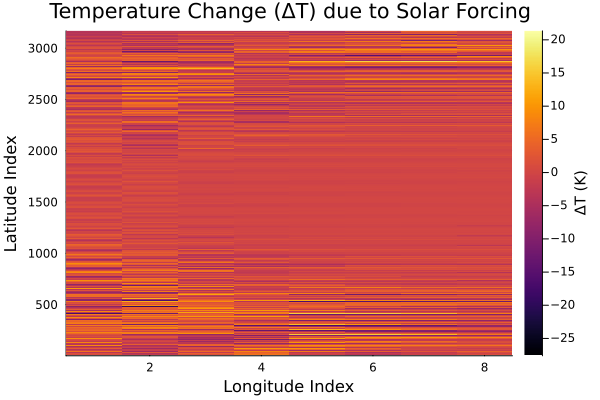

In [16]:
from IPython.display import Image
Image("deltaT2k.png")

In [14]:
import statistics

dT = "0.8698273 -3.53273 3.0606384 4.136261 -2.3192902 -3.1306763 -1.4665222 -0.72525024; 0.75923157 -3.0174255 2.5459747 3.3692474 -3.8236237 -3.9238281 -1.3632202 -0.7195282; 0.79333496 -2.5456238 2.1879272 2.9064636 -5.0808716 -4.712509 -1.2641296 -0.60658264; 0.8413086 -2.064087 1.9834137 2.7736053 -5.96727 -5.41008 -1.2054596 -0.37023926; 0.8079071 -1.5918579 1.8464661 2.9541779 -6.339966 -5.8820953 -1.1869202 -0.032714844; 0.67276 -1.2193451 1.6780548 3.4111328 -6.0927124 -6.014496 -1.199707 0.32643127; 0.49150085 -1.056488 1.4520416 4.0750275 -5.239807 -5.763748 -1.2270813 0.6105194; 0.37335205 -1.179596 1.2502594 4.8322296 -3.9487457 -5.1680756 -1.2255096 0.77700806; 0.4406433 -1.6001129 1.2098389 5.546753 -2.4811249 -4.328827 -1.1262817 0.8791809; 0.77500916 -2.2576904 1.4204254 6.112686 -1.078598 -3.373413 -0.8772583 1.0273895; 1.3708649 -3.0417938 1.8619232 6.499161 0.12211609 -2.4153137 -0.49163818 1.2931213; 2.1230164 -3.8347778 2.434082 6.748596 1.0958557 -1.5331573 -0.053863525 1.644455; 2.8598938 -4.55217 3.0334778 6.932434 1.879715 -0.77963257 0.31777954 1.9602051; 3.4066772 -5.1506653 3.596222 7.1024475 2.5118866 -0.2069397 0.51216125 2.0918884; 3.6433868 -5.597687 4.080124 7.2610626 2.976715 0.11741638 0.45214844 1.93013; 3.5314484 -5.8346863 4.4314575 7.345276 3.1709595 0.12637329 0.12501526 1.4627533; 3.1093903 -5.7852783 4.5845947 7.235031 2.9335632 -0.20103455 -0.38763428 0.8028259; 2.47937 -5.4210815 4.493042 6.813629 2.154007 -0.8032532 -0.9234772 0.14492798; 1.7932129 -4.8210144 4.1585083 6.060974 0.87924194 -1.5557709 -1.3161011 -0.34532166; 1.217804 -4.1454163 3.6426086 5.0984497 -0.69143677 -2.3453522 -1.4850159 -0.61891174; -2.3016663 -1.6424103 1.5368652 1.9959869 -2.3491058 -1.7988281 -2.0322113 -1.1807556; -1.9607086 -1.6799469 0.6543579 0.50938416 -4.063675 -2.4283295 -1.4955139 -1.2702179; -1.1751862 -1.7727203 0.28822327 -0.26823425 -5.7439117 -3.651825 -1.3605347 -1.5402069; -0.45037842 -1.3969269 0.5196686 -0.6062622 -7.6121674 -5.3038177 -1.4992065 -1.5848541; -0.11364746 -0.45106506 1.1247101 -0.7171478 -9.404831 -6.877655 -1.6367035 -1.1881866; -0.25315857 0.7710724 1.6434784 -0.56721497 -10.521881 -7.917404 -1.6362305 -0.39286804; -0.8141327 1.8834534 1.5814972 -0.0018463135 -10.378525 -8.219299 -1.5681915 0.5661621; -1.6763153 2.6249847 0.70014954 1.0536957 -8.749664 -7.7784424 -1.6163788 1.288681; -2.6282806 2.8394928 -0.7237549 2.48909 -5.981125 -6.6901245 -1.8879242 1.3769684; -3.3475647 2.4214478 -1.9464722 3.9872437 -2.8780518 -5.1477814 -2.2229614 0.8248596; -3.4838257 1.3848267 -2.2318726 5.1379547 -0.25152588 -3.4538727 -2.2453918 0.17036438; -2.7993164 -0.06352234 -1.3959503 5.69339 1.5258636 -1.9108582 -1.6920471 0.07084656; -1.2789917 -1.589035 0.097351074 5.7476044 2.5734406 -0.66516113 -0.66096497 0.75120544; 0.8282013 -2.8801422 1.5680237 5.6365204 3.1959991 0.31297302 0.5104065 1.9500732; 3.0713196 -3.7825623 2.6316528 5.6522064 3.6190796 1.1329803 1.5646973 3.2792969; 4.9673767 -4.3795013 3.3437958 5.883301 4.014694 1.9144592 2.4410095 4.456787; 6.1735992 -4.947159 3.959137 6.3321686 4.6291656 2.719757 3.0791473 5.2201996; 6.5634155 -5.73291 4.5985107 7.079712 5.695648 3.4322662 3.2219238 5.21109; 6.1981354 -6.6601257 5.111435 8.157547 7.08284 3.7365112 2.55336 4.1418457; 5.201828 -7.2317047 5.254715 9.209824 8.055145 3.3253174 1.0735931 2.1674347; 3.6543884 -6.8728485 4.9780426 9.522415 7.6705475 2.173462 -0.7483063 0.011978149; 1.6890411 -5.495865 4.415909 8.600235 5.647827 0.6518402 -2.2351074 -1.4418488; -0.3092804 -3.6825104 3.6384125 6.6037445 2.695877 -0.6553345 -2.896576 -1.8101349; -1.77005 -2.249527 2.6355133 4.1716614 -0.14793396 -1.3994904 -2.689148 -1.4811554; -5.508377 0.6915283 0.47459412 0.06427002 -1.8308411 0.59350586 -0.8366394 0.1373291; -4.6968384 -0.36894226 -0.029037476 -1.3919983 -1.9068756 0.9910736 0.16781616 0.14831543; -3.2635803 -1.5790558 -0.38879395 -1.8699341 -2.26445 0.07417297 0.059326172 -0.5463867; -1.8569183 -2.0456085 -0.26760864 -1.9267731 -3.7621002 -2.0619965 -0.7808533 -1.2067566; -0.9547882 -1.400238 0.50668335 -2.1936493 -6.369034 -4.5851135 -1.6252594 -1.4620361; -0.72106934 0.03527832 1.72229 -2.7103271 -9.290604 -6.638504 -2.0799408 -1.3348083; -1.047287 1.591568 2.8332367 -3.0747528 -11.534058 -7.829834 -2.125183 -0.8505554; -1.7926636 2.8212433 3.0697021 -3.0014648 -12.186874 -8.176712 -1.8462982 0.12478638; -2.8926697 3.6707306 1.7190247 -2.3937073 -10.663757 -7.7777405 -1.4684143 1.3971863; -4.227112 4.141449 -1.2363739 -1.1430206 -7.171631 -6.6484528 -1.4232483 2.1002655; -5.5258484 4.057907 -4.7017365 0.67736816 -2.8253632 -4.836334 -1.9023285 1.4839172; -6.418152 3.2304077 -6.9714966 2.5477295 0.94873047 -2.6326904 -2.4525146 -0.04737854; -6.537628 1.7186737 -6.876999 3.7677002 3.2677002 -0.5764618 -2.3613129 -1.2069702; -5.6253967 -0.11807251 -4.6116943 4.0136566 4.212921 0.90185547 -1.38237 -1.1162415; -3.5956573 -1.8303375 -1.5150299 3.594986 4.501419 1.7864532 0.04866028 -0.00036621094; -0.64424133 -3.0414886 0.9853668 3.1832428 4.7028503 2.2791748 1.2673492 1.3852234; 2.6987915 -3.4904938 2.2985992 3.2392273 4.815338 2.478592 2.0077667 2.6386414; 5.8054504 -3.2080078 2.7478943 3.6831512 4.595398 2.480133 2.5901337 3.8835144; 8.202301 -2.62648 3.0128632 4.122101 4.081772 2.638855 3.5262604 5.347748; 9.571899 -2.415924 3.5771484 4.394745 3.8248596 3.376587 4.897278 6.8888245; 9.788086 -3.199051 4.4162903 4.9838257 4.735626 4.643036 6.0394287 7.7940063; 9.051605 -5.0722656 4.914505 6.622574 7.2957153 5.8490143 5.998413 7.143753; 7.7249603 -7.145157 4.3504486 9.064163 10.478394 6.343506 4.4479065 4.653061; 5.884796 -7.9294586 2.8503418 10.731934 11.930069 5.7117157 1.9687347 1.1401672; 3.2907257 -6.587494 1.4782104 10.296829 10.081375 3.9120789 -0.5723114 -1.927475; 0.026824951 -3.737976 0.9704895 8.064423 5.873123 1.5928497 -2.4752045 -3.2903595; -3.092743 -0.90678406 0.9779358 5.1958923 1.6909637 -0.029556274 -3.13562 -2.6561127; -5.071884 0.6746063 0.863739 2.4063263 -0.9005585 -0.18882751 -2.3470764 -1.0174255; -6.4401245 3.1108704 1.8509369 -0.38179016 -2.2776642 0.6659241 -0.082717896 0.44018555; -5.7167816 2.0583496 2.6090393 -1.7617035 -1.2067719 2.2190552 1.7000885 1.3489075; -4.5678406 0.55184937 2.1795654 -2.2773438 0.09988403 2.5789337 2.0437012 1.4091492; -3.1339874 -0.8220825 1.1325378 -2.081421 0.23693848 1.3437195 1.2020569 1.0258484; -1.7720642 -1.4729309 0.5207062 -2.0487366 -1.464508 -1.0021515 0.02420044 0.5449524; -0.9689789 -1.1212158 0.81126404 -2.6447906 -4.4038696 -3.5039215 -0.9160309 0.053009033; -0.9107208 -0.086883545 1.8088379 -3.4137726 -7.646637 -5.4457397 -1.6922455 -0.6999512; -1.3820648 0.9273224 3.0814056 -3.8078003 -10.455399 -6.685684 -2.5053864 -1.6936035; -2.1259308 1.5446625 3.8774414 -4.0318756 -11.961563 -7.3216248 -2.9677887 -2.067749; -2.9912872 1.8564911 3.0574646 -4.443695 -11.303406 -7.307022 -2.5749817 -1.0406189; -3.8237915 1.9055786 -0.09448242 -4.630966 -8.364517 -6.4765472 -1.6777191 0.6548004; -4.542862 1.5737305 -4.9091644 -3.8458405 -4.0441437 -4.755188 -1.100174 1.4227448; -5.173523 0.81825256 -9.48082 -2.0635376 0.24603271 -2.2811737 -0.9389343 0.82336426; -5.6094513 -0.3527832 -11.78273 -0.07803345 3.357132 0.44622803 -0.5415039 -0.04560852; -5.5815735 -1.8231506 -10.865707 1.2761841 4.9331055 2.6571198 0.5276184 0.020874023; -4.8490295 -3.2605743 -7.4795227 1.7147675 5.482666 3.9564667 2.0303802 1.0427551; -3.183014 -4.3836975 -3.5482635 1.5692902 5.9264374 4.617859 3.2948456 2.0187378; -0.52531433 -4.9943542 -0.76916504 1.4971771 6.695175 4.9539185 3.7319183 2.240265; 2.7132263 -4.7644653 0.41201782 1.9247437 7.3425903 4.8446503 3.293396 1.9681702; 5.9657745 -3.608612 0.67276 2.7295532 7.2598877 4.042053 2.4799957 1.8344421; 8.900421 -1.9554138 0.9238434 3.5041199 6.256073 2.7670135 2.039322 2.2464294; 11.208237 -0.3257141 1.6672516 3.744217 4.4566345 1.9544525 2.6574402 3.40036; 12.411636 0.75823975 3.0151367 3.125229 2.5350342 2.4803772 4.4697723 5.23053; 12.1853485 0.4862213 4.6710052 2.4378967 2.0442047 4.1494293 6.59758 7.02124; 10.771286 -1.6829681 5.5909424 3.4047394 4.5014496 6.099182 7.688339 7.5616913; 8.855087 -4.947586 4.3563843 6.3157043 9.391235 7.845291 7.274994 6.2694244; 6.8601074 -7.287567 0.85684204 8.751999 13.388168 9.051559 6.023178 3.7430725; 4.4574738 -7.0069885 -2.7608185 8.193008 12.9605255 8.80661 4.40419 0.8186188; 1.1837158 -4.1703033 -4.1158905 5.2769165 8.217834 6.359024 2.060669 -1.9738159; -2.469162 -0.5080261 -3.1405487 2.7593079 2.660965 2.5829163 -0.83825684 -3.69133; -5.2530212 2.1766968 -1.3632355 1.7433167 -0.9079895 -0.279953 -2.6961975 -3.3427124; -6.4742126 3.2845917 0.350708 1.0001678 -2.3080444 -0.73387146 -2.1928864 -1.4288635; -3.9833221 6.1748657 4.629181 1.4262543 -4.4626923 -3.6468658 -3.0552216 -2.645935; -3.9967194 6.223465 6.8489685 -0.083618164 -3.9404907 -1.4183807 -0.65431213 -0.7404785; -4.0358276 5.437256 6.3785553 -1.3802032 -1.8864594 0.73773193 1.0458374 0.95513916; -3.496109 3.6857758 3.7699127 -1.7665253 0.18397522 1.7871857 1.7210388 1.8578491; -2.2789764 1.4467926 1.0804596 -1.5679016 0.6195679 1.0717468 1.3232574 1.7536621; -0.9900055 -0.3210144 -0.24090576 -1.6761627 -0.7019501 -0.9631958 0.37631226 1.1554565; -0.40133667 -0.8580475 -0.28240967 -2.3370972 -2.9569092 -3.1753387 -0.4944458 0.47558594; -0.6759949 -0.4329071 0.29730225 -2.760437 -5.578171 -4.921631 -1.5913696 -0.7472534; -1.4347382 0.06892395 1.227417 -2.542221 -8.193588 -6.287628 -3.4412994 -2.9603271; -2.2971191 0.24160767 2.223587 -2.6542664 -10.06041 -7.3945007 -5.321289 -5.0730896; -2.917801 0.11975098 2.3045502 -4.1211395 -10.401962 -7.9457703 -5.782013 -5.209717; -2.9562836 -0.49316406 0.37217712 -6.4135895 -9.051361 -7.495468 -4.526291 -3.32753; -2.4485016 -1.7272797 -3.5451965 -7.931534 -6.432968 -5.9580994 -2.675064 -1.2851868; -1.9131622 -3.1209717 -8.159485 -7.7152863 -3.274887 -3.506607 -0.9990845 -0.1435852; -1.7651367 -4.2005615 -11.811218 -6.1614227 -0.3280487 -0.32113647 0.8880768 0.7550049; -1.8348541 -5.087738 -13.156967 -4.234253 2.003067 3.0062256 3.3103485 2.3283691; -1.7909088 -5.9375 -11.761307 -2.5405884 3.7404633 5.562134 5.8302307 4.607666; -1.5329437 -6.5295715 -8.590775 -1.2312164 5.250763 7.1235657 7.7800293 6.5104675; -0.77334595 -6.8206787 -5.4542084 -0.23956299 7.1013184 8.150543 8.63353 6.699341; 0.84788513 -6.846512 -3.654129 0.6636505 9.273941 8.731857 8.195923 5.1723633; 3.1302643 -6.167328 -3.2343597 1.6177521 10.810562 8.557709 6.786133 3.2780151; 5.677017 -4.5557556 -3.267212 2.4354248 11.012207 7.4615784 4.935013 2.064392; 8.32962 -2.54982 -2.7777405 3.170227 10.10582 5.37442 3.0269623 1.4840698; 10.796143 -0.58454895 -1.4949341 4.126816 8.2478485 2.8000793 1.521637 1.1697693; 12.5533905 1.4398041 0.4232788 4.5840607 5.2483063 1.2080078 1.1877441 1.3038635; 13.15239 3.296112 2.8797607 3.2867584 1.7281342 1.6106415 2.5025482 2.3746033; 12.38913 3.9221497 5.5358276 0.97099304 -0.4185028 3.3076782 4.7308044 4.1019897; 10.414261 2.4099731 7.293442 0.3748169 0.8260956 5.1359863 6.4375153 5.262207; 7.8105927 -0.750824 6.4187775 2.7299805 5.6996613 7.134796 7.232025 5.310364; 5.334671 -3.825348 2.122757 5.486496 11.297852 9.753723 7.9957886 5.206787; 3.1853638 -4.93396 -3.551834 4.901703 12.977905 11.949341 9.003265 5.4519653; 0.80574036 -3.2149506 -6.984482 0.7848053 9.065475 11.436295 8.620148 4.495819; -1.9637299 0.31982422 -6.7248077 -2.8605194 2.956894 7.213684 5.064148 1.0394592; -4.142441 3.5143433 -4.409363 -2.7486267 -1.2526855 1.1905212 -0.5036011 -3.08432; -4.822815 5.174301 -1.7680054 -0.1078186 -2.9556732 -3.3738708 -4.5449066 -4.9851074; -4.4103394 5.7989655 1.2376099 1.7364044 -3.8057404 -4.7784424 -5.04126 -4.3520203; 1.1776886 8.523834 6.651932 3.0546112 -5.7451935 -8.034531 -7.0020905 -6.205597; 0.27742004 9.770035 9.501923 2.1638794 -6.360077 -6.3337708 -5.319458 -4.5558167; -0.9261017 9.884506 9.200439 0.51753235 -4.853485 -3.3608246 -2.770279 -1.9729309; -1.6106567 8.230484 5.763321 -0.8561859 -1.995163 -0.23448181 -0.008483887 0.38168335; -1.3717499 5.0938873 1.4427185 -1.1491699 0.31759644 1.0509033 1.1424866 1.1106262; -0.45547485 1.6535187 -1.2194366 -0.73101807 0.9082947 -0.2861023 -0.09277344 0.03878784; 0.29312134 -0.5540924 -1.6388855 -0.7338867 -0.031448364 -2.8549805 -2.0429382 -1.3860779; 0.2434845 -1.0029144 -1.1044312 -1.3133698 -1.6876068 -4.9315186 -3.041504 -1.9949341; -0.44996643 -0.5981293 -0.8252411 -1.4065704 -3.5819702 -6.117111 -3.619629 -2.448059; -1.4057617 -0.33251953 -0.82192993 -0.7305145 -5.513916 -6.972458 -5.075638 -4.13031; -2.3386993 -0.32836914 -0.6034851 -0.68177795 -7.1358185 -8.027359 -7.2792664 -6.673584; -2.7707214 -0.5083313 -0.38954163 -2.6411438 -8.200943 -9.106705 -8.69902 -7.8699036; -2.2833557 -1.2463684 -1.1085358 -6.300827 -8.723953 -9.4027405 -8.195068 -6.78125; -1.0667572 -2.685501 -3.1320038 -9.8793335 -8.604614 -8.515823 -6.3770294 -4.895813; 0.23027039 -4.1929474 -5.7344055 -11.678207 -7.705429 -6.7362213 -4.398224 -3.4479065; 1.0685272 -5.096283 -8.029816 -11.430191 -6.2412415 -4.0733795 -2.0520782 -1.8658142; 1.383255 -5.485855 -9.498825 -10.028809 -4.470398 -0.3786621 1.313797 0.6597595; 1.5111542 -5.887024 -9.696762 -8.249023 -2.2710876 3.6100159 5.225815 4.0558167; 1.5498962 -6.340927 -8.580307 -6.242401 0.45965576 6.8990936 8.756363 7.6783752; 1.2943573 -6.510498 -6.9581604 -4.030136 3.6464996 9.521072 11.379074 10.19136; 1.1052094 -6.572937 -5.92984 -1.9028931 7.3618164 11.764206 12.679977 10.197144; 1.6331177 -6.768921 -5.911682 -0.11804199 11.182236 12.951965 12.385178 7.985901; 2.8718567 -6.4876556 -6.5009003 1.267456 13.712097 12.530472 10.847839 5.4064636; 4.6594086 -5.2146606 -6.8970337 1.9447174 14.109024 11.135391 8.752029 3.8607788; 7.0087433 -3.397873 -6.345688 2.0005493 13.129639 9.148163 6.4174957 3.2148743; 9.362106 -1.4685669 -4.8298492 2.7852783 11.5286255 6.14563 3.9148254 2.5487976; 10.908463 0.7050934 -2.7990417 4.8677826 8.905319 2.7387848 1.6188812 1.4632874; 11.473038 3.1799011 -0.19293213 6.150223 5.0117493 0.7665558 0.39291382 0.521698; 11.285919 5.440155 3.0955963 4.4750824 0.88700867 1.0694885 0.940094 0.69311523; 10.384872 6.570236 6.414871 0.85180664 -1.742096 2.5555267 2.6969757 2.0387573; 8.576645 6.0434265 8.739349 -1.4913788 -1.6018829 3.9061737 4.3231354 3.2485352; 5.9009705 4.1979065 8.855118 -0.6214905 1.5340424 5.32695 5.5495605 3.6382751; 3.0956879 1.7930756 5.7246246 1.9124298 6.307068 7.782242 7.2483215 4.470764; 1.0684509 -0.17559814 0.22207642 2.4893646 9.199188 10.831131 9.759598 6.908142; -0.19699097 -0.35240173 -4.5361633 -0.67352295 7.2694855 12.1727295 11.571152 9.306702; -1.2830353 1.7441254 -6.021759 -5.090317 2.2299042 9.710571 9.931335 8.111435; -2.0000153 4.6335297 -4.6460876 -6.4799805 -1.8469238 3.914856 4.1919556 2.6987; -1.6071472 6.416275 -2.4530182 -3.8313599 -3.4542236 -2.3866577 -2.5151062 -3.0994568; -0.22599792 6.906662 -0.2642517 0.034622192 -3.733368 -6.631607 -6.6941376 -6.0933533; 1.016571 7.354782 2.7439117 2.4975739 -4.3588104 -8.280685 -7.7561493 -6.7295837; 6.4663544 8.272842 6.7626953 2.5638428 -2.7534943 -7.0504 -6.445999 -5.6925964; 5.166092 10.130997 9.171188 3.1233368 -3.9925232 -7.015381 -6.551178 -5.368622; 3.5355835 10.770081 9.264786 2.1875916 -3.8314972 -4.9153748 -4.630081 -3.4575806; 2.1210327 9.419937 6.2556 0.40145874 -1.9277954 -1.2330627 -0.92562866 -0.53796387; 1.3021545 6.2429047 1.4580994 -0.8541565 0.68333435 1.3879547 1.7156677 1.3981018; 1.2455597 2.3153229 -2.126114 -0.7255707 2.2316284 0.5508423 0.45892334 0.17764282; 1.5507355 -0.61520386 -2.6541595 -0.024536133 1.6772766 -2.936676 -3.572586 -3.2490845; 1.4398499 -1.4720917 -1.1164246 -0.1502533 -0.19386292 -6.314911 -6.7761536 -5.8077087; 0.7811432 -0.9667816 0.3541565 -0.93504333 -1.9387207 -8.038361 -7.4839783 -6.0590515; -0.058563232 -0.4781952 0.48750305 -1.0906525 -3.0572662 -8.287323 -6.771744 -5.0263367; -1.0071411 -0.48980713 -0.5481262 -0.51979065 -3.9285736 -7.913101 -6.3518677 -4.7988586; -1.9320679 -0.6326904 -1.7118835 -0.536026 -4.9712677 -8.054367 -7.1984406 -6.2012024; -2.1964111 -0.80358887 -2.285324 -2.254593 -6.476425 -9.262543 -8.929901 -7.821869; -1.3829346 -1.3759918 -2.5908966 -5.7750397 -8.431076 -10.617249 -9.968735 -8.199524; -0.003479004 -2.124588 -3.2589417 -9.996002 -10.242233 -11.073227 -9.619049 -7.640747; 1.1862183 -2.2892761 -4.012268 -13.039398 -11.286453 -10.774261 -8.842758 -7.0379944; 2.0992126 -1.8705444 -4.2042084 -13.876083 -11.452881 -9.848251 -7.847687 -6.166809; 2.8872528 -1.5969543 -3.959076 -13.098206 -10.900757 -7.526947 -5.5759125 -4.2378235; 3.4189453 -1.9107513 -3.629593 -11.658707 -9.451263 -3.5886383 -1.9304047 -1.3227844; 3.6028748 -2.7026367 -3.2833862 -9.800995 -6.663101 0.9302521 2.1555634 2.0958252; 3.2845306 -3.5107422 -3.1459808 -7.4392395 -2.6187286 5.2877045 6.252594 5.849304; 2.3077393 -4.037796 -3.6609802 -4.7542267 2.119812 9.727707 10.290344 9.082733; 1.2619019 -4.684677 -5.0428314 -2.2976074 7.1866913 13.9231415 13.504395 10.311462; 0.97491455 -5.800354 -6.772766 -0.4348297 12.0334015 16.155487 14.672409 9.165436; 1.4937897 -6.646332 -8.069077 1.0640869 15.259293 15.4869995 13.554779 6.8275757; 2.7355042 -6.326889 -8.584198 1.970871 15.860199 13.401428 11.167053 4.8682556; 4.8604736 -4.896042 -8.037888 1.6420898 14.689865 11.3884735 8.489899 3.9111328; 7.210388 -2.590332 -6.526886 1.1806488 13.056931 8.932861 5.925308 3.362152; 8.682312 0.37921143 -4.8547516 2.6615448 10.857513 5.4868317 3.6152039 2.5569458; 9.142441 3.288025 -3.1317139 5.50235 7.5414734 2.1193542 1.6094513 1.389801; 9.148773 5.4897003 -0.4763031 6.794174 3.593872 0.26985168 0.29589844 0.16366577; 8.961212 6.8750916 3.1218567 5.1250916 0.18580627 0.28501892 0.3052063 -0.1706543; 8.401794 7.573517 6.4300995 1.6396027 -1.6227264 1.3444214 1.339508 0.8486023; 7.1200867 7.762558 8.616104 -1.4655304 -1.6657562 2.439972 2.4386597 2.0304565; 4.969452 7.5442047 9.398071 -2.4025269 -0.6412811 3.5297394 3.603119 2.5700684; 2.553772 6.64682 8.108307 -1.2467041 1.2263641 5.223694 5.3026733 3.304718; 0.9990692 4.8732758 4.62027 0.035720825 3.1393127 7.3131714 7.296051 5.0516663; 0.73043823 3.256424 0.59236145 -0.55934143 2.7596893 8.364899 8.786758 7.324127; 1.2036743 3.242859 -1.682373 -3.0295258 0.01927185 6.925705 8.280579 7.8993225; 2.010254 4.597534 -1.4803772 -4.9490814 -2.3717499 3.2533112 4.8461 4.915436; 3.2915955 5.7677765 0.020629883 -4.4372253 -3.405838 -0.6302948 0.28497314 0.25186157; 4.9690094 5.9581146 1.347702 -2.534378 -3.4873047 -3.1853638 -2.789215 -2.7315369; 6.3977203 5.8393555 2.3100433 -0.7409363 -2.6025696 -4.6765137 -4.2393646 -3.8469238; 6.9510803 6.5290375 3.9855957 0.9792023 -1.9262238 -5.9654236 -5.3773193 -4.8140564; 8.167297 7.283203 5.3164215 2.7769012 2.8231506 -2.060318 -2.2876282 -2.0968323; 7.389145 8.735046 7.058075 4.1708374 1.3259277 -3.263153 -3.2884521 -2.4692688; 6.2265015 9.180649 7.409073 3.8668213 0.5188446 -2.4907227 -2.4145203 -1.6865234; 4.905548 8.030075 5.332321 2.0654144 1.002945 0.54182434 0.756897 0.7203064; 3.7787933 5.2679596 1.0934143 -0.31314087 2.7560272 3.6254425 3.94812 3.612854; 3.2059479 1.6279297 -2.693283 -1.5304413 4.191986 3.298935 3.3098145 3.1316223; 3.2097015 -1.341919 -3.3715973 -1.0235138 3.2066803 -0.8046875 -1.4117432 -1.4906921; 3.0288696 -2.1508942 -1.2638092 -0.43214417 0.06414795 -5.6425934 -6.559906 -6.226715; 2.1735382 -1.091217 1.5652313 -1.07547 -3.0172577 -8.81337 -9.385788 -8.417633; 1.0970001 0.24511719 3.5078125 -2.0224 -4.4808197 -10.177322 -9.870331 -8.3593445; 0.16685486 0.80519104 3.7122345 -2.0414429 -4.5167694 -10.058609 -8.798248 -6.86322; -0.69970703 0.5823364 2.156952 -1.587265 -4.2474365 -8.728424 -6.987854 -5.2926025; -1.3867035 0.21546936 -0.22322083 -1.6923676 -4.643097 -7.664673 -6.086624 -5.1100464; -1.3445435 -0.07583618 -2.0477753 -2.7738647 -6.2931213 -8.41098 -7.369919 -6.4985657; -0.20452881 -0.65911865 -2.6967926 -5.240387 -8.951538 -10.343933 -9.639999 -8.43396; 1.4903107 -0.9951935 -2.7804718 -9.081894 -11.516327 -11.988098 -11.018372 -9.749115; 2.7634277 0.11924744 -2.621582 -12.74823 -13.424835 -13.174835 -11.737122 -10.110565; 3.5115662 2.3417969 -1.6520538 -14.520081 -14.771942 -14.119522 -12.371719 -9.715759; 4.3558655 3.8607483 -0.045578003 -14.412735 -15.294556 -13.951324 -11.887604 -8.353943; 5.1495056 3.7470856 1.316803 -13.369507 -14.477554 -11.641541 -9.602081 -5.906433; 5.1529694 2.4964752 2.1569977 -11.573456 -11.98436 -7.5608826 -6.2377777 -3.1357117; 4.2769623 0.78819275 2.2904663 -8.827728 -7.786392 -2.7031097 -2.3339844 -0.46261597; 2.7832336 -0.9773712 1.3258057 -5.638611 -2.3119965 2.8092499 2.4124146 2.708252; 0.8665924 -2.6367493 -0.8227234 -2.8264313 3.520218 9.135422 8.18692 6.3597107; -0.85154724 -4.4132996 -3.8812866 -0.93925476 8.869019 15.129959 13.710556 9.170776; -1.61026 -6.5484924 -6.7817993 0.18333435 13.335815 18.286377 16.430649 9.714111; -1.3299866 -8.399643 -8.356323 1.5842438 16.169525 17.380219 15.230164 7.8426514; -0.22286987 -8.828537 -8.660187 3.3405762 16.50087 14.324783 11.727402 5.1056213; 1.7233887 -7.4529114 -8.0186 3.762619 14.894592 11.457916 8.033478 3.2317505; 3.9664001 -4.328781 -6.427902 2.423996 12.833618 8.861313 5.1190643 2.3640747; 5.5722046 0.08328247 -4.578064 1.5708466 10.723419 6.024048 3.2980042 1.8684998; 6.504135 4.1546936 -3.258484 2.7082367 8.12294 3.4824982 2.379303 1.6368713; 7.281128 6.455887 -2.0500793 4.4463806 5.253296 1.7247925 1.6469269 1.214386; 7.9533386 7.0976562 -0.04057312 5.177246 2.6516724 0.60343933 0.7878113 0.004760742; 8.225464 6.983368 2.587204 4.8204193 0.5866699 0.07748413 0.2626648 -0.9472046; 7.893097 6.989731 4.7643127 3.3533936 -0.19758606 0.14263916 0.11087036 -0.6343384; 6.9418793 7.466629 6.150345 1.0311584 0.3948822 0.5310974 0.022064209 -0.10513306; 5.511429 8.147202 7.0103455 -0.7411194 0.5228119 1.315628 0.70196533 0.23880005; 4.105194 8.33284 6.9253845 -1.1734314 -0.4705658 2.6667938 2.4868774 1.3534546; 3.5420685 7.2570496 5.3640747 -0.86979675 -1.1127472 3.8622284 3.896515 2.6551208; 4.102249 5.3661804 3.0658264 -0.61283875 -1.6815491 3.7239532 3.7319336 2.876892; 5.2901 4.147766 1.7755432 -0.9608002 -2.9440002 1.691925 2.0901031 1.8848267; 6.6211853 4.0475006 2.336029 -1.5243378 -3.370575 -1.292984 -0.43673706 -0.111328125; 7.901993 4.2716827 3.7531128 -1.2902832 -2.765091 -2.7805023 -2.131546 -1.9055481; 8.884735 4.2738037 4.6196747 -0.9434662 -2.5473328 -1.4685059 -1.3135223 -1.6222534; 9.284866 4.202072 4.383072 -1.5346527 -1.6227417 0.8170624 0.78401184 0.07678223; 9.125412 4.5325623 3.6235352 -1.6379242 1.1019592 1.4612732 1.3202515 0.59902954; 8.696701 5.6346436 3.7602234 0.21412659 3.2264252 0.018508911 -0.2810974 -0.67892456; 4.8709106 8.293533 4.5968933 6.579788 5.9068604 1.9320068 0.86416626 0.52230835; 5.337921 8.466446 5.81398 7.423065 4.4424896 1.1297302 0.6515503 0.7805481; 5.397293 7.944046 5.6694794 6.8735657 3.9036102 1.4472809 1.2428894 1.243103; 4.984009 6.51915 3.872116 4.807434 3.9257202 3.5994873 3.506958 2.8640137; 4.4745636 4.049881 0.515625 1.1637726 4.849472 6.3904114 6.3358765 5.920532; 4.182617 0.99598694 -2.6347656 -1.9624023 5.748047 6.337982 6.092804 6.353546; 4.250107 -1.5812378 -3.0917969 -2.4272308 4.27652 2.241333 1.7909546 1.6690674; 4.100586 -2.2589722 -0.87931824 -1.3333435 0.35935974 -2.9618835 -3.2397156 -3.6844177; 3.0236816 -0.82762146 2.1370392 -1.3015289 -3.6181793 -6.4180145 -6.3266296 -5.932953; 1.3810577 1.2871857 4.903076 -2.4382935 -5.9252014 -8.273422 -7.9740295 -6.881073; -0.14886475 2.926712 6.940384 -2.8054504 -6.351288 -9.617569 -9.111267 -7.867401; -1.2745209 3.5185852 7.527725 -1.8958588 -5.5338135 -9.986694 -9.13501 -7.6561584; -1.733078 2.8925934 6.181122 -1.0695496 -4.504944 -8.654007 -7.5161133 -6.107422; -1.4433441 1.9653473 3.2960205 -1.1765594 -4.287033 -7.1430054 -5.853348 -4.7641907; -0.45394897 1.4518433 0.35188293 -1.9328918 -5.8103027 -7.5015564 -6.3423767 -5.1863403; 1.2797699 0.9651489 -1.2418213 -3.6388855 -8.886108 -9.33577 -8.6138 -7.465576; 3.4732056 0.79855347 -1.6520538 -6.9931946 -11.880951 -11.331375 -10.726501 -9.993988; 5.3669586 2.1892242 -1.5110016 -11.059509 -14.09642 -13.33989 -12.368271 -11.377014; 6.4366913 5.090622 -0.32684326 -13.9218445 -16.123627 -15.287399 -13.976028 -11.470795; 6.972595 7.648575 1.8919678 -14.927109 -17.514877 -16.259064 -14.560104 -10.383057; 7.1791534 8.410645 3.706131 -14.735291 -16.956772 -15.191132 -13.176971 -7.921936; 6.356064 7.5392456 4.5758057 -13.570847 -14.093033 -11.996002 -10.324158 -4.596161; 4.140518 5.588455 5.0638885 -10.715027 -9.643494 -7.653076 -6.669739 -1.7949829; 1.2326508 2.7899933 4.8678284 -6.317627 -4.1462097 -2.6635742 -2.3621216 0.11953735; -1.6599426 -0.54138184 3.4243622 -2.0820312 2.2342682 3.4166565 2.8614197 2.330017; -4.269455 -3.9358826 0.7319031 0.52033997 8.383972 10.589539 9.408508 5.704132; -6.288437 -7.036087 -2.9884644 1.2841034 12.877899 17.1931 15.839386 9.248505; -7.1800995 -9.85054 -6.4537506 1.3455505 15.666092 20.280853 18.553284 10.571808; -6.7004547 -12.06282 -8.02153 2.6524048 16.969254 18.567093 15.960724 8.515076; -5.152832 -12.61879 -7.786911 5.379608 16.32129 14.330902 10.626709 4.82251; -2.8717651 -10.959 -6.6409607 7.0176544 13.972824 10.350998 5.7628174 2.0612793; -0.3282776 -7.207657 -4.770294 5.8525085 11.18045 6.974365 2.512848 0.85562134; 1.7928314 -1.791687 -2.444641 3.426834 8.70105 3.9606018 0.9378662 0.4234619; 3.4228516 3.5719604 -0.345047 2.2580566 6.5157623 2.2618713 0.9242859 0.6186218; 4.899658 6.880905 1.035965 2.5919037 4.875595 2.3697815 1.9651489 1.523346; 6.1389008 8.016983 1.6716309 3.1624756 4.1098022 3.1115112 2.9808044 1.894928; 6.9739685 7.8259735 2.0742035 3.907898 3.5576477 3.1408691 3.020691 0.7275696; 7.4223785 7.034363 2.5518646 4.9823456 2.5161743 2.2727356 2.0733643 -0.6045227; 7.4792023 6.543503 2.8007507 5.1069946 2.1199036 0.8490753 0.31695557 -1.0332642; 7.251938 6.686844 2.9342346 3.887497 3.2653656 -0.707428 -1.8317261 -1.8627625; 6.8722534 7.1636963 3.328659 2.735962 3.6163635 -1.3374329 -2.576233 -2.9233398; 6.5423737 7.5296936 3.5140076 2.031952 1.3007812 -0.39759827 -0.9205017 -2.0007324; 6.7416077 6.926178 2.8251495 1.0239868 -1.5393982 0.8153229 0.84381104 0.09182739; 7.6015625 5.2135773 1.6356354 0.14257812 -3.157486 0.5523071 0.11166382 0.16662598; 8.636948 3.6477203 1.4985657 0.0053710938 -4.1366577 -1.5575104 -2.7615662 -2.2552185; 9.4092865 3.0574493 3.496582 0.3747406 -3.9243622 -4.5364075 -5.659088 -4.944031; 9.659897 3.194336 6.2081146 1.3882751 -2.4178314 -5.872635 -6.2325134 -5.5630493; 9.104996 3.7912598 7.293335 2.3158722 -1.5554047 -3.317276 -3.164856 -2.9325256; 7.7275085 4.682358 6.3588715 1.3860779 -0.8901062 1.6489868 1.7098389 1.2849731; 6.087494 5.58165 4.48291 -0.29415894 2.0179443 5.11763 4.611328 3.5238342; 4.9447937 6.4699707 3.0055084 0.5151062 5.9559784 5.2932434 4.0534973 2.7770386; 4.590988 7.484558 3.1184387 3.8062897 7.310852 3.5541077 2.0426636 1.1643982; -0.21963501 9.501221 6.7794495 11.101517 4.798233 3.8199158 2.6629944 2.0127258; 1.3934631 8.645615 6.9864655 10.813324 4.0324707 4.030304 3.363678 2.9578552; 2.8517609 7.1973724 5.443283 9.982269 4.643448 4.3503113 3.887268 3.60672; 3.7344513 5.3398285 2.930313 7.842819 5.146408 5.7186127 5.403473 4.7647095; 4.3077545 2.9496002 0.122528076 3.3684082 5.688736 7.7054443 7.488983 7.136139; 4.6519623 0.54119873 -2.034439 -1.3252563 5.9580383 7.460785 7.1519775 7.675232; 4.714264 -1.1472931 -2.07016 -2.8512115 4.118744 3.6191406 3.2177124 3.3027039; 4.264099 -1.3629608 0.0030059814 -1.3544769 0.27389526 -1.1134949 -1.2384644 -2.0939026; 2.873581 0.0896759 2.663559 -0.23425293 -2.9407654 -3.6208496 -3.2686768 -3.280487; 0.9313202 1.9673309 5.2615814 -1.0811005 -4.207489 -4.0901794 -3.685913 -2.5412292; -0.8951721 3.3157806 7.93602 -1.9154358 -4.3996277 -4.5595703 -4.6056824 -4.159088; -2.6118622 4.2918243 10.239624 -0.886673 -4.027725 -5.8154297 -6.2936707 -6.8005066; -3.8357391 4.377533 11.348694 1.2186737 -3.009781 -6.6126556 -7.3271484 -7.449646; -3.8007812 3.199997 10.676559 2.506836 -1.8418579 -6.018341 -6.765381 -6.175659; -2.591751 2.0933075 8.266357 2.143631 -1.442215 -5.496216 -5.723007 -4.7220154; -0.5778656 1.9495392 5.1614075 0.70166016 -2.950653 -6.5807343 -6.006302 -4.6492615; 2.1359558 2.0912628 2.7128143 -1.4676208 -6.5970306 -8.474091 -7.686157 -6.249237; 5.073456 2.486618 1.1665497 -4.7335205 -10.7183075 -10.369614 -9.670975 -8.384735; 7.532074 4.0973816 0.21839905 -8.6501465 -13.982803 -12.812759 -11.742508 -10.264557; 9.02182 6.948944 0.5849762 -12.022919 -16.596329 -15.295654 -13.832764 -11.487793; 9.367752 9.711838 2.6918488 -14.074081 -18.158112 -16.23236 -14.684555 -11.188812; 8.6826935 11.151794 4.827408 -14.695663 -17.341675 -14.971436 -13.408569 -8.939819; 6.7626495 11.136017 5.434723 -14.161331 -13.799484 -11.718964 -10.592102 -5.269562; 3.3115234 9.787338 5.4383545 -12.14415 -8.725555 -7.286957 -6.7897644 -1.5122375; -1.0663757 6.839905 5.810547 -7.913437 -3.5465088 -2.7678528 -2.226471 0.99502563; -5.3726654 2.517685 5.7044067 -2.3180237 1.8613892 1.7600098 2.3240356 2.2705688; -9.04364 -2.4287415 4.3225555 2.2680511 8.059677 7.1481934 6.9157715 3.7393188; -11.844177 -7.33136 1.5851288 4.2021637 13.492386 13.67482 12.632568 6.7388306; -13.69136 -11.555725 -2.290863 3.729187 16.395126 19.532608 17.983612 10.230682; -14.291382 -14.852753 -5.7915344 2.9541016 17.292557 21.345749 18.82315 10.999695; -13.3405 -17.042358 -7.040207 4.276596 16.987534 17.99054 14.010864 7.7802734; -11.183411 -17.314758 -6.0738983 7.2900543 15.270874 12.444168 7.2028503 3.101593; -8.348938 -15.293518 -4.0369873 8.953079 12.371765 7.8939667 1.9660339 -0.13381958; -5.172165 -11.427292 -1.5356445 7.601654 9.172424 4.519409 -1.0227661 -1.4672241; -2.195984 -5.9888 1.1285553 4.718094 6.195572 1.5823364 -2.0985107 -1.6918945; 0.109191895 0.12747192 3.7552643 3.0041351 3.8040924 -0.16873169 -1.579956 -1.1559448; 1.6734467 4.904541 6.0883484 3.6109009 2.8560638 0.39038086 0.20205688 0.17208862; 2.5338593 7.479004 7.299347 5.0490723 3.769333 2.9060516 3.0495605 2.001587; 3.0246124 8.559174 6.948349 5.7048187 5.4839783 5.6868744 5.887146 3.220459; 3.776474 8.464569 5.887802 5.904953 6.273651 7.1269684 7.072357 2.9075623; 4.8997498 7.55867 4.767044 5.837433 5.4950714 6.5126038 5.973938 1.8193054; 6.085449 6.7647552 3.3894806 4.8888245 4.560837 3.7616272 2.748993 0.7032776; 7.244049 6.276428 2.157669 3.864502 4.8635406 -0.26823425 -1.5572815 -1.3830872; 8.157715 6.035309 1.6637421 3.948944 4.795761 -3.2123108 -4.2490845 -3.972168; 8.543625 6.1411285 1.4326019 3.9862518 2.3017578 -3.3036804 -3.4722595 -4.229767; 8.706924 5.670166 0.84602356 2.3785858 -1.0151062 -1.8935242 -1.3583374 -2.0494995; 9.000656 3.9022217 0.046936035 0.3524933 -2.7541351 -1.3759766 -1.5127563 -1.0314026; 9.21637 1.9737091 0.03036499 -0.12220764 -3.060791 -2.1869202 -4.249481 -2.9796448; 9.02948 1.2118378 2.144455 0.6760864 -2.3204956 -3.6899414 -6.847473 -5.576996; 8.126038 1.8090363 5.6912384 2.0605316 -0.8980408 -4.7156677 -6.6436768 -5.624176; 6.1983337 3.470993 7.799698 3.6304626 -0.4055786 -3.2072144 -2.8868713 -2.20401; 3.4416199 5.5514374 7.276947 3.6803741 -0.36024475 0.9190521 2.297943 2.6061707; 0.65179443 7.1944275 5.5787354 2.0651703 2.06456 4.623871 5.378479 5.0723267; -1.2102051 8.108566 4.2530365 2.1150818 6.417389 5.659073 5.034973 3.8514404; -1.7345276 8.727951 4.084137 5.5297394 8.718033 4.7921753 3.134674 1.7483826; -1.3062134 9.369308 5.2655334 9.490692 7.307434 3.9007874 2.1674805 1.2572327; -3.213913 8.381882 10.264008 11.053284 2.0076141 5.2444153 4.746704 4.003723; -1.0106812 7.344803 9.11467 10.13533 2.2005768 5.546875 5.195984 4.5838623; 1.3658295 5.671829 6.1450653 9.896027 3.623642 5.475006 5.161621 5.0712585; 3.1999207 3.891739 2.6061401 8.559341 4.681549 6.0735474 5.863739 5.9284363; 4.553177 2.0099182 -0.17843628 4.5374146 5.1849976 7.0251923 6.850006 7.0505066; 5.285782 0.5254669 -1.61203 -0.3544464 5.0307007 6.299164 6.078705 6.635895; 5.123291 -0.06074524 -1.4336395 -2.4434204 3.1029816 2.979065 2.767456 2.7275085; 4.1983795 0.254364 0.06756592 -0.9398346 -0.2540741 -0.7517395 -0.8633728 -2.0879822; 2.6156921 1.3733673 2.0006714 1.1681061 -2.4201813 -2.0839539 -2.1098328 -2.7078247; 0.8137207 2.432251 4.125244 1.2954865 -1.86026 -1.0684814 -1.2044373 0.06982422; -0.57891846 2.5240326 6.6943207 0.41860962 -0.128479 0.26306152 -0.236969 0.54086304; -1.935791 2.2384033 9.346832 0.9181824 0.893219 0.62802124 -0.37503052 -2.478119; -3.6485596 2.1085968 11.465149 3.1418915 1.5522461 0.1574707 -1.4549255 -4.9039; -4.7785034 1.3749084 12.622726 5.807251 2.5591736 -0.25610352 -2.5749817 -4.6559753; -4.682144 0.13583374 12.641876 7.4516907 3.323227 -0.49058533 -3.1278687 -3.5597534; -3.9117432 0.0042419434 11.658737 6.892151 3.1056824 -1.8509827 -3.6547546 -3.5230408; -2.3729706 1.3731995 9.95311 4.287384 1.2557526 -4.7856445 -4.8921204 -4.90567; 0.6208801 2.9378204 7.870926 0.707489 -2.7727203 -7.701294 -6.7240906 -6.8944397; 4.4065094 4.326767 5.6027527 -3.1319122 -8.217468 -9.898972 -8.867157 -8.388519; 7.5329742 6.387329 3.4942017 -6.638565 -13.4952545 -12.668518 -11.442566 -9.886108; 9.34259 9.220276 2.6840363 -9.635727 -17.356308 -15.643326 -13.859772 -11.831451; 9.739029 11.820297 3.9330444 -12.140762 -18.616653 -16.341507 -14.45517 -12.2560425; 8.748199 13.184402 5.930725 -13.3085785 -16.649658 -14.119614 -12.563293 -9.860443; 6.465561 13.0972595 6.6226044 -12.638306 -12.234756 -10.229401 -9.315552 -5.944763; 2.8544617 11.751831 6.1325226 -10.705582 -6.8215637 -5.4792786 -5.5029907 -2.090332; -1.744278 8.87738 6.1834717 -7.532364 -1.7950287 -0.6765747 -0.9228821 0.90914917; -6.4830933 4.3087463 6.943466 -2.7301178 2.347763 3.260376 3.6586304 2.7384033; -10.822739 -1.147522 6.959427 2.7099762 6.8049774 6.522705 6.891205 3.6376648; -14.415756 -6.7197723 5.3825226 6.6409607 11.996658 10.393524 9.691772 4.826599; -16.841766 -12.195709 2.282425 7.570114 15.783859 15.546417 13.751678 7.6279297; -18.023956 -17.08879 -1.6087646 6.1056824 16.979797 19.84964 16.975525 10.538422; -17.934372 -20.818481 -4.534134 5.018585 16.753784 19.60759 15.301971 9.943695; -16.52945 -22.886475 -5.065155 6.4604187 15.610046 14.417343 8.93689 5.3451233; -14.26384 -22.64415 -3.5719147 8.907684 13.2669525 8.099091 2.2599487 0.2225647; -11.601578 -20.111572 -1.1565857 9.143845 10.329697 3.8188171 -1.9793396 -2.7854004; -8.640167 -16.027222 1.5370178 6.538803 7.513687 1.3214417 -4.3270264 -4.0974426; -5.7400513 -10.642914 4.2016296 3.1437073 4.6741333 -0.67718506 -5.2285767 -4.486664; -3.6299744 -4.0655365 6.8982086 1.4197388 1.8240662 -2.1837158 -4.4099426 -3.6469421; -2.7193604 2.2072754 9.673172 3.0190887 0.5130615 -2.2651825 -2.4628296 -1.9032898; -2.6641693 6.158432 11.6436 7.059128 2.2878113 -0.1855011 0.3798523 0.026489258; -2.5437164 7.6182556 11.787827 10.187546 5.9124603 3.7043304 4.318207 2.518097; -1.5400848 7.7606964 10.635468 10.507004 8.6210785 7.7417297 8.038971 5.387512; 0.29510498 7.4441986 9.382751 8.757217 9.153824 9.979965 9.701355 6.6166077; 2.2961273 7.302124 7.8433685 5.7331543 7.796585 9.355576 8.505432 5.135132; 4.236145 7.3652954 5.5300446 2.4862518 5.4997864 5.7485657 4.5230713 2.2774048; 6.2326813 6.933197 3.4558716 1.0942535 3.4296875 0.30291748 -0.79940796 -0.82095337; 7.874161 6.172241 2.4649506 1.8976898 1.6171417 -4.1170044 -4.578369 -3.5825195; 8.6232605 5.7008667 1.8328705 2.3468475 -0.67689514 -5.1726685 -4.8434753 -4.431732; 8.652649 4.690262 1.0237579 0.6399231 -2.7107697 -3.8782043 -3.0170288 -2.9970093; 8.350601 2.324463 0.35142517 -1.4991302 -3.0727997 -2.7233582 -2.4462585 -1.7000122; 7.714203 -0.13493347 0.08270264 -1.6056213 -1.8713379 -2.0775452 -4.025757 -2.5470886; 6.662689 -1.0386047 0.9099579 -0.1239624 0.13600159 -1.2480774 -5.3175354 -4.170685; 5.031891 -0.11291504 3.2018127 1.4194946 1.9670105 -0.46307373 -3.9171753 -3.481781; 2.5425415 2.0903778 5.4194183 2.8572998 1.9848022 0.58981323 0.1227417 0.22354126; -0.49206543 4.4901123 6.1453857 3.5295563 0.88360596 2.578888 4.4132385 4.4292603; -3.2108154 5.933655 6.0596924 2.7808075 2.1486664 4.364151 6.1710815 6.134918; -5.011902 6.386383 6.252838 2.8720093 6.0917664 4.5341797 4.9542847 4.33078; -5.6741333 6.684311 6.979538 6.01947 8.545532 3.800171 2.9497375 1.4303284; -5.37381 7.3614807 8.203262 10.133347 7.205124 3.6202393 2.3328857 0.9040222; -4.5784454 8.210983 9.611557 11.819443 4.066559 4.3290405 3.3736267 2.5847778; -3.9062042 6.8253326 11.148056 5.497589 0.14730835 5.8864136 5.815979 4.872162; -1.4466705 5.879486 9.205978 4.943451 0.6704712 5.7162476 5.6044617 4.714966; 1.2816162 4.314316 5.6437683 5.9302063 1.8032227 5.195587 5.107483 4.848938; 3.4911041 2.9684296 1.7102203 5.8384857 2.6450653 5.199463 5.1592712 5.3377686; 5.0696716 2.1361542 -0.9640503 3.2099762 2.8812866 5.110565 4.8768005 5.118744; 5.8028107 1.936615 -1.8251343 -0.43585205 2.5653076 3.7279053 3.3345642 3.4126282; 5.464142 2.2297668 -1.4312592 -2.1947784 1.2057037 1.1042175 0.9051819 0.3994751; 4.4780426 2.4906921 -0.4964447 -1.1594086 -0.892334 -1.2373962 -1.1926575 -2.5233765; 3.2972107 2.604248 0.5394287 0.86686707 -2.043274 -1.5418701 -1.6283875 -2.698944; 2.1628113 2.5021362 1.8313904 1.8346863 -1.0024719 0.17486572 -0.3317566 0.5343323; 1.2968597 1.9107056 3.6335602 1.6697388 1.576477 2.2234802 1.5320435 3.589569; 0.23568726 1.3250122 5.3530426 1.9183807 3.790985 3.6409607 3.2342834 3.2731323; -1.646759 1.1748962 6.509369 3.3956757 4.8702393 4.6715393 4.3377686 0.94610596; -3.5771942 0.7085266 7.2885284 5.5789948 5.861908 5.569153 4.2887573 -0.06878662; -4.143585 -0.7322235 7.73645 8.182648 7.1033936 6.2039185 3.3016663 0.81066895; -3.5342255 -2.3460999 8.283356 10.49881 7.5396423 5.816742 1.8044739 1.1011658; -3.0990143 -2.4199066 9.450714 10.699524 6.7881317 3.2967224 -0.3586731 -0.76678467; -2.7908173 -0.25291443 10.532623 8.235718 4.90596 -1.3089905 -3.0639343 -4.1097717; -1.1778107 3.0631256 10.469315 4.2061462 1.1054535 -6.188339 -5.7894135 -7.5407104; 2.0559235 6.2573547 9.0473175 -0.26193237 -5.049713 -9.860596 -8.564407 -9.7760315; 5.5413513 9.122086 7.0351562 -4.0331573 -12.2348175 -12.976059 -11.668686 -11.250641; 7.9437714 11.789154 5.9520874 -6.908951 -17.734848 -15.815094 -14.246155 -13.0234375; 8.785828 13.872452 6.603546 -9.666168 -18.995575 -16.235184 -14.447052 -13.300995; 8.038315 14.682922 7.9683228 -11.488876 -15.739334 -13.186584 -11.762512 -10.1970825; 5.9804535 13.8802185 8.435211 -10.821686 -10.297928 -8.588257 -7.7888794 -5.534424; 2.9887695 11.678085 7.7836304 -8.226959 -5.015793 -4.027649 -3.8293457 -1.7549744; -0.68855286 8.360016 7.3219604 -5.0967712 -0.5513916 0.27087402 0.29489136 0.84173584; -4.598419 3.918274 7.932083 -1.5391998 3.0758667 3.8294373 4.417816 2.7317505; -8.249252 -1.3977661 8.797211 2.7182312 6.244766 6.221649 7.1221313 3.9875488; -11.478714 -6.8957367 8.472244 6.9684906 9.906403 8.0564575 8.011719 4.579712; -13.989456 -12.3125305 6.3179016 9.618622 13.48288 10.791748 9.187012 5.4868164; -15.389816 -17.697922 2.758789 9.480392 15.110199 14.755646 11.775818 7.6864624; -15.716263 -22.565674 -0.84736633 7.543091 14.997589 17.168777 12.862061 9.250275; -15.135452 -26.130661 -2.8383942 6.706421 14.423477 14.828903 9.476349 7.1934204; -13.861984 -27.613373 -2.701355 8.15509 12.938324 8.811478 3.406433 2.2971191; -12.335617 -26.560425 -1.3159943 9.379593 10.226059 3.2953491 -1.2486877 -1.8243408; -10.740952 -23.425583 0.40625 7.8398285 7.4344025 0.3128357 -3.3816833 -3.601715; -9.05246 -18.88684 2.136139 4.369751 5.238571 -1.314209 -4.9447327 -4.5263977; -7.5946045 -13.05896 3.9671478 1.2060089 3.1987152 -2.8613586 -6.5799255 -5.6381226; -6.906494 -6.0538635 6.460312 -0.3967743 0.8284607 -4.282379 -6.7742004 -5.6619263; -7.212982 1.0075073 9.787262 0.72029114 -0.913147 -4.8898315 -5.290741 -3.9616394; -7.9086914 5.7763977 12.599487 5.1361084 0.29727173 -3.6871948 -3.007843 -2.0115051; -7.6952972 6.723633 13.210251 10.318329 4.6501465 -0.07548523 0.2859497 -0.123565674; -5.880066 5.235016 11.882065 12.628799 8.857727 4.8938446 4.250946 3.3300781; -3.2872925 4.155365 10.4201355 11.559189 10.310455 8.793228 7.307434 7.8776245; -1.221756 5.0994263 9.380722 8.485153 9.46138 9.869064 8.482727 9.65155; 0.18756104 7.5428314 7.546234 4.156708 7.2569275 8.085205 7.1822815 6.526123; 1.7108307 9.541565 4.8022156 0.05407715 3.7634277 4.107086 3.2695007 1.4529724; 3.484909 9.793655 2.9307861 -1.7255554 -0.32003784 -0.973053 -1.6039124 -2.1763306; 4.980179 8.824295 2.5620728 -1.4347839 -3.595642 -4.993744 -5.0436096 -4.085602; 6.001114 7.3415985 2.2659454 -1.4490356 -5.3545074 -6.1531067 -5.826935 -4.588745; 6.658066 4.870392 1.3304291 -2.7747498 -5.5063934 -5.1209106 -4.6289062 -3.6947937; 6.777893 1.339035 0.5218506 -3.807907 -4.0934906 -3.7824707 -3.5039368 -2.4549866; 6.0770874 -1.6602783 0.08206177 -2.854538 -1.5967712 -2.3100586 -3.4365234 -2.0888672; 4.660034 -2.6388397 -0.13937378 -0.7330017 1.2835999 0.1234436 -2.9665833 -2.2483215; 2.7422485 -1.7163086 0.39312744 0.7047272 3.5653992 2.7698364 -0.52685547 -1.0222778; 0.3003235 0.19308472 1.6994629 1.4717102 3.7940369 4.3285522 3.1861572 2.2617798; -2.3395996 1.9799042 3.1521912 2.1316528 2.382721 4.8375854 5.8704834 5.1997986; -4.343506 2.6012878 4.756897 2.3029175 2.568039 4.576355 5.8572083 5.445923; -5.345581 2.2356873 6.5432587 3.0032501 5.467209 3.4789124 3.7151184 3.3529053; -5.7386017 2.2435913 8.132233 6.0618896 7.373123 2.3390808 1.6809082 0.7640381; -5.8921356 3.3907013 9.488571 9.938675 5.5906677 2.3373413 1.4056396 -0.10241699; -5.8240356 5.131317 10.688904 10.8750305 2.4072266 3.5187378 2.793396 1.635498; -5.3189545 6.5123444 11.435303 8.323654 0.57647705 5.009491 4.708191 3.993164; -3.708725 6.737732 8.527237 -1.3273468 -0.107940674 4.6390076 4.496338 3.1948242; -1.2190704 6.0023346 6.229431 -0.8828125 0.17608643 4.444824 4.2015076 2.8865662; 1.600296 4.565979 2.6518707 1.1587677 0.4032898 3.8302612 3.7211914 2.9403992; 3.979004 3.504654 -0.77583313 1.9121094 0.098236084 3.3857727 3.46521 3.134674; 5.6287994 3.5109558 -2.4713593 0.44143677 -0.8223877 2.4138794 2.3372803 2.014862; 6.373291 4.2299347 -2.2426453 -1.6568756 -1.6144714 0.4692688 0.22650146 -0.46713257; 6.2765045 4.6855316 -1.2345276 -2.4651337 -2.1557312 -1.4022827 -1.3660889 -2.1775513; 5.865921 4.2268524 -0.4356842 -1.7889099 -2.4675598 -2.2335205 -1.8503723 -2.41391; 5.467499 3.233429 0.0020141602 -0.6923523 -2.0572815 -1.772583 -1.5267639 -2.0245972; 5.0369873 2.3099213 0.42497253 0.12876892 -0.8266907 -0.15350342 -0.48080444 -0.5504761; 4.5342712 1.5356293 1.206543 0.65130615 0.8744507 1.7140503 0.9476929 2.23938; 3.4056091 1.5439911 1.7892761 1.1186523 2.6495361 3.0560913 2.7200623 4.933258; 0.93959045 2.8244781 1.3491364 1.8683472 3.922577 4.286194 5.1271667 6.181946; -2.2417908 4.0515747 0.46080017 2.812622 4.8088684 5.9981995 7.236725 5.8279114; -4.44635 3.851715 -0.28723145 3.9579468 6.1921997 8.062958 7.795349 5.340088; -4.504303 2.1885376 -0.9753876 6.07489 7.876587 9.777985 6.920044 5.566162; -2.6667633 -0.60079956 -0.3370514 8.781204 8.825043 10.101257 4.9655457 4.7702026; -0.43707275 -3.225235 2.7172089 10.226685 8.942169 8.059204 1.8630676 2.0804443; 0.7585449 -3.282318 6.6580963 9.845154 8.104248 3.205841 -1.8014526 -1.3200989; 1.1014404 0.13926697 9.447601 7.9240723 4.849884 -3.4956055 -5.1801453 -4.9012756; 2.094513 5.2022705 10.384705 4.2383423 -1.7804565 -9.513275 -8.264984 -8.228912; 4.413925 9.540253 9.837463 -0.16104126 -10.135422 -13.248718 -11.312134 -10.670288; 6.925186 12.38884 9.271332 -3.767044 -16.542725 -15.081345 -13.572937 -12.330109; 8.181168 13.951935 9.800964 -6.8501434 -17.865845 -14.731995 -13.459076 -12.143219; 7.6858063 14.156097 10.647858 -9.1596985 -14.040543 -11.432251 -10.524017 -8.743042; 5.7333984 12.90564 10.518021 -8.949661 -8.112778 -6.602783 -6.369171 -3.94281; 3.0351715 10.466965 9.377213 -6.1882477 -3.2056274 -2.3562927 -2.4995728 -0.4925537; 0.22288513 7.174423 8.260178 -2.7128296 0.11608887 0.85375977 1.132721 1.5049133; -2.4585571 3.2663727 8.030548 0.47323608 2.9464722 3.1434326 4.5668335 3.0386658; -4.8374176 -1.1632233 8.570007 3.4940948 5.789917 4.4637756 6.8272705 4.312561; -6.739151 -6.0607147 8.97847 6.487274 8.54451 5.1922607 7.235901 5.0705566; -8.123489 -11.228882 8.231308 9.051437 11.0664215 6.221466 6.8065796 5.2878113; -8.942429 -16.435486 5.878357 10.14801 12.506668 8.524353 7.375641 5.771179; -9.256897 -21.259003 2.5325928 9.169907 12.343903 11.424133 8.649658 6.7843018; -9.292816 -25.039505 -0.3609619 7.428131 11.708817 11.955185 7.907654 6.472534; -9.126907 -27.266235 -1.6555634 7.143097 11.075546 8.483276 4.1832886 3.5368042; -8.838287 -27.48462 -1.5282593 8.1276245 9.280746 3.5238647 0.13589478 -0.08154297; -8.57373 -25.60205 -0.9447632 7.603897 6.468933 0.5543213 -1.5845337 -1.8173828; -8.193863 -22.3228 -0.46414185 4.5651855 4.025833 -0.24597168 -1.5161743 -1.7529297; -7.7357025 -17.990692 -0.068496704 1.3453674 2.0986176 -1.072998 -2.1641235 -1.961853; -7.7487793 -12.2798 0.6874695 -0.09561157 0.37452698 -2.96875 -4.4243164 -3.6280212; -8.497086 -5.6112823 2.713745 -0.18544006 -0.95526123 -5.231842 -6.399353 -5.2720337; -9.643539 0.702652 6.4085846 0.6395874 -1.6817932 -6.8078003 -6.593689 -5.011902; -10.475906 4.892639 10.28801 3.302536 -0.81967163 -6.4789734 -5.4993286 -3.5196228; -9.970383 5.3498535 11.89209 7.43779 2.565033 -3.2966309 -3.17807 -2.0819092; -7.6974792 2.8014832 10.503983 10.205551 6.770569 1.9434204 0.37680054 -0.015136719; -4.826248 0.60954285 7.941208 9.998184 8.84613 6.656708 3.481079 3.751648; -3.1405792 1.5569 6.254013 8.105789 8.258545 8.4627075 5.0732117 7.88443; -2.8398438 5.421051 5.2444763 5.6295624 6.4837646 7.144989 5.4736633 8.622589; -2.3813934 9.704803 3.3787842 2.4756775 4.0969543 4.1677246 4.0908813 4.506592; -0.99580383 12.261246 0.9244995 -0.7475128 0.62649536 0.6011658 0.6810303 -0.69369507; 0.3630829 12.94519 -0.21780396 -2.939743 -3.4456482 -3.005371 -2.9654236 -3.4530334; 1.2429657 12.324768 0.23582458 -4.177597 -6.4927673 -5.5805664 -5.2810364 -4.413086; 2.4778748 10.1298065 0.5757904 -5.200836 -7.5067444 -6.2808228 -6.0471497 -4.668762; 4.2264404 6.179474 -0.114212036 -5.816284 -6.7285767 -5.587555 -5.373474 -3.9985657; 5.395767 1.6644745 -1.0354614 -5.159912 -4.7209167 -4.4400635 -3.8769836 -2.6654968; 5.189148 -1.556015 -1.6303253 -3.0435944 -1.9689636 -2.6818237 -2.3208923 -1.2821045; 3.870041 -2.634735 -2.1934662 -0.6338043 0.89157104 0.3356018 -0.3960266 0.011077881; 2.0169678 -2.1879578 -2.3791199 0.5142517 2.9716187 3.7477722 2.3726196 1.5999146; -0.07977295 -1.2459106 -1.5269623 0.5590515 3.3700562 5.6665344 5.0112915 3.6762085; -2.052826 -0.5921631 0.21270752 0.87246704 2.5203094 5.421997 5.759796 4.8514404; -3.2931213 -0.71791077 2.4548798 1.7095184 2.655548 3.7624512 4.0627747 3.569641; -3.577301 -1.3295441 4.622406 3.0948792 4.64003 1.7872925 1.375061 0.9628906; -3.3372498 -1.427597 6.0306396 5.9241943 5.6237183 0.5305786 -0.19650269 -0.66000366; -3.2571564 -0.313385 7.03389 9.348511 3.0212402 0.5313721 0.06964111 -0.676178; -3.7901306 1.8926544 8.237091 10.141083 -0.88809204 1.4763489 1.302185 0.4427185; -4.6756134 4.3925934 9.205933 6.7664337 -2.1863708 2.729187 2.6279907 2.0171509; -4.924118 6.197647 9.380539 1.6863403 -1.0556946 3.9245605 3.8415833 3.0804138; -2.6267548 6.35408 4.873413 -4.907852 0.18826294 2.2607422 2.0846558 1.2980347; -0.276062 6.209152 2.3638306 -3.9997406 0.21914673 2.1243286 1.8598633 0.9809265; 2.6703644 5.010559 -0.8717346 -1.7084808 -0.20129395 1.2467041 1.1973877 0.7597046; 5.259781 4.086731 -3.2757263 -0.65434265 -1.6739197 0.14837646 0.48461914 0.71102905; 6.991852 4.3970795 -3.5641022 -1.5796509 -3.8986206 -1.4505005 -1.0003662 -0.57592773; 7.8556213 5.224121 -2.12648 -2.72464 -5.321991 -3.4135437 -2.969757 -2.9479065; 8.2782135 5.1148224 -0.5331726 -2.6907501 -5.34433 -4.278534 -3.594635 -3.4257507; 8.664444 3.8266754 0.12536621 -2.013565 -4.460266 -3.5182495 -2.7044678 -1.5795288; 8.842194 2.5415955 0.034576416 -1.6662445 -2.9796448 -2.231598 -1.7901611 -0.8267212; 8.454941 2.222046 -0.23265076 -1.5202637 -1.3082886 -1.0475769 -1.1767883 -1.9012451; 7.7823486 2.326416 -0.24285889 -0.95684814 -0.11764526 0.07861328 -0.5013733 -2.1002808; 6.9585114 2.3931122 0.026824951 -0.18478394 0.60424805 0.96429443 0.25027466 -0.2753601; 5.2327576 3.2680206 -0.3131256 0.23388672 1.2538452 1.7792969 1.7377625 2.9473877; 2.3776855 4.786545 -1.5259552 0.33428955 1.8348694 3.106079 4.3315125 6.030121; -0.82373047 5.633209 -2.6270905 0.24485779 2.6567383 5.135681 6.7314453 7.16391; -3.6575165 5.9267883 -3.838623 0.28445435 4.26886 7.5672607 7.751251 7.1254883; -5.1296997 5.8112335 -5.684433 1.2903442 6.310852 9.685822 7.4704895 7.1644897; -3.806778 3.7053528 -6.159317 3.1555176 8.195984 10.636993 5.8656006 5.9519043; 0.1773529 -0.59317017 -3.480423 5.0527496 9.913391 9.732483 2.8077393 3.351471; 4.1506805 -3.9724731 1.1400452 7.131119 10.486145 5.9854126 -0.88012695 1.101593; 5.614212 -3.307541 5.9381104 8.6436615 7.6238403 -0.84140015 -4.203064 -1.1307068; 5.3635406 0.9442749 9.782776 7.1552887 0.6057892 -8.060394 -7.024658 -4.2716064; 5.870056 5.7559204 11.604858 2.7406616 -7.9092712 -12.168121 -9.490265 -7.335602; 7.351059 9.159042 11.864716 -1.6532745 -13.818222 -12.851135 -11.116516 -9.158691; 8.067902 11.06929 12.097595 -4.7107697 -14.645416 -11.577454 -10.846893 -8.937286; 7.179077 11.54248 12.344284 -6.6170654 -10.980408 -8.662994 -8.292419 -6.138397; 5.0970917 10.577133 11.647354 -6.5068817 -5.6762695 -4.643585 -4.7155457 -2.2959595; 2.5154724 8.771393 9.943558 -4.03125 -1.5445862 -1.0947876 -1.6081238 0.23202515; 0.14611816 6.59523 8.019379 -0.6221466 0.61117554 1.2420654 1.0869751 1.4865723; -1.6063995 3.9678345 6.641327 2.4292603 1.987915 2.4974365 3.7835388 2.7366333; -2.815506 0.84910583 6.063843 4.8406067 3.8981018 2.7611084 5.740906 3.9882202; -3.5899048 -2.7699432 6.0745544 6.6611176 6.195404 2.5005188 6.2433777 4.745758; -3.908371 -6.984253 6.122238 8.04248 7.9355164 2.4630127 5.8088684 5.0012817; -3.8617249 -11.588638 5.4221497 8.85199 8.656876 3.2460632 5.523926 5.0170593; -3.7165375 -16.020004 3.6107483 8.555435 8.439758 5.030884 5.7857666 5.109497; -3.8403778 -19.501068 1.2293701 7.2329407 7.874527 6.53067 5.563263 4.8469543; -4.437912 -21.436401 -0.7211914 6.0793304 7.610855 5.6623535 3.58844 3.1505127; -5.301941 -21.87004 -1.6824341 6.0337067 7.023636 2.6114502 0.67767334 0.43984985; -6.1347504 -21.027954 -2.005371 5.9788666 5.197876 0.14123535 -0.8574829 -1.1289062; -6.768814 -19.101807 -2.3598633 3.8193817 3.110199 0.06213379 -0.23175049 -0.56417847; -7.008606 -16.582123 -2.9650726 0.0030822754 1.8590088 1.2063599 1.1248779 0.835022; -7.055298 -13.4496155 -3.5023956 -2.5307312 0.50405884 1.3106384 1.2992859 1.2319031; -7.593918 -9.120682 -3.2399597 -2.3462524 -1.4710999 -0.3701172 -0.48669434 -0.26208496; -8.732056 -4.1129303 -1.383667 -0.6537323 -2.7225037 -2.9916687 -3.059967 -2.665985; -9.784439 0.1348877 2.164688 1.1748352 -2.4821472 -5.439209 -4.686554 -3.9251099; -10.099213 2.5748444 6.2171326 3.1732178 -1.0348511 -6.356781 -5.093689 -3.6734924; -9.255661 2.471878 8.715546 5.731842 1.553894 -4.394409 -4.267517 -2.8721924; -7.2802277 0.25726318 8.3072815 7.7914734 4.55011 0.036895752 -1.6242371 -1.5166931; -5.135437 -1.5179596 5.541504 7.833435 6.251068 4.581421 1.6494446 0.4986267; -4.1087036 -0.4296875 2.4887238 6.2538147 5.96875 6.907318 3.4002075 2.8179626; -4.402054 3.3042755 1.0207062 4.4665375 4.5977783 6.2626038 3.77005 4.885071; -4.586151 7.393097 0.8209381 2.9461365 2.9803772 3.7790527 3.5645447 4.7292175; -3.235138 9.893326 0.041625977 1.4567871 1.027008 1.08844 1.9854736 1.5131836; -1.2173615 11.113983 -1.6088257 -0.37768555 -1.5247192 -1.347229 -0.88797 -1.7341309; -0.46681213 12.440186 -2.6645966 -2.788208 -4.2110596 -3.5436401 -3.277954 -2.8466492; -0.559433 13.277161 -2.618866 -5.4213104 -6.0687866 -4.941284 -4.4765015 -3.252472; 0.59199524 11.556198 -2.4493103 -7.3188934 -6.692566 -5.240753 -4.8945312 -3.6291199; 3.085556 7.2335205 -2.8833923 -7.454422 -6.3915405 -4.870575 -4.326599 -2.9578857; 4.964264 2.6450195 -3.5703125 -5.7311096 -5.242157 -4.108856 -2.6560974 -1.3730774; 5.0685883 -0.2962799 -4.0166016 -3.1557465 -3.0949097 -2.5307007 -0.51342773 0.30059814; 3.8798218 -1.4761505 -4.3536224 -0.9385071 -0.4942627 0.25787354 1.7272644 1.9137573; 2.2224731 -1.755539 -4.3746185 0.034744263 1.424469 3.3694458 3.8952942 3.3591614; 0.50997925 -1.8736267 -3.36409 -0.08280945 1.9633789 5.032776 5.1323853 4.1855774; -0.86024475 -2.1938782 -1.4716492 0.076416016 1.7283325 4.4352417 4.4237976 3.7509155; -1.3666687 -2.8679047 0.53437805 1.2539062 2.2714233 2.278839 1.9321594 1.6803589; -0.9721222 -3.5457764 2.0625458 3.0410156 3.8444824 0.018463135 -0.69085693 -0.9266968; -0.13392639 -3.627121 2.628296 5.365036 4.131195 -1.0088196 -1.6229553 -1.9906921; 0.7572479 -3.2018585 2.8744812 7.774933 1.0890503 -0.63793945 -0.66534424 -1.0224609; 1.1296082 -2.4873962 4.2329407 8.32164 -3.4960632 0.11807251 0.7102051 0.45355225; 0.1822052 -0.84906006 6.2408295 5.722183 -5.522339 0.53842163 1.2544861 1.1465454; -1.8374329 1.9839172 7.065918 1.1802216 -3.731964 0.8911133 1.2624207 1.1958618; -3.23378 4.8346405 6.397888 -2.9753876 -0.9849243 1.5892334 1.6139221 1.2579651; -0.5355835 4.5835876 2.0292206 -4.81398 -0.43441772 0.05029297 0.020629883 0.81781006; 1.9351349 4.7913055 0.37727356 -4.745575 -0.79885864 -0.63616943 -0.6138611 -0.045013428; 5.128601 3.7446747 -1.582367 -3.2141266 -1.5515137 -2.1122742 -1.8645325 -1.2043762; 7.799591 2.9638062 -2.8519897 -2.1963959 -3.2711487 -3.8125 -3.2034607 -1.8025818; 9.34581 3.3530426 -2.5721893 -2.7062836 -5.4183044 -5.5422974 -4.763916 -2.9302063; 10.062698 3.951538 -1.194107 -3.2796478 -6.5017395 -6.9200745 -6.1326904 -4.5238647; 10.679947 3.2984314 0.0018463135 -2.7544556 -6.037781 -6.735443 -5.8350525 -4.015625; 11.338852 1.8512878 0.05026245 -1.9649963 -4.799835 -4.775757 -3.948059 -1.269165; 11.460846 1.343399 -0.77334595 -1.8677368 -3.4539795 -2.669159 -2.4298096 -0.39379883; 10.639496 2.5231323 -1.6087189 -2.1004333 -2.1669617 -1.5626526 -1.9158936 -2.8491516; 9.491379 4.278717 -2.0815277 -1.8420715 -1.1939392 -1.0752869 -1.5159302 -4.877289; 9.074585 4.826721 -1.9002228 -1.1178589 -0.7307434 -0.7482605 -1.1540527 -4.533783; 9.299637 3.967682 -1.1525879 -0.6972351 -0.5009155 -0.4211731 -0.939209 -3.195404; 9.182602 2.7628784 -0.7654724 -0.79174805 -0.22546387 0.2881775 0.034606934 -0.8987427; 8.172852 1.5191193 -0.7424927 -0.98254395 0.20181274 1.6081543 2.0808716 2.1282349; 5.7747498 0.7769623 -0.34848022 -1.3355255 1.1695862 3.4220886 4.1983337 4.1726685; 1.661789 1.9377441 -0.6457825 -1.8797455 2.8668213 5.44104 5.6462708 5.4233704; -2.6778564 4.5335846 -2.8608704 -1.850235 4.810974 7.0548096 6.241791 6.3309937; -4.3341675 5.837433 -5.3732758 -0.86494446 6.768173 7.7482605 5.538513 5.5010376; -1.7522736 3.9945679 -5.8042297 1.0543976 8.806549 7.3583374 3.3942566 3.3009949; 3.251358 0.054275513 -3.5302734 4.3120117 9.6887665 5.1069946 0.59106445 1.68219; 6.9165497 -2.7588196 1.1488953 7.6294556 7.134384 0.2241211 -2.0309143 0.39709473; 7.767502 -2.1612854 6.8405457 7.6102905 0.84487915 -5.5264893 -4.285797 -1.691864; 7.6329193 0.946228 10.884064 3.548111 -6.1666565 -8.813721 -6.192993 -4.0863037; 7.771881 4.3766327 12.262878 -1.1267242 -10.252838 -8.8461 -7.4222717 -5.689392; 7.268753 7.083786 12.356628 -3.7906036 -10.174622 -7.4085693 -7.329529 -5.78656; 5.5625 8.655197 11.957642 -4.6477203 -7.2094116 -5.4571533 -5.601715 -4.099182; 3.3889618 8.744751 10.71994 -4.0867767 -3.496521 -2.9759827 -3.0223389 -1.618103; 1.4326935 7.79718 8.788208 -2.0778198 -0.70584106 -0.67404175 -0.90353394 -0.0132751465; -0.07208252 6.625122 6.6753235 0.678772 0.52804565 0.7807617 0.5635376 0.6470947; -1.0103455 5.29628 4.7206116 3.2791443 0.7150879 1.5104065 2.155487 1.5757751; -1.483963 3.5193787 3.2124176 5.2710724 1.0713806 1.6164856 3.7836304 2.8600464; -1.7431488 1.3163605 2.3412323 6.411621 2.2434082 1.2494202 4.5687866 3.6470947; -1.8657532 -1.2947388 2.1111603 6.8216248 3.4771118 0.92697144 4.486328 3.8212585; -1.8361206 -4.289566 2.1150513 6.880142 3.7461548 0.9714966 4.295105 3.8170776; -1.785553 -7.339035 1.6830292 6.508011 3.1935425 1.4701843 4.261322 3.765686; -1.9496002 -10.025406 0.62324524 5.5081635 2.7610168 2.2279053 3.884552 3.4066467; -2.5709534 -11.871231 -0.6845703 4.3593903 2.989624 2.2507324 2.5598755 2.2963867; -3.7397003 -12.494675 -1.7665253 3.6712189 3.4236755 0.84832764 0.47906494 0.45059204; -5.1527863 -12.17215 -2.4125214 3.279068 3.0296326 -0.81311035 -1.0435791 -1.065155; -6.326309 -11.477325 -2.8994293 2.1966858 1.7652283 -0.9800415 -0.84542847 -1.0158997; -7.021393 -10.569138 -3.6956787 -0.3695526 1.0905762 0.44244385 0.64068604 0.4220581; -7.28096 -9.36409 -4.942978 -3.433258 1.5386658 2.0855103 2.0778809 1.917572; -7.4375763 -7.585449 -6.171585 -4.8953705 1.4585266 2.710083 2.617859 2.4950256; -7.945633 -4.939438 -6.2920074 -4.218048 -0.062072754 2.0428162 1.9060669 1.7400513; -8.710083 -2.063568 -4.4982758 -2.4271698 -1.5430908 0.5383606 0.14978027 -0.119781494; -9.132324 -0.08982849 -1.2302246 -0.24987793 -1.6560669 -1.2698975 -1.6089478 -1.71698; -8.910309 0.67759705 2.2820892 2.0035095 -0.5723877 -2.575348 -2.615509 -2.2295532; -8.06926 0.26055908 4.854248 4.154663 1.3009338 -2.073944 -2.7793274 -2.3041687; -6.8023987 -1.1902771 5.6817627 5.965149 3.3860168 0.4819336 -1.5864868 -1.8048096; -5.727356 -2.206833 4.570099 6.6579285 4.602112 3.4306946 0.9371033 -0.30075073; -5.3372955 -1.1062317 2.0276947 5.876129 4.5207214 5.073395 3.0437012 0.9902954; -5.297516 1.7152863 -0.47711182 4.2701416 3.7306824 4.980194 3.6169739 1.7514648; -4.806015 4.3503265 -1.1517029 2.482544 2.7068481 3.5543213 3.4872437 2.8986816; -3.1697388 5.414963 -0.21029663 1.1304932 1.4125366 1.7455444 2.9286194 3.0444946; -0.6205902 5.2886353 0.109680176 0.52578735 -0.15753174 0.25595093 1.204834 0.96875; 1.0644684 6.052902 -1.1268921 -0.44210815 -1.8148804 -1.1705933 -1.09198 -1.046936; 0.55784607 8.878571 -2.7590332 -2.8876038 -3.308136 -2.6293945 -2.5622253 -1.5404663; -0.53486633 11.550232 -3.887207 -6.016968 -4.402069 -3.47937 -3.1064148 -1.9266663; 0.34187317 10.957031 -4.6257935 -8.065567 -5.1663513 -3.5164185 -3.1496582 -2.3759155; 2.9637299 7.296417 -5.256256 -7.9258423 -5.794861 -3.1798706 -2.3854675 -1.5831604; 4.9969482 3.3404999 -5.736145 -5.916733 -5.79834 -2.6257324 -0.7607727 0.13983154; 5.2302856 0.79159546 -5.7867584 -3.4755402 -4.4052734 -1.5166321 1.0072021 1.5444946; 4.222 -0.57351685 -5.44458 -1.6960602 -1.9983826 0.3821411 2.448822 2.4414978; 2.832901 -1.4576416 -4.798706 -0.8314972 0.04095459 2.4460754 3.4595947 3.0968933; 1.4878693 -2.200714 -3.5026245 -0.69514465 0.9025879 3.3953552 3.591858 3.1574707; 0.5019226 -2.8444366 -1.7748413 -0.41558838 1.0829773 2.6359253 2.3851929 2.1123047; 0.330719 -3.4909515 -0.52111816 0.8134613 1.6920471 0.77786255 0.22592163 0.17755127; 1.1168823 -4.2234344 0.03390503 2.5544586 2.840271 -1.0155334 -1.6328125 -1.5927124; 2.4100037 -4.796875 0.12867737 4.1167603 2.868744 -1.5957336 -1.9707642 -2.0404968; 3.8013458 -5.269226 0.104019165 5.294937 0.30612183 -0.7241516 -0.74890137 -0.9479675; 5.094269 -6.1779175 1.1082916 5.338501 -3.6452332 0.36611938 0.7335205 0.61972046; 5.5106354 -6.9485626 3.5658112 3.554657 -5.9431458 0.4796753 1.1934204 1.2173157; 4.0472565 -5.722351 5.528183 0.84225464 -5.035248 -0.04989624 0.62609863 0.5494385; 1.1972809 -2.0104675 5.2448273 -1.4973145 -2.4335938 -0.2916565 -0.0066223145 -0.050842285; -0.8826752 2.164978 3.6024475 -3.3958588 -0.6699524 -0.064086914 -0.05609131 0.41497803; 1.7174072 2.788208 0.09046936 -3.6280518 -1.8182068 -1.5350037 -1.3872681 0.30496216; 4.4738007 2.7458954 0.3139038 -4.9542084 -2.8780518 -2.8656006 -2.5203247 -1.1796265; 7.581421 1.8919678 0.13793945 -4.7808685 -3.9884338 -4.55307 -4.0308533 -3.1532593; 9.871765 1.4054108 -0.29803467 -4.1556396 -5.2404175 -6.126892 -5.4749146 -4.3894653; 10.89447 1.8103943 -0.4922638 -4.1943665 -6.0771484 -7.2976685 -6.6987305 -5.5603333; 11.17627 2.1925964 -0.42874146 -4.150879 -5.8915405 -7.8262024 -7.3749695 -6.38678; 11.567657 1.3933258 -0.43275452 -3.2415466 -4.854828 -7.079529 -6.647827 -5.223297; 11.954559 0.37690735 -1.0183258 -2.305481 -3.6567993 -5.0126343 -4.631256 -2.5091553; 11.578384 1.0677185 -2.2590637 -2.1879578 -2.8049927 -2.9109497 -2.9311829 -1.5067749; 10.4049225 3.4447937 -3.3684998 -2.4429626 -2.3191833 -1.8601685 -2.3518982 -3.5938416; 9.302811 5.895035 -3.8739166 -2.3718872 -1.954773 -1.583313 -2.0395813 -5.3879395; 9.316452 6.9344025 -3.8822937 -1.9854431 -1.6405945 -1.5054321 -1.5650024 -4.32251; 10.759232 5.8979645 -3.125122 -1.7302551 -1.4598083 -1.5014343 -1.455658 -3.0377808; 12.778656 3.314148 -1.7720184 -1.7634583 -1.3589478 -1.3631897 -1.5628357 -3.461731; 14.174225 0.26168823 -0.7027588 -1.7080688 -1.1795349 -0.79855347 -1.0772095 -3.2188416; 14.007629 -2.3312988 0.41264343 -1.4707336 -0.67285156 0.17819214 0.120269775 -1.2251892; 11.560699 -3.3700714 2.4729614 -1.6234741 0.4303589 1.4385071 1.5606995 0.9501953; 7.1270294 -2.278946 4.230118 -2.083084 1.9473572 2.7560425 2.9465637 2.84729; 2.26503 0.33370972 3.4139862 -1.7201538 3.3199158 3.6377563 3.9468079 4.258423; -1.1719971 3.3013306 0.119277954 -0.07499695 4.3874817 3.8427734 4.059845 4.2309265; -1.4752655 4.6265106 -3.1183777 2.3733826 5.2809906 3.555725 3.177002 3.147583; 1.6714478 2.4661865 -3.7332764 5.358963 5.39328 2.5288086 1.7275391 2.0237427; 5.6824646 -1.572586 -0.78515625 7.814331 3.4761505 0.22891235 0.17471313 0.886261; 7.571411 -3.4367065 4.267807 7.3596497 -0.5467224 -2.6446838 -1.3121338 -0.3432312; 7.3217163 -1.6764069 8.4249115 3.5272064 -4.621002 -4.351349 -2.7088013 -1.5075378; 6.345871 1.8020477 10.135757 -0.8069458 -6.44693 -4.341736 -3.7801208 -2.557312; 4.9280243 5.0083466 10.282043 -3.0288086 -5.750519 -3.6490173 -4.0356445 -3.055603; 3.0656586 7.144104 9.673721 -3.1929016 -3.8684692 -2.9045105 -3.2215576 -2.4780273; 1.4367065 7.938034 8.214691 -2.317093 -2.0015564 -1.8721619 -1.789032 -1.2384033; 0.55503845 7.5629425 6.376999 -0.9323883 -0.67263794 -0.7543335 -0.6161194 -0.36294556; 0.30903625 6.6381226 4.8427124 0.62901306 -0.09976196 -0.06643677 -0.044525146 -0.063964844; 0.35064697 5.6036377 3.5319061 2.124176 -0.27593994 0.2807312 0.50445557 0.4420166; 0.33151245 4.5105743 2.2374268 3.386963 -0.7192993 0.5423889 1.5003357 1.4446716; 0.0008392334 3.4649048 1.0606537 4.0886993 -0.7012634 0.6979675 2.4727478 2.250946; -0.6412964 2.565216 0.20417786 4.064728 -0.15280151 0.8405762 2.8373108 2.447937; -1.3914032 1.633194 -0.20770264 3.6775513 0.13479614 1.0518494 2.7795105 2.3812256; -2.1071014 0.58795166 -0.45695496 3.2353363 -0.32043457 1.1801758 2.7102356 2.3493652; -2.7882843 -0.45401 -0.9388275 2.5361786 -0.92541504 1.1899414 2.4991455 2.1721497; -3.4539337 -1.5125732 -1.6078796 1.584732 -0.836792 0.9984131 1.7237549 1.4760437; -4.1831512 -2.4926453 -2.2625122 0.8781891 -0.06512451 0.23913574 0.39697266 0.27346802; -5.1154785 -3.0759277 -2.781021 0.45812988 0.559845 -0.8872986 -0.8173218 -0.8023987; -6.1508636 -3.3280792 -3.080719 -0.2156372 0.41448975 -1.3161621 -1.132019 -1.0724487; -6.945404 -3.6256409 -3.3992615 -1.3867645 -0.016082764 -0.51882935 -0.38546753 -0.42791748; -7.370575 -3.8904266 -4.188324 -2.8076324 0.37371826 0.7788086 0.7718506 0.6304321; -7.642975 -3.6429138 -5.6115875 -3.8256073 1.6212769 1.7286987 1.6043701 1.4468079; -8.011932 -2.6078796 -7.2092285 -3.7781982 2.3585815 2.1351013 1.9746399 1.8058472; -8.498322 -1.0072479 -7.8058624 -2.9770355 1.8373718 2.0752563 1.8876953 1.6659851; -8.792419 0.3577423 -6.4538116 -2.1033478 0.9609375 1.6997681 1.0796204 0.7575073; -8.581619 0.7654419 -3.6358337 -0.92251587 0.6298218 1.211853 -0.24880981 -0.5058594; -8.049545 0.49523926 -0.6084595 0.7277527 0.816864 0.81884766 -1.3013 -1.174469; -7.5394135 0.07798767 1.8560638 2.3242188 1.4975586 1.0376587 -1.615509 -1.4324341; -7.060318 -0.6551666 3.4431458 3.8275452 2.6211853 2.2356567 -1.0702515 -1.6072998; -6.6999054 -1.4685516 4.1060486 5.1647034 3.5353088 3.6320496 0.39614868 -0.80596924; -6.5815735 -1.3658447 3.8985443 5.516388 3.81073 4.1528015 2.1164246 0.692688; -6.1144714 -0.33703613 2.6469727 4.6933594 3.7426453 3.8580017 3.0682983 1.4099426; -4.582062 0.5151062 0.8993988 3.217926 3.4561768 3.2434387 3.268402 2.118927; -2.2539062 0.6240082 0.21374512 1.4726562 2.668396 2.4165344 3.2362976 3.8034668; 0.090164185 0.3164215 0.7745819 0.2305603 1.4483948 1.5820312 2.6578064 4.239746; 1.7617645 0.54119873 0.82984924 -0.25842285 0.2447815 0.81256104 1.2063904 2.149292; 1.942627 2.6085815 -0.44184875 -1.4516602 -0.7831726 -0.25769043 -0.38974 -0.034820557; 0.59342957 6.440811 -2.1817932 -4.206726 -1.780304 -1.4802246 -1.3695068 -0.8294678; -0.5152588 9.499725 -3.7516785 -7.1461487 -2.7534485 -2.1273193 -1.7996826 -1.2821655; 0.4039917 9.3535 -5.0834045 -8.607391 -3.7010193 -2.0265198 -1.7564392 -1.5432434; 2.7690735 6.546295 -6.0631256 -8.053421 -4.6844788 -1.5726624 -0.9920044 -0.82547; 4.603607 3.3869781 -6.553299 -5.9569397 -5.191803 -1.0031433 0.24786377 0.45822144; 5.011154 1.0797882 -6.3281097 -3.6020508 -4.3677673 -0.31274414 1.2402649 1.3164673; 4.4278717 -0.54078674 -5.3384705 -2.0141754 -2.4045105 0.5541687 1.6970215 1.5628662; 3.4581757 -1.7379456 -3.96727 -1.2081146 -0.5809326 1.3973083 1.7957764 1.5532837; 2.47937 -2.584488 -2.4655457 -0.87908936 0.28536987 1.6230164 1.5062561 1.343689; 1.8026581 -3.128952 -1.1025543 -0.5910492 0.49710083 0.91516113 0.64016724 0.6262512; 1.693924 -3.4347534 -0.5661316 0.2655487 0.7581482 -0.2687683 -0.5767517 -0.5232544; 2.249237 -3.791504 -0.842453 1.4998932 1.2296753 -1.1885681 -1.4508667 -1.3398438; 3.2530823 -4.521347 -0.95736694 2.2348938 1.1303711 -1.2533264 -1.3420715 -1.1960144; 4.376236 -5.632202 -0.50834656 2.2566528 -0.3475647 -0.2591858 -0.25656128 -0.2876892; 5.4697876 -7.0515137 0.30229187 1.8063049 -2.5776672 1.0592041 0.9954529 0.7630615; 6.249588 -8.475754 1.5378113 0.81573486 -3.820221 1.4794006 1.4664612 1.3079224; 5.9971466 -8.779388 2.7583466 -0.3730774 -3.1878662 0.84210205 0.99313354 0.70581055; 4.2827606 -6.764862 2.8210907 -0.9307251 -1.5738525 0.08294678 0.18774414 -0.7218323; 1.9314728 -2.8441467 1.5719299 -1.012146 -0.55322266 -0.32263184 -0.4033203 -1.2320251; 0.7031708 0.92019653 0.331604 -1.8259125 -0.8123779 -0.73291016 -0.7942505 -0.19296265; 3.3558502 1.4585419 -1.0826263 -2.883438 -2.459961 -2.151825 -1.8264465 -0.7480469; 5.6769714 1.5351715 -0.044204712 -4.8076935 -3.9259949 -3.4778442 -2.969452 -2.349762; 7.8524017 1.4968262 0.42515564 -5.701477 -5.2400513 -4.757263 -4.1352844 -4.1266174; 9.298523 1.5675964 0.18702698 -5.705139 -6.032898 -5.671753 -5.101288 -5.2839966; 9.823761 1.8348389 -0.44606018 -5.5076904 -5.89151 -6.0520325 -5.717163 -6.3249817; 9.808044 1.9129333 -1.2430725 -4.9777527 -4.9302673 -5.9246216 -5.825714 -6.6266174; 9.970703 1.1206512 -1.9043579 -3.8346863 -3.752472 -5.15271 -5.134613 -5.343445; 10.219833 0.27833557 -2.421051 -2.7842712 -2.7889404 -3.7522278 -3.7458801 -3.59964; 9.772156 1.259018 -3.25766 -2.5203247 -2.1669006 -2.4169006 -2.5307007 -3.0809631; 8.77243 3.8403473 -4.2096863 -2.6827698 -1.9507751 -1.8131409 -2.0906067 -3.9281006; 8.278931 5.923996 -4.5683746 -2.7159424 -1.9935608 -1.7460327 -1.9765015 -4.5375977; 8.856461 6.601013 -4.521866 -2.6802063 -2.0013733 -1.7476807 -1.7125549 -3.224762; 10.344925 6.266693 -4.4309387 -2.7955017 -1.9597168 -1.7875671 -1.553772 -1.1160889; 12.240646 5.1165924 -3.8790283 -2.943512 -2.0171814 -1.9057007 -1.6867676 -0.9899597; 13.763168 3.34227 -2.9033508 -2.796936 -2.104309 -1.9059753 -1.7775879 -2.4299316; 14.105515 1.5846252 -2.0579376 -2.2615051 -2.0053406 -1.6691895 -1.5748901 -2.7369995; 12.756668 0.54667664 -0.732254 -1.8119507 -1.5358887 -1.2064209 -1.1277771 -1.6377258; 10.069962 0.14863586 2.1709747 -1.9325256 -0.66012573 -0.49795532 -0.44812012 -0.4020691; 7.3555756 -0.53060913 5.7361603 -2.0073853 0.37002563 0.32226562 0.43569946 0.7404785; 5.2390137 -1.2992706 7.2886047 -0.7893982 1.1657715 0.93899536 1.2576904 1.6961975; 3.2035828 -0.72680664 5.674225 1.7525177 1.5152588 1.2380066 1.7250061 2.2598267; 1.9048615 0.33309937 2.9067535 4.4088745 1.4464722 1.3156433 1.7370911 2.5608215; 2.9067383 -0.8953552 1.804718 6.342499 1.0262146 1.1029663 1.3267517 2.2695923; 5.3042755 -3.8506317 3.1140594 7.0680084 0.120025635 0.46203613 0.6715088 1.339325; 6.342163 -4.7178955 5.490555 5.7812653 -1.3283081 -0.39920044 -0.016021729 0.7027893; 5.2726135 -2.0365143 7.192383 2.6516418 -2.6811218 -1.0535889 -0.754364 0.48727417; 3.442566 2.0702515 7.550186 -0.4433899 -3.053131 -1.3734436 -1.5289612 -0.12121582; 1.8328552 5.324234 7.148636 -1.9249573 -2.4728699 -1.5489807 -1.9318542 -0.9122009; 0.7323456 7.001419 6.4593353 -1.940979 -1.7146606 -1.5923767 -1.656311 -1.0334167; 0.35714722 7.3097687 5.3007507 -1.3174133 -1.1889648 -1.3233032 -1.0316162 -0.5904541; 0.6495514 6.6990814 4.0120087 -0.57733154 -0.8155823 -0.88656616 -0.6105957 -0.2803955; 1.274765 5.580002 3.3492584 -0.011230469 -0.58377075 -0.6324463 -0.5300293 -0.28677368; 1.8877869 4.302994 3.2024384 0.34268188 -0.6154785 -0.50372314 -0.45483398 -0.1937561; 2.1235504 3.203125 2.9506836 0.62106323 -0.85736084 -0.21044922 -0.017456055 0.30371094; 1.6867065 2.6146698 2.3545837 0.7832031 -0.99786377 0.2434082 0.7133484 0.91067505; 0.5832672 2.7544403 1.4285889 0.684021 -0.8171997 0.71984863 1.3049622 1.2081299; -0.8824158 3.421524 0.3844757 0.36795044 -0.5477905 1.1539917 1.4977112 1.2269287; -2.3349304 4.109482 -0.49723816 0.004272461 -0.585968 1.3869629 1.4223022 1.1860962; -3.5380554 4.515686 -1.2871704 -0.38201904 -0.91885376 1.3045654 1.2806091 1.1297607; -4.4064026 4.5519867 -2.082718 -0.90867615 -1.1480713 1.0115662 1.0227661 0.92004395; -4.9276123 4.104889 -2.7153778 -1.4602661 -0.999176 0.5519409 0.48727417 0.38616943; -5.2141266 3.2312622 -3.1484833 -1.7364197 -0.6222534 -0.09674072 -0.17419434 -0.28649902; -5.4989166 2.225586 -3.4312897 -1.8717041 -0.37554932 -0.6043091 -0.5206604 -0.5878601; -5.8919983 1.2479095 -3.534912 -2.2151184 -0.34414673 -0.4848938 -0.33740234 -0.37023926; -6.3055573 0.3101349 -3.714264 -2.5386353 -0.18981934 0.18481445 0.19137573 0.07766724; -6.7313385 -0.31837463 -4.3850403 -2.3840332 0.41323853 0.8170471 0.743042 0.53637695; -7.297653 -0.22135925 -5.5900116 -1.7050629 1.2464905 1.0966492 1.0571594 0.8475952; -7.959839 0.58703613 -6.8773804 -0.7100067 1.6716309 1.130249 1.0861816 0.9007263; -8.419327 1.5686493 -7.372299 0.14865112 1.4640808 0.94750977 0.9189453 0.765625; -8.37323 2.059906 -6.3453217 0.4967041 1.1316833 0.5721741 0.43911743 0.31210327; -7.7976837 1.7355194 -4.098175 0.78674316 1.0856018 0.35290527 -0.48486328 -0.5984802; -7.1137085 0.9996033 -1.557373 1.4293213 1.2130737 0.5996399 -1.4766846 -1.394104; -6.825836 0.53001404 0.7799835 1.9157104 1.5129089 1.2809753 -1.916626 -1.5937805; -6.8805847 0.22817993 2.6591034 2.3234558 2.111206 2.2434387 -1.5414429 -1.533905; -6.8695526 -0.4653778 3.8802338 3.478302 2.6931458 3.1119385 -0.47698975 -1.0796814; -6.629257 -1.4447021 4.8348083 4.763916 2.9822388 3.3692017 0.8547058 0.21554565; -5.94252 -2.3147736 5.6497345 4.8187256 3.2681274 3.127533 1.8822632 1.4162292; -4.345276 -3.1003265 5.2669067 3.8851624 3.644104 2.9728394 2.4177856 1.8613892; -2.0245209 -3.6362762 3.3239899 2.8338013 3.6003113 2.926422 2.7213745 2.8739014; -0.02909851 -3.3999481 1.3794708 1.8081055 2.9008484 2.6499023 2.8179932 4.5229187; 0.9143982 -2.2427826 0.48521423 0.96902466 1.9907837 2.1795654 2.399231 4.4340515; 0.8987274 -0.22515869 -0.15042114 0.077423096 1.2598877 1.5288086 1.4782104 2.217102; 0.2246399 2.6963348 -1.1763306 -1.9060059 0.5529175 0.5231323 0.46835327 0.25094604; -0.6247406 5.843521 -2.3233948 -4.861084 -0.35839844 -0.5402832 -0.3435974 -0.47296143; -0.69866943 7.6174774 -3.515396 -7.14328 -1.296875 -1.1064453 -0.86068726 -0.767395; 0.5950928 7.0190277 -4.7507477 -7.7765503 -2.0363464 -1.1074219 -0.91729736 -0.7816162; 2.576294 4.747711 -5.6246033 -6.9505005 -2.6598816 -0.78808594 -0.46200562 -0.3203125; 4.028473 2.2441864 -5.837631 -5.131897 -3.0490112 -0.33114624 0.16290283 0.19494629; 4.5174255 0.20205688 -5.297928 -3.1244812 -2.6893616 0.07043457 0.51400757 0.4335327; 4.361435 -1.4198303 -3.987259 -1.7579651 -1.5724487 0.3045044 0.5043335 0.4567871; 3.8492584 -2.5665894 -2.3288116 -1.0881958 -0.49353027 0.40197754 0.33096313 0.3425598; 3.149292 -3.099411 -0.9571533 -0.7642212 -0.051971436 0.28866577 0.10546875 0.14892578; 2.560318 -3.1755219 -0.18380737 -0.58758545 -0.101135254 -0.11981201 -0.20718384 -0.12075806; 2.3514557 -3.0634918 -0.1616211 -0.32803345 -0.24874878 -0.5878601 -0.55566406 -0.46673584; 2.5157928 -2.997055 -0.7138519 0.033843994 -0.3321228 -0.73080444 -0.69143677 -0.61260986; 2.8174133 -3.266388 -0.9970093 0.01852417 -0.5108032 -0.36810303 -0.35064697 -0.23690796; 3.0433197 -3.9965668 -0.46827698 -0.58395386 -1.0072327 0.44952393 0.44995117 0.46411133; 3.197052 -4.950714 0.30482483 -1.2889404 -1.5812073 1.3992004 1.3164368 1.0059509; 3.3187103 -5.6750946 0.53131104 -1.6665039 -1.5830994 1.8811646 1.727417 1.2641907; 3.2123108 -5.6722107 0.0317688 -1.6271973 -0.7840576 1.5680237 1.4521484 1.1750488; 2.671173 -4.664505 -0.92588806 -1.0960083 0.2305603 0.8644104 0.7590332 0.31448364; 1.867096 -2.8511963 -1.8450775 -0.31002808 0.65515137 0.3070984 0.11968994 -1.046051; 1.3426056 -0.8084259 -2.2600555 -0.04067993 0.16415405 -0.19055176 -0.3444214 -1.4934998; 1.7466583 0.764801 -1.9838867 -0.9484863 -1.0108032 -0.9975586 -0.9222717 -0.7659607; 3.8081512 0.37638855 -1.7243652 -2.277649 -1.9166565 -1.7332153 -1.3635559 -1.1477661; 4.887039 1.3307343 -1.6834106 -3.7238617 -3.1061401 -2.6047363 -2.1378174 -2.4555054; 5.7824554 2.2900848 -1.8509064 -4.7994843 -4.1939087 -3.4092407 -2.8249512 -3.421173; 6.5167847 2.656372 -2.1149902 -5.182602 -4.738922 -3.8912048 -3.3391113 -3.8699646; 6.971863 2.4494476 -2.35318 -5.047348 -4.5474243 -3.932312 -3.5776367 -4.2714844; 7.0182037 2.142212 -2.7188873 -4.473938 -3.861145 -3.65802 -3.4819946 -4.0450745; 7.0479736 1.5645294 -3.071167 -3.4950256 -3.1096191 -3.136322 -3.0681152 -2.956543; 7.3638763 0.71276855 -3.0670319 -2.6235352 -2.4563904 -2.3542175 -2.4107666 -2.578949; 7.4902344 0.8373718 -3.1335144 -2.321289 -1.8795471 -1.6081848 -1.7967224 -3.454071; 7.2278748 2.4537506 -3.7169647 -2.381012 -1.5606995 -1.3236389 -1.5241089 -3.8537598; 7.3066864 4.0249023 -4.189316 -2.4767456 -1.650238 -1.4495544 -1.4863586 -3.039917; 8.112106 4.4832306 -4.136368 -2.6772156 -1.8996582 -1.6083069 -1.4450378 -1.9953308; 9.125061 4.6100616 -4.1885834 -3.06427 -2.0465698 -1.696106 -1.4676208 -1.2098389; 9.896378 5.0113373 -4.500122 -3.3883057 -2.16333 -1.8327637 -1.632782 -0.84552; 10.352554 5.212387 -4.359146 -3.3234253 -2.3266602 -1.9940186 -1.7676086 -1.1519165; 10.307297 4.9553375 -3.6429749 -2.8171387 -2.4184875 -2.0742493 -1.7729797 -1.491272; 9.376999 4.793442 -2.8805847 -2.1564636 -2.322937 -2.0452576 -1.7420044 -1.2859497; 7.436371 5.182083 -1.8993683 -1.7892151 -2.006256 -1.8613586 -1.6624451 -0.99038696; 5.318817 5.254425 0.21315002 -1.8642883 -1.5127258 -1.4669495 -1.3961487 -0.79437256; 4.341461 3.5700378 3.4261475 -1.8029175 -0.96743774 -0.9399719 -0.9461975 -0.4710083; 4.3864136 0.7558441 6.025818 -0.82232666 -0.50946045 -0.40286255 -0.4597168 -0.16482544; 4.0671997 -1.0157471 6.6915436 0.94088745 -0.30166626 0.10870361 -0.034240723 0.26031494; 3.399994 -1.7992401 6.4026947 2.5430908 -0.43041992 0.5108032 0.23187256 0.902771; 3.6648102 -3.3161163 6.6795654 3.4013977 -0.664978 0.6550293 0.1947937 0.9811096; 4.4729614 -4.749878 7.25531 3.4237518 -0.72076416 0.5663452 -0.047729492 0.40493774; 4.100998 -3.604416 7.1211395 2.4621277 -0.70706177 0.38201904 -0.20297241 0.29275513; 2.386551 0.022369385 6.245178 0.7791443 -0.805603 0.07192993 -0.31851196 0.6505432; 0.65467834 3.7458496 5.1437836 -0.62713623 -0.8760376 -0.4236145 -0.6542053 0.39398193; -0.29782104 6.0302277 4.1535797 -1.114502 -0.82507324 -0.90530396 -1.0075989 -0.32788086; -0.4129181 6.7367706 3.4021912 -1.0404968 -0.8076782 -1.083313 -0.96551514 -0.5656433; 0.21276855 6.2071686 2.8082123 -0.88964844 -0.84851074 -0.93292236 -0.66101074 -0.3628235; 1.2176819 4.983612 2.4393616 -0.7237549 -0.8123474 -0.71151733 -0.5300598 -0.29299927; 2.1229095 3.5575867 2.620514 -0.5836792 -0.69958496 -0.6356201 -0.6064148 -0.40512085; 2.7039032 2.2063599 3.2134705 -0.57766724 -0.5933533 -0.6128235 -0.592865 -0.42919922; 2.8549805 1.1818848 3.6170044 -0.67803955 -0.48519897 -0.40875244 -0.3321228 -0.21679688; 2.4416656 0.73349 3.5499878 -0.83358765 -0.30496216 -0.008666992 0.078063965 0.14379883; 1.4601746 0.9970703 3.0006866 -0.98565674 -0.025421143 0.4105835 0.44955444 0.4241333; 0.10243225 1.9101868 1.9667053 -1.0308533 0.24215698 0.7272644 0.6590271 0.54312134; -1.3388672 3.1169128 0.7270508 -1.0439148 0.3335266 0.87384033 0.69073486 0.573822; -2.5801392 4.1462097 -0.40014648 -1.1980286 0.26062012 0.81417847 0.61047363 0.53201294; -3.4516602 4.7259827 -1.431076 -1.4517212 0.1581726 0.62872314 0.5136719 0.43728638; -3.9327545 4.801483 -2.3371887 -1.6885071 0.05630493 0.4096985 0.40911865 0.33676147; -4.110092 4.4221497 -2.944046 -1.8710632 -0.07885742 0.1534729 0.22387695 0.18743896; -4.133362 3.706009 -3.2891388 -1.9225159 -0.21453857 -0.08453369 0.021636963 0.024597168; -4.170807 2.7984314 -3.459488 -1.8526764 -0.27163696 -0.14453125 -0.014526367 0.009918213; -4.3460693 1.8601837 -3.4596558 -1.7340393 -0.1602478 0.027496338 0.12188721 0.12045288; -4.7205505 1.1117554 -3.5233612 -1.3642578 0.15188599 0.3067932 0.3043213 0.2296753; -5.3361816 0.8358002 -3.9538574 -0.5585327 0.5489807 0.53637695 0.50320435 0.40481567; -6.1483154 1.1780701 -4.6649017 0.40270996 0.81869507 0.6408081 0.64819336 0.61434937; -6.8829803 1.8550415 -5.229309 1.1785583 0.7701111 0.5815735 0.5474243 0.56259155; -7.1874237 2.3164978 -5.138443 1.6659241 0.37927246 0.25430298 0.17346191 0.19769287; -6.966522 2.2684784 -4.0876007 1.8215027 -0.08343506 -0.3671875 -0.3265686 -0.26678467; -6.406769 1.7619629 -2.3307037 1.8821411 -0.27529907 -0.94647217 -0.9003906 -0.8482361; -5.821594 1.0213165 -0.4286499 2.1281433 -0.10787964 -0.98794556 -1.4981079 -1.500824; -5.566925 0.4510193 1.373764 2.1325073 0.37997437 -0.3836975 -1.8564453 -1.7750854; -5.747589 0.264328 2.9294434 1.675354 1.1271057 0.5371704 -1.6776428 -1.4902039; -5.9758453 0.008514404 3.8490295 1.8313599 1.821106 1.3622437 -0.92263794 -0.8796692; -5.759262 -0.9371643 4.307434 3.1356506 2.1631165 1.8188171 0.13302612 0.08190918; -4.9684143 -2.558197 5.162781 4.1863403 2.377716 1.9744873 1.0882874 1.2184448; -3.7249298 -4.2338867 6.134796 4.0048523 2.7900696 2.1937256 1.7285767 1.776123; -2.2432556 -5.171112 5.515793 3.4868774 3.1789856 2.5617065 2.1144714 1.8652344; -0.9299469 -4.8678284 2.9371338 3.3222961 3.1690369 2.7261658 2.3215027 2.4790344; -0.21209717 -3.5297241 0.32409668 3.0682678 2.820282 2.5304565 2.2891846 3.2120667; -0.17889404 -1.6962585 -0.9173889 2.4083557 2.3728638 2.1460266 1.9664307 2.6853333; -0.5742798 0.4657898 -1.3905334 1.195282 1.8252563 1.5706177 1.3909302 1.2496643; -0.99372864 2.8170319 -1.9478607 -0.8114319 1.0531311 0.7454834 0.6492615 0.30569458; -0.9903412 4.614502 -2.6568909 -3.0168152 0.14544678 -0.049835205 -0.07736206 -0.056671143; -0.24705505 5.0264893 -3.4728851 -4.2872925 -0.5592041 -0.51730347 -0.53012085 -0.34710693; 1.1523438 3.9539948 -4.2649994 -4.3865356 -0.85253906 -0.6755676 -0.59243774 -0.39276123; 2.6755524 2.006424 -4.5735474 -3.806366 -0.9219971 -0.6199341 -0.4154663 -0.15994263; 3.7268066 -0.026901245 -4.172806 -2.8509521 -0.98217773 -0.4196167 -0.2390747 -0.05355835; 4.1409607 -1.6828308 -3.2388916 -1.8145142 -0.91329956 -0.247406 -0.17349243 -0.10232544; 4.1672516 -2.9424286 -1.9136963 -1.127533 -0.61505127 -0.22653198 -0.20239258 -0.10534668; 3.9849854 -3.787674 -0.4573822 -0.8616028 -0.32943726 -0.30270386 -0.28897095 -0.13589478; 3.5308228 -3.9479675 0.5095062 -0.74575806 -0.2922058 -0.41256714 -0.39505005 -0.26690674; 2.8303528 -3.3354797 0.55062866 -0.6496582 -0.4546814 -0.5372009 -0.46237183 -0.37579346; 2.1674194 -2.3721466 -0.12261963 -0.6590576 -0.6767578 -0.5776062 -0.43389893 -0.361969; 1.7955933 -1.6605225 -0.90156555 -0.9048767 -0.8551941 -0.3756714 -0.24603271 -0.18023682; 1.6330261 -1.4913177 -1.2291412 -1.4812622 -0.9140625 0.13342285 0.17376709 0.22473145; 1.3719025 -1.6884003 -1.0193787 -2.2448425 -0.8390503 0.8213501 0.78134155 0.7727356; 0.89352417 -1.8734131 -0.7816467 -2.7490845 -0.58792114 1.4007263 1.3323059 1.1776428; 0.41137695 -1.8153534 -1.0623016 -2.6840515 -0.07797241 1.6110535 1.5646362 1.2490234; 0.12382507 -1.4327698 -1.9265594 -2.1229858 0.5491028 1.3946228 1.3977966 1.1210938; 0.025497437 -0.7561188 -3.053543 -1.2120056 0.9078369 0.90682983 0.90127563 0.92092896; 0.17550659 -0.13789368 -3.8377533 -0.2020874 0.7809448 0.39294434 0.27993774 0.508728; 0.72517395 7.6293945e-5 -3.687378 0.3236084 0.31384277 -0.011657715 -0.16427612 -0.06225586; 1.6180573 -0.18955994 -2.8083649 -0.0064086914 -0.2687378 -0.40686035 -0.3849182 -0.36187744; 2.6745453 -0.15681458 -2.0390625 -0.9659424 -0.9632263 -0.969635 -0.71640015 -0.46289062; 2.7628326 0.3355713 -2.3302155 -1.626709 -1.135376 -1.0747375 -0.8659363 -1.0262451; 2.8916168 1.8157349 -3.2718048 -2.3819885 -1.8146973 -1.5722046 -1.2434387 -1.5968933; 3.1793365 2.798111 -3.747635 -3.0832977 -2.4902954 -2.0888977 -1.5910034 -1.8960266; 3.8402863 2.5738373 -3.5203552 -3.3870697 -2.8468323 -2.4404297 -1.8895569 -2.0492554; 4.6158447 1.5366821 -2.8298035 -3.3374786 -2.8640442 -2.526886 -2.0442505 -2.1347046; 4.9089813 0.87805176 -2.3904572 -3.0007477 -2.6880493 -2.4232788 -2.014862 -1.787262; 4.769928 0.8074951 -2.4116821 -2.410141 -2.4210815 -2.2048035 -1.9205322 -1.110321; 4.9056854 0.466156 -2.3127594 -1.9186707 -2.040985 -1.7998962 -1.7731323 -1.4234009; 5.4237213 -0.023040771 -2.0820465 -1.8071594 -1.5410156 -1.2703552 -1.504364 -2.988739; 5.7796326 0.40107727 -2.4332428 -1.8697205 -1.1607971 -0.953949 -1.2391663 -3.634552; 5.9400787 1.6004028 -3.2271729 -1.916626 -1.195221 -1.0316162 -1.1241455 -2.2330933; 6.2747498 2.509842 -3.594925 -2.0997925 -1.5442505 -1.2763672 -1.1133728 -0.79522705; 6.6590576 3.0562744 -3.5375519 -2.4770813 -1.8471069 -1.4447327 -1.1694031 -0.91156006; 6.771652 3.7634583 -3.643509 -2.7942505 -1.9802246 -1.5557861 -1.3190308 -1.5665588; 6.7050934 4.3774414 -3.7349243 -2.802246 -2.0312195 -1.6682434 -1.4700623 -1.633728; 6.65213 4.3259277 -3.1871796 -2.497223 -2.0063477 -1.7167053 -1.5041809 -1.273346; 6.516571 3.7466736 -2.1006927 -2.0274658 -1.8771057 -1.6479187 -1.4480896 -0.8805847; 5.9792633 3.4448547 -1.3109131 -1.5072327 -1.6641846 -1.49646 -1.3680115 -0.73654175; 4.8237 3.975357 -1.2477264 -1.0438843 -1.3760681 -1.2990112 -1.2543335 -0.8701782; 3.4437866 4.6622925 -1.1467438 -0.80752563 -1.0652466 -1.075592 -1.0838623 -0.8363342; 2.5964813 4.268692 -0.046676636 -0.79611206 -0.82547 -0.86087036 -0.87841797 -0.57870483; 2.2931824 2.9318542 1.6807098 -0.73413086 -0.6533203 -0.6453552 -0.66622925 -0.5288086; 1.9316559 1.7801056 3.046585 -0.4779358 -0.52197266 -0.37728882 -0.45132446 -0.5431824; 1.6137695 0.784729 4.0859222 -0.17141724 -0.46316528 -0.10751343 -0.2892151 -0.37954712; 1.7932281 -0.5259552 5.1121216 0.106292725 -0.38989258 0.03250122 -0.29318237 -0.48162842; 1.8939362 -1.0068207 5.425812 0.32159424 -0.1673584 0.05041504 -0.39804077 -0.8182373; 1.0734863 0.5827179 4.5007324 0.23513794 0.06341553 0.042419434 -0.3517151 -0.63500977; -0.19680786 3.1876678 3.1312714 -0.22137451 0.047302246 -0.05316162 -0.17080688 -0.10281372; -0.86779785 4.942398 2.1859436 -0.62054443 -0.1854248 -0.32806396 -0.19107056 -0.10446167; -0.77230835 5.4844513 1.6326752 -0.6428528 -0.43722534 -0.6250305 -0.45602417 -0.5059509; -0.28507996 5.304489 1.2996674 -0.5585022 -0.6227112 -0.7086792 -0.61273193 -0.58755493; 0.44630432 4.547226 1.3095703 -0.67388916 -0.71533203 -0.5970764 -0.5358887 -0.42514038; 1.2873383 3.3343353 1.7080231 -0.8500366 -0.7085266 -0.48440552 -0.45825195 -0.43362427; 1.9609833 2.0275726 2.3797455 -0.87838745 -0.66415405 -0.45736694 -0.47155762 -0.51675415; 2.3245392 0.91752625 3.0658264 -0.7979126 -0.59246826 -0.43096924 -0.414917 -0.43896484; 2.3660736 0.18377686 3.3955994 -0.702301 -0.41656494 -0.2977295 -0.20846558 -0.23254395; 2.0736237 -0.0790863 3.257492 -0.6482849 -0.14248657 -0.06726074 0.040771484 -0.013305664; 1.4998474 0.06008911 2.824585 -0.6628113 0.13452148 0.15899658 0.20837402 0.13708496; 0.7646179 0.47879028 2.1436462 -0.6269531 0.34335327 0.30618286 0.2709961 0.18902588; -0.017349243 1.0627747 1.2306213 -0.45599365 0.42895508 0.34591675 0.28372192 0.2104187; -0.7321625 1.6391296 0.3154297 -0.35073853 0.385437 0.27676392 0.28533936 0.24191284; -1.2856293 2.0436707 -0.4720459 -0.45880127 0.30792236 0.16558838 0.26345825 0.22787476; -1.649704 2.2017975 -1.2101593 -0.590271 0.24972534 0.088256836 0.21264648 0.16317749; -1.8628082 2.1201782 -1.8396301 -0.6165161 0.14797974 0.014923096 0.14074707 0.111328125; -2.0077972 1.8817444 -2.2212982 -0.65682983 -0.011810303 -0.09017944 0.043060303 0.07662964; -2.1626892 1.5580597 -2.3934174 -0.71414185 -0.13970947 -0.14138794 -0.044525146 0.038635254; -2.3695679 1.1588898 -2.4235535 -0.6586304 -0.16070557 -0.083862305 -0.058929443 0.023651123; -2.6788635 0.7685852 -2.3272552 -0.47229004 -0.05532837 0.000579834 -0.019348145 0.037353516; -3.1605988 0.5770569 -2.242508 -0.13876343 0.14035034 0.07028198 0.023162842 0.0675354; -3.8305054 0.72172546 -2.332962 0.3565979 0.3338623 0.1701355 0.095184326 0.15356445; -4.5734253 1.1735992 -2.5353088 0.80041504 0.447937 0.25 0.17752075 0.2708435; -5.13916 1.6747742 -2.5826569 0.9776001 0.4137268 0.17800903 0.112976074 0.23718262; -5.3215485 1.8845825 -2.2079468 0.9642029 0.12597656 -0.08279419 -0.17333984 -0.04257202; -5.192276 1.7596741 -1.3468018 0.88739014 -0.37457275 -0.47320557 -0.5387268 -0.39266968; -4.978073 1.495163 -0.20753479 0.83288574 -0.7921448 -0.8831177 -0.8234863 -0.65060425; -4.7480927 1.0831909 0.9446411 0.97772217 -0.8642273 -1.1106262 -0.99279785 -0.866272; -4.511032 0.4903717 2.0095367 1.2009583 -0.57107544 -0.963562 -1.0238037 -0.9957886; -4.449951 0.07336426 2.8795776 1.0605774 -0.012451172 -0.46124268 -0.83166504 -0.81817627; -4.6426697 0.074920654 3.2563171 0.77819824 0.6354065 0.16293335 -0.36956787 -0.33312988; -4.729233 -0.0138549805 3.0958252 1.1727295 1.1383667 0.6609192 0.2624817 0.25283813; -4.2802887 -0.86924744 3.049881 2.1238403 1.4493713 0.9768982 0.86151123 0.8574524; -3.3732452 -2.306015 3.6283722 2.6362 1.721283 1.2652893 1.2927856 1.3265076; -2.4885406 -3.3257294 3.9996338 2.6055908 1.9832153 1.6175537 1.5621948 1.3943481; -1.9049835 -3.2094421 2.874054 2.7597961 2.1395874 1.8634644 1.6957092 1.263794; -1.4463806 -2.3271027 0.6235657 3.085205 2.208191 1.8400269 1.6820984 1.3613586; -0.88565063 -1.5565338 -1.0062408 2.9839172 2.2037659 1.6451721 1.5450134 1.4544983; -0.3773346 -1.0116119 -1.3358612 2.389557 1.964508 1.3813477 1.3016968 1.131134; -0.20277405 -0.08155823 -1.3021545 1.5368042 1.38031 0.964447 0.8881836 0.6960144; -0.21144104 1.2451324 -1.6784973 0.4986267 0.604126 0.4064026 0.31326294 0.48303223; 0.07255554 2.1023712 -2.2820435 -0.45733643 -0.084228516 -0.07897949 -0.20700073 0.21368408; 0.8390503 1.8981171 -2.7774353 -0.9476013 -0.47253418 -0.36761475 -0.457489 -0.19616699; 1.8496399 0.83125305 -3.0337372 -0.9940796 -0.51690674 -0.49719238 -0.46713257 -0.37472534; 2.781479 -0.64912415 -2.875595 -0.86343384 -0.37667847 -0.49801636 -0.4102173 -0.292511; 3.4158936 -2.133728 -2.2489777 -0.6835327 -0.2631836 -0.42349243 -0.37319946 -0.2390747; 3.682541 -3.271988 -1.3818512 -0.5238342 -0.24188232 -0.38723755 -0.3399353 -0.24325562; 3.7227783 -4.0174866 -0.45515442 -0.48239136 -0.28030396 -0.4172058 -0.31881714 -0.23336792; 3.6972656 -4.5035706 0.4646454 -0.5718384 -0.37026978 -0.4560852 -0.35830688 -0.2862854; 3.4852142 -4.518921 1.0348511 -0.68826294 -0.48693848 -0.4987793 -0.4548645 -0.4081726; 2.8397827 -3.646408 0.7392731 -0.7121582 -0.57943726 -0.5510254 -0.5280762 -0.48101807; 1.8377991 -2.02771 -0.40275574 -0.6840515 -0.64086914 -0.5482483 -0.49487305 -0.42434692; 0.90911865 -0.50161743 -1.6572113 -0.85025024 -0.6365967 -0.41171265 -0.3154602 -0.22302246; 0.3708954 0.20281982 -2.320755 -1.3598022 -0.463562 -0.08911133 0.025268555 0.09371948; 0.10710144 0.1772461 -2.4200745 -1.9708252 -0.120025635 0.39785767 0.48532104 0.45959473; -0.19952393 0.088653564 -2.529892 -2.231964 0.2626953 0.84750366 0.888031 0.7887268; -0.6138458 0.34854126 -2.9993744 -1.966156 0.5890503 0.997345 1.0140076 0.9555359; -0.8954773 0.77809143 -3.5607758 -1.4423523 0.7697449 0.80825806 0.8302307 0.83969116; -0.8620453 1.0587463 -3.7846985 -0.94940186 0.63601685 0.4389038 0.47277832 0.49053955; -0.53622437 1.0705719 -3.5766754 -0.4661255 0.15460205 0.008850098 0.025909424 0.22137451; 0.075286865 0.70321655 -2.9851074 -0.05645752 -0.41183472 -0.38931274 -0.42333984 0.315979; 0.969162 -0.07229614 -2.0881805 -0.069732666 -0.74328613 -0.6144409 -0.65219116 0.5491638; 1.8911133 -0.78378296 -1.3730774 -0.53305054 -0.7821655 -0.66464233 -0.60839844 0.38778687; 2.502182 -0.7111511 -1.4745636 -1.0689392 -0.79849243 -0.7590027 -0.60614014 -0.2631836; 1.0927734 1.3234711 -2.7876434 -1.1372986 -0.8116455 -0.83425903 -0.78463745 -1.1873474; 1.1021729 2.399063 -3.5248718 -1.6520691 -1.2037048 -1.1433716 -0.888031 -0.6343994; 1.4888153 2.5748138 -3.4516907 -2.110138 -1.5874634 -1.4116211 -0.9989929 -0.5002136; 2.355713 1.452652 -2.4726715 -2.1975098 -1.757721 -1.5983887 -1.1635437 -1.0106201; 3.3367462 -0.2071991 -1.1835938 -2.0880737 -1.7580872 -1.6614685 -1.2696838 -1.5671692; 3.7634888 -1.0455322 -0.5337677 -1.8963318 -1.6991577 -1.6123962 -1.2469788 -1.8164673; 3.5190125 -0.73713684 -0.73994446 -1.5533142 -1.5995483 -1.524353 -1.2572937 -1.9447632; 3.3391876 -0.37690735 -1.0256805 -1.287384 -1.4213562 -1.3615723 -1.3331604 -2.3865051; 3.7024536 -0.6060791 -0.99435425 -1.346283 -1.1560669 -1.0568542 -1.2485962 -3.130249; 4.0905304 -0.5637665 -1.2865143 -1.4891663 -0.91848755 -0.7793274 -0.98812866 -3.1939392; 3.9369965 0.4768219 -2.2287903 -1.4559021 -0.8995056 -0.78060913 -0.83236694 -1.9482727; 3.482132 1.8713837 -3.0809326 -1.4350281 -1.1109314 -1.0058594 -0.888855 -0.5855408; 3.2029724 2.7574158 -3.22937 -1.6044312 -1.3404541 -1.1885986 -1.0054016 -0.48718262; 3.199356 3.0637054 -2.929596 -1.7790833 -1.4513855 -1.2376099 -1.0832825 -1.0993347; 3.4107666 2.9299011 -2.5189056 -1.7537537 -1.4801636 -1.2426453 -1.1208191 -1.2308044; 3.8013153 2.2724762 -1.8766632 -1.5711975 -1.419342 -1.2155151 -1.0870361 -0.9461365; 4.263794 1.1369019 -0.840683 -1.3806152 -1.2067566 -1.0726318 -0.9567566 -0.77285767; 4.6493073 -0.080841064 0.28974915 -1.2011414 -0.89160156 -0.8114319 -0.754364 -0.70043945; 4.758713 -0.7121582 0.7372894 -0.86413574 -0.56915283 -0.54089355 -0.53341675 -0.6482849; 4.352707 -0.26586914 0.022949219 -0.30593872 -0.27172852 -0.35159302 -0.36218262 -0.58703613; 3.4623718 0.87991333 -1.1464386 0.17327881 -0.06213379 -0.256958 -0.26870728 -0.34939575; 2.4465027 1.7987976 -1.542511 0.24835205 -0.026153564 -0.25006104 -0.21878052 -0.06466675; 1.5479126 2.189743 -0.9741516 0.013183594 -0.10650635 -0.31243896 -0.18841553 -0.041931152; 0.81851196 2.3391724 -0.17408752 -0.21582031 -0.1487732 -0.36950684 -0.1729126 -0.14889526; 0.4237671 2.2039642 0.50401306 -0.27890015 -0.08520508 -0.3524475 -0.15548706 -0.1826477; 0.3748474 1.7859344 1.0631561 -0.15563965 0.059417725 -0.28253174 -0.14831543 -0.30126953; 0.20550537 1.8113556 1.1719818 0.08950806 0.2142334 -0.2046814 -0.15475464 -0.44107056; -0.36601257 2.6996765 0.6917572 0.24420166 0.2479248 -0.12420654 -0.0942688 -0.27383423; -0.8658447 3.6593323 0.19734192 0.14224243 0.08682251 -0.0769043 0.04421997 0.018676758; -0.7914276 3.8815002 0.14416504 -0.09375 -0.16326904 -0.122406006 0.082092285 -0.007232666; -0.342865 3.6147308 0.30508423 -0.25524902 -0.35717773 -0.22979736 -0.09121704 -0.22653198; 0.06373596 3.329712 0.46138 -0.3647766 -0.4673462 -0.3154297 -0.3225708 -0.28302002; 0.37261963 2.9410706 0.7943878 -0.54785156 -0.51742554 -0.37350464 -0.43859863 -0.2626648; 0.64949036 2.3216553 1.3799591 -0.74539185 -0.52908325 -0.43899536 -0.45477295 -0.3597107; 0.8429718 1.6607208 1.9717102 -0.803833 -0.5454407 -0.47860718 -0.43084717 -0.44586182; 0.93611145 1.1315613 2.3194885 -0.71432495 -0.552063 -0.42999268 -0.3577881 -0.3687439; 0.96229553 0.768631 2.331894 -0.55773926 -0.45654297 -0.29779053 -0.24432373 -0.21273804; 0.9120178 0.57206726 2.0642395 -0.3678589 -0.26171875 -0.14782715 -0.13848877 -0.102264404; 0.7987366 0.47462463 1.6855774 -0.18710327 -0.0993042 -0.03515625 -0.05731201 -0.05935669; 0.6672516 0.39796448 1.3013611 -0.06817627 -0.03314209 0.03677368 0.0055236816 -0.062194824; 0.5195923 0.33900452 0.8824158 0.024139404 -0.0095825195 0.08480835 0.04864502 -0.075683594; 0.3618927 0.2734375 0.44789124 0.12030029 0.0065307617 0.10168457 0.08102417 -0.05718994; 0.22607422 0.15214539 0.08074951 0.14758301 0.0015563965 0.08200073 0.110565186 0.0020751953; 0.091812134 0.014526367 -0.23678589 0.09976196 -0.03353882 0.05319214 0.11029053 0.061706543; -0.08743286 -0.082901 -0.54696655 0.08166504 -0.10534668 0.021087646 0.052764893 0.071258545; -0.31217957 -0.15267944 -0.7787781 0.08001709 -0.19848633 -0.050445557 -0.03918457 0.019226074; -0.5727234 -0.20101929 -0.86972046 -0.010101318 -0.25354004 -0.14703369 -0.11898804 -0.05831909; -0.874176 -0.22068787 -0.86076355 -0.12921143 -0.24041748 -0.18939209 -0.16262817 -0.121154785; -1.2159729 -0.2203064 -0.7982788 -0.14031982 -0.19393921 -0.1602478 -0.16824341 -0.14733887; -1.6170197 -0.15260315 -0.70007324 -0.066223145 -0.1368103 -0.12054443 -0.14144897 -0.11618042; -2.1029968 0.050125122 -0.59802246 0.021972656 -0.063446045 -0.08190918 -0.096466064 -0.04321289; -2.6361542 0.3619995 -0.52505493 0.14520264 0.014587402 -0.015167236 -0.057678223 -0.009521484; -3.123642 0.7167816 -0.48762512 0.26782227 0.08795166 0.019500732 -0.05630493 -0.05734253; -3.4800873 1.0576172 -0.4232788 0.26293945 0.13140869 -0.069885254 -0.113098145 -0.12142944; -3.683426 1.3079529 -0.20822144 0.11477661 0.05368042 -0.23675537 -0.21099854 -0.1586914; -3.832779 1.487793 0.17617798 -0.079071045 -0.17715454 -0.34881592 -0.3048401 -0.20880127; -4.0488434 1.697113 0.60020447 -0.24716187 -0.4010315 -0.37860107 -0.3644104 -0.25915527; -4.228958 1.7744446 1.0211029 -0.2788086 -0.45059204 -0.3894348 -0.37530518 -0.2441101; -4.1206055 1.3738403 1.5128937 -0.052246094 -0.35046387 -0.37335205 -0.30929565 -0.17312622; -3.7532654 0.6239166 1.9689789 0.28948975 -0.17730713 -0.23898315 -0.13623047 -0.05911255; -3.492447 0.16313171 2.0927124 0.45895386 0.080596924 0.04321289 0.13595581 0.14883423; -3.5028381 0.24398804 1.7993469 0.5085449 0.40301514 0.37149048 0.44311523 0.4024048; -3.480072 0.34939575 1.418808 0.6898804 0.6878052 0.618042 0.68862915 0.57095337; -3.1243286 -0.0028533936 1.35672 0.9075012 0.86694336 0.76464844 0.8182068 0.6633301; -2.603119 -0.5120239 1.5224457 0.93688965 0.9274597 0.87387085 0.86535645 0.7344055; -2.2757416 -0.5150757 1.2830048 0.94125366 0.8962097 0.948822 0.8779907 0.7086487; -2.1064606 0.019760132 0.31274414 1.1262817 0.886322 0.93948364 0.8527832 0.572876; -1.6674042 0.33892822 -0.74835205 1.278717 0.9807129 0.87023926 0.79382324 0.46517944; -0.77119446 -0.07740784 -1.0640717 1.1870728 1.0524902 0.80041504 0.73358154 0.43075562; 0.18969727 -0.7341156 -0.76416016 1.0158691 0.9090576 0.6852417 0.6365967 0.41409302; 0.7569275 -0.83888245 -0.6356201 0.912323 0.57159424 0.4519043 0.42285156 0.40512085; 1.0193634 -0.4650116 -0.93792725 0.76049805 0.22131348 0.16091919 0.13192749 0.33520508; 1.3825073 -0.34248352 -1.2585144 0.4831848 -0.03857422 -0.06954956 -0.08843994 0.12414551; 1.9340973 -0.7844238 -1.3124847 0.18939209 -0.2107544 -0.20855713 -0.17922974 -0.08648682; 2.430481 -1.516861 -1.2159729 0.012207031 -0.3015442 -0.26559448 -0.20968628 -0.1326294; 2.7376556 -2.2881775 -1.0836792 -0.021087646 -0.31552124 -0.2418518 -0.22857666 -0.10601807; 2.9104004 -3.00737 -0.8703613 -0.018920898 -0.28875732 -0.19882202 -0.21530151 -0.110443115; 2.9905853 -3.540802 -0.5805054 -0.09954834 -0.27111816 -0.21536255 -0.17889404 -0.1005249; 3.008728 -3.8422546 -0.28567505 -0.23226929 -0.30230713 -0.27026367 -0.18649292 -0.10910034; 3.0124512 -4.0115204 0.011550903 -0.35687256 -0.39050293 -0.30841064 -0.2702942 -0.21307373; 2.9039307 -3.9441223 0.22955322 -0.51312256 -0.4935608 -0.35385132 -0.38461304 -0.33172607; 2.449295 -3.2722626 0.035308838 -0.66223145 -0.56088257 -0.43103027 -0.46829224 -0.3715515; 1.6081238 -1.9178314 -0.8005371 -0.6705322 -0.58432007 -0.4885254 -0.48825073 -0.3538208; 0.6926422 -0.43426514 -1.960022 -0.5968628 -0.5359497 -0.4694519 -0.41705322 -0.2791748; 0.07398987 0.4638214 -2.8600922 -0.6376953 -0.32885742 -0.34573364 -0.23617554 -0.12454224; -0.17054749 0.60409546 -3.297943 -0.7780762 0.028015137 -0.10467529 0.020202637 0.057769775; -0.24589539 0.42816162 -3.5097046 -0.8159485 0.3383484 0.1687622 0.25317383 0.19317627; -0.3540802 0.4296875 -3.6983337 -0.67385864 0.41958618 0.2911377 0.34103394 0.25512695; -0.49189758 0.67318726 -3.7583466 -0.5032654 0.26974487 0.18493652 0.22683716 0.23626709; -0.5278778 0.8848572 -3.4425201 -0.5081177 -0.037750244 -0.04953003 -0.016052246 0.07144165; -0.42440796 0.8845825 -2.7084808 -0.673645 -0.43164062 -0.3279419 -0.27713013 -0.29171753; -0.25811768 0.7443695 -1.8412323 -0.77941895 -0.7852783 -0.6381531 -0.5397949 -0.59420776; -0.012680054 0.5251007 -1.1816101 -0.7781677 -0.9662781 -0.8643799 -0.7812805 -0.46011353; 0.40527344 0.19241333 -0.88772583 -0.8334961 -0.9433594 -0.84365845 -0.86968994 -0.19989014; 0.8769531 -0.04171753 -1.0607147 -0.9209595 -0.7878418 -0.66448975 -0.78134155 -0.52737427; 1.1181946 0.29777527 -1.7738037 -0.9444275 -0.6738281 -0.62371826 -0.71585083 -1.1783447; 0.09988403 1.8643188 -2.4691772 -0.7939453 -0.81134033 -0.8088989 -0.78567505 -1.2678833; 0.24801636 2.3031769 -2.5878143 -1.2835388 -1.0917664 -1.004303 -0.7994995 -0.108184814; 0.67396545 1.9890747 -2.072525 -1.7083435 -1.2940674 -1.08844 -0.80633545 0.24407959; 1.3779602 0.76690674 -0.9793701 -1.6839905 -1.310852 -1.1135864 -0.8958435 -0.47769165; 2.0812683 -0.64616394 0.05039978 -1.4342651 -1.1987915 -1.0693054 -0.95913696 -1.3239441; 2.3887482 -1.2868042 0.29656982 -1.2147522 -1.046936 -0.92959595 -0.8735962 -1.9124756; 2.2139587 -0.9754791 -0.20446777 -0.98254395 -0.8966675 -0.78253174 -0.77505493 -2.5653076; 2.0098724 -0.49949646 -0.6789856 -0.8300476 -0.77911377 -0.6989441 -0.79241943 -3.1426697; 2.181427 -0.45948792 -0.723938 -0.93930054 -0.7142029 -0.6210022 -0.7711487 -3.0879211; 2.419815 -0.37651062 -0.8540039 -1.1014099 -0.7038269 -0.54403687 -0.6014099 -2.2626648; 2.1401978 0.46400452 -1.5411987 -1.0105896 -0.75775146 -0.59002686 -0.4881897 -1.1415405; 1.3804779 1.7924194 -2.384018 -0.82315063 -0.8479309 -0.76797485 -0.60217285 -0.46032715; 0.7433777 2.690689 -2.7307587 -0.830307 -0.88079834 -0.9024658 -0.8023987 -0.55218506; 0.6513519 2.695755 -2.4850159 -0.94189453 -0.8269043 -0.89398193 -0.896698 -0.87597656; 1.0652924 1.9954376 -1.8978729 -0.92071533 -0.7822876 -0.8233948 -0.8661499 -0.7510681; 1.7231293 0.9472351 -1.1434631 -0.75289917 -0.7888489 -0.7572937 -0.7523804 -0.3814392; 2.3644562 -0.18475342 -0.32495117 -0.56555176 -0.72598267 -0.64779663 -0.5742798 -0.32666016; 2.8484192 -1.2580872 0.48382568 -0.45300293 -0.4916687 -0.4517212 -0.3692932 -0.45489502; 3.1623535 -2.1338348 1.1451111 -0.39822388 -0.1579895 -0.21496582 -0.17718506 -0.34033203; 3.279831 -2.5006409 1.280716 -0.24725342 0.13650513 -0.014221191 -0.018493652 -0.06338501; 3.124237 -2.122635 0.64482117 0.07873535 0.32141113 0.12133789 0.08908081 0.10723877; 2.7313385 -1.29982 -0.28294373 0.38513184 0.37478638 0.2006836 0.14971924 0.17510986; 2.2653046 -0.6221771 -0.7079315 0.46185303 0.29684448 0.2107544 0.17770386 0.18939209; 1.8291626 -0.27885437 -0.49516296 0.39569092 0.146698 0.1296997 0.14959717 0.13986206; 1.4272003 -0.055282593 -0.1361084 0.38919067 0.031188965 0.0095825195 0.061187744 0.11129761; 1.0752716 0.16920471 0.04815674 0.46383667 0.02520752 -0.04043579 -0.006866455 0.14724731; 0.76708984 0.39305115 0.09251404 0.5198059 0.11618042 0.018951416 0.010498047 0.1696167; 0.4306183 0.697052 0.054519653 0.5058594 0.21188354 0.12414551 0.07254028 0.18981934; 0.08924866 1.0668793 -0.011016846 0.42105103 0.21426392 0.20028687 0.11981201 0.2602234; -0.09562683 1.3128204 0.021820068 0.27389526 0.121917725 0.21313477 0.13659668 0.2755432; -0.09439087 1.4273529 0.16314697 0.08792114 0.022888184 0.15557861 0.09637451 0.14923096; -0.097976685 1.6355286 0.27604675 -0.10281372 -0.03579712 0.046661377 -0.027191162 -0.013885498; -0.20956421 1.9443512 0.34503174 -0.2727356 -0.09390259 -0.07775879 -0.18914795 -0.12857056; -0.31570435 2.0862427 0.5165405 -0.41531372 -0.1809082 -0.19796753 -0.31002808 -0.23452759; -0.3527069 1.9894409 0.81521606 -0.5214844 -0.2694702 -0.30386353 -0.36065674 -0.32470703; -0.40879822 1.873169 1.0514679 -0.55703735 -0.33535767 -0.36972046 -0.35534668 -0.34188843; -0.5102539 1.8630829 1.062912 -0.5100403 -0.36923218 -0.3710022 -0.3151245 -0.31311035; -0.56204224 1.8588715 0.89471436 -0.43164062 -0.3454895 -0.31677246 -0.27041626 -0.29562378; -0.49546814 1.7266846 0.7081146 -0.36038208 -0.26208496 -0.23873901 -0.24612427 -0.28759766; -0.3061676 1.4026489 0.60588074 -0.26705933 -0.17263794 -0.16412354 -0.22476196 -0.27160645; -0.031204224 0.9278259 0.57170105 -0.14453125 -0.12185669 -0.101257324 -0.16741943 -0.23400879; 0.2253418 0.46429443 0.53663635 -0.05291748 -0.09692383 -0.04373169 -0.076934814 -0.15597534; 0.37261963 0.12594604 0.47200012 -0.019104004 -0.066589355 0.013397217 6.1035156e-5 -0.06484985; 0.43754578 -0.15834045 0.39405823 0.0031433105 -0.01953125 0.06097412 0.038635254 -0.012481689; 0.46835327 -0.46884155 0.30703735 0.05014038 0.03314209 0.08151245 0.056030273 0.018798828; 0.42338562 -0.7364502 0.2086792 0.10498047 0.055236816 0.061828613 0.059631348 0.07397461; 0.26097107 -0.878479 0.13188171 0.12387085 0.015045166 0.003540039 0.033355713 0.12060547; 0.017440796 -0.9074402 0.106918335 0.07022095 -0.06274414 -0.07034302 -0.012908936 0.10836792; -0.26278687 -0.85113525 0.11630249 -0.040008545 -0.12295532 -0.12680054 -0.044158936 0.06564331; -0.5667267 -0.71907043 0.13606262 -0.1302185 -0.14813232 -0.14868164 -0.0569458 0.0357666; -0.8865814 -0.5282593 0.15979004 -0.14593506 -0.14779663 -0.13922119 -0.0703125 0.009857178; -1.2245178 -0.28012085 0.17391968 -0.11315918 -0.114227295 -0.10684204 -0.070129395 -0.0070495605; -1.5753021 0.011428833 0.18595886 -0.07159424 -0.051513672 -0.059295654 -0.034179688 0.016296387; -1.8874817 0.27433777 0.22801208 -0.0072631836 -0.0011901855 -0.013031006 0.0060424805 0.040283203; -2.1142578 0.47070312 0.27944946 0.090026855 0.010955811 0.008544922 -0.000579834 -0.0037841797; -2.2869263 0.66619873 0.29786682 0.15090942 -0.005126953 -0.007171631 -0.043792725 -0.0630188; -2.48732 0.93696594 0.3202362 0.09609985 -0.04925537 -0.04547119 -0.066101074 -0.041259766; -2.791336 1.3153381 0.37321472 -0.041656494 -0.11090088 -0.07144165 -0.04626465 0.008514404; -3.2186432 1.7967224 0.3824005 -0.15844727 -0.12643433 -0.06048584 -0.017608643 -0.013519287; -3.6334534 2.2128143 0.36105347 -0.2043457 -0.061645508 -0.019927979 -0.005432129 -0.044403076; -3.7508392 2.204773 0.48765564 -0.16479492 0.017791748 0.028625488 0.010498047 0.015563965; -3.4124756 1.5987244 0.7928009 -0.0014648438 0.06817627 0.08493042 0.061431885 0.11380005; -2.8274536 0.73428345 1.0201874 0.25683594 0.1607666 0.17074585 0.14886475 0.18630981; -2.3757477 0.16236877 0.9702301 0.47201538 0.33514404 0.28790283 0.24719238 0.27597046; -2.1953735 0.07284546 0.742157 0.5505676 0.48510742 0.3909607 0.32110596 0.3632202; -2.1171112 0.22833252 0.53622437 0.5062866 0.49523926 0.4263916 0.34387207 0.35058594; -1.9744415 0.39544678 0.40544128 0.3486023 0.37600708 0.38885498 0.32095337 0.27355957; -1.7922211 0.604187 0.2361908 0.08761597 0.2131958 0.31661987 0.280365 0.24447632; -1.6319275 0.9272156 -0.09698486 -0.17959595 0.09048462 0.2511902 0.23654175 0.22647095; -1.3996124 1.1732025 -0.51441956 -0.34481812 0.058166504 0.22357178 0.19458008 0.13140869; -0.92022705 0.99479675 -0.73184204 -0.3722229 0.088012695 0.24725342 0.17840576 0.02319336; -0.18305969 0.3284912 -0.6151581 -0.23709106 0.10610962 0.29226685 0.19766235 0.011993408; 0.58807373 -0.457901 -0.39541626 0.051605225 0.11178589 0.3048706 0.21026611 0.073638916; 1.1817017 -0.99713135 -0.34579468 0.34091187 0.1673584 0.27072144 0.17861938 0.096343994; 1.633316 -1.3327637 -0.4119568 0.42486572 0.2578125 0.21572876 0.12683105 0.03265381; 2.0771027 -1.7050476 -0.37464905 0.261261 0.27926636 0.146698 0.08758545 -0.032562256; 2.4577026 -2.1210175 -0.23344421 0.010040283 0.17886353 0.055267334 0.04522705 0.009094238; 2.600891 -2.4068756 -0.19918823 -0.123168945 0.01272583 -0.034729004 -0.017791748 0.10379028; 2.5086212 -2.532013 -0.36445618 -0.089141846 -0.13433838 -0.09225464 -0.07223511 0.10620117; 2.3681793 -2.6131897 -0.5849762 -0.048614502 -0.22421265 -0.13061523 -0.0887146 0.031066895; 2.3106384 -2.7072296 -0.71180725 -0.14111328 -0.26849365 -0.17492676 -0.09158325 -0.0078125; 2.3228607 -2.786148 -0.7638397 -0.2826538 -0.30026245 -0.22381592 -0.12823486 -0.03527832; 2.3307037 -2.8003693 -0.8021393 -0.36523438 -0.34829712 -0.28381348 -0.20419312 -0.11529541; 2.2326355 -2.645462 -0.8287201 -0.46875 -0.42422485 -0.3735962 -0.28198242 -0.18582153; 1.9256134 -2.1908722 -0.913147 -0.64468384 -0.51660156 -0.4683838 -0.34017944 -0.21401978; 1.4234467 -1.464798 -1.2015686 -0.74624634 -0.5965576 -0.51297 -0.38711548 -0.2637024; 0.9115906 -0.74217224 -1.6809845 -0.6817322 -0.6227112 -0.49105835 -0.40460205 -0.31488037; 0.5888519 -0.33276367 -2.1528778 -0.5461426 -0.5493469 -0.41107178 -0.34683228 -0.28399658; 0.4707489 -0.2792511 -2.505249 -0.40652466 -0.37808228 -0.27304077 -0.22784424 -0.18612671; 0.41438293 -0.35038757 -2.7599182 -0.25942993 -0.20846558 -0.12872314 -0.13372803 -0.098724365; 0.30307007 -0.3274994 -2.8495789 -0.18499756 -0.17077637 -0.09246826 -0.1211853 -0.09509277; 0.13200378 -0.17788696 -2.6460724 -0.276886 -0.29354858 -0.20388794 -0.18084717 -0.20257568; -0.050048828 0.039413452 -2.196579 -0.50094604 -0.49743652 -0.36627197 -0.29171753 -0.30963135; -0.21534729 0.286911 -1.690979 -0.7588501 -0.6932373 -0.4932251 -0.42868042 -0.34472656; -0.3943634 0.5735321 -1.2675934 -0.95825195 -0.8126221 -0.60824585 -0.5505371 -0.47763062; -0.6170807 0.9265747 -1.0179749 -1.0439758 -0.81484985 -0.72232056 -0.63757324 -0.73349; -0.7698517 1.2660522 -1.0237427 -1.0706787 -0.73257446 -0.74020386 -0.6881714 -0.8383179; -0.6574707 1.390625 -1.2604065 -1.0788574 -0.6437073 -0.6138916 -0.6899109 -0.91223145; -0.31210327 1.3064728 -1.6212769 -0.95181274 -0.594635 -0.49578857 -0.67474365 -1.3865967; -0.01701355 1.3886719 -2.0518646 -0.72772217 -0.6300354 -0.5743408 -0.71502686 -1.8211975; -0.091934204 1.4272919 -1.4530792 -0.63153076 -0.7718506 -0.7028198 -0.6708374 -0.9342346; 0.036346436 1.492096 -1.2243805 -0.9272156 -0.9838257 -0.83026123 -0.7295227 -0.22106934; 0.20866394 1.2754669 -0.757782 -1.230133 -1.0751343 -0.8742676 -0.7361145 0.011871338; 0.42721558 0.7207184 -0.20309448 -1.163208 -1.0169983 -0.86291504 -0.779541 -0.44760132; 0.6180115 0.17585754 0.051605225 -0.85131836 -0.8761902 -0.78964233 -0.8222351 -0.8657532; 0.69970703 0.008285522 -0.2325592 -0.605011 -0.7100525 -0.6329346 -0.7546692 -0.96850586; 0.66778564 0.18858337 -0.78837585 -0.49630737 -0.54397583 -0.45785522 -0.61273193 -1.215271; 0.683136 0.32746887 -1.0729828 -0.5175171 -0.41409302 -0.36264038 -0.51849365 -1.6257935; 0.9039917 0.19570923 -0.9319763 -0.68292236 -0.35992432 -0.35131836 -0.4597168 -1.5935059; 1.1860962 0.072052 -0.7825165 -0.80337524 -0.39883423 -0.38320923 -0.36691284 -0.94555664; 1.1922455 0.35472107 -0.98327637 -0.65112305 -0.51989746 -0.4690857 -0.31698608 -0.2600708; 0.8403015 0.96958923 -1.3459167 -0.38079834 -0.65686035 -0.5939026 -0.41534424 -0.082336426; 0.41539 1.4469147 -1.5025635 -0.3210144 -0.69799805 -0.65737915 -0.58206177 -0.35995483; 0.23532104 1.4476776 -1.3885193 -0.4471283 -0.59832764 -0.61050415 -0.6604614 -0.6404724; 0.38742065 0.9751892 -1.1042328 -0.49124146 -0.4515686 -0.5310364 -0.6201477 -0.598114; 0.7560425 0.23861694 -0.67614746 -0.37695312 -0.37612915 -0.4804077 -0.5120239 -0.35238647; 1.1602325 -0.50234985 -0.18649292 -0.19161987 -0.3637085 -0.41796875 -0.36395264 -0.21459961; 1.4811707 -1.09906 0.20452881 0.02822876 -0.30010986 -0.30282593 -0.21524048 -0.19946289; 1.7062378 -1.5799103 0.47782898 0.23553467 -0.11087036 -0.15704346 -0.12075806 -0.08352661; 1.8463745 -1.9453888 0.6811676 0.34118652 0.15353394 -0.0037231445 -0.069366455 0.14093018; 1.8758698 -2.033844 0.6926422 0.3605652 0.36727905 0.15548706 0.0027770996 0.26623535; 1.8047333 -1.7812958 0.41038513 0.37728882 0.44415283 0.29592896 0.11605835 0.23406982; 1.7199097 -1.4277802 0.057281494 0.37786865 0.40020752 0.37112427 0.22698975 0.1532898; 1.6866913 -1.2576141 -0.030761719 0.3109436 0.3024292 0.35446167 0.274292 0.07543945; 1.6648407 -1.2807465 0.19854736 0.22583008 0.1918335 0.2605896 0.2215271 -0.007843018; 1.5558167 -1.2984924 0.52841187 0.20263672 0.08859253 0.1473999 0.10110474 -0.07839966; 1.2979431 -1.1479034 0.7343445 0.2336731 0.032836914 0.09188843 0.00970459 -0.11798096; 0.9234772 -0.82540894 0.7367401 0.2522583 0.056243896 0.12808228 0.015075684 -0.110809326; 0.5474243 -0.47465515 0.629364 0.20993042 0.12979126 0.21661377 0.09008789 -0.043945312; 0.27938843 -0.24842834 0.5704498 0.1149292 0.19317627 0.28564453 0.16244507 0.024017334; 0.116760254 -0.11294556 0.57888794 0.025177002 0.22506714 0.28826904 0.18572998 0.015319824; -0.06265259 0.14204407 0.5315857 -0.018310547 0.23828125 0.21994019 0.14666748 -0.038360596; -0.36784363 0.6333618 0.3801117 -0.03466797 0.22518921 0.11065674 0.05621338 -0.07849121; -0.75183105 1.2123871 0.21684265 -0.048858643 0.16186523 0.0034179688 -0.049804688 -0.14196777; -1.0524902 1.6385498 0.12623596 -0.065979004 0.054840088 -0.07070923 -0.12762451 -0.23400879; -1.193039 1.8464203 0.11166382 -0.113861084 -0.057891846 -0.1065979 -0.1592102 -0.25338745; -1.2607269 1.9544373 0.13154602 -0.20758057 -0.14291382 -0.12185669 -0.16229248 -0.19146729; -1.346695 2.0599976 0.11790466 -0.28512573 -0.18475342 -0.13903809 -0.16574097 -0.17871094; -1.4084473 2.1227264 0.03425598 -0.2883606 -0.18624878 -0.15917969 -0.17071533 -0.23953247; -1.3419952 2.029953 -0.045333862 -0.25567627 -0.16799927 -0.15899658 -0.15383911 -0.25579834; -1.1056824 1.7072296 -0.014511108 -0.23556519 -0.14074707 -0.121276855 -0.111694336 -0.19848633; -0.7473602 1.1914825 0.11373901 -0.19805908 -0.08496094 -0.060272217 -0.06933594 -0.14474487; -0.38583374 0.6486511 0.23638916 -0.1184082 0.0012817383 -0.00793457 -0.03793335 -0.09698486; -0.14741516 0.2629547 0.30599976 -0.044525146 0.063201904 0.016571045 -0.0076904297 -0.009765625; -0.058151245 0.061340332 0.34776306 -0.0113220215 0.056640625 0.019836426 0.016815186 0.074798584; -0.039520264 -0.08488464 0.37748718 0.016937256 0.018005371 0.021484375 0.026123047 0.09680176; -0.036834717 -0.27069092 0.39039612 0.06970215 0.010223389 0.025787354 0.033111572 0.091674805; -0.07411194 -0.46554565 0.39840698 0.1131897 0.035858154 0.018371582 0.045898438 0.11239624; -0.17875671 -0.6020355 0.4102173 0.11062622 0.056243896 -0.0009765625 0.04309082 0.13735962; -0.34397888 -0.6421509 0.39888 0.082458496 0.05218506 -0.011169434 0.016082764 0.13366699; -0.55999756 -0.56378174 0.34024048 0.0637207 0.027740479 -0.008453369 -0.008270264 0.12225342; -0.8103485 -0.3764038 0.2619171 0.048553467 -0.0042419434 -0.010528564 -0.012237549 0.12454224; -1.0573883 -0.13908386 0.2068634 0.026489258 -0.016235352 -0.012145996 -0.0079956055 0.1133728; -1.2709045 0.085235596 0.17930603 0.030181885 0.014953613 0.010925293 -0.0013122559 0.067871094; -1.4367218 0.26374817 0.17147827 0.08468628 0.071777344 0.047302246 0.01638794 0.03201294; -1.5353394 0.3778839 0.19650269 0.15753174 0.11129761 0.060791016 0.04083252 0.05783081; -1.5640259 0.43370056 0.24465942 0.21264648 0.11703491 0.05886841 0.057525635 0.11581421; -1.5776062 0.49238586 0.27012634 0.24380493 0.10336304 0.083984375 0.06491089 0.13580322; -1.6656189 0.6429291 0.25660706 0.2295227 0.08383179 0.13467407 0.06878662 0.11090088; -1.8904114 0.93730164 0.21955872 0.1619873 0.07034302 0.1600647 0.06903076 0.07647705; -2.2470093 1.3505249 0.1453247 0.116882324 0.08190918 0.13909912 0.06402588 0.03326416; -2.6376038 1.7646484 0.039718628 0.15682983 0.11349487 0.10983276 0.058563232 -0.012207031; -2.8780365 1.9843597 0.0047912598 0.2048645 0.123291016 0.110443115 0.05911255 -0.009277344; -2.7951965 1.8287201 0.13098145 0.17175293 0.10424805 0.13430786 0.06842041 0.04333496; -2.373886 1.275528 0.3475952 0.12820435 0.12585449 0.15701294 0.08340454 0.0763855; -1.7927551 0.529953 0.5005188 0.18881226 0.23248291 0.17227173 0.097473145 0.08389282; -1.2849121 -0.08529663 0.5219269 0.31973267 0.34298706 0.18148804 0.10366821 0.12460327; -0.96881104 -0.34890747 0.43875122 0.3994751 0.33651733 0.17004395 0.09716797 0.16567993; -0.8148041 -0.26867676 0.29162598 0.36520386 0.20281982 0.11816406 0.07550049 0.113586426; -0.72042847 -0.016571045 0.11709595 0.20553589 0.035888672 0.03164673 0.041229248 -0.0031738281; -0.5856323 0.22361755 -0.052719116 -0.07269287 -0.08126831 -0.05419922 0.001373291 -0.07168579; -0.36245728 0.34648132 -0.20188904 -0.3939209 -0.13320923 -0.10241699 -0.033843994 -0.07763672; -0.06907654 0.3177185 -0.30891418 -0.6131897 -0.15396118 -0.10317993 -0.05014038 -0.08300781; 0.26365662 0.12791443 -0.34178162 -0.6199646 -0.18109131 -0.07333374 -0.036468506 -0.089782715; 0.6387329 -0.21754456 -0.3106079 -0.42510986 -0.19592285 -0.030059814 0.00061035156 -0.061798096; 1.0508881 -0.66786194 -0.2701416 -0.15518188 -0.12957764 0.027008057 0.039611816 -0.012878418; 1.452713 -1.1340485 -0.24087524 0.034729004 0.030395508 0.09451294 0.062164307 0.012359619; 1.8115845 -1.5492859 -0.18902588 0.07019043 0.1845398 0.13891602 0.05807495 0.0015563965; 2.122528 -1.8769073 -0.117370605 -0.00021362305 0.22210693 0.12124634 0.024719238 -0.017822266; 2.3292084 -2.059021 -0.1184845 -0.06512451 0.13424683 0.04055786 -0.022277832 -0.021881104; 2.336853 -2.036026 -0.28497314 -0.056793213 -0.005584717 -0.06964111 -0.060302734 -0.032714844; 2.1530762 -1.8404999 -0.57969666 -0.026062012 -0.12817383 -0.17852783 -0.09152222 -0.080841064; 1.9240723 -1.6099854 -0.85095215 -0.09408569 -0.21096802 -0.2625122 -0.13677979 -0.13659668; 1.7935486 -1.4811859 -0.9958496 -0.28393555 -0.2699585 -0.3022766 -0.19122314 -0.15878296; 1.780716 -1.4801636 -1.0541229 -0.4668579 -0.33096313 -0.3140869 -0.2267456 -0.17346191; 1.8021545 -1.5051727 -1.1033783 -0.5573425 -0.4086914 -0.35650635 -0.24047852 -0.20227051; 1.7640991 -1.4229736 -1.1457367 -0.6392212 -0.5064392 -0.45309448 -0.25952148 -0.21270752; 1.6273956 -1.2012787 -1.1628723 -0.7829895 -0.610199 -0.5437927 -0.30166626 -0.22836304; 1.4184723 -0.93414307 -1.1905975 -0.89971924 -0.6794739 -0.56466675 -0.36053467 -0.31530762; 1.2085114 -0.75009155 -1.2503815 -0.9039612 -0.67993164 -0.5303345 -0.41085815 -0.41540527; 1.0723877 -0.72065735 -1.299881 -0.84310913 -0.62734985 -0.4805298 -0.4142456 -0.41714478; 1.0192719 -0.8047638 -1.3312225 -0.7661743 -0.56643677 -0.41186523 -0.35891724 -0.35375977; 0.95700073 -0.8480072 -1.4032135 -0.6672058 -0.52404785 -0.3319702 -0.29760742 -0.30004883; 0.7826996 -0.7197113 -1.4926453 -0.6066284 -0.50891113 -0.30654907 -0.2906494 -0.24362183; 0.50097656 -0.46029663 -1.4604187 -0.6682129 -0.5263672 -0.37261963 -0.32791138 -0.23406982; 0.19581604 -0.1898346 -1.2692261 -0.79208374 -0.5682678 -0.47061157 -0.37017822 -0.34490967; -0.07966614 0.0819397 -1.0882721 -0.8470764 -0.61431885 -0.5274658 -0.4253235 -0.42996216; -0.33215332 0.42622375 -1.0735931 -0.81192017 -0.64868164 -0.5409546 -0.5032959 -0.3486328; -0.59439087 0.85757446 -1.1873627 -0.74798584 -0.655365 -0.53738403 -0.55270386 -0.30181885; -0.8686371 1.3222046 -1.3198853 -0.71920776 -0.6195984 -0.5112915 -0.5217285 -0.4454651; -1.0475311 1.7021332 -1.4364624 -0.79226685 -0.5508728 -0.4520874 -0.4376831 -0.559906; -0.9681244 1.8204346 -1.5270844 -0.91973877 -0.48565674 -0.39385986 -0.37832642 -0.6000366; -0.64108276 1.6434631 -1.5595703 -0.8936157 -0.47433472 -0.4067688 -0.40811157 -0.87042236; -0.29481506 1.4301758 -1.5341644 -0.68533325 -0.5688782 -0.5279846 -0.5326843 -1.1958313; -0.14285278 0.91329956 -0.58584595 -0.6661072 -0.66192627 -0.5783081 -0.5473938 -0.5503845; -0.053756714 0.76690674 -0.2081604 -0.73742676 -0.81204224 -0.68566895 -0.6271057 -0.50097656; -0.06944275 0.6909027 0.14781189 -0.8763428 -0.86364746 -0.7458496 -0.6326294 -0.4984436; -0.14657593 0.67367554 0.26885986 -0.84835815 -0.8102722 -0.7318115 -0.60147095 -0.6535034; -0.20149231 0.7079315 0.04119873 -0.64956665 -0.6981201 -0.66329956 -0.57736206 -0.6753845; -0.1769867 0.7676544 -0.40896606 -0.47351074 -0.57458496 -0.56607056 -0.5515747 -0.417511; -0.08255005 0.7825775 -0.7727661 -0.43252563 -0.47561646 -0.46801758 -0.50735474 -0.16558838; 0.08766174 0.6460571 -0.80371094 -0.51123047 -0.4170227 -0.40060425 -0.4586792 -0.13699341; 0.37361145 0.33180237 -0.5501251 -0.6447449 -0.38397217 -0.37316895 -0.41174316 -0.17163086; 0.73254395 -0.016784668 -0.2962036 -0.6893616 -0.3735962 -0.37921143 -0.35812378 -0.11532593; 1.0258331 -0.2379303 -0.21870422 -0.5155945 -0.41815186 -0.4246521 -0.3302307 -0.087005615; 1.1620483 -0.3391571 -0.21025085 -0.2427063 -0.51312256 -0.4937439 -0.37677002 -0.19595337; 1.1462097 -0.3968811 -0.13386536 -0.13891602 -0.57199097 -0.5206604 -0.47192383 -0.32196045; 1.0151367 -0.39733887 -0.06500244 -0.22631836 -0.5256653 -0.46868896 -0.5296936 -0.32229614; 0.8436279 -0.35417175 -0.09971619 -0.2666626 -0.4137268 -0.3942566 -0.50897217 -0.24490356; 0.75442505 -0.41215515 -0.12541199 -0.15625 -0.3180542 -0.35690308 -0.4316101 -0.22042847; 0.8036957 -0.6446228 -0.014556885 -0.0206604 -0.25820923 -0.3274231 -0.3239746 -0.2501526; 0.92485046 -0.92355347 0.14175415 0.07897949 -0.20291138 -0.2562561 -0.20999146 -0.21261597; 1.0453339 -1.1298218 0.20594788 0.21408081 -0.118255615 -0.15664673 -0.12747192 -0.069000244; 1.1567383 -1.282547 0.2030487 0.37057495 0.021514893 -0.051635742 -0.08242798 0.047088623; 1.239914 -1.3709717 0.18005371 0.43737793 0.20751953 0.078308105 -0.025115967 0.02456665; 1.2472076 -1.2962799 0.07072449 0.40267944 0.36471558 0.23046875 0.08178711 -0.04663086; 1.1801453 -1.0550385 -0.14926147 0.3545227 0.41400146 0.33312988 0.20263672 -0.017364502; 1.0884094 -0.77923584 -0.35786438 0.32080078 0.3614502 0.32385254 0.26672363 0.09286499; 0.99772644 -0.5720215 -0.42303467 0.25128174 0.27441406 0.2232666 0.23822021 0.15325928; 0.89953613 -0.44581604 -0.30621338 0.12069702 0.19085693 0.09890747 0.14041138 0.111846924; 0.77085876 -0.37094116 -0.05392456 -0.028381348 0.114105225 -0.0010986328 0.03225708 0.010101318; 0.5745697 -0.275177 0.18565369 -0.11331177 0.06390381 -0.053741455 -0.032348633 -0.09353638; 0.29812622 -0.091934204 0.24232483 -0.07659912 0.06640625 -0.046661377 -0.036102295 -0.13763428; 0.002105713 0.12283325 0.13708496 0.041259766 0.111572266 0.013549805 0.006500244 -0.09753418; -0.2278595 0.23678589 0.07058716 0.131073 0.1668396 0.09173584 0.07104492 -0.0340271; -0.37193298 0.23086548 0.13400269 0.14117432 0.21362305 0.1446228 0.1293335 -0.0077819824; -0.4855957 0.22598267 0.21556091 0.12109375 0.23913574 0.15219116 0.15292358 0.009185791; -0.6446533 0.33616638 0.21557617 0.13650513 0.22210693 0.123535156 0.1308899 0.042510986; -0.88864136 0.59165955 0.14689636 0.20080566 0.16137695 0.076171875 0.07763672 0.04534912; -1.1760406 0.95306396 0.035568237 0.2722473 0.09051514 0.023101807 0.020996094 0.010650635; -1.4092407 1.3171539 -0.084350586 0.26950073 0.03704834 -0.023590088 -0.0152282715 0.005584717; -1.5396423 1.5698242 -0.1259613 0.14169312 -0.0067749023 -0.053619385 -0.029449463 0.021087646; -1.6032867 1.6787262 -0.060287476 -0.044769287 -0.047790527 -0.06661987 -0.044555664 -0.030059814; -1.619812 1.6723785 0.01373291 -0.15853882 -0.06726074 -0.06335449 -0.06707764 -0.119628906; -1.5338898 1.5398254 0.022018433 -0.15383911 -0.053710938 -0.037231445 -0.06060791 -0.11392212; -1.3070679 1.2486267 0.017456055 -0.08862305 -0.022277832 0.014038086 -0.00091552734 -0.0048828125; -1.0037231 0.8551178 0.050323486 -0.011016846 0.021606445 0.073913574 0.0642395 0.070892334; -0.7426758 0.5037079 0.07489014 0.075042725 0.08718872 0.11920166 0.07223511 0.04989624; -0.60357666 0.3091278 0.048217773 0.15026855 0.15130615 0.13366699 0.03326416 -0.0012817383; -0.59095764 0.2796936 0.0051879883 0.17892456 0.15689087 0.11199951 0.0032043457 -0.028961182; -0.65245056 0.33685303 -0.0010375977 0.1618042 0.08679199 0.06774902 -0.0008544922 -0.037902832; -0.72361755 0.37971497 0.046554565 0.12915039 -0.010406494 0.032806396 0.0010375977 -0.027191162; -0.77352905 0.34970093 0.13482666 0.09487915 -0.078125 0.027923584 0.0018615723 0.0048217773; -0.8113251 0.25746155 0.22709656 0.05807495 -0.09786987 0.04345703 0.0040283203 0.030822754; -0.8603058 0.15435791 0.2778778 0.034362793 -0.075164795 0.06088257 -0.0057373047 0.032043457; -0.93989563 0.09283447 0.26937866 0.047576904 -0.02746582 0.07281494 -0.032684326 0.019866943; -1.0585938 0.108306885 0.21865845 0.08660889 0.019927979 0.07397461 -0.051818848 0.007904053; -1.2014008 0.20266724 0.15621948 0.104644775 0.05130005 0.06286621 -0.033843994 0.009399414; -1.331131 0.32957458 0.114486694 0.08731079 0.071899414 0.058410645 0.018798828 0.03717041; -1.4113007 0.42276 0.11282349 0.085113525 0.08633423 0.08010864 0.07424927 0.06716919; -1.4261475 0.45401 0.13790894 0.13320923 0.091278076 0.11099243 0.1000061 0.06283569; -1.3847656 0.4476471 0.16360474 0.184906 0.09289551 0.11721802 0.09335327 0.048797607; -1.3173676 0.4371338 0.18626404 0.18914795 0.10592651 0.09741211 0.08203125 0.07229614; -1.2666779 0.44311523 0.2091217 0.1741333 0.12826538 0.07904053 0.0871582 0.09976196; -1.2787933 0.50154114 0.21188354 0.17504883 0.14349365 0.0763855 0.09616089 0.06997681; -1.3883209 0.65934753 0.1754303 0.16012573 0.14675903 0.08456421 0.090789795 0.018127441; -1.5901794 0.9042053 0.11824036 0.11340332 0.14907837 0.100097656 0.077697754 0.019104004; -1.8196106 1.1413116 0.0761261 0.09576416 0.15570068 0.1194458 0.06994629 0.055786133; -1.9793549 1.273407 0.063690186 0.13253784 0.15594482 0.12646484 0.060760498 0.066223145; -1.9905243 1.260437 0.07902527 0.14968872 0.13742065 0.109069824 0.043426514 0.055633545; -1.8199463 1.0826416 0.12348938 0.10269165 0.105285645 0.08117676 0.032318115 0.055725098; -1.4851532 0.7263031 0.19290161 0.0569458 0.07937622 0.069122314 0.042022705 0.052947998; -1.0532074 0.25187683 0.25828552 0.0692749 0.06991577 0.07824707 0.06121826 0.037750244; -0.6168213 -0.19189453 0.2798462 0.099609375 0.063446045 0.084472656 0.064086914 0.034729004; -0.25369263 -0.4742279 0.24395752 0.09436035 0.03967285 0.05947876 0.03503418 0.033355713; 0.0043792725 -0.572876 0.17460632 0.05734253 -0.009338379 0.00036621094 -0.023803711 -0.014251709; 0.18563843 -0.5584564 0.10211182 -0.002532959 -0.07476807 -0.06820679 -0.09585571 -0.10147095; 0.36190796 -0.5319519 0.03590393 -0.09933472 -0.1352539 -0.11703491 -0.1555481 -0.16525269; 0.5846405 -0.56962585 -0.022628784 -0.21328735 -0.1685791 -0.1378479 -0.18231201 -0.17666626; 0.8392334 -0.68696594 -0.059631348 -0.28170776 -0.1784668 -0.14434814 -0.1743164 -0.16009521; 1.0835724 -0.8489685 -0.0655365 -0.27542114 -0.190979 -0.14892578 -0.14422607 -0.1425476; 1.2991638 -1.0108948 -0.063201904 -0.23449707 -0.21014404 -0.1439209 -0.10424805 -0.1328125; 1.4757996 -1.1379242 -0.09182739 -0.21243286 -0.20281982 -0.11779785 -0.06472778 -0.124176025; 1.606781 -1.2253876 -0.15542603 -0.2203064 -0.15237427 -0.08392334 -0.043121338 -0.09988403; 1.7344666 -1.3281708 -0.20962524 -0.23498535 -0.09576416 -0.07672119 -0.05670166 -0.066467285; 1.9213715 -1.5034485 -0.22869873 -0.22946167 -0.09036255 -0.11340332 -0.09524536 -0.06625366; 2.127884 -1.681427 -0.27062988 -0.18963623 -0.15942383 -0.17932129 -0.12426758 -0.11920166; 2.2023468 -1.6738739 -0.42274475 -0.13830566 -0.27664185 -0.25497437 -0.13415527 -0.18655396; 2.0470886 -1.3761597 -0.6768799 -0.14761353 -0.38513184 -0.33285522 -0.16531372 -0.22210693; 1.7420807 -0.9113312 -0.92097473 -0.27572632 -0.44039917 -0.40057373 -0.24920654 -0.22601318; 1.4679413 -0.5261841 -1.0690765 -0.47631836 -0.44943237 -0.43844604 -0.34710693 -0.22998047; 1.3419037 -0.3677063 -1.1307678 -0.6341858 -0.4623413 -0.4491577 -0.39297485 -0.2541809; 1.3434753 -0.38616943 -1.1400146 -0.7121582 -0.51742554 -0.46191406 -0.38531494 -0.2782898; 1.380722 -0.4421692 -1.1009827 -0.7840271 -0.61001587 -0.48919678 -0.38150024 -0.27093506; 1.3963165 -0.46981812 -1.031784 -0.89663696 -0.69815063 -0.5057678 -0.4086609 -0.26052856; 1.3836975 -0.49317932 -0.9826813 -0.99472046 -0.7279358 -0.49139404 -0.43515015 -0.30923462; 1.327713 -0.5166321 -0.97824097 -1.0245361 -0.6748047 -0.46759033 -0.43417358 -0.38363647; 1.2090607 -0.50276184 -0.99391174 -1.009491 -0.5799866 -0.46173096 -0.4175415 -0.3834839; 1.0589294 -0.45658875 -1.0038452 -0.98342896 -0.5136719 -0.4647827 -0.40118408 -0.33236694; 0.91851807 -0.40768433 -1.0091095 -0.946167 -0.4975586 -0.4590454 -0.38659668 -0.34933472; 0.75419617 -0.3103943 -1.0163879 -0.91864014 -0.4991455 -0.45739746 -0.38134766 -0.409729; 0.5078125 -0.09449768 -1.0244141 -0.9310608 -0.49865723 -0.47494507 -0.39193726 -0.3923645; 0.20759583 0.19735718 -1.0364075 -0.9355469 -0.509552 -0.4935913 -0.4045105 -0.344635; -0.059310913 0.45559692 -1.066452 -0.8495178 -0.53637695 -0.49539185 -0.40942383 -0.38931274; -0.2566223 0.65626526 -1.1279755 -0.69866943 -0.5597534 -0.49404907 -0.42520142 -0.44244385; -0.4154358 0.8564148 -1.2124329 -0.59228516 -0.56481934 -0.49395752 -0.45639038 -0.37475586; -0.57896423 1.0856323 -1.2825928 -0.5666809 -0.5524597 -0.4677124 -0.46185303 -0.30239868; -0.7544098 1.3204651 -1.2963562 -0.5887451 -0.52337646 -0.4139099 -0.4102173 -0.34768677; -0.8757324 1.500946 -1.2425995 -0.6699219 -0.4746704 -0.379364 -0.33432007 -0.35739136; -0.83706665 1.5382233 -1.1445007 -0.8042908 -0.42199707 -0.3904419 -0.29586792 -0.23513794; -0.6213684 1.3908234 -1.023056 -0.8644409 -0.4133911 -0.4276123 -0.32788086 -0.20996094; -0.34669495 1.139801 -0.85569763 -0.7675476 -0.4985962 -0.4845276 -0.42547607 -0.40316772; -0.39785767 0.9931183 -0.35731506 -0.7022095 -0.68026733 -0.5213928 -0.44589233 -0.29779053; -0.3372345 0.8339386 -0.03869629 -0.7286377 -0.7384033 -0.6174011 -0.49710083 -0.38305664; -0.36543274 0.78733826 0.23248291 -0.8274536 -0.7475586 -0.6786804 -0.5133362 -0.43441772; -0.4138031 0.8370209 0.2770996 -0.8967285 -0.7044678 -0.66619873 -0.45812988 -0.47937012; -0.3600464 0.8229523 0.11143494 -0.85894775 -0.61413574 -0.6095276 -0.3704834 -0.5107727; -0.17233276 0.64334106 -0.07670593 -0.7513733 -0.50860596 -0.55322266 -0.3215027 -0.47280884; 0.05340576 0.37013245 -0.122924805 -0.64456177 -0.4522705 -0.5128174 -0.33773804 -0.36489868; 0.25950623 0.083236694 0.005126953 -0.56259155 -0.4777832 -0.48703003 -0.38949585 -0.25860596; 0.5146332 -0.24914551 0.23773193 -0.50671387 -0.5321045 -0.4730835 -0.43133545 -0.21524048; 0.8640442 -0.63464355 0.46018982 -0.46429443 -0.5448303 -0.4653015 -0.43572998 -0.2447815; 1.2200623 -0.97789 0.5805969 -0.39074707 -0.5250244 -0.46087646 -0.4050293 -0.3218994; 1.4718475 -1.2190247 0.60058594 -0.27487183 -0.5166626 -0.45874023 -0.37008667 -0.39245605; 1.5766754 -1.3666534 0.5720062 -0.19282532 -0.4980774 -0.444458 -0.36468506 -0.39175415; 1.5080261 -1.357544 0.47477722 -0.19311523 -0.4192505 -0.4015503 -0.39059448 -0.3079834; 1.2715454 -1.1191101 0.25282288 -0.18930054 -0.3083496 -0.3423767 -0.41244507 -0.2124939; 1.0020294 -0.79948425 -0.016525269 -0.08493042 -0.24066162 -0.29504395 -0.3888855 -0.18493652; 0.8796387 -0.6746063 -0.15371704 0.06719971 -0.221344 -0.261261 -0.31106567 -0.21105957; 0.9186249 -0.78982544 -0.11437988 0.15539551 -0.19033813 -0.22143555 -0.21240234 -0.2024231; 0.976532 -0.93292236 -0.031951904 0.17770386 -0.12265015 -0.17367554 -0.1340332 -0.12960815; 0.9674072 -0.9640198 -0.0001373291 0.19448853 -0.03945923 -0.12591553 -0.07980347 -0.07284546; 0.9307709 -0.93385315 0.0103302 0.19735718 0.054626465 -0.06326294 -0.019348145 -0.09106445; 0.90734863 -0.8868866 0.0024871826 0.1499939 0.16467285 0.03048706 0.06149292 -0.108795166; 0.87760925 -0.7774048 -0.08958435 0.08981323 0.25671387 0.12747192 0.1348877 -0.020874023; 0.8156128 -0.5859375 -0.2671051 0.08123779 0.28305054 0.17703247 0.16592407 0.13842773; 0.71676636 -0.35310364 -0.44248962 0.117004395 0.24459839 0.1659851 0.14898682 0.23706055; 0.58732605 -0.114593506 -0.5518799 0.13522339 0.18289185 0.12554932 0.10134888 0.22485352; 0.4484253 0.098236084 -0.5812378 0.09677124 0.12649536 0.08538818 0.0446167 0.16506958; 0.31614685 0.2527008 -0.5314789 0.014831543 0.08459473 0.051971436 0.00015258789 0.11578369; 0.16615295 0.37020874 -0.4546051 -0.05291748 0.06738281 0.029296875 -0.017944336 0.08383179; -0.032226562 0.5019531 -0.4391327 -0.03781128 0.07897949 0.029663086 -0.013183594 0.07171631; -0.2516632 0.61958313 -0.47094727 0.067718506 0.10494995 0.05682373 -0.0004272461 0.079071045; -0.42726135 0.62950134 -0.41577148 0.184021 0.13110352 0.09390259 0.009277344 0.07940674; -0.5273895 0.508667 -0.21350098 0.228302 0.16000366 0.11782837 0.012359619 0.059326172; -0.57354736 0.34062195 0.02557373 0.20742798 0.19003296 0.12271118 0.0107421875 0.044403076; -0.6230469 0.2355957 0.16896057 0.19509888 0.1979065 0.11898804 0.011779785 0.046966553; -0.7452545 0.27850342 0.19093323 0.234375 0.1671753 0.11126709 0.018493652 0.045318604; -0.9586792 0.49154663 0.13432312 0.2871399 0.121398926 0.09063721 0.02166748 0.036102295; -1.1891327 0.7832794 0.05996704 0.2739563 0.09902954 0.05480957 0.015167236 0.03225708; -1.3500214 1.0122833 0.035202026 0.16186523 0.10177612 0.020477295 0.0082092285 0.008270264; -1.4435883 1.1374054 0.07411194 0.0065307617 0.09692383 0.008361816 0.010223389 -0.060516357; -1.5086365 1.2092743 0.111694336 -0.10461426 0.072387695 0.025970459 0.018859863 -0.118255615; -1.5067444 1.2059326 0.10696411 -0.137146 0.0579834 0.06854248 0.03555298 -0.09283447; -1.3670654 1.0287323 0.10519409 -0.1038208 0.081207275 0.12136841 0.068603516 -0.018249512; -1.1260834 0.6968384 0.13449097 -0.012237549 0.1315918 0.16271973 0.10491943 0.016906738; -0.9239502 0.40260315 0.13442993 0.118255615 0.1781311 0.1789856 0.11117554 0.008666992; -0.86131287 0.31791687 0.050827026 0.21569824 0.2020874 0.17572021 0.080200195 0.011199951; -0.9259949 0.44076538 -0.08312988 0.21328735 0.2027893 0.16168213 0.043670654 0.017852783; -1.050354 0.65457153 -0.20246887 0.13235474 0.18719482 0.13543701 0.026855469 -0.011108398; -1.1784363 0.84658813 -0.2684784 0.046142578 0.16296387 0.09942627 0.020050049 -0.048339844; -1.2797852 0.9524994 -0.26078796 -0.015808105 0.13287354 0.07107544 0.0065307617 -0.044006348; -1.3466644 0.96377563 -0.19273376 -0.0692749 0.09786987 0.06378174 -0.010345459 -0.020446777; -1.3912048 0.9193115 -0.1242218 -0.115448 0.06802368 0.068237305 -0.018157959 -0.01965332; -1.4263153 0.8562622 -0.09118652 -0.13644409 0.0569458 0.06765747 -0.0140686035 -0.0184021; -1.4487762 0.7744446 -0.056549072 -0.13104248 0.06222534 0.05709839 -0.003967285 0.011505127; -1.4510803 0.6723175 0.014038086 -0.112579346 0.06994629 0.043670654 0.0066223145 0.033843994; -1.4400177 0.58177185 0.09024048 -0.087677 0.074523926 0.037078857 0.019836426 0.02722168; -1.4268951 0.52941895 0.14135742 -0.05441284 0.076812744 0.0435791 0.04360962 0.04348755; -1.4029236 0.4960785 0.1855011 -0.009277344 0.07208252 0.060394287 0.07562256 0.10598755; -1.34935 0.45581055 0.22654724 0.04534912 0.061340332 0.07867432 0.09719849 0.14453125; -1.2749939 0.4284973 0.22451782 0.0914917 0.061340332 0.09555054 0.09564209 0.11105347; -1.2209473 0.45207214 0.17189026 0.110321045 0.07809448 0.10986328 0.082336426 0.060028076; -1.2197876 0.52749634 0.11947632 0.113708496 0.08929443 0.106903076 0.072021484 0.04449463; -1.2712708 0.63093567 0.095825195 0.12664795 0.078186035 0.07254028 0.061676025 0.039245605; -1.3597717 0.75141907 0.079330444 0.13726807 0.059295654 0.02709961 0.048980713 0.027252197; -1.4624939 0.87008667 0.06651306 0.1104126 0.051574707 0.01184082 0.0473938 0.046447754; -1.5382385 0.93144226 0.087631226 0.056152344 0.053955078 0.03366089 0.060302734 0.09411621; -1.5442352 0.8894348 0.13816833 0.02911377 0.063323975 0.05291748 0.06375122 0.10021973; -1.4737244 0.7645874 0.1678009 0.050567627 0.0831604 0.037841797 0.039642334 0.048339844; -1.3495636 0.61157227 0.15332031 0.08566284 0.09881592 0.0051574707 0.0059509277 0.011016846; -1.1834564 0.45187378 0.122406006 0.10040283 0.08004761 -0.009490967 -0.008605957 0.023162842; -0.96746826 0.27531433 0.09869385 0.08999634 0.0256958 0.0011901855 -0.0016784668 0.03189087; -0.69789124 0.076156616 0.07928467 0.050323486 -0.0256958 0.011627197 0.007873535 0.0048217773; -0.38807678 -0.14337158 0.06549072 -0.02230835 -0.046844482 -0.003540039 0.004425049 -0.017974854; -0.0690918 -0.36869812 0.064193726 -0.101257324 -0.055664062 -0.045013428 -0.018493652 -0.008026123; 0.21342468 -0.55197144 0.057296753 -0.15106201 -0.086364746 -0.092163086 -0.060638428 0.0043945312; 0.43051147 -0.6442566 0.015411377 -0.17816162 -0.14038086 -0.123687744 -0.110961914 -0.013519287; 0.60665894 -0.6729889 -0.053512573 -0.21359253 -0.18191528 -0.13317871 -0.15203857 -0.05758667; 0.80096436 -0.73934937 -0.10397339 -0.24731445 -0.18170166 -0.13082886 -0.17596436 -0.10882568; 1.0432739 -0.9104767 -0.10290527 -0.23718262 -0.15765381 -0.13076782 -0.18771362 -0.15045166; 1.2993164 -1.1357269 -0.06303406 -0.18707275 -0.16116333 -0.1383667 -0.19155884 -0.17373657; 1.4922333 -1.2787781 -0.040527344 -0.16134644 -0.21725464 -0.14944458 -0.18539429 -0.19036865; 1.5661011 -1.2420807 -0.096954346 -0.20578003 -0.2909851 -0.15951538 -0.17242432 -0.21469116; 1.5632019 -1.0961304 -0.22227478 -0.30056763 -0.32803345 -0.17080688 -0.16461182 -0.23214722; 1.6251984 -1.0671082 -0.30403137 -0.3996582 -0.3213501 -0.18963623 -0.16644287 -0.22195435; 1.8541565 -1.3069153 -0.25071716 -0.46774292 -0.32226562 -0.2211914 -0.16888428 -0.19906616; 2.1634674 -1.664444 -0.1506958 -0.47299194 -0.38479614 -0.26940918 -0.17007446 -0.18930054; 2.3263702 -1.7812653 -0.20729065 -0.4069214 -0.50357056 -0.3364563 -0.19503784 -0.18655396; 2.1884003 -1.4523163 -0.49049377 -0.32611084 -0.6130371 -0.41778564 -0.27236938 -0.17904663; 1.8029785 -0.82341003 -0.85266113 -0.31506348 -0.64990234 -0.5035095 -0.39117432 -0.18502808; 1.3744507 -0.22616577 -1.1140442 -0.39379883 -0.61505127 -0.58374023 -0.49899292 -0.22009277; 1.0985107 0.10942078 -1.2243652 -0.5112915 -0.5677185 -0.6439514 -0.5519409 -0.2642212; 1.0322113 0.17626953 -1.2225647 -0.629303 -0.56225586 -0.6604004 -0.5571289 -0.29077148; 1.0848389 0.109939575 -1.1610107 -0.74716187 -0.60202026 -0.6185608 -0.55184937 -0.29553223; 1.1354218 0.033950806 -1.1084442 -0.85150146 -0.64746094 -0.5407715 -0.54956055 -0.2904358; 1.1402893 -0.019866943 -1.1212463 -0.91116333 -0.6529846 -0.47460938 -0.5282898 -0.29690552; 1.1041565 -0.05545044 -1.1772003 -0.9272766 -0.60498047 -0.44659424 -0.47650146 -0.32836914; 1.011383 -0.04133606 -1.2134705 -0.92767334 -0.53500366 -0.4427185 -0.42440796 -0.35821533; 0.85780334 0.04321289 -1.2229309 -0.91625977 -0.48971558 -0.4389038 -0.40911865 -0.35287476; 0.696228 0.14453125 -1.234375 -0.8821106 -0.48220825 -0.4316101 -0.42541504 -0.3444519; 0.565155 0.21051025 -1.2325897 -0.846405 -0.49038696 -0.4312744 -0.43966675 -0.3868103; 0.4216156 0.28904724 -1.1907501 -0.84054565 -0.49884033 -0.438385 -0.44140625 -0.440979; 0.21728516 0.4556427 -1.1451874 -0.84609985 -0.5171509 -0.44265747 -0.44577026 -0.42642212; -0.011764526 0.68081665 -1.1425934 -0.8114319 -0.54956055 -0.44332886 -0.4539795 -0.37445068; -0.19650269 0.8639221 -1.1524811 -0.7307739 -0.5780945 -0.45394897 -0.4501648 -0.37945557; -0.32781982 0.97203064 -1.1188507 -0.664917 -0.5813904 -0.4767151 -0.4356079 -0.4189453; -0.4479828 1.0639343 -1.056488 -0.6654358 -0.552948 -0.48553467 -0.43014526 -0.3972168; -0.5868225 1.1887207 -1.010437 -0.70999146 -0.5019226 -0.46051025 -0.43762207 -0.34207153; -0.7296295 1.3202057 -0.96299744 -0.73986816 -0.4501953 -0.42636108 -0.44345093 -0.35925293; -0.8220062 1.3941956 -0.8673248 -0.7426758 -0.42510986 -0.42077637 -0.4411621 -0.4170227; -0.80944824 1.381134 -0.74427795 -0.75027466 -0.44354248 -0.43725586 -0.4331665 -0.38616943; -0.6931915 1.3000641 -0.65078735 -0.7615051 -0.5039978 -0.44592285 -0.4206543 -0.27700806; -0.5332184 1.1684723 -0.55740356 -0.73931885 -0.59173584 -0.46017456 -0.41693115 -0.23223877; -0.7743683 1.4962463 -0.5293884 -0.7192383 -0.74728394 -0.5180664 -0.41363525 -0.26507568; -0.8402252 1.5829315 -0.46035767 -0.7772522 -0.7331848 -0.57354736 -0.45410156 -0.27542114; -0.8983002 1.6674652 -0.40019226 -0.88272095 -0.68984985 -0.6242676 -0.49700928 -0.29830933; -0.88230896 1.6842041 -0.40653992 -0.9658203 -0.6329346 -0.64697266 -0.47406006 -0.30014038; -0.6993866 1.4628754 -0.41853333 -0.93322754 -0.5609436 -0.6310425 -0.3786316 -0.32443237; -0.38110352 0.9938812 -0.347641 -0.7810974 -0.4822693 -0.58084106 -0.28622437 -0.38241577; -0.092178345 0.5162811 -0.21653748 -0.5700989 -0.44128418 -0.52194214 -0.26919556 -0.43484497; 0.11392212 0.16944885 -0.079711914 -0.3439026 -0.46697998 -0.49468994 -0.32662964 -0.4711609; 0.38659668 -0.2026062 0.114746094 -0.16738892 -0.5132446 -0.5170593 -0.40182495 -0.4985962; 0.8074188 -0.7091675 0.412323 -0.14585876 -0.5124512 -0.5555725 -0.43530273 -0.47091675; 1.2084045 -1.1455383 0.6677704 -0.28092957 -0.47335815 -0.55514526 -0.39852905 -0.33917236; 1.39505 -1.2879791 0.6718445 -0.40603638 -0.450531 -0.49673462 -0.31072998 -0.16638184; 1.3799133 -1.1997223 0.4260559 -0.38580322 -0.4394226 -0.41134644 -0.23162842 -0.08905029; 1.2779999 -1.0443115 0.11842346 -0.28189087 -0.38833618 -0.34020996 -0.20996094 -0.15371704; 1.1473694 -0.85432434 -0.12031555 -0.21939087 -0.30044556 -0.29605103 -0.23150635 -0.2637329; 1.0372925 -0.6642914 -0.2727356 -0.19674683 -0.23321533 -0.26602173 -0.23782349 -0.29730225; 1.0209656 -0.60876465 -0.32754517 -0.1312561 -0.20352173 -0.23937988 -0.2003479 -0.22650146; 1.0800323 -0.71173096 -0.29110718 -0.0010681152 -0.169281 -0.22009277 -0.15063477 -0.12084961; 1.0946503 -0.8020325 -0.24220276 0.14196777 -0.101989746 -0.20715332 -0.12637329 -0.06640625; 1.0119629 -0.7682648 -0.23600769 0.24179077 -0.015319824 -0.17932129 -0.11831665 -0.07388306; 0.9082489 -0.7009735 -0.2220459 0.27023315 0.071777344 -0.118011475 -0.095458984 -0.063079834; 0.85672 -0.6970978 -0.15608215 0.237854 0.14874268 -0.035888672 -0.059509277 0.029876709; 0.841568 -0.70928955 -0.09828186 0.18847656 0.20059204 0.03970337 -0.03479004 0.1423645; 0.81651306 -0.65493774 -0.11463928 0.1519165 0.21688843 0.10357666 -0.019958496 0.15136719; 0.7632141 -0.5323334 -0.17727661 0.11669922 0.2055664 0.16448975 0.010040283 0.04309082; 0.68525696 -0.38549805 -0.22845459 0.07272339 0.17984009 0.20962524 0.053588867 -0.07116699; 0.58865356 -0.24075317 -0.2582245 0.03933716 0.14266968 0.2130127 0.07739258 -0.109313965; 0.4638214 -0.08999634 -0.27941895 0.023864746 0.09655762 0.17785645 0.06906128 -0.09277344; 0.28453064 0.09553528 -0.29452515 0.0026550293 0.05328369 0.13900757 0.05670166 -0.066345215; 0.055984497 0.30303955 -0.29675293 -0.026123047 0.025299072 0.12277222 0.066711426 -0.042388916; -0.15368652 0.438797 -0.2580719 -0.021575928 0.016998291 0.12466431 0.08648682 -0.032684326; -0.28111267 0.42401123 -0.14407349 0.039611816 0.028503418 0.12487793 0.083496094 -0.04928589; -0.34751892 0.31817627 0.017242432 0.123291016 0.05871582 0.108947754 0.04647827 -0.068359375; -0.4304657 0.27009583 0.12771606 0.18466187 0.09963989 0.0758667 -0.0016784668 -0.061584473; -0.58128357 0.36340332 0.12226868 0.21743774 0.13018799 0.039520264 -0.026489258 -0.04437256; -0.79078674 0.56074524 0.041671753 0.22982788 0.12713623 0.019989014 -0.014404297 -0.039916992; -0.9988556 0.75679016 -0.016204834 0.19976807 0.09564209 0.031402588 0.016998291 -0.035827637; -1.1336975 0.85391235 0.008560181 0.10064697 0.07476807 0.074523926 0.04168701 -0.023925781; -1.186203 0.8486786 0.08306885 -0.03137207 0.09414673 0.134552 0.054260254 -0.022583008; -1.2306213 0.8530121 0.108688354 -0.10977173 0.13244629 0.18502808 0.06838989 -0.01928711; -1.3182373 0.9494324 0.036712646 -0.09957886 0.14572144 0.20455933 0.09365845 0.02508545; -1.3854065 1.0423737 -0.051971436 -0.05114746 0.13031006 0.19683838 0.11987305 0.07852173; -1.3388519 0.9653778 -0.0499115 -0.0013122559 0.12475586 0.18179321 0.12496948 0.049682617; -1.1985931 0.7217407 0.018661499 0.082855225 0.15176392 0.1690979 0.09957886 -0.057769775; -1.0834656 0.5039215 0.04171753 0.20324707 0.1890564 0.15158081 0.06109619 -0.116241455; -1.0806885 0.48246765 -0.0129852295 0.2583313 0.20135498 0.12207031 0.037475586 -0.05480957; -1.1865845 0.6680145 -0.0912323 0.16964722 0.17803955 0.084198 0.03414917 0.042175293; -1.3480682 0.9544983 -0.17163086 0.009307861 0.13537598 0.047912598 0.033081055 0.07571411; -1.505539 1.2071228 -0.26412964 -0.09603882 0.09811401 0.026306152 0.02319336 0.059143066; -1.6135406 1.3297577 -0.3331604 -0.12905884 0.08401489 0.0284729 0.011657715 0.042938232; -1.6636658 1.3216248 -0.3430786 -0.15637207 0.09951782 0.04837036 0.004760742 0.018859863; -1.6803741 1.2559814 -0.3297882 -0.1987915 0.13745117 0.06744385 0.002532959 -0.023773193; -1.6777649 1.1753082 -0.3262024 -0.22329712 0.17578125 0.07321167 0.012298584 -0.03692627; -1.6389465 1.0493622 -0.28579712 -0.21722412 0.18673706 0.069244385 0.03817749 0.00894165; -1.5528564 0.8597107 -0.17062378 -0.18734741 0.16345215 0.064941406 0.05911255 0.05734253; -1.4485168 0.66101074 -0.032546997 -0.12591553 0.12762451 0.06594849 0.047790527 0.05053711; -1.3679352 0.517807 0.07084656 -0.037597656 0.10195923 0.069488525 0.011413574 0.02243042; -1.3178864 0.43362427 0.15119934 0.03982544 0.090270996 0.06750488 -0.014862061 0.032592773; -1.278595 0.38568115 0.2180481 0.08477783 0.092803955 0.05984497 -0.011016846 0.066101074; -1.2549591 0.39064026 0.22740173 0.11734009 0.11520386 0.06384277 0.015808105 0.07421875; -1.2843475 0.4882202 0.16194153 0.14880371 0.14331055 0.09295654 0.04888916 0.06515503; -1.3849182 0.67510986 0.07852173 0.15377808 0.1451416 0.13082886 0.071777344 0.075683594; -1.5227661 0.8865509 0.035812378 0.120788574 0.11923218 0.14666748 0.071746826 0.09509277; -1.6402588 1.0384521 0.042007446 0.08187866 0.10195923 0.13150024 0.053131104 0.08905029; -1.6929169 1.0737305 0.08758545 0.071014404 0.10745239 0.099243164 0.034301758 0.06378174; -1.6588898 0.98439026 0.15914917 0.09207153 0.10409546 0.06021118 0.022644043 0.043792725; -1.5456543 0.81103516 0.21896362 0.13342285 0.07345581 0.019866943 0.011962891 0.02508545; -1.3904572 0.6135864 0.23316956 0.17755127 0.043151855 -0.006652832 0.0036315918 0.0023498535; -1.2278137 0.4325409 0.21234131 0.19442749 0.038208008 -0.008331299 0.004119873 -0.0032348633; -1.0580139 0.28019714 0.17803955 0.16217041 0.04208374 -0.0011901855 0.004180908 0.011077881; -0.8647461 0.15722656 0.12298584 0.09640503 0.028259277 -0.014404297 -0.012176514 0.008453369; -0.6464844 0.050842285 0.049453735 0.031921387 -0.006958008 -0.054351807 -0.038757324 -0.030151367; -0.41090393 -0.07121277 -0.0021820068 -0.016540527 -0.057159424 -0.09963989 -0.051818848 -0.07559204; -0.16191101 -0.22427368 -0.016494751 -0.05508423 -0.114868164 -0.12695312 -0.042388916 -0.099853516; 0.08770752 -0.37142944 -0.040771484 -0.09423828 -0.15975952 -0.12991333 -0.022735596 -0.105407715; 0.31581116 -0.4644928 -0.11244202 -0.15481567 -0.16543579 -0.1161499 -0.006958008 -0.10058594; 0.52134705 -0.5152283 -0.20048523 -0.25061035 -0.1281128 -0.09863281 -0.0038452148 -0.092926025; 0.7344055 -0.59140015 -0.25964355 -0.34231567 -0.07470703 -0.0899353 -0.020202637 -0.09844971; 0.98172 -0.7459259 -0.28260803 -0.35327148 -0.044769287 -0.098083496 -0.05441284 -0.11437988; 1.2483826 -0.9614258 -0.27293396 -0.27236938 -0.06985474 -0.12667847 -0.09249878 -0.111083984; 1.4764862 -1.1455688 -0.23757935 -0.19317627 -0.15356445 -0.1729126 -0.12503052 -0.0859375; 1.6121674 -1.1967926 -0.21954346 -0.21279907 -0.2614441 -0.22436523 -0.15969849 -0.08135986; 1.6722565 -1.1295776 -0.24513245 -0.33688354 -0.34820557 -0.26065063 -0.20178223 -0.11779785; 1.7477875 -1.1104584 -0.24015808 -0.50424194 -0.4076538 -0.26968384 -0.234375 -0.16259766; 1.9073334 -1.2769318 -0.12503052 -0.6421509 -0.4736328 -0.26589966 -0.24154663 -0.1873169; 2.1090393 -1.532074 0.0002593994 -0.67974854 -0.56536865 -0.28497314 -0.24493408 -0.19952393; 2.234665 -1.6187592 -0.07885742 -0.58306885 -0.6508484 -0.35134888 -0.2890625 -0.2097168; 2.185852 -1.3951874 -0.4103241 -0.41177368 -0.6828613 -0.45541382 -0.3859558 -0.22125244; 1.9379883 -0.9520874 -0.80474854 -0.2842102 -0.65682983 -0.5706482 -0.49490356 -0.24389648; 1.5623474 -0.48432922 -1.0716248 -0.27142334 -0.6140137 -0.6762085 -0.5686035 -0.2702942; 1.2154694 -0.1405487 -1.1830292 -0.3685608 -0.59606934 -0.74923706 -0.5970154 -0.27355957; 1.0309906 0.03186035 -1.194931 -0.54067993 -0.6125183 -0.7574768 -0.5968323 -0.26364136; 0.9932251 0.0900116 -1.1665344 -0.72839355 -0.646698 -0.69747925 -0.5812988 -0.28390503; 0.97869873 0.13700867 -1.178299 -0.848053 -0.6744385 -0.6227417 -0.5566406 -0.32763672; 0.9194946 0.21226501 -1.2812653 -0.8627014 -0.67633057 -0.58950806 -0.5310364 -0.34716797; 0.8415985 0.2722168 -1.4077454 -0.8258362 -0.6488037 -0.58758545 -0.5126343 -0.35671997; 0.7649536 0.29000854 -1.4473877 -0.80184937 -0.6048279 -0.567749 -0.5055237 -0.41088867; 0.67570496 0.2970581 -1.3986206 -0.79403687 -0.5592346 -0.5210571 -0.50787354 -0.47711182; 0.5879669 0.3083496 -1.3381805 -0.78619385 -0.5206909 -0.47973633 -0.5046692 -0.4685669; 0.53186035 0.29704285 -1.2847748 -0.7831116 -0.50268555 -0.45465088 -0.4793396 -0.4003601; 0.48335266 0.2726593 -1.2093506 -0.7810364 -0.51782227 -0.43032837 -0.4430542 -0.36489868; 0.38381958 0.30506897 -1.131485 -0.7680054 -0.5505371 -0.41125488 -0.43041992 -0.37057495; 0.21897888 0.43518066 -1.0910797 -0.76031494 -0.56381226 -0.42025757 -0.44830322 -0.35897827; 0.02458191 0.619812 -1.0666046 -0.77020264 -0.55007935 -0.45135498 -0.4625244 -0.3461914; -0.1687622 0.79670715 -1.017273 -0.76257324 -0.54107666 -0.47076416 -0.4527893 -0.38067627; -0.35673523 0.9641113 -0.9622803 -0.7210388 -0.5510559 -0.46536255 -0.4434204 -0.40893555; -0.5396118 1.151825 -0.93388367 -0.7019348 -0.5539856 -0.45483398 -0.45587158 -0.3600464; -0.6941376 1.3286133 -0.8956299 -0.7418213 -0.53619385 -0.4569702 -0.4723816 -0.3065796; -0.774765 1.4076996 -0.7918701 -0.78292847 -0.5303345 -0.46658325 -0.4710083 -0.3590088; -0.7667084 1.3765869 -0.6514282 -0.767395 -0.57077026 -0.47109985 -0.4555664 -0.45651245; -0.72665405 1.3446808 -0.5630951 -0.72476196 -0.64645386 -0.47091675 -0.43463135 -0.44900513; -0.7264252 1.3983154 -0.5477295 -0.70526123 -0.7161865 -0.48199463 -0.413208 -0.33944702; -0.92866516 1.9403687 -0.8169708 -0.78305054 -0.7085571 -0.52227783 -0.50128174 -0.48187256; -1.1281433 2.2759857 -0.90763855 -0.8664856 -0.71661377 -0.5267334 -0.5274353 -0.5225525; -1.2339325 2.466629 -0.96177673 -0.9857483 -0.67977905 -0.56085205 -0.55392456 -0.5482483; -1.231781 2.444107 -0.9520874 -1.0398865 -0.6355591 -0.60150146 -0.533905 -0.5152283; -1.0739441 2.116562 -0.8531952 -0.93551636 -0.6107788 -0.5879822 -0.44030762 -0.41427612; -0.8058777 1.5830688 -0.69473267 -0.72702026 -0.58566284 -0.5096741 -0.32757568 -0.2809143; -0.58921814 1.1522369 -0.60227966 -0.51119995 -0.54797363 -0.43139648 -0.27471924 -0.20193481; -0.4257202 0.88757324 -0.5998993 -0.2998352 -0.5194702 -0.4222107 -0.29486084 -0.23428345; -0.10713196 0.49110413 -0.47653198 -0.16218567 -0.50250244 -0.48236084 -0.3317566 -0.2857666; 0.39349365 -0.11465454 -0.1210022 -0.26168823 -0.46875 -0.54260254 -0.32611084 -0.21200562; 0.7802582 -0.53811646 0.16273499 -0.54618835 -0.41711426 -0.52960205 -0.2663269 -0.047912598; 0.85668945 -0.5207672 0.026977539 -0.6821289 -0.38082886 -0.43399048 -0.1875 0.022705078; 0.7891693 -0.3262329 -0.38560486 -0.5137634 -0.36849976 -0.31628418 -0.13400269 -0.058898926; 0.8052063 -0.28263855 -0.6449585 -0.2965088 -0.35079956 -0.23999023 -0.12411499 -0.16464233; 0.9090271 -0.3712921 -0.60983276 -0.2805786 -0.3078003 -0.2140503 -0.14596558 -0.19104004; 1.007309 -0.46446228 -0.45811462 -0.359375 -0.25131226 -0.21047974 -0.17782593 -0.16323853; 1.0730286 -0.5692444 -0.32325745 -0.31097412 -0.19952393 -0.21252441 -0.20352173 -0.13702393; 1.1018677 -0.68333435 -0.22523499 -0.1298523 -0.15185547 -0.21005249 -0.21313477 -0.13415527; 1.0813599 -0.7270813 -0.20370483 0.04928589 -0.09036255 -0.17642212 -0.20040894 -0.15100098; 1.0411224 -0.7095947 -0.25727844 0.16668701 -0.006011963 -0.09814453 -0.16610718 -0.1539917; 1.0262299 -0.73139954 -0.27954102 0.24868774 0.08157349 -0.0072631836 -0.1177063 -0.11959839; 1.0309448 -0.80532837 -0.21482849 0.31427002 0.14605713 0.060272217 -0.061950684 -0.09976196; 1.0200653 -0.8418884 -0.14234924 0.34698486 0.18692017 0.11254883 0.0030822754 -0.14465332; 0.9787445 -0.7914276 -0.1234436 0.3204956 0.21472168 0.16317749 0.074920654 -0.18566895; 0.9076233 -0.68214417 -0.11305237 0.23544312 0.22113037 0.18096924 0.12747192 -0.13421631; 0.8012848 -0.54177856 -0.072052 0.13552856 0.1899414 0.13339233 0.12524414 -0.04360962; 0.64186096 -0.35118103 -0.03504944 0.06109619 0.12295532 0.04660034 0.0690918 -0.0178833; 0.41227722 -0.085861206 -0.032470703 0.0030517578 0.035827637 -0.026824951 0.0076293945 -0.03930664; 0.13963318 0.20452881 -0.037887573 -0.053863525 -0.048736572 -0.06808472 -0.014038086 -0.03439331; -0.092941284 0.39463806 -0.015380859 -0.07028198 -0.10168457 -0.08239746 -0.00079345703 -0.0121154785; -0.23127747 0.41804504 0.033218384 0.00390625 -0.10974121 -0.071014404 0.014282227 -0.002960205; -0.3264923 0.37220764 0.07803345 0.14086914 -0.09579468 -0.048675537 0.014923096 0.022888184; -0.47688293 0.4207611 0.09121704 0.2472229 -0.08816528 -0.0501709 0.007751465 0.0776062; -0.71255493 0.6119995 0.0663147 0.26226807 -0.08721924 -0.085113525 -3.0517578e-5 0.11328125; -0.97073364 0.84310913 0.026794434 0.20196533 -0.08102417 -0.11251831 -0.0014953613 0.11444092; -1.1611023 0.9720917 0.019760132 0.11230469 -0.06488037 -0.08099365 0.013763428 0.11956787; -1.2409973 0.9396057 0.072402954 0.03100586 -0.02810669 0.017333984 0.04663086 0.14120483; -1.2432861 0.80667114 0.14193726 -0.00018310547 0.04269409 0.13772583 0.082733154 0.16973877; -1.2298584 0.67726135 0.15348816 0.052947998 0.13452148 0.22024536 0.116485596 0.22000122; -1.217804 0.5787964 0.102890015 0.1706543 0.21530151 0.24203491 0.15634155 0.28164673; -1.1762085 0.45620728 0.053894043 0.30044556 0.2746277 0.23342896 0.19155884 0.2932434; -1.0885773 0.2766266 0.025146484 0.4326477 0.3269043 0.23623657 0.18966675 0.234375; -0.98306274 0.08230591 -0.013015747 0.57247925 0.37869263 0.2506714 0.14807129 0.16360474; -0.9145508 -0.043029785 -0.028335571 0.64401245 0.40982056 0.2387085 0.10696411 0.12081909; -0.94436646 -0.005645752 0.039596558 0.54870605 0.38284302 0.17355347 0.08728027 0.08670044; -1.1024628 0.2441101 0.12989807 0.33407593 0.27230835 0.07421875 0.06539917 0.049957275; -1.3400116 0.62564087 0.111083984 0.1638794 0.10272217 -0.00894165 0.031066895 0.027374268; -1.5548553 0.9583435 -0.0152282715 0.09753418 -0.048980713 -0.037597656 0.012908936 0.017211914; -1.6807556 1.1273041 -0.12159729 0.039886475 -0.11022949 -0.01373291 0.02267456 0.0039978027; -1.7184753 1.1503143 -0.14930725 -0.07144165 -0.06997681 0.0345459 0.033294678 -0.011383057; -1.6877899 1.075058 -0.14407349 -0.17315674 0.026397705 0.083984375 0.03387451 -0.020141602; -1.6039734 0.91903687 -0.13143921 -0.19259644 0.12265015 0.124420166 0.04650879 -0.015045166; -1.4998322 0.72566223 -0.093811035 -0.13220215 0.18804932 0.14761353 0.07485962 0.009918213; -1.4210968 0.56915283 -0.03414917 -0.026977539 0.22091675 0.15179443 0.091308594 0.039276123; -1.3893433 0.48020935 0.035308838 0.08581543 0.23028564 0.14978027 0.08615112 0.044281006; -1.3939209 0.43659973 0.121276855 0.1637268 0.22296143 0.15509033 0.081329346 0.03414917; -1.424118 0.42938232 0.21028137 0.19943237 0.21377563 0.16616821 0.09490967 0.049041748; -1.4928894 0.48753357 0.25904846 0.23205566 0.22528076 0.17489624 0.12338257 0.09036255; -1.6214447 0.6421356 0.25187683 0.27163696 0.25656128 0.18167114 0.1560669 0.12097168; -1.8031311 0.88531494 0.21755981 0.27209473 0.27514648 0.19421387 0.18139648 0.1281128; -1.9914246 1.1472626 0.19447327 0.21932983 0.2637329 0.2133789 0.18954468 0.121673584; -2.1243439 1.3171997 0.21429443 0.17156982 0.24301147 0.22238159 0.17645264 0.09686279; -2.1575928 1.3226318 0.28442383 0.1767273 0.23144531 0.19699097 0.14157104 0.05960083; -2.0821686 1.1862946 0.36032104 0.2197876 0.2182312 0.13919067 0.09173584 0.047943115; -1.9249573 0.98664856 0.3855896 0.26678467 0.19238281 0.08843994 0.0524292 0.077545166; -1.7250519 0.78222656 0.36228943 0.29092407 0.1609497 0.07626343 0.047698975 0.10797119; -1.4986877 0.59451294 0.32269287 0.26156616 0.13000488 0.08224487 0.06387329 0.09875488; -1.2364655 0.4261322 0.2598877 0.17895508 0.093444824 0.06439209 0.062286377 0.058624268; -0.9383087 0.26463318 0.16091919 0.10021973 0.043670654 0.018127441 0.032928467 0.019134521; -0.6285553 0.092926025 0.06410217 0.0713501 -0.021820068 -0.023986816 -0.0008239746 -0.014099121; -0.33190918 -0.08088684 0.0037994385 0.06954956 -0.08969116 -0.040283203 -0.02142334 -0.06491089; -0.05328369 -0.2331543 -0.046157837 0.056884766 -0.1257019 -0.036193848 -0.029937744 -0.14135742; 0.2142334 -0.36611938 -0.109939575 0.030639648 -0.108184814 -0.023864746 -0.028747559 -0.20211792; 0.47210693 -0.49456787 -0.16647339 -0.011474609 -0.06362915 -0.009307861 -0.024139404 -0.20349121; 0.7106018 -0.59672546 -0.21754456 -0.08102417 -0.035217285 0.0010070801 -0.029449463 -0.16915894; 0.92733765 -0.6535034 -0.2967987 -0.15319824 -0.029815674 -0.0039978027 -0.04598999 -0.15475464; 1.1506958 -0.7272644 -0.37213135 -0.18984985 -0.030792236 -0.036895752 -0.058563232 -0.15853882; 1.4150848 -0.89875793 -0.36276245 -0.2104187 -0.043701172 -0.10305786 -0.066986084 -0.14440918; 1.6973267 -1.1185913 -0.28294373 -0.26779175 -0.09017944 -0.1906128 -0.09613037 -0.12234497; 1.9088745 -1.2352295 -0.23033142 -0.37356567 -0.17697144 -0.27001953 -0.15719604 -0.12649536; 1.9766846 -1.1878967 -0.21983337 -0.5012207 -0.29818726 -0.31106567 -0.22058105 -0.15188599; 1.9300385 -1.078949 -0.1872406 -0.62002563 -0.43893433 -0.30871582 -0.24905396 -0.18319702; 1.905777 -1.0482178 -0.15454102 -0.6873169 -0.5540161 -0.29599 -0.24902344 -0.22543335; 2.0365753 -1.1431885 -0.22161865 -0.6697998 -0.5871277 -0.3204956 -0.26522827 -0.2614746; 2.2766418 -1.2806854 -0.4040985 -0.5892639 -0.5413208 -0.4017334 -0.3230896 -0.25057983; 2.3774414 -1.285141 -0.6368866 -0.49301147 -0.49264526 -0.51794434 -0.39889526 -0.19155884; 2.142868 -1.031601 -0.8963623 -0.41326904 -0.50601196 -0.6274414 -0.45269775 -0.11883545; 1.6774292 -0.59799194 -1.1643066 -0.40707397 -0.5724182 -0.6890564 -0.46984863 -0.060699463; 1.2620392 -0.19850159 -1.3395386 -0.539917 -0.6491699 -0.68344116 -0.4616394 -0.057281494; 1.0366669 0.041137695 -1.341919 -0.76501465 -0.7209778 -0.6421509 -0.4512329 -0.13668823; 0.94332886 0.14624023 -1.2405396 -0.93289185 -0.78933716 -0.6279602 -0.46347046 -0.22845459; 0.90608215 0.16772461 -1.1632233 -0.97039795 -0.83932495 -0.65356445 -0.50442505 -0.2355957; 0.89497375 0.13621521 -1.1558228 -0.92855835 -0.846344 -0.66326904 -0.54556274 -0.20748901; 0.86590576 0.11254883 -1.1983795 -0.86035156 -0.79870605 -0.6251526 -0.5548096 -0.26663208; 0.79252625 0.14022827 -1.2557526 -0.79071045 -0.7049866 -0.5780029 -0.53189087 -0.37823486; 0.7306671 0.15571594 -1.2680664 -0.7626343 -0.60284424 -0.55093384 -0.49490356 -0.41137695; 0.74624634 0.06135559 -1.1926422 -0.7746277 -0.5447998 -0.5182495 -0.45535278 -0.38067627; 0.80641174 -0.11242676 -1.0737915 -0.75912476 -0.5430908 -0.47262573 -0.42687988 -0.39102173; 0.8021393 -0.20033264 -0.99354553 -0.7164917 -0.5508728 -0.45492554 -0.42443848 -0.42059326; 0.66267395 -0.079818726 -0.97280884 -0.7229614 -0.53564453 -0.47506714 -0.43829346 -0.39892578; 0.4189911 0.1960144 -0.97776794 -0.7552185 -0.53030396 -0.49197388 -0.44525146 -0.38711548; 0.15522766 0.48728943 -0.97787476 -0.71780396 -0.56933594 -0.49450684 -0.44677734 -0.4501648; -0.08509827 0.746109 -0.95677185 -0.6564331 -0.6235962 -0.5133972 -0.45233154 -0.48934937; -0.2995453 1.0008392 -0.9107971 -0.69940186 -0.646698 -0.54281616 -0.44552612 -0.41394043; -0.4517975 1.2050629 -0.8517151 -0.81069946 -0.63894653 -0.5423584 -0.41723633 -0.32229614; -0.50723267 1.2884827 -0.7903137 -0.8460083 -0.62939453 -0.51638794 -0.40274048 -0.33538818; -0.54626465 1.3504028 -0.7423401 -0.795166 -0.6371155 -0.5074158 -0.43026733 -0.409729; -0.69299316 1.5721893 -0.746048 -0.758728 -0.6688843 -0.51867676 -0.47317505 -0.45544434; -0.51660156 2.0657806 -1.2720947 -0.80770874 -0.7019043 -0.51812744 -0.56481934 -0.594635; -0.7593384 2.3804626 -1.2120667 -0.9468689 -0.7472229 -0.51571655 -0.586792 -0.62158203; -0.783905 2.2568817 -0.8421173 -1.179718 -0.7420349 -0.5435791 -0.6205139 -0.6503601; -0.6477356 1.7516327 -0.2552948 -1.348877 -0.7385559 -0.5570679 -0.62164307 -0.690094; -0.3498993 0.9442291 0.37857056 -1.3096619 -0.7789612 -0.5199585 -0.55773926 -0.65133667; 0.041000366 0.0184021 0.96777344 -1.1524048 -0.8052368 -0.47406006 -0.4640808 -0.5132141; 0.2652588 -0.59768677 1.3259125 -0.9909363 -0.7723999 -0.46936035 -0.40795898 -0.38485718; 0.22001648 -0.67115784 1.2606354 -0.77879333 -0.7470703 -0.4961548 -0.40142822 -0.2746582; 0.14700317 -0.47288513 0.927536 -0.58114624 -0.7876282 -0.52490234 -0.38934326 -0.066467285; 0.21603394 -0.2863922 0.62265015 -0.62327576 -0.8168335 -0.539978 -0.3362732 0.1408081; 0.2905426 -0.05014038 0.28504944 -0.839859 -0.71813965 -0.5132446 -0.27868652 0.060699463; 0.2906189 0.23797607 -0.271286 -0.8592224 -0.5062561 -0.4190979 -0.252594 -0.25906372; 0.3709259 0.31674194 -0.83454895 -0.59347534 -0.3109436 -0.286438 -0.22808838 -0.40597534; 0.5923767 0.10813904 -1.0525818 -0.3479309 -0.21328735 -0.17556763 -0.17520142 -0.24255371; 0.790329 -0.13450623 -0.9566345 -0.2828369 -0.18084717 -0.11172485 -0.13446045 -0.08352661; 0.856369 -0.2581482 -0.77885437 -0.2550354 -0.15985107 -0.08270264 -0.144104 -0.12918091; 0.8636017 -0.3656311 -0.5678253 -0.18478394 -0.14608765 -0.07312012 -0.16064453 -0.21890259; 0.88716125 -0.51742554 -0.3205719 -0.14822388 -0.14147949 -0.06686401 -0.13000488 -0.21261597; 0.91044617 -0.63616943 -0.15106201 -0.14263916 -0.12020874 -0.05038452 -0.07345581 -0.1791687; 0.91137695 -0.7008972 -0.09262085 -0.08065796 -0.07180786 -0.03161621 -0.032043457 -0.17932129; 0.916275 -0.78982544 -0.02822876 0.0446167 -0.013427734 -0.018951416 0.0057678223 -0.17538452; 0.9607849 -0.9446869 0.08508301 0.17755127 0.050872803 0.0038146973 0.059295654 -0.12350464; 1.037857 -1.1132355 0.17152405 0.29266357 0.12136841 0.042510986 0.10348511 0.0005187988; 1.0858917 -1.1952362 0.2035675 0.36480713 0.16882324 0.0635376 0.10635376 0.16412354; 1.0335236 -1.0979767 0.20774841 0.34823608 0.1645813 0.041656494 0.06637573 0.24169922; 0.8501282 -0.781662 0.16470337 0.2359314 0.11190796 -0.011993408 -0.0053100586 0.16775513; 0.54855347 -0.28735352 0.055877686 0.074279785 0.014953613 -0.09036255 -0.097076416 0.05014038; 0.17347717 0.26542664 -0.06376648 -0.08761597 -0.120910645 -0.19180298 -0.18328857 -0.0034179688; -0.19758606 0.718338 -0.13226318 -0.20697021 -0.24429321 -0.27096558 -0.23233032 -0.017333984; -0.48910522 0.9550934 -0.14073181 -0.23370361 -0.29351807 -0.27401733 -0.22555542 -0.01965332; -0.6840515 0.9744415 -0.083496094 -0.15792847 -0.27954102 -0.22207642 -0.16906738 0.015411377; -0.8266144 0.8795471 0.057174683 -0.057250977 -0.25775146 -0.18234253 -0.101867676 0.062072754; -0.9701996 0.79415894 0.23422241 -0.0234375 -0.23413086 -0.16567993 -0.07067871 0.07495117; -1.1363068 0.7774658 0.33244324 -0.04119873 -0.1694336 -0.12561035 -0.0647583 0.08795166; -1.3010864 0.79003906 0.30152893 -0.010894775 -0.053863525 -0.03466797 -0.01852417 0.1388855; -1.4041443 0.7268677 0.23156738 0.104766846 0.08016968 0.09454346 0.09262085 0.19656372; -1.3860016 0.49804688 0.24282837 0.2421875 0.21185303 0.24099731 0.2217102 0.2399292; -1.240509 0.10179138 0.34057617 0.3514099 0.3607788 0.38827515 0.34225464 0.2899475; -1.0250092 -0.36706543 0.41854858 0.46749878 0.55111694 0.5261841 0.47909546 0.36221313; -0.796463 -0.8076782 0.38441467 0.65167236 0.7591553 0.6505127 0.618103 0.47839355; -0.5509949 -1.2210388 0.27696228 0.9092407 0.9222107 0.7442932 0.6872864 0.63549805; -0.28234863 -1.6523743 0.2659912 1.1511536 0.994812 0.7681885 0.6602783 0.73013306; -0.08401489 -2.0028381 0.48298645 1.2302551 0.9612427 0.69473267 0.58377075 0.6713562; -0.09642029 -2.0399933 0.8282623 1.0820923 0.810791 0.5423584 0.4909973 0.53167725; -0.34335327 -1.6654358 1.0338745 0.82476807 0.56399536 0.36294556 0.37750244 0.41357422; -0.7113342 -1.0386963 0.9532013 0.62594604 0.30633545 0.20465088 0.2583313 0.29995728; -1.0744781 -0.40042114 0.698761 0.50112915 0.12619019 0.09716797 0.16946411 0.18707275; -1.348465 0.079711914 0.47035217 0.35791016 0.042938232 0.05783081 0.123687744 0.15115356; -1.4728088 0.3030243 0.35084534 0.19082642 0.0385437 0.09182739 0.11654663 0.17715454; -1.4566956 0.2829132 0.3014984 0.09347534 0.10800171 0.17575073 0.14682007 0.17120361; -1.4027252 0.17393494 0.27503967 0.1126709 0.23095703 0.2586975 0.20114136 0.16009521; -1.4061279 0.12464905 0.27783203 0.2013855 0.35287476 0.30194092 0.25326538 0.22052002; -1.475708 0.15296936 0.3354187 0.29360962 0.42913818 0.31604004 0.2923584 0.29281616; -1.5886536 0.23248291 0.43017578 0.35665894 0.4526062 0.339386 0.32287598 0.30065918; -1.7453308 0.37696838 0.512558 0.39370728 0.44363403 0.38500977 0.34500122 0.29782104; -1.9429016 0.5851593 0.56199646 0.42565918 0.44491577 0.42694092 0.35638428 0.3244934; -2.1581573 0.82380676 0.58410645 0.46072388 0.48831177 0.43737793 0.35876465 0.3194275; -2.3706512 1.0817261 0.57025146 0.49249268 0.5388794 0.41760254 0.35232544 0.26913452; -2.5628052 1.3450012 0.5266266 0.52407837 0.5198364 0.38500977 0.33673096 0.23776245; -2.7031403 1.5485992 0.50279236 0.54815674 0.41931152 0.34558105 0.31427002 0.23590088; -2.7529297 1.6251068 0.5254364 0.5255432 0.31796265 0.29919434 0.2841797 0.23223877; -2.6860352 1.558609 0.5562744 0.44592285 0.28808594 0.25836182 0.2484436 0.23675537; -2.5044708 1.3746338 0.55430603 0.36865234 0.31256104 0.23535156 0.21783447 0.2505188; -2.2444153 1.138916 0.5119171 0.33566284 0.32461548 0.21957397 0.19638062 0.2315979; -1.9505157 0.93289185 0.42503357 0.31454468 0.29129028 0.19714355 0.17736816 0.1777649; -1.6322021 0.76387024 0.30566406 0.27975464 0.23318481 0.17666626 0.16207886 0.13702393; -1.2668304 0.56355286 0.19927979 0.25598145 0.18060303 0.1666565 0.15179443 0.12557983; -0.8535919 0.31530762 0.124313354 0.24276733 0.14556885 0.14990234 0.1274414 0.11483765; -0.43159485 0.076812744 0.05647278 0.21109009 0.12789917 0.109069824 0.0758667 0.0798645; -0.034805298 -0.13967896 0.0064849854 0.18283081 0.11401367 0.056793213 0.016235352 0.022979736; 0.33021545 -0.36212158 0.0040893555 0.19824219 0.07626343 0.017913818 -0.031829834 -0.031097412; 0.6472168 -0.53186035 -0.0028381348 0.22006226 0.009979248 0.0018310547 -0.07232666 -0.06573486; 0.8888397 -0.5584717 -0.09170532 0.1749878 -0.041931152 0.0016784668 -0.10366821 -0.10159302; 1.0838928 -0.5066986 -0.22351074 0.059814453 -0.041107178 0.0018615723 -0.11141968 -0.15859985; 1.3226166 -0.55158997 -0.3056488 -0.06097412 -0.012542725 -0.01449585 -0.100616455 -0.21414185; 1.6368866 -0.7283783 -0.3504486 -0.13134766 -0.011230469 -0.05810547 -0.09555054 -0.24487305; 1.915329 -0.86787415 -0.4250641 -0.15274048 -0.058380127 -0.12527466 -0.10946655 -0.25842285; 2.0007324 -0.80830383 -0.5161438 -0.18771362 -0.14193726 -0.18936157 -0.13513184 -0.25863647; 1.893158 -0.60494995 -0.5652466 -0.2923584 -0.23925781 -0.20791626 -0.1522522 -0.2521057; 1.8279877 -0.51597595 -0.5513153 -0.44821167 -0.3079834 -0.17068481 -0.14251709 -0.26660156; 2.0666656 -0.74668884 -0.47958374 -0.5975342 -0.30819702 -0.13479614 -0.12667847 -0.2828369; 2.5498047 -1.1625519 -0.41609192 -0.69158936 -0.26361084 -0.1770935 -0.1569519 -0.22137451; 2.8634949 -1.3515472 -0.52871704 -0.6700134 -0.25323486 -0.31582642 -0.24090576 -0.06967163; 2.6702423 -1.0621033 -0.9155426 -0.5348358 -0.32006836 -0.49777222 -0.31451416 0.07513428; 2.0772552 -0.4567871 -1.415741 -0.46411133 -0.43792725 -0.6352844 -0.33093262 0.123413086; 1.4633331 0.12649536 -1.7508392 -0.63635254 -0.57141113 -0.6589966 -0.3250122 0.055603027; 1.0820923 0.47305298 -1.7883148 -0.9449158 -0.7060852 -0.5856323 -0.35751343 -0.091156006; 0.9572449 0.51260376 -1.5700378 -1.1319275 -0.81918335 -0.5227051 -0.43362427 -0.20529175; 1.0006256 0.30322266 -1.2454529 -1.1288452 -0.8847046 -0.5468445 -0.50167847 -0.1819458; 1.0816345 0.061660767 -1.0479126 -1.0243225 -0.90802 -0.61221313 -0.51119995 -0.090545654; 1.0912323 -0.010681152 -1.1176453 -0.8623352 -0.903656 -0.6289673 -0.46609497 -0.1031189; 1.0406036 0.03225708 -1.3046417 -0.7034302 -0.85528564 -0.57873535 -0.41851807 -0.23736572; 1.0403748 -0.03262329 -1.350174 -0.6613159 -0.750824 -0.5044861 -0.40731812 -0.3587036; 1.1534729 -0.2953186 -1.2164001 -0.716156 -0.6331177 -0.45056152 -0.42059326 -0.40560913; 1.3074646 -0.5991211 -1.0488739 -0.73526 -0.5654907 -0.4413147 -0.43093872 -0.41506958; 1.3597565 -0.70124817 -0.9453888 -0.7104492 -0.5650635 -0.47039795 -0.43746948 -0.39782715; 1.248169 -0.52005005 -0.9217224 -0.7194824 -0.5970154 -0.50894165 -0.4564209 -0.36816406; 1.0472412 -0.21002197 -0.9462738 -0.740448 -0.6164551 -0.55303955 -0.4937439 -0.39517212; 0.83802795 0.064453125 -0.9335022 -0.7402649 -0.61050415 -0.61517334 -0.5369568 -0.49157715; 0.612442 0.32891846 -0.8620453 -0.7730713 -0.60775757 -0.66189575 -0.563324 -0.5580139; 0.3876648 0.6310272 -0.84373474 -0.83273315 -0.6298523 -0.64242554 -0.56307983 -0.5256653; 0.24008179 0.890213 -0.9358978 -0.83322144 -0.648407 -0.5810852 -0.55337524 -0.45703125; 0.11567688 1.1274567 -1.0574493 -0.7827759 -0.6409912 -0.54348755 -0.5531311 -0.45355225; -0.14834595 1.5312958 -1.1705322 -0.7632141 -0.6487732 -0.5328369 -0.5583191 -0.52490234; 0.58125305 1.610611 -1.8530731 -0.9008789 -0.6671753 -0.51812744 -0.48693848 -0.48358154; 0.2461853 1.7199554 -1.3946075 -1.0275879 -0.6624756 -0.5531311 -0.5814514 -0.47851562; 0.30914307 0.9404602 -0.0765686 -1.3591309 -0.64382935 -0.61486816 -0.7132263 -0.5482178; 0.76808167 -0.52519226 1.631607 -1.6793213 -0.6622009 -0.63360596 -0.79248047 -0.7127991; 1.625885 -2.451889 3.2527008 -1.7106018 -0.7515869 -0.6413269 -0.7871094 -0.84628296; 2.6291199 -4.5338745 4.7737274 -1.52034 -0.8527527 -0.6987915 -0.7168579 -0.8800354; 3.0751953 -5.856659 5.8938446 -1.2775421 -0.925354 -0.7649231 -0.6487427 -0.80126953; 2.5204926 -5.512558 5.857239 -0.97857666 -1.0377197 -0.77163696 -0.6270447 -0.4477539; 1.3896027 -3.749588 4.589905 -0.73965454 -1.2215576 -0.74823 -0.6091614 0.1550293; 0.4562378 -1.746521 2.9744568 -0.81430054 -1.326416 -0.74612427 -0.56036377 0.43673706; 0.09970093 -0.4489441 1.7141113 -1.0888062 -1.1762695 -0.7286682 -0.53704834 0.0061035156; 0.2762146 -0.083496094 0.8410797 -1.1424866 -0.83395386 -0.63946533 -0.5491638 -0.59198; 0.7285156 -0.3521576 0.26559448 -0.87060547 -0.54107666 -0.49319458 -0.47943115 -0.6428528; 1.0733948 -0.6920166 -0.05026245 -0.5339966 -0.4043274 -0.3331604 -0.28222656 -0.30252075; 1.0660858 -0.6917114 -0.27201843 -0.30639648 -0.31896973 -0.17999268 -0.08972168 -0.111846924; 0.8353729 -0.4438324 -0.47401428 -0.18850708 -0.20025635 -0.0541687 -0.0010070801 -0.09295654; 0.6586304 -0.29832458 -0.51763916 -0.16442871 -0.09246826 0.019927979 0.036621094 -0.008117676; 0.621109 -0.37901306 -0.36932373 -0.16757202 -0.03567505 0.039001465 0.066467285 0.09603882; 0.6485138 -0.57321167 -0.1721344 -0.097076416 -3.0517578e-5 0.019714355 0.05178833 0.10733032; 0.7223816 -0.83161926 0.028915405 0.03491211 0.038024902 -0.0056152344 0.001953125 0.10702515; 0.90722656 -1.233429 0.2907257 0.15393066 0.079711914 0.0065307617 -0.014099121 0.16220093; 1.2168884 -1.792572 0.5695038 0.2692871 0.13873291 0.0725708 0.02468872 0.21490479; 1.5336609 -2.319458 0.7389984 0.4043579 0.21084595 0.16497803 0.09112549 0.21304321; 1.6707001 -2.5045319 0.71598816 0.48553467 0.25668335 0.24368286 0.15542603 0.15097046; 1.507721 -2.148819 0.49201965 0.43063354 0.23574829 0.2562256 0.16088867 0.0496521; 1.0584564 -1.3153687 0.1587677 0.2475586 0.11352539 0.13879395 0.05215454 -0.056121826; 0.42941284 -0.26461792 -0.11482239 -0.022613525 -0.1237793 -0.090148926 -0.13140869 -0.16497803; -0.24238586 0.7088318 -0.23538208 -0.34188843 -0.401062 -0.29309082 -0.26989746 -0.26391602; -0.8200531 1.3689117 -0.25453186 -0.59872437 -0.5649414 -0.36346436 -0.28112793 -0.2722168; -1.2049408 1.5852509 -0.2263794 -0.6461487 -0.5291748 -0.333313 -0.18475342 -0.17385864; -1.3903809 1.4052582 -0.11250305 -0.49038696 -0.35858154 -0.2593994 -0.073638916 -0.0690918; -1.4633636 1.0465088 0.09376526 -0.2991333 -0.16763306 -0.1279602 -0.015808105 0.007965088; -1.5218201 0.72283936 0.2659607 -0.15118408 0.0071411133 0.06460571 0.038879395 0.104644775; -1.5846863 0.47184753 0.28555298 0.03842163 0.19213867 0.26846313 0.18997192 0.20541382; -1.5897827 0.18565369 0.21238708 0.28814697 0.38735962 0.46432495 0.42105103 0.31433105; -1.4737701 -0.22764587 0.19432068 0.47488403 0.57318115 0.6819153 0.63323975 0.5201111; -1.2341309 -0.7641144 0.25086975 0.56152344 0.7792969 0.928772 0.8319397 0.7927246; -0.8922577 -1.3948364 0.27235413 0.6916504 1.0482178 1.1733704 1.092041 0.9805603; -0.4308777 -2.158966 0.22193909 1.0058594 1.3386841 1.3728333 1.3510742 1.0673828; 0.14529419 -3.0907593 0.23199463 1.488739 1.5480957 1.4752197 1.448883 1.1359558; 0.68955994 -4.030792 0.47709656 1.9549866 1.6064758 1.4453125 1.361969 1.1801453; 0.9818878 -4.642868 0.9892731 2.1339722 1.4947205 1.3053894 1.210083 1.1795349; 0.9331207 -4.689728 1.5800781 1.9034424 1.2414246 1.1056824 1.0567932 1.1377869; 0.60691833 -4.179077 1.9383087 1.4590759 0.9410095 0.8695679 0.8647461 0.9817505; 0.090927124 -3.2698975 1.8752289 1.0938721 0.6871948 0.61917114 0.63171387 0.71032715; -0.49282837 -2.2365723 1.5037994 0.87402344 0.494812 0.42404175 0.44403076 0.50894165; -0.9435272 -1.4437714 1.1137848 0.7052307 0.36950684 0.3609619 0.38034058 0.46054077; -1.1383209 -1.0962372 0.8865814 0.5852051 0.36669922 0.43234253 0.42538452 0.43533325; -1.1616974 -1.0731506 0.822937 0.5818176 0.49298096 0.56207275 0.49734497 0.3972168; -1.173523 -1.1380157 0.88194275 0.6724243 0.65966797 0.66607666 0.5378113 0.4309082; -1.2657166 -1.1420593 1.0265503 0.7731018 0.79537964 0.7102661 0.5456848 0.49053955; -1.4834595 -0.9779358 1.1778412 0.8441467 0.88327026 0.7128601 0.541687 0.4920349; -1.8292389 -0.5955963 1.27388 0.88275146 0.9021301 0.7124939 0.542511 0.49154663; -2.2235718 -0.09803772 1.3280334 0.8872986 0.8652649 0.7319946 0.5583801 0.52404785; -2.57135 0.36805725 1.349472 0.874176 0.85369873 0.7579651 0.5769043 0.5253296; -2.8396301 0.76039124 1.3107147 0.8782959 0.8903198 0.7496948 0.5647278 0.5002136; -3.0231628 1.0815277 1.2276611 0.9043274 0.87786865 0.6773071 0.5101929 0.50009155; -3.1079865 1.311554 1.1487427 0.8980713 0.7503662 0.5596924 0.4441223 0.49380493; -3.0912628 1.4415436 1.077179 0.8027954 0.5725708 0.45361328 0.4026184 0.4501648; -2.9739685 1.4606781 0.9993744 0.6444092 0.43154907 0.39111328 0.3885498 0.40075684; -2.7587128 1.3634033 0.9131317 0.50894165 0.34335327 0.35009766 0.37210083 0.35824585; -2.4858856 1.2211151 0.79151917 0.43060303 0.29763794 0.30776978 0.3305664 0.32138062; -2.2025604 1.1085205 0.6348572 0.37860107 0.29397583 0.28103638 0.28329468 0.30197144; -1.8860931 0.9768677 0.517746 0.34371948 0.31472778 0.27783203 0.25854492 0.26739502; -1.4834747 0.7608948 0.46772766 0.3397827 0.3262329 0.26412964 0.24267578 0.19372559; -1.0099792 0.5075073 0.4268341 0.34326172 0.31103516 0.22018433 0.2119751 0.1411438; -0.52381897 0.25941467 0.40281677 0.3211975 0.27313232 0.17102051 0.17922974 0.13644409; -0.0466156 -0.009536743 0.4474945 0.28363037 0.2253418 0.13363647 0.15768433 0.11465454; 0.41041565 -0.2590332 0.49041748 0.24789429 0.18652344 0.097961426 0.13394165 0.06286621; 0.8009033 -0.38887024 0.43693542 0.19451904 0.16217041 0.06665039 0.10928345 0.03643799; 1.0947876 -0.3962555 0.32762146 0.10470581 0.12817383 0.055786133 0.09439087 0.032958984; 1.3246918 -0.35107422 0.18959045 0.014953613 0.06265259 0.06448364 0.07501221 0.015838623; 1.53656 -0.28585815 -0.04812622 -0.006164551 -0.013000488 0.07455444 0.050109863 -0.016693115; 1.7259216 -0.21382141 -0.3453064 0.03652954 -0.059326172 0.063812256 0.043304443 -0.0687561; 1.8361816 -0.1295929 -0.5571747 0.030578613 -0.07345581 0.024749756 0.03439331 -0.13476562; 1.8371124 -0.0063323975 -0.66819763 -0.102874756 -0.081848145 -0.012298584 -0.016906738 -0.18252563; 1.8366394 0.065200806 -0.7053375 -0.3189087 -0.09387207 -0.0115356445 -0.08401489 -0.23760986; 2.0337067 -0.08383179 -0.58802795 -0.5637207 -0.10101318 0.004486084 -0.13391113 -0.34127808; 2.441986 -0.37121582 -0.37550354 -0.8063965 -0.11230469 -0.032806396 -0.20959473 -0.3996582; 2.75943 -0.46383667 -0.33636475 -0.94200134 -0.16485596 -0.1809082 -0.32589722 -0.30203247; 2.6611938 -0.20147705 -0.552536 -0.95222473 -0.30297852 -0.44573975 -0.40014648 -0.14578247; 2.1418457 0.31472778 -0.88838196 -1.0795746 -0.543396 -0.7184448 -0.39175415 -0.122924805; 1.477417 0.96932983 -1.3568878 -1.4555511 -0.8310852 -0.7991333 -0.3743286 -0.27609253; 0.9632721 1.5678253 -1.9409637 -1.7575684 -1.0357361 -0.6429138 -0.41079712 -0.5011902; 0.7418213 1.7620087 -2.2558746 -1.6633606 -1.059845 -0.4951172 -0.48510742 -0.6462097; 0.7714386 1.4508057 -2.0461884 -1.3276367 -0.96099854 -0.5753784 -0.55410767 -0.58895874; 0.91574097 0.9630127 -1.6782074 -1.040802 -0.88897705 -0.74835205 -0.5675659 -0.38659668; 1.0753326 0.5857239 -1.5709229 -0.8382263 -0.88446045 -0.74468994 -0.496521 -0.2675171; 1.2184906 0.27424622 -1.6147308 -0.70010376 -0.8366089 -0.5648804 -0.4043579 -0.32592773; 1.3481293 -0.0773468 -1.554779 -0.68307495 -0.6754761 -0.4267578 -0.39068604 -0.40249634; 1.4911194 -0.43902588 -1.402008 -0.7277832 -0.5010376 -0.4324646 -0.45184326 -0.38562012; 1.6379089 -0.6986084 -1.2604218 -0.7083435 -0.45559692 -0.5009155 -0.5086975 -0.37493896; 1.7080994 -0.7212982 -1.2101135 -0.635376 -0.5420532 -0.55270386 -0.5426636 -0.43447876; 1.6732483 -0.49942017 -1.3075867 -0.5886841 -0.6402283 -0.5957947 -0.58825684 -0.469635; 1.6070099 -0.2284851 -1.4212799 -0.59936523 -0.6724243 -0.6513672 -0.6455078 -0.45980835; 1.5490265 -0.050949097 -1.3557587 -0.6695862 -0.6773071 -0.7008972 -0.6963806 -0.5247803; 1.4961853 0.07939148 -1.2061157 -0.7593384 -0.70965576 -0.71817017 -0.7369385 -0.6600342; 1.4779205 0.2157135 -1.2067261 -0.813385 -0.74050903 -0.69818115 -0.73187256 -0.6976013; 1.410141 0.45281982 -1.3948212 -0.84750366 -0.7212219 -0.64086914 -0.6395569 -0.6017151; 1.0914612 0.9753876 -1.6863251 -0.87927246 -0.68029785 -0.56152344 -0.51678467 -0.51260376; 2.1669464 0.20567322 -2.2098083 -1.3927612 -0.49386597 -0.35662842 -0.22668457 -0.28216553; 1.7125397 0.025268555 -1.3759308 -1.2817993 -0.45132446 -0.4005127 -0.33847046 -0.32614136; 1.5455475 -1.0487671 0.58862305 -1.382782 -0.39562988 -0.50009155 -0.50949097 -0.43380737; 1.9650116 -2.8710327 2.8030548 -1.4986877 -0.32281494 -0.5913391 -0.67684937 -0.6075134; 3.223343 -5.4545135 4.708832 -1.256958 -0.31253052 -0.6980896 -0.796051 -0.78375244; 4.8859863 -8.569214 6.742584 -0.74942017 -0.44213867 -0.78530884 -0.78515625 -0.9025574; 5.629013 -10.632523 8.60173 -0.32434082 -0.676178 -0.79174805 -0.6989136 -0.8425598; 4.5841675 -9.862717 8.816818 -0.11985779 -0.9273071 -0.77001953 -0.68795776 -0.4020691; 2.4907837 -6.6753387 7.04599 -0.223526 -1.1399841 -0.7972107 -0.7447815 0.18133545; 0.88487244 -3.4463959 4.834442 -0.69415283 -1.2364197 -0.8400574 -0.78915405 0.21343994; 0.58483887 -1.9699707 3.5187836 -1.194397 -1.1531982 -0.8534546 -0.85806274 -0.385437; 1.2688599 -2.1479187 3.0319824 -1.2464905 -0.9942322 -0.8584595 -0.9212036 -0.8156738; 2.0345001 -2.7907715 2.7943115 -0.89068604 -0.9057312 -0.8293762 -0.7963867 -0.64334106; 2.1716309 -2.869339 2.4249268 -0.56466675 -0.80911255 -0.6882019 -0.48187256 -0.29681396; 1.6669464 -2.1766968 1.7412872 -0.46746826 -0.5498352 -0.44909668 -0.21835327 -0.12994385; 1.0322876 -1.2354889 0.87286377 -0.44644165 -0.21728516 -0.20574951 -0.107788086 -0.03125; 0.68148804 -0.63952637 0.17747498 -0.34249878 0.0015869141 -0.006134033 -0.03378296 0.061676025; 0.6459198 -0.54338074 -0.16682434 -0.1602478 0.115753174 0.13705444 0.053253174 0.083496094; 0.7986603 -0.7859802 -0.22169495 0.020843506 0.20458984 0.2000122 0.09738159 0.09039307; 1.0847931 -1.2580414 -0.05253601 0.15200806 0.2361145 0.19848633 0.11071777 0.13485718; 1.5080719 -1.9684296 0.2771759 0.22903442 0.21554565 0.20046997 0.16744995 0.16564941; 2.0038605 -2.813797 0.5950928 0.2579956 0.25646973 0.2626953 0.2942505 0.18096924; 2.370407 -3.4344482 0.6884613 0.2416687 0.37982178 0.38812256 0.43881226 0.2293396; 2.3735657 -3.4279633 0.47521973 0.19024658 0.46820068 0.4880066 0.4826355 0.2817688; 1.9403992 -2.7147522 0.09950256 0.11248779 0.43243408 0.41088867 0.32888794 0.23019409; 1.1968536 -1.5913086 -0.17018127 -0.013061523 0.24017334 0.12454224 0.033721924 0.019866943; 0.33024597 -0.447464 -0.2076416 -0.21585083 -0.11785889 -0.19570923 -0.21380615 -0.2093811; -0.50354004 0.43569946 -0.1506958 -0.43164062 -0.49960327 -0.3614502 -0.26333618 -0.24032593; -1.1797943 0.8882904 -0.17581177 -0.49212646 -0.6147766 -0.3357849 -0.12878418 -0.070373535; -1.6300049 0.88191223 -0.23620605 -0.32165527 -0.35354614 -0.16210938 0.045776367 0.14175415; -1.8710938 0.55862427 -0.16363525 -0.03643799 0.052856445 0.10354614 0.17004395 0.30871582; -1.9609985 0.10284424 0.023040771 0.2584839 0.35601807 0.38128662 0.33010864 0.36001587; -1.9494934 -0.37451172 0.093444824 0.581604 0.57040405 0.62750244 0.6061096 0.33251953; -1.8761597 -0.79400635 -0.09889221 0.90411377 0.8053589 0.86102295 0.869751 0.61868286; -1.7473145 -1.116272 -0.45109558 1.1248474 1.0554504 1.0732422 0.9998779 1.4732666; -1.4897919 -1.4693146 -0.76257324 1.273529 1.2775574 1.2397766 1.1412048 2.354248; -0.99316406 -2.1078339 -0.93714905 1.5229187 1.4928589 1.4071655 1.4402161 2.518341; -0.26153564 -3.1299286 -1.0088654 2.0041504 1.7353516 1.6055603 1.7157898 2.008667; 0.503952 -4.315048 -0.993927 2.6766968 1.9856567 1.7355042 1.714508 1.4208374; 1.0537872 -5.3241425 -0.7361603 3.2616577 2.1490479 1.6885681 1.4946594 1.1055908; 1.2953644 -5.954895 -0.04408264 3.3791504 2.096466 1.4910583 1.2751465 1.019104; 1.2493744 -6.0941315 0.9306488 2.9441223 1.7972412 1.2354736 1.1023865 0.97457886; 0.9008026 -5.6240234 1.6838531 2.2668152 1.3724365 0.98617554 0.908844 0.8536072; 0.29130554 -4.640869 1.886322 1.6532288 0.9859619 0.8034668 0.73217773 0.71069336; -0.34251404 -3.597107 1.6939545 1.1882324 0.7654419 0.7449646 0.67611694 0.6336365; -0.7375183 -2.9576569 1.4483032 0.9306946 0.7737732 0.8123779 0.74890137 0.60324097; -0.83477783 -2.8458405 1.3439026 0.9477234 0.9467468 0.9646301 0.87649536 0.6148987; -0.76153564 -3.0964203 1.413971 1.1457214 1.1606445 1.1598816 1.0085144 0.70355225; -0.7293854 -3.3885956 1.5767059 1.344696 1.3944397 1.342102 1.119873 0.8146057; -0.939682 -3.3596802 1.7119141 1.474823 1.6476746 1.4411926 1.1742554 0.8773804; -1.4205017 -2.8814545 1.8122864 1.5627441 1.7776794 1.4331055 1.1602478 0.895813; -2.007492 -2.1449127 1.9375153 1.6357422 1.6699829 1.3622131 1.1108704 0.86676025; -2.5419006 -1.3739166 2.0515594 1.6911316 1.4515991 1.2763672 1.0500183 0.80371094; -2.9466858 -0.6902008 2.1044922 1.6783752 1.3132019 1.1702576 0.96591187 0.7706604; -3.1471252 -0.20639038 2.136032 1.5440369 1.2549438 1.015686 0.8496704 0.75735474; -3.1178436 0.05392456 2.141037 1.3246155 1.1469421 0.8206787 0.71759033 0.70947266; -2.9466553 0.21592712 2.0520935 1.1079712 0.9032898 0.622406 0.59558105 0.65405273; -2.7216034 0.36671448 1.8873749 0.91763306 0.5542908 0.44036865 0.49645996 0.60427856; -2.4538574 0.48970032 1.6880188 0.72021484 0.23840332 0.2861023 0.41134644 0.52664185; -2.141037 0.57347107 1.4368286 0.50982666 0.09085083 0.19360352 0.3328247 0.4545288; -1.7866364 0.5993347 1.1895142 0.3284607 0.09820557 0.17279053 0.26641846 0.3923645; -1.3882599 0.5477295 1.0422211 0.23706055 0.13513184 0.171875 0.2029419 0.26086426; -0.9754791 0.4748993 0.9763336 0.2694702 0.121032715 0.1515503 0.12991333 0.09677124; -0.5787964 0.40589905 0.97654724 0.37368774 0.067352295 0.13369751 0.071014404 0.007080078; -0.16540527 0.2618103 1.0888977 0.43841553 0.030426025 0.13269043 0.052825928 -0.04071045; 0.296875 0.030303955 1.2266998 0.42108154 0.06011963 0.13342285 0.07385254 -0.079193115; 0.76568604 -0.21044922 1.2718048 0.37387085 0.1378479 0.14648438 0.1385498 -0.039855957; 1.1734161 -0.4129181 1.2849426 0.31393433 0.18704224 0.18765259 0.22616577 0.043701172; 1.4712219 -0.4844513 1.2606049 0.20889282 0.19140625 0.23120117 0.25961304 0.076934814; 1.6478577 -0.33622742 1.0371552 0.101867676 0.20837402 0.25283813 0.2262268 0.0848999; 1.7811737 -0.12297058 0.6777649 0.05126953 0.23675537 0.25564575 0.20742798 0.07537842; 1.9519806 -0.02281189 0.38841248 -0.016723633 0.20684814 0.22140503 0.19345093 0.00061035156; 2.078354 0.107421875 0.123672485 -0.18103027 0.0987854 0.10910034 0.07550049 -0.08306885; 2.0617218 0.3768158 -0.12748718 -0.4034729 -0.06213379 -0.09075928 -0.14907837 -0.18588257; 2.0641022 0.5446472 -0.09864807 -0.6895447 -0.27294922 -0.3218689 -0.39761353 -0.47024536; 2.313858 0.48321533 0.2428894 -1.0492859 -0.5079956 -0.5013428 -0.65423584 -0.8450928; 2.66716 0.4223938 0.6317291 -1.2996826 -0.7243042 -0.6621399 -0.9005432 -0.97702026; 2.6904907 0.57328796 0.98501587 -1.4097443 -0.9935608 -0.9656372 -1.0510254 -0.87820435; 2.1836853 1.0666046 1.0761414 -1.7880096 -1.4350281 -1.3787537 -1.0706482 -0.8854675; 1.3989258 2.010788 0.3024292 -2.5673523 -1.9378662 -1.5491638 -0.9989929 -1.0913086; 0.73594666 3.0850677 -1.2223969 -3.0956268 -2.1716614 -1.3231201 -0.9032593 -1.3074036; 0.38554382 3.6083984 -2.3410645 -2.8356628 -1.9822693 -1.0649109 -0.89959717 -1.3627319; 0.33584595 3.3397064 -2.4398499 -2.147583 -1.580658 -1.0802002 -1.0168152 -1.1553345; 0.5532379 2.619278 -2.136612 -1.6255951 -1.244812 -1.1473694 -1.0501404 -0.7640381; 0.94085693 1.789444 -2.012497 -1.3400726 -1.0237427 -1.001648 -0.8593445 -0.51123047; 1.2661438 1.0454865 -1.9738464 -1.0971985 -0.8345032 -0.80441284 -0.66378784 -0.5448303; 1.3950195 0.5324707 -1.8807526 -0.8663635 -0.6715698 -0.7889404 -0.69659424 -0.63412476; 1.4236908 0.25024414 -1.7830353 -0.72457886 -0.5879822 -0.8847656 -0.8344116 -0.6496582; 1.4140015 0.1973114 -1.7764587 -0.68463135 -0.5924988 -0.92800903 -0.8709717 -0.72387695; 1.3166351 0.46305847 -2.0112762 -0.6786804 -0.6681824 -0.8912964 -0.8203125 -0.79885864; 1.2240295 0.8703766 -2.3999634 -0.6748657 -0.7998047 -0.8076477 -0.75582886 -0.6871643; 1.327652 0.99845886 -2.5285034 -0.7421875 -0.9220276 -0.72473145 -0.68933105 -0.5504761; 1.6659088 0.71102905 -2.2740173 -0.9182434 -0.93896484 -0.7092285 -0.65197754 -0.62924194; 2.1344757 0.2262268 -1.9806366 -1.1436157 -0.83343506 -0.7271118 -0.62023926 -0.7266846; 2.5242462 -0.13453674 -1.9311981 -1.3600464 -0.6833496 -0.6456909 -0.48690796 -0.5828552; 2.5486145 -0.08592224 -2.1335297 -1.4743347 -0.5639343 -0.46487427 -0.2914734 -0.35772705; 3.0935516 -1.023407 -2.4421844 -2.4452515 -0.6349182 0.103881836 0.29119873 0.12698364; 2.9339447 -1.8829651 -1.501358 -1.8604431 -0.6828308 0.18981934 0.33007812 0.1262207; 2.4762878 -2.8426971 0.18234253 -1.2913818 -0.571167 0.1524353 0.21606445 0.07281494; 2.3443604 -3.9516296 1.6076813 -0.68566895 -0.1793518 -0.049346924 -0.096191406 -0.16415405; 3.2651672 -5.854477 2.5303497 0.24316406 0.26138306 -0.2972412 -0.45510864 -0.5189209; 4.9407654 -8.787628 4.095703 1.218277 0.37631226 -0.36273193 -0.56066895 -0.71469116; 5.8034363 -10.946304 6.203644 1.6570282 0.16549683 -0.30560303 -0.48336792 -0.5876465; 4.8007812 -10.1514435 6.9228363 1.4230804 -0.09265137 -0.36117554 -0.5352783 -0.25076294; 2.7965088 -6.9976654 5.660736 0.707489 -0.25427246 -0.48510742 -0.7015686 -0.09176636; 1.4962311 -4.245468 4.0944824 -0.20359802 -0.29943848 -0.52093506 -0.8067322 -0.35388184; 1.5982056 -3.5004883 3.5010986 -0.78674316 -0.262146 -0.56292725 -0.86776733 -0.66589355; 2.429062 -4.0840607 3.5659332 -0.7103119 -0.2961731 -0.6844177 -0.836853 -0.54397583; 2.9144287 -4.570816 3.6374054 -0.3761444 -0.42092896 -0.696167 -0.57040405 -0.15899658; 2.5986328 -4.210602 3.4086304 -0.33312988 -0.39019775 -0.51449585 -0.2390747 0.017181396; 1.842804 -3.1483154 2.761444 -0.48916626 -0.16879272 -0.32073975 -0.14593506 -0.08728027; 1.2265015 -1.9758301 1.8682861 -0.5035095 -0.057373047 -0.2121582 -0.22061157 -0.25228882; 0.98742676 -1.16362 1.103714 -0.43585205 -0.1272583 -0.12780762 -0.21185303 -0.3334961; 1.0408173 -0.8038025 0.6382599 -0.46884155 -0.17407227 -0.079437256 -0.1144104 -0.31015015; 1.253891 -0.78686523 0.40127563 -0.52197266 -0.20498657 -0.11291504 -0.040374756 -0.21514893; 1.5829926 -1.0661011 0.30989075 -0.54016113 -0.29785156 -0.16586304 0.024993896 -0.04397583; 2.0257263 -1.6386566 0.29293823 -0.68322754 -0.25769043 -0.13070679 0.14245605 0.22198486; 2.4704285 -2.306488 0.22807312 -1.00531 0.025604248 0.06503296 0.30245972 0.47872925; 2.679123 -2.6777344 0.023254395 -1.3311462 0.3467102 0.38458252 0.42926025 0.5783081; 2.5011902 -2.5461273 -0.2567749 -1.4654541 0.605011 0.58935547 0.40005493 0.47665405; 1.986969 -2.0876617 -0.40577698 -1.2998962 0.8278198 0.43014526 0.13894653 0.2093811; 1.2477875 -1.5809479 -0.2763977 -0.8856201 0.77371216 0.002105713 -0.21826172 -0.08407593; 0.3714447 -1.1704254 0.0209198 -0.46298218 0.28485107 -0.30603027 -0.37026978 -0.19042969; -0.516037 -0.9472656 0.21218872 -0.19088745 -0.16134644 -0.22817993 -0.18255615 -0.036590576; -1.2733917 -0.980011 0.19290161 0.057434082 -0.017089844 0.15093994 0.15441895 0.26672363; -1.8297272 -1.2299347 0.110183716 0.4633789 0.53860474 0.5647888 0.45907593 0.467865; -2.1805573 -1.5901489 0.025909424 1.02594 0.9984436 0.87609863 0.8053589 0.31271362; -2.3579407 -1.9336243 -0.26623535 1.6121521 1.2705994 1.1347961 1.1889648 0.16879272; -2.4065552 -2.1119995 -0.9049225 2.070404 1.5245361 1.3236389 1.346283 1.0126038; -2.3060608 -2.1228485 -1.6506348 2.3276825 1.742279 1.3026733 1.2352295 2.8894043; -1.9665833 -2.223999 -2.1465912 2.4630432 1.8099365 1.1263123 1.2104492 4.292267; -1.3796692 -2.6428223 -2.3825989 2.6387482 1.7928162 1.0689697 1.3967285 4.039398; -0.70059204 -3.2939148 -2.6302643 2.975174 1.9057312 1.183075 1.4293213 2.6596985; -0.10684204 -3.9907227 -2.9004364 3.4650269 2.249817 1.1814575 1.068512 1.2915039; 0.33433533 -4.6922455 -2.7844086 3.9372253 2.6030579 0.8729553 0.5489502 0.4116211; 0.58477783 -5.300308 -2.0111694 4.1534576 2.5766602 0.42190552 0.17367554 -0.0071411133; 0.55599976 -5.52417 -0.8522644 3.9418335 2.059784 0.12084961 0.0048828125 -0.07571411; 0.23454285 -5.2338104 0.21556091 3.2581177 1.3869934 0.09979248 0.009033203 0.03036499; -0.2272644 -4.685547 0.9176636 2.324646 0.9856262 0.2805786 0.16934204 0.15991211; -0.62586975 -4.2499847 1.1856232 1.6386719 0.949646 0.5422058 0.45550537 0.3406372; -0.8052826 -4.192276 1.1395569 1.5063171 1.0606995 0.8928833 0.86724854 0.6831665; -0.7164459 -4.6129913 1.024826 1.6953735 1.2253113 1.4142456 1.4212036 1.1723938; -0.5468445 -5.2450256 0.9308777 1.8182678 1.65802 2.0494385 2.00943 1.667633; -0.62231445 -5.5548096 0.8121338 1.7998047 2.4204102 2.5795593 2.4127502 2.020874; -1.047409 -5.3005524 0.7953491 1.808075 3.0797424 2.8172607 2.5003052 2.095337; -1.656662 -4.6485443 1.0347748 2.001648 3.174469 2.7297363 2.315796 1.8638; -2.2860413 -3.7904663 1.4238586 2.356964 2.7696533 2.4100952 1.9949036 1.5297546; -2.8051758 -2.9023132 1.8126221 2.6136475 2.267395 2.0083923 1.6767883 1.2959595; -3.0418396 -2.2314148 2.174469 2.5462036 1.905426 1.6391602 1.4238892 1.1508484; -2.941513 -1.8410492 2.4249115 2.2537231 1.6130066 1.2973633 1.1890869 1.0652161; -2.6348877 -1.5548706 2.4803162 1.935852 1.2117004 0.9048462 0.915802 1.0321045; -2.247879 -1.243515 2.3922272 1.5818481 0.6737671 0.467865 0.63171387 0.9168701; -1.810791 -0.90496826 2.1831207 1.1224365 0.17111206 0.12020874 0.3953247 0.6620178; -1.3262329 -0.57455444 1.8540802 0.63238525 -0.14013672 -0.04522705 0.20620728 0.3887329; -0.82203674 -0.27363586 1.54216 0.24795532 -0.26559448 -0.120391846 -0.0012817383 0.115722656; -0.3715515 0.047164917 1.373169 0.09170532 -0.2962036 -0.2677307 -0.28311157 -0.20690918; -0.021453857 0.39154053 1.3782806 0.22714233 -0.33703613 -0.52108765 -0.60269165 -0.50668335; 0.2980652 0.60298157 1.5777588 0.5423584 -0.45913696 -0.770874 -0.84680176 -0.72546387; 0.66708374 0.58447266 1.848526 0.84298706 -0.60736084 -0.8680725 -0.911438 -0.8166809; 1.0692749 0.38607788 2.0030212 1.0599976 -0.6471863 -0.7223511 -0.7541504 -0.68948364; 1.4792023 0.035369873 2.104309 1.1546631 -0.50341797 -0.40093994 -0.45251465 -0.46154785; 1.8701019 -0.3391571 2.2205658 1.0270386 -0.16610718 -0.091033936 -0.18893433 -0.3243103; 2.1697845 -0.5098877 2.1696777 0.744812 0.27267456 0.10992432 -0.031799316 -0.1812439; 2.417511 -0.55755615 1.9258118 0.5046692 0.54714966 0.25454712 0.13140869 0.03213501; 2.7305298 -0.65608215 1.638504 0.2904358 0.45318604 0.35769653 0.306427 0.14108276; 2.9815216 -0.5651398 1.2451782 -0.0052490234 0.07815552 0.27804565 0.29760742 0.1444397; 2.9620209 -0.14881897 0.8238373 -0.30923462 -0.4454956 -0.14654541 -0.011871338 0.05065918; 2.88826 0.17782593 0.7805176 -0.58078 -1.1023254 -0.84658813 -0.5595703 -0.43978882; 3.1178284 0.2243805 1.1941833 -0.80236816 -1.708435 -1.5050964 -1.2359619 -1.27594; 3.421051 0.37435913 1.8618011 -0.74742126 -2.00943 -1.9700012 -1.9068298 -1.8666687; 3.2044525 0.8958435 2.696045 -0.5864563 -2.2165833 -2.4609375 -2.4137573 -2.0371094; 2.3924866 1.786911 3.1155396 -1.2395172 -2.7806091 -3.017456 -2.61911 -2.1423035; 1.4932556 3.0052643 2.2573395 -2.9753876 -3.550476 -3.194458 -2.46521 -2.2735596; 0.8604889 4.205902 0.53245544 -4.492523 -3.857727 -2.7938538 -2.157074 -2.287445; 0.45088196 4.8478394 -0.7480469 -4.570633 -3.4561462 -2.2833252 -2.058136 -2.1347046; 0.2849884 4.7502747 -1.3166351 -3.6473236 -2.758484 -2.034027 -2.1018372 -1.7030334; 0.5186157 4.076462 -1.7488861 -2.8279266 -2.2114563 -1.864624 -1.8227844 -1.0546265; 0.97714233 3.1261292 -2.0989075 -2.3833618 -1.9543457 -1.6111755 -1.2440186 -0.65512085; 1.2345581 2.3240967 -2.168518 -2.0171814 -1.9458923 -1.4106445 -0.9243164 -0.6884155; 1.1708069 1.9282227 -2.1055298 -1.7726135 -1.9852295 -1.3362427 -0.9998474 -0.7900696; 0.91030884 1.9438019 -2.1249695 -1.9049683 -1.7885132 -1.3081665 -1.085846 -0.79122925; 0.47343445 2.409134 -2.4109192 -2.2679138 -1.3604126 -1.2562256 -1.0240173 -0.82141113; 0.00039672852 3.135437 -2.9935608 -2.4707642 -1.0359497 -1.1066895 -0.9219055 -0.80126953; -0.13041687 3.4939728 -3.457718 -2.4497986 -0.96377563 -0.8556824 -0.7774658 -0.6734314; 0.26245117 3.0964813 -3.4557648 -2.413025 -0.9214783 -0.65167236 -0.58987427 -0.6187744; 1.0335388 2.1376953 -3.1775818 -2.4734497 -0.7624817 -0.5422363 -0.41589355 -0.5744324; 1.9550781 0.95658875 -2.8982239 -2.6256104 -0.6161194 -0.3720703 -0.19381714 -0.31079102; 2.739441 -0.14414978 -2.7103424 -2.7115479 -0.58654785 -0.10586548 0.09265137 0.009918213; 1.8152161 0.4507904 -3.4313507 -3.7433167 -1.1151733 0.35897827 0.557312 0.3121338; 2.43898 -1.4579315 -2.5544434 -2.5969849 -1.3031616 0.7508545 0.66259766 0.396698; 2.3811798 -2.842453 -1.3858795 -1.2924194 -1.0722351 0.9286194 0.5571594 0.4239502; 2.0993195 -3.5671234 -0.7987976 0.079589844 -0.26965332 0.62612915 0.18777466 0.073028564; 2.422989 -4.432083 -0.8239136 1.5606995 0.6555786 0.18756104 -0.18777466 -0.4367981; 3.4109344 -6.1060944 -0.033462524 2.5658112 1.0846558 0.03744507 -0.26358032 -0.5182495; 4.025055 -7.4088287 1.6687622 2.5425415 0.9421387 -0.042114258 -0.2774353 -0.19381714; 3.532898 -6.719162 2.4546509 1.8277893 0.5156555 -0.2886963 -0.52212524 -0.031066895; 2.51474 -4.598999 1.7534332 0.9451752 0.12503052 -0.4031372 -0.71710205 -0.24786377; 1.976059 -3.0030823 0.9190979 0.08566284 0.10848999 -0.22756958 -0.5687256 -0.4324646; 2.1443481 -2.7437592 0.7502594 -0.43766785 0.44439697 0.016571045 -0.16555786 -0.11444092; 2.491394 -3.2163239 0.9346771 -0.45225525 0.6942749 0.34210205 0.43515015 0.63238525; 2.5059204 -3.6637573 1.2514801 -0.37210083 0.75128174 0.8239746 1.0957031 1.249115; 2.165512 -3.7041626 1.6578522 -0.46029663 0.8327942 1.0825195 1.3167725 1.2710571; 1.7550507 -3.230301 1.9757233 -0.45324707 0.7433777 0.77197266 0.8446655 0.7519531; 1.4809418 -2.3785095 2.1712952 -0.3700409 0.20840454 0.09509277 0.058898926 0.10620117; 1.3865509 -1.4447327 2.3430176 -0.57858276 -0.50289917 -0.5692749 -0.5986023 -0.40145874; 1.456253 -0.6666107 2.3994598 -1.0487976 -1.0870667 -1.0033569 -0.98083496 -0.7632446; 1.6569061 -0.13261414 2.1511993 -1.5594788 -1.4951172 -1.1225586 -1.0490112 -0.8731079; 1.9409637 0.13497925 1.5957489 -2.22995 -1.5086365 -0.9996338 -0.8468323 -0.6238098; 2.2171478 0.17689514 0.92497253 -3.150238 -1.0706787 -0.72042847 -0.50427246 -0.2642517; 2.3497162 0.13270569 0.3458557 -4.063263 -0.6178589 -0.24160767 -0.09509277 -0.057525635; 2.269226 0.06430054 -0.04446411 -4.597458 -0.24804688 0.28207397 0.25289917 0.05142212; 1.9901123 -0.15130615 -0.21635437 -4.3828735 0.40673828 0.41055298 0.2649536 0.07678223; 1.4895325 -0.588974 -0.108078 -3.3164978 1.0686646 0.05517578 -0.064208984 -0.06274414; 0.7480774 -1.1598969 0.26763916 -1.9168091 1.0483704 -0.2506714 -0.25439453 -0.18533325; -0.13142395 -1.7894287 0.6536865 -0.8091736 0.6132202 -0.026855469 0.03930664 0.012939453; -1.0153046 -2.433197 0.7473602 0.002029419 0.63916016 0.59552 0.58883667 0.511261; -1.837738 -2.985443 0.5248413 0.83818054 1.2179565 1.2047424 1.1152039 0.82369995; -2.5232086 -3.3779297 0.11741638 1.7485199 1.793396 1.6499023 1.6334534 0.58309937; -2.9665833 -3.6072388 -0.45013428 2.533249 2.1214905 1.9543152 1.9999084 0.5111084; -3.1177368 -3.6384735 -1.1031494 2.982895 2.278839 1.9587708 1.9023438 1.7674255; -3.003891 -3.4877167 -1.5821381 3.0304565 2.238617 1.5131226 1.4809875 3.8435974; -2.709732 -3.2737122 -1.801178 2.8404999 1.9302368 0.8770447 1.1521606 4.7787476; -2.3278046 -3.0763397 -2.0438538 2.6205597 1.5057068 0.4338379 0.8592529 3.803772; -1.8731537 -2.965866 -2.5072632 2.431839 1.321991 0.11669922 0.24841309 1.9552002; -1.3536987 -3.0741577 -2.984024 2.430069 1.5172424 -0.43450928 -0.633667 0.27505493; -0.9281616 -3.3549957 -3.191925 2.9339447 1.6713257 -1.2335205 -1.4099426 -0.935791; -0.7738342 -3.5612183 -2.97583 3.7904968 1.2900085 -1.8347778 -1.8370056 -1.5863953; -0.83099365 -3.6581573 -2.179245 4.1604156 0.5740051 -1.88031 -1.8743286 -1.7168274; -0.94750977 -3.807495 -0.9606476 3.598648 0.15512085 -1.4850159 -1.5715332 -1.5170288; -1.131134 -3.9773407 -0.04321289 2.7779694 0.13476562 -0.91467285 -0.9790039 -0.99279785; -1.3543854 -4.1551056 0.057876587 2.4336853 0.10006714 -0.118774414 -0.047302246 -0.045043945; -1.4118652 -4.620056 -0.38587952 2.3387756 0.13449097 1.0759888 1.2275085 1.1650391; -1.2845306 -5.4122467 -0.9635773 1.9765015 0.9492798 2.4839172 2.5535278 2.3158264; -1.2612152 -6.0774536 -1.5250702 1.411438 2.690796 3.661499 3.5137024 3.1494446; -1.5131836 -6.2929688 -1.7721863 1.0536194 4.4027405 4.331238 3.921936 3.454773; -1.9490967 -6.104065 -1.4160767 1.1953125 5.0973816 4.4388733 3.827942 3.2262878; -2.4551086 -5.572174 -0.65470886 1.829422 4.74765 4.055084 3.387024 2.7662964; -2.9126587 -4.784378 0.11828613 2.5817413 3.9622803 3.4176636 2.8406372 2.3276978; -3.144455 -3.9633942 0.70484924 3.04187 3.2135925 2.793579 2.3721313 1.9694214; -3.0537415 -3.2625427 1.0522919 3.1390686 2.577057 2.2008057 1.9533997 1.7403564; -2.6808624 -2.6778717 1.2257233 2.9290771 1.9069824 1.5071716 1.4848022 1.5583191; -2.133255 -2.1114807 1.3110199 2.377182 1.109436 0.76153564 0.9637146 1.2025452; -1.528595 -1.440979 1.2990112 1.566742 0.2760315 0.14221191 0.40301514 0.62194824; -0.9288635 -0.6539917 1.2762756 0.74713135 -0.3835144 -0.38046265 -0.26794434 -0.14163208; -0.36073303 0.18693542 1.4355927 0.17294312 -0.72817993 -1.0431519 -1.111969 -1.0672302; 0.13825989 1.0237427 1.8294983 0.042999268 -0.8808594 -1.9302673 -2.0270996 -1.9523315; 0.5915375 1.6937714 2.3725586 0.35083008 -1.1421814 -2.7825928 -2.7358398 -2.5430908; 1.0508881 2.0401154 2.8525696 0.8448181 -1.5863342 -3.185913 -2.9672852 -2.7167358; 1.497406 2.0636292 3.0054169 1.3163757 -1.9451599 -2.9228516 -2.652893 -2.391632; 1.9520264 1.7379913 2.8949585 1.641449 -1.9408569 -2.1812744 -1.9813538 -1.7349243; 2.4658203 1.1063538 2.7737427 1.6451416 -1.5047302 -1.3584595 -1.252655 -1.0873718; 2.9475708 0.4618683 2.5914154 1.3579407 -0.8385315 -0.6515503 -0.5930176 -0.4343567; 3.3477173 -0.06965637 2.2488556 1.004425 -0.38684082 0.006591797 0.088012695 0.2868042; 3.7790222 -0.5462189 1.8409729 0.52801514 -0.41629028 0.6325073 0.76049805 0.78378296; 4.150131 -0.73254395 1.3526306 -0.17123413 -0.7781372 0.97558594 1.1280518 0.9717407; 4.2478485 -0.5341797 0.8490753 -0.7615051 -1.3925781 0.65045166 0.91690063 0.90579224; 4.2650757 -0.33312988 0.67871094 -0.9760437 -2.2838135 -0.42715454 0.10647583 0.23599243; 4.4308624 -0.10757446 1.0304413 -0.8654175 -2.9628296 -1.7927246 -1.1048279 -1.0536804; 4.338745 0.6453247 1.890564 -0.35569763 -2.9672546 -2.9473572 -2.4204407 -2.2474365; 3.5702515 1.8587494 3.0331116 0.15507507 -2.9808655 -3.8694153 -3.5285645 -2.9550476; 2.5468292 2.9934692 3.6369934 -0.64227295 -3.9214783 -4.548462 -4.1011047 -3.3210754; 1.8840485 3.8680267 3.1299896 -3.0581818 -5.1982117 -4.6365356 -4.0182495 -3.3873901; 1.4745636 4.5683746 2.1102142 -5.2224426 -5.437561 -4.122925 -3.6774292 -3.2352905; 1.0157623 5.0388184 1.1214752 -5.513504 -4.5152283 -3.5253296 -3.441803 -2.8917542; 0.7681122 5.0678253 -0.11125183 -4.667404 -3.5255737 -3.0516052 -2.8961792 -2.0205383; 0.9871979 4.546463 -1.4434204 -4.15979 -3.2565918 -2.4215393 -1.6516724 -0.74710083; 1.2929993 3.7980347 -2.2457275 -4.192978 -3.6468506 -1.5577087 -0.3715515 0.10336304; 1.2628784 3.3338623 -2.5303802 -4.3692627 -4.157654 -0.76498413 0.15466309 0.26867676; 0.91952515 3.3429565 -2.6905975 -4.7778015 -4.1106873 -0.35455322 0.08483887 0.19848633; 0.33805847 3.8286438 -2.9224243 -5.4490204 -3.228302 -0.3786316 -0.15222168 0.033233643; -0.40844727 4.6657867 -3.3481903 -5.899765 -2.0111084 -0.5713806 -0.46377563 -0.29504395; -0.9845276 5.348709 -3.85466 -5.8299713 -1.1230469 -0.62072754 -0.6914978 -0.58166504; -1.1340332 5.463043 -4.1901093 -5.4413757 -0.66967773 -0.5097046 -0.63946533 -0.65560913; -0.9009247 5.0433655 -4.3497467 -5.0025635 -0.48031616 -0.36090088 -0.38842773 -0.4887085; -0.281662 4.0631866 -4.300003 -4.675293 -0.5378113 -0.18151855 -0.06060791 -0.11364746; 0.73399353 2.4390564 -3.9624329 -4.389374 -0.8015442 0.047851562 0.29296875 0.20812988; -0.87319946 4.1871033 -5.198181 -4.6368256 -1.0725403 -0.24307251 -0.25479126 -0.47143555; 0.11079407 2.0868378 -4.4437103 -3.1090088 -1.3509827 0.30911255 -0.45098877 -0.6444702; 0.9348602 -0.07510376 -3.2789612 -1.5752869 -0.97180176 0.6716614 -0.5598755 -0.5755615; 1.3722534 -1.4982605 -2.4504242 -0.109436035 -0.10195923 0.3618164 -0.5236511 -0.5288086; 1.5576935 -2.0531616 -2.2510986 1.0618286 0.5442505 -0.15628052 -0.36431885 -0.48275757; 1.7251434 -2.288498 -1.7610626 1.2037964 0.54119873 -0.48431396 -0.338562 -0.31411743; 1.8855438 -2.2072601 -0.92263794 0.47135925 -0.023010254 -0.9265137 -0.8121948 -0.37442017; 1.9881744 -1.4436798 -0.88964844 0.044784546 -0.92785645 -1.4016113 -1.4628906 -0.82974243; 2.0904999 -0.39292908 -1.6376343 0.10121155 -1.5658569 -1.3027039 -1.4584045 -1.0978394; 2.220993 0.14472961 -2.0375671 -0.18122864 -1.2034302 -0.5419922 -0.59921265 -0.6057739; 2.3300629 -0.12541199 -1.8142242 -0.8210449 -0.12411499 0.62786865 0.7434387 0.60687256; 2.3648376 -1.0286255 -1.3369141 -1.2737885 0.8180237 2.1001587 2.2635193 2.0922241; 2.2921906 -2.148941 -0.63375854 -1.4611359 1.5154724 3.3428345 3.3982239 3.1361084; 2.1123352 -2.8830872 0.31922913 -1.3756256 2.0248718 3.5014954 3.393097 3.104828; 1.8749084 -2.7996674 1.390564 -0.98957825 1.8232727 2.4104004 2.1909485 2.0856628; 1.678299 -1.9738007 2.5539246 -0.71658325 0.72598267 0.69003296 0.46154785 0.64294434; 1.6264954 -0.7946167 3.6978912 -0.9578705 -0.7776489 -0.86968994 -1.0672913 -0.8380127; 1.7389832 0.42541504 4.4250946 -1.7435455 -2.1409912 -1.7500305 -1.9042969 -1.9405823; 1.9226837 1.539917 4.4048157 -3.0517426 -2.8092957 -2.0134888 -1.979187 -2.1945496; 2.034912 2.4597778 3.7441711 -4.692093 -2.6511536 -1.9962463 -1.6181641 -1.7159424; 1.9883575 3.0926666 2.8868256 -6.2019653 -2.4201965 -1.6650696 -1.0562134 -0.985199; 1.8210907 3.2800598 2.195053 -7.1844482 -2.4374695 -0.9376526 -0.3874817 -0.2588501; 1.576828 2.853241 1.7169647 -7.2668304 -1.8573303 -0.25335693 0.06820679 0.2097168; 1.1569824 1.8672485 1.3951416 -6.1649933 -0.44381714 -0.010650635 0.11312866 0.22979736; 0.4607544 0.57484436 1.2533417 -4.189316 0.73165894 0.055603027 0.12628174 0.1368103; -0.4537201 -0.8262329 1.226059 -2.0361328 1.105011 0.39346313 0.49569702 0.44903564; -1.476593 -2.175705 1.1277771 -0.14871216 1.2921143 1.0349121 1.0978088 1.1654968; -2.5043335 -3.2856293 0.9061432 1.3282318 1.79422 1.7378235 1.7276611 1.6639099; -3.3608704 -4.0911713 0.6457367 2.4206696 2.4117126 2.299591 2.2921753 1.4925842; -3.8813477 -4.6232147 0.41870117 3.170578 2.7837524 2.5497437 2.4986877 1.3142395; -4.060562 -4.8456573 0.32911682 3.402237 2.7584534 2.2966614 2.1353455 2.0133362; -4.028595 -4.712616 0.39575195 3.0905457 2.322174 1.5080261 1.4329529 2.9368591; -3.8937225 -4.2700195 0.36950684 2.6107788 1.4724426 0.4586792 0.61309814 2.7422485; -3.605606 -3.6901855 0.077926636 1.9979095 0.38891602 -0.5238037 -0.3765564 1.4490356; -3.0908508 -3.2089996 -0.35212708 0.9792633 -0.4760437 -1.4336548 -1.4598389 -0.03668213; -2.5563507 -2.8324585 -0.96128845 0.19573975 -0.97595215 -2.4286804 -2.391693 -1.3576355; -2.3123016 -2.376892 -1.8361206 0.69477844 -1.5148926 -3.3172913 -3.060913 -2.4943542; -2.2845154 -2.0246124 -2.3435974 2.00354 -2.151245 -3.6636047 -3.4248047 -3.2444458; -2.2073822 -2.1720428 -1.8132019 2.6963043 -2.3262024 -3.4232178 -3.3816528 -3.3978577; -2.1637268 -2.6544495 -0.8935852 2.5833282 -2.017212 -2.835205 -2.7955627 -2.7870178; -2.3351746 -3.0568085 -0.7421875 2.3490448 -1.8661194 -1.748352 -1.5013428 -1.3746643; -2.5411224 -3.5286713 -1.4524689 1.9281158 -1.6431885 0.09082031 0.42181396 0.46453857; -2.5793304 -4.3518677 -2.4934998 1.027008 -0.17364502 2.2460938 2.3988037 2.1620789; -2.5879517 -5.291046 -3.5322876 0.103530884 2.6351013 3.964447 3.8372498 3.3822021; -2.7338104 -6.0046997 -4.093979 -0.29449463 5.2397766 5.011139 4.6443176 4.0375977; -2.9821625 -6.397949 -3.73526 -0.1162262 6.3806763 5.4873047 4.9420166 4.201355; -3.256546 -6.378418 -2.7464142 0.5119934 6.2494507 5.3986816 4.765991 4.0230713; -3.509964 -5.8301697 -1.8227844 1.3908539 5.604309 4.864044 4.258545 3.6111755; -3.6621094 -4.831482 -1.3084564 2.208969 4.838196 4.156769 3.6575012 3.1168213; -3.5842743 -3.6737213 -1.0823212 2.715683 3.9860535 3.3490295 3.0239868 2.669983; -3.1967163 -2.5881195 -0.8725586 2.7640533 2.939392 2.3511047 2.251831 2.1481018; -2.5964355 -1.489502 -0.52723694 2.3212738 1.6184692 1.1773376 1.217102 1.3287964; -1.9399414 -0.22166443 0.07810974 1.5280762 0.20898438 -0.16894531 -0.18405151 0.04837036; -1.261261 1.1351471 1.1324615 0.66067505 -0.90930176 -1.7973022 -1.938324 -1.7293701; -0.56196594 2.4390717 2.578827 0.076675415 -1.6378784 -3.630371 -3.7613525 -3.5640564; 0.122909546 3.5762482 4.024063 -0.007507324 -2.2728882 -5.2023315 -5.1379395 -4.764862; 0.78533936 4.388626 4.996292 0.26475525 -2.9490662 -5.9358826 -5.621582 -5.0834045; 1.4069214 4.792099 5.144806 0.6601715 -3.4152832 -5.5979004 -5.143524 -4.6073914; 2.011917 4.713394 4.577591 1.0408478 -3.493805 -4.4759827 -4.019806 -3.5368347; 2.6759949 4.109558 3.796692 1.1837769 -3.2452698 -3.0601501 -2.6487122 -2.2591858; 3.3144073 3.2513733 2.9935913 1.0105896 -2.8054504 -1.5997925 -1.2212524 -0.95129395; 3.812149 2.4430847 2.0562897 0.65885925 -2.4198608 -0.12188721 0.23391724 0.39093018; 4.2720337 1.728836 1.0876312 -0.065078735 -2.2209167 1.2593994 1.5638428 1.470581; 4.70961 1.2245483 0.18751526 -1.3174133 -2.0889282 2.2124329 2.4062805 2.0699768; 4.9748077 1.0020142 -0.67788696 -2.4774933 -2.1820068 2.2566223 2.4242554 2.1701965; 5.114624 0.94215393 -1.2261353 -3.0129852 -2.6936646 1.1511536 1.5543213 1.487793; 5.078659 1.3197174 -0.9091797 -3.1089172 -2.9876404 -0.6592407 0.038757324 0.0140686035; 4.468994 2.47937 0.35662842 -2.7307587 -2.6831055 -2.4280396 -1.7540588 -1.650238; 3.3850098 3.8526764 1.6824951 -1.9085541 -3.007721 -3.8042603 -3.4091187 -3.0381775; 2.621048 4.5715485 2.046341 -1.7470245 -4.774048 -4.652466 -4.425598 -3.8809204; 2.401474 4.6381226 1.6876221 -2.9303894 -6.270996 -4.7993774 -4.6029663 -3.9807434; 2.1201172 4.5877075 1.3249207 -4.3126984 -5.636383 -4.383209 -4.255951 -3.5224; 1.6477509 4.544464 0.56077576 -4.8381042 -3.770172 -3.662445 -3.3924866 -2.510315; 1.5073395 4.2116394 -1.024231 -5.086899 -2.8270264 -2.489563 -1.5665283 -0.69750977; 1.6949615 3.6183167 -2.6468964 -5.7445984 -3.386963 -0.75683594 0.7694092 1.2254028; 1.6830597 3.2578735 -3.6457214 -6.535187 -4.4904175 0.9932556 2.2807617 2.13089; 1.3661804 3.3544617 -4.1536713 -7.1980286 -5.093994 1.9868469 2.48526 2.019165; 0.9453888 3.7228546 -4.2989044 -7.8045197 -4.722687 1.953949 1.9299316 1.4979858; 0.4345703 4.2331696 -4.225067 -8.173782 -3.5760498 1.2661438 1.0750122 0.7792053; -0.13769531 4.7714233 -4.215805 -8.122986 -2.2521362 0.5189514 0.24749756 0.055725098; -0.70129395 5.268753 -4.418991 -7.791214 -1.1629028 0.05303955 -0.19088745 -0.35061646; -1.2870178 5.809738 -4.89415 -7.2862396 -0.4489746 -0.14471436 -0.240448 -0.3685913; -1.7102814 6.121353 -5.4019165 -6.6325836 -0.23986816 -0.26708984 -0.1609497 -0.20309448; -1.5921173 5.6287994 -5.515091 -5.817108 -0.54193115 -0.39123535 -0.13452148 -0.20413208; -1.8935089 5.6894684 -5.784897 -5.2070923 -0.3453369 -1.0370789 -1.2939758 -1.3126526; -1.6467743 5.188446 -5.4754333 -3.555832 -0.7203064 -1.0608215 -2.1916199 -2.2465515; -0.6828766 3.608139 -4.477997 -2.1185913 -0.36413574 -1.0282593 -2.461731 -2.387848; 0.35906982 2.004654 -3.280365 -1.010498 -0.095336914 -1.3962402 -1.915802 -1.5724487; 0.7315674 1.5973663 -2.3930817 -0.77453613 -0.8199463 -1.8609314 -1.2669983 -0.67163086; 0.5288696 2.3248749 -1.7265167 -1.8660583 -2.0794678 -2.3964233 -1.5663452 -0.900177; 0.54499817 3.2781982 -1.5479126 -2.8455658 -3.0841064 -3.2238464 -2.8355103 -2.352539; 1.2108612 3.8121185 -2.1725311 -2.063858 -3.6503143 -3.7097778 -3.7028198 -3.5133057; 2.1392975 3.737259 -2.6875305 -0.604599 -3.3918152 -3.1193542 -3.1269531 -3.1178894; 2.7879944 3.040924 -2.1223602 -0.3325653 -2.1159058 -1.6323242 -1.5057373 -1.5644836; 3.049286 1.7834015 -0.8844452 -0.98368835 -0.6914978 0.37542725 0.4772339 0.32009888; 3.0114746 0.26574707 0.2258606 -1.539032 0.35897827 2.6005554 2.5012817 2.200531; 2.6875916 -0.94096375 1.0056915 -1.8450928 1.4968872 4.27829 3.9688416 3.5237122; 2.1858215 -1.3950195 1.5801239 -1.8974304 2.5254517 4.6141357 4.2076416 3.6933289; 1.7522583 -1.0515137 2.2434235 -1.6198578 2.52359 3.4556885 3.1148071 2.7418213; 1.534378 -0.073013306 3.3608246 -1.3150635 1.2185364 1.3249207 1.1208191 0.95462036; 1.5136566 1.3269806 4.915909 -1.5054779 -0.88427734 -0.84768677 -0.95999146 -1.138092; 1.6280975 2.8390656 6.366516 -2.5783844 -2.7822876 -2.3938904 -2.3339233 -2.528656; 1.7823944 4.1470795 7.0768585 -4.3745575 -3.651001 -3.225525 -2.8192139 -2.651123; 1.8406525 5.0652313 6.8625183 -6.19046 -3.9935303 -3.2585754 -2.5845032 -1.8774414; 1.749649 5.424576 6.082123 -7.4932404 -4.5809937 -2.362152 -1.7199402 -0.84002686; 1.5169983 5.0391083 5.1651306 -8.101624 -4.5880737 -0.964386 -0.57751465 -0.05114746; 1.0453186 3.9697418 4.247223 -7.7054596 -2.9757385 0.16888428 0.24758911 0.25473022; 0.20657349 2.5209656 3.3249664 -5.9226685 -0.58081055 0.6997986 0.59140015 0.32543945; -0.9669647 0.9255829 2.4821472 -2.948761 1.0791931 0.91519165 0.7872925 0.62008667; -2.286911 -0.6925049 1.8752747 0.14794922 1.8208618 1.3233948 1.1848755 1.3205872; -3.5081482 -2.1939545 1.5704956 2.322403 2.4238281 2.0527344 1.8643494 1.9768066; -4.4431458 -3.4493256 1.4556274 3.5750732 3.171814 2.72464 2.5209656 1.9802856; -5.045807 -4.36882 1.4676514 4.2347565 3.6149292 2.9690857 2.7006836 1.624939; -5.352936 -4.9199524 1.6808319 4.192169 3.3943481 2.6307373 2.2595825 1.5311584; -5.411316 -5.115036 1.9149323 3.7666016 2.4889832 1.6030273 1.3122559 1.3337097; -5.2343597 -4.9771423 1.856842 3.39151 0.91922 0.09396362 0.038146973 0.5361023; -4.7822876 -4.623169 1.6449127 2.256134 -0.9775696 -1.3303223 -1.204895 -0.43850708; -4.1604767 -4.150833 1.3744965 -0.079330444 -2.5654602 -2.437378 -2.1455383 -1.2552795; -3.6917572 -3.4536896 0.57585144 -1.8206177 -3.7124023 -3.3799744 -2.9215698 -2.2044373; -3.4973297 -2.6307068 -0.6300659 -1.4862518 -4.5618896 -4.037445 -3.6410217 -3.276062; -3.3744354 -2.180893 -1.1896973 -0.16644287 -4.760437 -4.1989746 -4.0486755 -3.9114075; -3.2839203 -2.2575684 -0.92536926 0.65560913 -4.235016 -3.9194336 -3.7945557 -3.5863647; -3.383072 -2.517212 -0.87042236 0.73986816 -3.6400146 -2.9687805 -2.585846 -2.1793213; -3.5890656 -2.9226685 -1.5767059 0.06680298 -2.799652 -0.97335815 -0.46044922 -0.1217041; -3.7014313 -3.7191315 -2.8256073 -1.0695038 -0.5709839 1.5483704 1.855072 1.820221; -3.766098 -4.7826233 -4.281418 -1.6082611 2.8198547 3.573883 3.5517273 3.1677551; -3.9210663 -5.754257 -5.2714386 -1.1311951 5.519226 4.82605 4.5476685 3.981903; -4.132904 -6.4324493 -5.12323 -0.40597534 6.5700226 5.564026 5.1142883 4.462158; -4.2799683 -6.6548004 -4.0960846 0.0007171631 6.6445923 5.8193054 5.2882385 4.5984497; -4.331024 -6.1898346 -3.0335388 0.248703 6.401428 5.5776978 5.0583496 4.384491; -4.2942963 -5.0229187 -2.344101 0.5485382 5.7960815 4.9668884 4.515564 3.9603882; -4.0688934 -3.50029 -1.8657684 0.9346771 4.664978 3.9788818 3.6378174 3.2747192; -3.5700836 -1.8943024 -1.3232117 1.3879242 2.978485 2.481781 2.255188 2.0950623; -2.8823853 -0.1569519 -0.43119812 1.6756744 0.913208 0.41003418 0.23779297 0.32962036; -2.092682 1.6976166 1.1710968 1.4013214 -1.04245 -2.1607666 -2.2895508 -1.9779358; -1.2314148 3.5142822 3.4755554 0.59762573 -2.540924 -4.8473816 -4.842102 -4.382904; -0.38537598 5.2050934 5.8012238 -0.11785889 -3.722229 -6.9788513 -6.759735 -6.0085144; 0.39526367 6.608917 7.301956 -0.26782227 -4.6254883 -8.022522 -7.5895386 -6.4908752; 1.1324158 7.519043 7.5049286 0.11326599 -4.9096375 -7.8866577 -7.3094482 -6.1361694; 1.842453 7.847275 6.5720367 0.7147217 -4.563263 -6.815399 -6.2032166 -5.1645203; 2.561203 7.567276 5.200241 1.077774 -4.010071 -5.116913 -4.563141 -3.7713318; 3.2484894 6.8583527 3.8084717 1.0284271 -3.4995117 -3.0069885 -2.569519 -2.1992493; 3.790329 6.0685577 2.2788239 0.81874084 -3.1315918 -0.7276001 -0.42236328 -0.46820068; 4.217331 5.3486176 0.674469 0.20498657 -2.8798828 1.3360901 1.5312195 1.246521; 4.6095734 4.703964 -0.82696533 -1.3590851 -2.4476318 2.7580872 2.846344 2.4729614; 4.9556274 4.1337433 -2.3208618 -3.3801117 -1.9626465 3.143097 3.1610107 2.8291626; 5.192169 3.7249603 -3.4181824 -4.999069 -1.9126282 2.3220215 2.4362488 2.1932068; 5.0151978 3.881195 -3.120041 -6.124878 -2.00531 0.6697693 0.9824524 0.80999756; 4.1754 4.744217 -1.5687256 -6.3908997 -2.0160217 -1.1786194 -0.8374634 -0.9555969; 3.228531 5.53714 -0.5411377 -5.133789 -2.935669 -2.8049622 -2.6292725 -2.766327; 2.8969727 5.4834747 -0.8975525 -3.175949 -4.7402954 -3.8461914 -3.7864685 -3.8754272; 2.8522034 4.8119354 -1.445221 -2.2311707 -5.1884155 -3.9585876 -3.8905334 -3.6254883; 2.4772644 4.0876923 -1.5787354 -2.7638702 -3.3479614 -3.1281433 -2.9400024 -2.2130737; 2.0922241 3.318512 -2.2543488 -4.0595703 -1.4263916 -1.505127 -0.9537964 -0.11795044; 2.116516 2.4200287 -3.6641693 -5.3630676 -1.3282776 0.64727783 1.5932007 2.0022278; 2.1545563 1.8561096 -4.9060974 -6.2117004 -2.3683777 2.5785217 3.3583374 3.0765686; 1.8627014 1.9773865 -5.499069 -6.6266174 -3.2483826 3.4486084 3.5597534 2.821869; 1.4984589 2.399887 -5.3729095 -6.929245 -3.717682 3.18219 2.8457947 2.08078; 1.2594757 2.6648712 -4.677292 -7.152466 -3.8995972 2.3547668 2.014038 1.4440002; 1.0571442 2.7420654 -3.949463 -7.2487335 -3.6331787 1.4988708 1.289093 0.92736816; 0.7542877 2.8517609 -3.647461 -7.408722 -2.7218018 0.89489746 0.7870178 0.54299927; 0.1882782 3.3298645 -3.9706879 -7.5897064 -1.3297424 0.57666016 0.49926758 0.29351807; -0.6382599 4.242859 -4.7744446 -7.4227753 -0.11999512 0.2106018 0.18460083 0.06939697; -1.4479828 5.1977844 -5.501602 -6.630478 0.18319702 -0.4708557 -0.3916626 -0.3965454; -0.3235016 2.8042908 -3.9154358 -6.180084 0.5133972 -0.29711914 -0.4229126 -0.34658813; -0.97480774 4.1726837 -4.2177734 -4.5765686 0.023071289 -1.6134033 -2.3130188 -2.3190918; -0.77490234 4.6023254 -3.9920654 -2.7575836 -0.13842773 -2.7980347 -3.4942017 -3.4332275; 0.0039520264 4.41687 -3.2724915 -1.3765411 -1.0755615 -3.8155823 -3.4239197 -2.7600708; 0.43167114 4.8164215 -2.3301392 -1.5890808 -3.33432 -4.5099792 -3.163208 -1.8644409; 0.36177063 6.0282288 -1.5886841 -3.3949738 -5.218109 -5.203369 -4.0124207 -2.8706665; 0.612854 7.043152 -1.5656433 -4.3009186 -5.2878265 -5.8959656 -5.3919373 -5.0248413; 1.5773163 7.072281 -1.9408112 -2.8131409 -3.9063416 -5.7688293 -5.5991516 -5.6590576; 2.6874847 6.2160187 -1.4340057 -0.75 -1.9974365 -4.652466 -4.419159 -4.296509; 3.355957 4.8778076 0.39907837 0.31362915 -0.6096344 -3.2641296 -2.978302 -2.666809; 3.4811707 3.4165802 2.6129608 0.86831665 -0.34031677 -1.8139343 -1.6347961 -1.4045105; 3.1030426 2.2544098 4.2319794 1.0774994 -0.23284912 0.019805908 0.04257202 0.119140625; 2.3944855 1.6198578 4.8707275 0.4685974 0.7622833 2.1190796 2.013794 1.9325256; 1.7731171 1.4077911 4.6055603 -0.58177185 2.0969849 3.6202393 3.4749146 3.3398743; 1.4911346 1.6309814 4.127945 -1.2529297 2.602127 3.4777832 3.355011 3.4216309; 1.4402924 2.4800262 4.484268 -1.394516 1.5882263 1.5961304 1.412384 1.7108765; 1.5177612 3.8134918 6.109085 -1.6874542 -0.63583374 -0.9156189 -1.1906738 -0.8657837; 1.7208405 5.1944885 8.18573 -2.8405304 -2.6776428 -2.8380127 -3.0499573 -2.74234; 1.9031982 6.3503113 9.343994 -4.6408234 -3.8633118 -3.5664368 -3.5715942 -3.1999512; 1.8729706 7.075287 9.09227 -6.3296814 -4.9495544 -2.994629 -2.7171936 -2.3932495; 1.6000671 7.022705 8.079346 -7.582489 -5.777588 -1.4858704 -0.96533203 -0.9243164; 1.0635834 6.0899506 6.9605865 -8.089554 -4.869171 0.08810425 0.5663452 0.30221558; 0.13084412 4.6288147 5.759369 -6.8383026 -2.181427 0.8798218 1.0604858 0.68984985; -1.2297821 3.015152 4.4400635 -3.431549 0.46011353 1.014679 0.9329834 0.66464233; -2.7793884 1.3673248 3.340561 0.5391083 1.9957275 1.4521179 1.2213135 1.1497498; -4.197525 -0.25875854 2.6888733 3.2628021 3.0007324 2.5235596 2.2347717 2.0928955; -5.3563995 -1.719223 2.3226013 4.6292877 3.921997 3.5801697 3.3019714 2.6579895; -6.2388763 -2.954544 2.202423 5.059738 4.3417664 4.0421143 3.6749573 2.7088623; -6.7593994 -4.066147 2.3817596 4.8769836 3.9067993 3.5870361 3.0865173 2.4161987; -6.881912 -5.016693 2.4559479 4.918167 2.5837097 2.066803 1.7350159 1.5172424; -6.656891 -5.6086884 2.1233215 4.8377686 0.5598755 0.13024902 0.2562561 0.3163147; -6.11351 -5.8320465 1.6875153 2.881958 -1.4783325 -1.3446045 -0.8704834 -0.5055237; -5.412567 -5.7315674 1.1187744 -0.39935303 -2.9837036 -2.4119873 -1.900116 -1.2428894; -4.8577576 -5.232727 0.06011963 -2.1545715 -4.091629 -3.3744202 -3.0512695 -2.412201; -4.5630646 -4.5164185 -1.0161438 -1.6383362 -4.7519684 -3.9692383 -3.8684082 -3.494995; -4.4482727 -3.9645844 -1.4533234 -0.5900879 -4.6753845 -3.9787598 -3.903717 -3.623932; -4.4638824 -3.7174072 -1.5907288 -0.38534546 -4.0673065 -3.2615051 -3.0002747 -2.5214233; -4.5347595 -3.8334198 -2.107605 -1.3237915 -2.803833 -1.4709778 -1.0947266 -0.5456543; -4.5576324 -4.426605 -3.292511 -2.5891113 -0.21365356 1.0741272 1.3051758 1.5066223; -4.591217 -5.3184204 -4.987015 -2.5880432 3.098877 3.3027039 3.2331848 2.962494; -4.778549 -6.090088 -6.344818 -1.1087036 5.416519 4.6579895 4.3036804 3.8031006; -5.0553284 -6.5122223 -6.4384155 0.2477417 6.28833 5.3382263 4.8149414 4.269043; -5.1750336 -6.5150757 -5.344269 0.4359436 6.5265045 5.56131 5.0056763 4.3919373; -5.0193787 -5.942047 -3.8125763 -0.11230469 6.3852234 5.35672 4.833954 4.216278; -4.622772 -4.7428894 -2.3018494 -0.55166626 5.4717865 4.602478 4.1336365 3.6861267; -3.9877625 -3.1064453 -0.91311646 -0.18661499 3.605713 3.0472107 2.6883545 2.403839; -3.1463165 -1.1472473 0.42886353 1.0939026 1.0089722 0.5805054 0.38793945 0.23773193; -2.1889343 1.0885468 2.121933 2.2191772 -1.66745 -2.5076294 -2.4909973 -2.3692322; -1.1637573 3.4200897 4.4510956 1.9427795 -3.7282562 -5.489258 -5.219513 -4.772522; -0.14466858 5.684021 6.849777 0.60523987 -5.125885 -7.5675354 -7.0693665 -6.2982483; 0.80392456 7.6668854 8.3064575 -0.27731323 -6.015671 -8.533264 -7.879181 -6.7813416; 1.7137909 9.0456085 8.309952 0.14379883 -6.050293 -8.737854 -7.965271 -6.7379456; 2.5624084 9.737289 7.1129 1.4131317 -5.0652466 -8.376678 -7.5532227 -6.3611755; 3.2832184 9.854218 5.4930115 2.445755 -3.5602264 -7.2996826 -6.568695 -5.451233; 3.8798676 9.497086 4.025177 2.7781525 -2.1165771 -5.4374084 -4.925873 -4.1025085; 4.330887 8.88591 2.6299744 2.972763 -1.2998962 -3.0170898 -2.7533264 -2.3561401; 4.6002502 8.243378 1.1859131 2.9510498 -1.3241119 -0.490448 -0.38580322 -0.21496582; 4.7732697 7.565323 -0.33015442 1.491745 -1.3913269 1.5411072 1.5980225 1.6514587; 5.0135345 6.741974 -2.1287537 -1.4581757 -0.9842529 2.5115356 2.5205078 2.3605652; 5.247116 5.9118195 -3.6500854 -4.4331665 -0.89956665 2.2935486 2.1982422 1.8996887; 5.016815 5.534256 -3.6159515 -6.499649 -1.5192566 1.2616272 1.1079102 0.92663574; 4.2113495 5.6690063 -2.4345398 -7.186844 -2.2296448 -0.21154785 -0.27297974 -0.3282776; 3.5314636 5.5891113 -2.1410522 -5.912216 -2.7882233 -1.7834778 -1.6355591 -1.7982178; 3.3420563 4.7962646 -3.0374908 -3.4530945 -2.8567657 -2.7045288 -2.39328 -2.5776367; 3.054947 3.683426 -3.6447144 -1.9613037 -1.7389374 -2.2627563 -1.9501953 -1.7762146; 2.460556 2.6463165 -3.7838135 -2.4580536 -0.20574951 -0.57250977 -0.31671143 0.20809937; 2.1404877 1.5739136 -4.251816 -3.7785645 0.13822937 1.4903564 1.6921082 2.0708618; 2.181076 0.64338684 -4.8347626 -4.336319 -0.49980164 2.7675781 2.7156067 2.590332; 2.0794525 0.40586853 -4.9226227 -4.0109863 -0.9264679 2.5751343 2.1343079 1.6863403; 1.7458496 0.8078613 -4.3255005 -3.7583618 -1.3036652 1.4653015 0.96487427 0.5877075; 1.4467163 1.2352448 -3.18898 -3.988739 -2.328598 0.5991516 0.426239 0.24887085; 1.3023834 1.3151398 -2.0773468 -4.4321136 -3.54187 0.42764282 0.568573 0.5024414; 1.2991638 1.0283356 -1.4949341 -5.0524597 -3.8328705 0.74819946 0.9649048 0.8843384; 1.3075104 0.64224243 -1.5801086 -5.94664 -2.6761475 1.328186 1.379364 1.1564941; 1.1122131 0.6387329 -2.2856445 -6.805008 -0.7023773 1.6332703 1.532196 1.2463989; 0.5507355 1.3779755 -3.214737 -7.012909 0.6036835 1.0168152 1.0140076 0.9210205; 1.3772736 -0.7957001 -1.5879517 -6.7083893 1.4609833 2.2547302 2.2939148 2.2310486; 0.89151 0.5163269 -1.963211 -5.8203125 1.1742859 0.056610107 -0.23779297 -0.31750488; 0.6651459 2.1272888 -2.0124512 -3.4625397 0.046539307 -2.8084717 -2.9849854 -3.0036926; 0.97091675 3.5091095 -1.7270508 -1.0491028 -2.248993 -5.3327026 -4.6492615 -4.012726; 1.3162842 4.972687 -1.206192 -0.711853 -5.0598755 -6.8088074 -5.506958 -4.149292; 1.4592285 6.596344 -0.7828827 -2.5333405 -6.05719 -7.341675 -6.258423 -5.042267; 1.8391876 7.6797485 -0.6236267 -3.789032 -4.2940063 -6.9689026 -6.366455 -5.8309326; 2.5761414 7.821121 -0.1631012 -2.8323975 -1.3147736 -5.7552185 -5.3780518 -5.0585938; 3.1724396 7.380432 1.3369598 -0.546051 0.7922821 -4.7513123 -4.440094 -3.853363; 3.3171692 6.742508 3.7734528 2.172287 0.9401703 -4.8330994 -4.5307007 -3.754547; 3.0631714 6.05986 6.400955 4.5742188 -0.1517334 -5.1246033 -4.7374573 -3.9024353; 2.532608 5.4241943 8.325439 5.2796173 -0.7605591 -3.8908691 -3.4743652 -2.6663513; 2.023468 4.7622986 8.63974 3.8008728 -0.07872009 -0.7286377 -0.47531128 0.09124756; 1.8574982 4.0897675 7.1815796 1.3325958 1.5352173 2.5366821 2.5380554 2.821045; 1.9788513 3.822876 5.2719727 -0.4575348 2.841339 3.6009827 3.3564758 3.5023193; 2.1618347 4.3093567 4.871231 -1.0339966 2.2822723 2.1516418 1.7082825 1.6571655; 2.334961 5.444229 6.5595703 -1.510788 0.059814453 -0.27957153 -0.7720032 -1.1929626; 2.407486 6.938019 8.800339 -2.9641876 -2.1633606 -2.2650757 -2.5209656 -3.1099854; 2.2291412 8.344254 9.815964 -4.995529 -3.9983826 -3.1394653 -2.789032 -2.9889832; 1.8131104 8.970032 9.517349 -6.8552704 -5.6398315 -2.630371 -1.6565857 -1.20578; 1.2131195 8.440201 8.774567 -8.037033 -5.845154 -1.2438049 -0.26757812 0.4411316; 0.28416443 7.112274 7.848358 -7.3325653 -3.8111725 -0.17636108 0.24249268 0.63134766; -1.1082916 5.546402 6.657486 -4.1161804 -0.9743347 0.33676147 0.2892151 0.25491333; -2.7866821 3.9324493 5.5914917 -0.13531494 1.1275482 1.2908325 1.1393433 0.9425659; -4.445984 2.2558136 4.988312 2.5562286 2.515564 2.9700623 2.980713 2.6483765; -5.9432526 0.5625305 4.680832 3.7081604 3.4964905 4.5295715 4.729248 4.2423096; -7.177643 -1.2085571 4.520859 3.9483643 3.8852234 5.173218 5.2557373 4.9518127; -8.00589 -3.1581726 4.28598 4.3214874 3.5155334 4.46756 4.278015 4.2154236; -8.385498 -5.0472107 3.4415588 5.400528 2.4001923 2.701233 2.5966492 2.3543396; -8.309937 -6.523178 2.0028992 5.509842 0.93925476 0.9243164 1.177887 0.8232727; -7.80809 -7.4901733 0.56433105 3.2525635 -0.27326965 -0.5090027 -0.13122559 -0.05810547; -7.144226 -7.8696594 -0.7253876 0.5935974 -1.2816162 -2.02948 -1.8039246 -1.3607788; -6.6254425 -7.600113 -1.9038544 -0.2287445 -2.3294373 -3.3633423 -3.2554321 -3.0082092; -6.293442 -6.9443665 -2.6788177 0.1960907 -3.0729523 -3.854889 -3.7366638 -3.7419434; -6.060211 -6.3060455 -3.0533295 0.22027588 -3.1205597 -3.352539 -3.2117004 -3.0153809; -5.864273 -5.990158 -3.5503845 -0.8675995 -2.1681824 -1.7562256 -1.6598206 -1.216095; -5.657089 -6.146225 -4.680847 -2.2780304 0.05821228 0.7898865 0.75717163 0.9225769; -5.516571 -6.5457764 -6.3818817 -2.3459473 2.8240356 3.3389587 3.1019897 2.694458; -5.6012115 -6.7177124 -7.763397 -0.88124084 4.7973785 4.9734497 4.5479126 3.8423157; -5.8027344 -6.4920197 -7.9007874 0.4260559 5.7273407 5.6139526 5.126007 4.402069; -5.763275 -5.9737244 -6.7756805 0.5036316 6.067795 5.5968323 5.1140137 4.3928223; -5.291931 -5.1323547 -4.8910675 -0.14137268 5.717209 5.0010376 4.4764404 3.8594666; -4.4293976 -3.8657227 -2.6443176 -0.37893677 4.290756 3.5315247 3.013916 2.616211; -3.2806702 -2.1295166 -0.37434387 0.7373657 1.755661 0.9578247 0.64456177 0.41467285; -2.0017548 0.100479126 1.828537 2.7571259 -1.3315277 -2.3754272 -2.3286743 -2.2998352; -0.70436096 2.6615906 4.1891327 3.6432648 -3.9443512 -5.443207 -5.02182 -4.5857544; 0.59069824 5.241043 6.436325 2.3674011 -5.5147247 -7.147217 -6.4842224 -5.7664795; 1.86586 7.522232 7.668274 0.5174103 -6.25 -7.4157104 -6.705841 -5.912445; 3.1130981 9.15654 7.4163513 0.1620636 -6.2112885 -7.2502136 -6.571228 -5.8377686; 4.249222 10.056244 6.0783844 1.4881897 -5.2059326 -7.318634 -6.6551514 -5.986389; 5.1026306 10.459747 4.481247 3.0796204 -3.3286133 -7.354187 -6.7417603 -5.957245; 5.631897 10.496582 3.3127747 3.9558563 -1.0196381 -6.917328 -6.4280396 -5.507538; 5.889862 10.215363 2.6575317 4.699112 0.6013489 -5.6710205 -5.3625793 -4.5126038; 5.883148 9.74855 2.1653748 5.4441376 0.57273865 -3.368042 -3.2220764 -2.5803528; 5.7420197 9.063675 1.3099518 4.438675 -0.083862305 -0.5385742 -0.42977905 -0.1244812; 5.720703 8.005157 -0.3351593 1.0519257 -0.036132812 1.5591431 1.6423645 1.5397644; 5.7249603 6.760025 -2.0548706 -2.5273895 -0.22924805 2.2764587 2.147766 1.9321594; 5.2960663 5.811859 -2.5149536 -4.4607697 -1.5741882 1.9506531 1.6381836 1.7515259; 4.4750214 5.1645966 -2.1761627 -4.864807 -2.6218567 0.9819031 0.89230347 1.3730164; 3.855774 4.2496185 -2.6099854 -4.1454773 -1.9423828 -0.18896484 0.16363525 0.6866455; 3.4392395 2.9515076 -3.6082458 -2.8324585 -0.14561462 -0.66918945 -0.19015503 0.17224121; 2.738327 1.8020782 -4.0056763 -2.1535797 1.1458435 0.028625488 0.27163696 0.49066162; 1.9570007 0.973053 -3.7972717 -2.5817413 0.9918213 1.2073059 1.1876526 1.2715454; 1.6292114 0.23425293 -3.365982 -2.9484863 0.14840698 1.5962219 1.3357849 1.2770386; 1.6421814 -0.22901917 -2.7273254 -2.3013763 -0.081344604 0.5119324 0.024993896 -0.032928467; 1.6029205 -0.09875488 -1.8677826 -1.3688202 -0.0090789795 -1.3581085 -1.7572327 -1.618042; 1.4078827 0.44024658 -0.74487305 -1.2088013 -0.7864685 -2.5609283 -2.5427246 -2.248291; 1.1575317 0.9479523 0.38703918 -1.742096 -2.2777557 -2.4537811 -2.0917358 -1.8292847; 1.0249481 1.0166626 1.015213 -2.407318 -3.415268 -1.3476868 -0.89694214 -0.7481384; 1.1080627 0.45329285 0.925827 -3.2023773 -3.3266144 0.43319702 0.7508545 0.69699097; 1.3443909 -0.45890808 0.18803406 -4.4756165 -1.7142639 2.2917175 2.4143372 2.127777; 1.5364838 -1.089386 -0.8223572 -5.9859467 0.42248535 3.098938 3.2112427 2.9543152; 1.5822754 -1.1008301 -1.0576324 -5.0104065 2.040741 4.3980713 4.288147 4.0848694; 1.8158722 -1.2769012 -1.3271942 -6.00441 2.8196106 2.9742126 2.655182 2.5322876; 1.9480133 -0.34402466 -0.8058319 -4.232559 1.1877594 -0.7668457 -0.9798889 -0.9714966; 2.2805023 1.2006989 0.00793457 -1.0948792 -1.9688416 -4.906128 -4.614502 -4.1802673; 2.6745453 3.077362 0.70851135 0.2774048 -4.6054993 -7.395294 -6.691498 -5.771332; 2.977356 5.020981 1.264328 -1.08844 -4.700577 -7.545166 -6.816162 -5.9167786; 3.374771 6.506134 1.9558563 -2.7121887 -2.4923859 -5.94046 -5.464813 -4.90625; 3.7814026 7.468094 3.126709 -2.129837 -0.06842041 -4.23291 -4.167633 -3.6535034; 3.8722382 8.218643 5.0153503 0.77189636 0.9617462 -4.332855 -4.5365906 -3.7296143; 3.6697845 8.694733 7.622162 4.491516 0.5155182 -6.300125 -6.272156 -5.131714; 3.342575 8.687103 10.299515 7.0938873 -0.58981323 -7.697891 -7.196411 -5.9230347; 2.969635 8.165802 11.611008 7.2874146 -1.4346771 -5.9239044 -5.3216553 -4.396637; 2.760315 7.1118164 10.397049 5.0591583 -0.7630005 -1.2376709 -0.93356323 -0.764801; 2.8579712 5.792923 7.1925507 1.9230499 1.8497314 3.159546 3.2000427 2.7676086; 3.0909882 4.9278717 4.329773 0.026931763 3.9480896 4.5041504 4.456421 3.863922; 3.2662506 5.081482 4.1015167 -0.44462585 2.9060059 2.7868958 2.6755066 2.1578064; 3.333084 6.2286987 6.362274 -1.3369751 -0.32563782 -0.42593384 -0.51486206 -0.6928711; 3.2201538 7.84581 8.772598 -3.4255676 -3.500763 -3.400116 -3.186676 -2.5440369; 2.846344 9.135132 9.722397 -5.8980865 -5.8312683 -4.557556 -4.116394 -2.7044983; 2.1780548 9.488388 9.532623 -7.7934265 -6.675949 -3.6780396 -3.616516 -2.3639832; 1.1240234 8.922333 8.904648 -7.861374 -5.443451 -2.2156372 -2.7630615 -2.38385; -0.39414978 7.8215637 8.182632 -5.509491 -3.014679 -1.012085 -1.6916199 -1.9199524; -2.2223969 6.3860626 7.834793 -2.2528534 -0.70980835 0.506897 0.20211792 -0.18536377; -4.098465 4.6356354 8.001968 0.055252075 1.0482635 2.5094604 2.8456116 2.3614807; -5.9055634 2.6036224 8.116928 1.0974579 2.2487488 4.336792 5.204529 4.830902; -7.572418 0.1946106 7.5780334 1.7528839 2.9168396 5.354248 6.122162 5.985626; -8.923019 -2.6574554 6.025696 3.1759796 3.1203766 5.273407 5.504944 5.0594788; -9.760452 -5.5807343 3.4720917 4.936981 2.9275055 4.4145203 4.383545 3.4180298; -10.021042 -7.980957 0.69169617 5.1121216 2.5412598 3.0761414 3.1349792 2.4187927; -9.855759 -9.493546 -1.4207153 3.6239014 1.9412537 0.9626465 1.1166687 1.0384216; -9.470505 -10.06749 -2.6611023 2.3293915 0.82684326 -1.5939331 -1.3982544 -1.3559265; -8.955154 -9.885071 -3.2544098 1.881607 -0.6017151 -3.3841858 -3.178131 -3.204132; -8.391434 -9.246201 -3.5831604 1.4316254 -1.6264343 -3.7113647 -3.6013489 -3.2898254; -7.848755 -8.53978 -4.192734 0.26130676 -1.5626526 -2.5078735 -2.5671692 -1.9466248; -7.2890015 -8.101273 -5.446106 -1.2274323 -0.17408752 -0.0038757324 -0.25274658 0.056274414; -6.7825775 -7.810684 -7.0430603 -1.7771301 1.811676 2.8801575 2.4151 2.0878296; -6.5004425 -7.2477264 -8.124756 -1.1305695 3.3162537 5.040222 4.4604187 3.7587585; -6.3040466 -6.3264008 -8.165726 -0.45225525 4.1199646 6.126831 5.648651 4.86734; -5.833069 -5.2203827 -7.348053 -0.44926453 4.47908 6.2815247 5.942566 5.208008; -4.935959 -3.9480743 -5.898468 -0.64505005 4.2635193 5.436249 5.1071777 4.546509; -3.6497345 -2.4268188 -3.9001312 -0.055725098 3.1279907 3.3987732 3.0782166 2.7262268; -2.0917816 -0.5398407 -1.5883179 1.8089294 1.0484314 0.37145996 0.19412231 0.09512329; -0.45207214 1.7631073 0.87783813 3.7292938 -1.3235779 -2.770935 -2.6845093 -2.3820496; 1.1736603 4.2441406 3.2708282 3.777298 -3.098816 -4.7272034 -4.3492737 -3.7604675; 2.7860565 6.522934 4.8541107 2.0520172 -4.0064087 -4.885376 -4.3583374 -3.7641296; 4.3380737 8.287811 5.0659485 0.5467377 -4.259186 -4.128418 -3.6654968 -3.1367493; 5.7155304 9.42543 4.2268066 0.5017853 -4.0578156 -3.7048035 -3.3934326 -2.9372253; 6.7637787 10.106094 3.1198273 1.3086243 -3.3333893 -3.9978943 -3.7975464 -3.3864136; 7.3751526 10.516266 2.4654083 1.9493561 -1.7470245 -4.8551025 -4.708008 -4.19104; 7.5331573 10.697968 2.5616913 2.7153625 0.044067383 -5.5445404 -5.4674377 -4.830414; 7.302292 10.612473 2.9764252 3.8855438 0.5059204 -4.6454926 -4.646332 -4.1343384; 6.902176 10.052322 2.7444305 3.6349335 0.056045532 -1.8467407 -1.7795105 -1.6062927; 6.5517426 8.835602 1.3198242 0.79019165 0.2848053 1.1474304 1.3140564 1.2558594; 6.1056824 7.217911 -0.45542908 -2.2756348 0.4035797 2.7644958 2.7600403 2.7660217; 5.2891846 5.6636047 -1.4408722 -3.1110382 -0.7975769 3.0262299 2.8190308 3.0779724; 4.312027 4.218033 -2.0716858 -2.3843079 -1.6764679 2.5729828 2.5460205 3.0951233; 3.533142 2.6730347 -3.1388092 -1.5920868 -0.5911255 1.949707 2.1617126 2.8232117; 2.7745361 1.2527008 -3.9420319 -1.1665497 1.0788879 1.5276489 1.598114 1.9649963; 1.8289642 0.36747742 -3.602417 -1.3090668 1.3579407 1.138794 0.9920044 0.8727722; 1.0374603 -0.059631348 -2.4279938 -1.8437347 0.6598816 0.31240845 0.17605591 -0.11959839; 0.74861145 -0.28022766 -1.2917786 -1.7760162 0.496109 -1.099884 -1.2070007 -1.2701416; 0.88056946 -0.23608398 -0.66516113 -0.7503662 0.6665497 -2.7766876 -2.8656616 -2.5679321; 1.1171112 0.20144653 -0.078811646 0.15037537 0.017181396 -4.1153107 -4.0544434 -3.5219116; 1.190094 0.95877075 1.0269928 0.06573486 -1.2406769 -4.6784515 -4.455078 -3.8731384; 1.091568 1.6617126 2.172165 -0.3963623 -2.3906555 -4.264862 -3.9178772 -3.3371887; 0.9602356 1.8048859 2.4694366 -0.46539307 -3.2465973 -2.5609283 -2.1305542 -1.6210632; 0.9319 1.1884766 1.6195831 -0.82247925 -2.8880463 0.31800842 0.6471863 0.8427124; 1.1729736 0.008102417 0.124694824 -2.5607452 -0.5965271 3.1730194 3.285553 3.1381226; 1.3934937 1.2653961 -1.1135864 -2.14003 1.3028107 4.0679474 4.020691 3.705841; 1.7143402 0.1386261 -2.3345337 -4.9799194 3.9596405 5.0032806 4.932251 4.6607056; 2.1501465 -0.1374054 -1.9373016 -4.664032 3.1992188 2.2408752 2.1460876 2.0730896; 2.7559357 0.55844116 -0.3664093 -1.6790466 -0.011810303 -2.4104004 -2.3893738 -2.2286682; 3.4187775 2.0564423 1.5517883 0.31062317 -2.8783112 -5.710968 -5.339142 -4.949768; 4.07016 3.9625092 3.3016663 -0.4647827 -3.480713 -6.0427856 -5.4512634 -5.0350647; 4.7364044 5.8634033 4.759781 -1.5612946 -2.3435516 -4.532135 -4.3747864 -3.9946594; 5.188339 7.747757 6.371414 -0.29612732 -1.1663971 -3.835907 -4.484009 -3.8110352; 5.267761 9.494095 8.934647 2.7551422 -0.81700134 -5.5367584 -6.3127747 -5.080078; 5.1233063 10.588776 12.139801 5.4974213 -1.3426056 -8.234589 -8.22345 -6.612915; 4.805603 10.689514 14.004669 6.9469147 -2.5796967 -8.590195 -7.9132996 -6.4411316; 4.367264 9.628204 12.833649 6.621643 -2.948944 -4.792923 -4.218811 -3.389618; 4.0664062 7.488083 8.947815 4.3538055 -0.12825012 1.0983887 1.2865906 1.4021912; 3.9749603 5.196991 4.448059 1.9385681 4.2738953 5.0741425 5.0108643 4.828888; 3.9794312 3.9741974 2.1409302 1.1082458 5.2101593 4.9243774 4.6050415 4.5289917; 4.1212006 4.1992035 3.3495026 0.5282898 1.4195862 1.2531128 0.7583008 0.9265442; 4.3459625 5.4974976 6.2492065 -1.6451416 -3.4568787 -3.5217285 -3.8916016 -3.449585; 4.3020325 7.236313 8.092133 -4.926407 -6.5398254 -6.4304504 -6.7956543 -6.279602; 3.743576 8.592072 8.291962 -7.735977 -7.522629 -6.254364 -7.083313 -6.806732; 2.6935883 8.977539 7.8679504 -8.656769 -6.807785 -4.426178 -5.615448 -5.4384155; 1.2159882 8.463425 7.7339478 -7.1961517 -4.883133 -2.6163635 -3.6706543 -3.3461914; -0.5942993 7.355774 8.363388 -4.4691467 -2.4164124 -1.1175537 -1.7554016 -1.6095276; -2.6329498 5.743561 9.385086 -2.035553 -0.14305115 0.45462036 0.552948 0.33432007; -4.9027863 3.4904633 9.560669 -0.5008545 1.5127411 2.5786743 3.4597778 3.2468262; -7.2793884 0.3007202 7.9607544 0.68437195 2.7704926 5.2091064 6.121155 5.734131; -9.340576 -3.7739716 4.737259 2.2416534 3.925827 7.4263763 7.711273 6.604004; -10.742371 -7.825241 0.9790802 3.6796875 4.812744 8.103394 7.970825 6.567383; -11.490692 -10.727905 -1.9272003 4.1345825 4.9863586 6.500122 6.404175 5.4298706; -11.672043 -12.125305 -3.2373352 3.8050232 4.009842 2.9671326 3.0037537 2.4161987; -11.330292 -12.321304 -3.2285004 3.1487122 1.9518433 -0.8043213 -0.7709656 -1.0272827; -10.670471 -11.659576 -2.8406067 2.1092072 -0.27842712 -3.0863037 -3.159912 -2.8386536; -9.883957 -10.522903 -3.0702667 0.5390167 -1.4288483 -3.1808472 -3.3724365 -2.7120972; -8.949036 -9.3607025 -4.2332153 -1.1940155 -1.001358 -1.4490662 -1.8179321 -1.4043884; -7.9696503 -8.242142 -5.6159363 -2.189392 0.13105774 0.9737854 0.34326172 0.30963135; -7.152313 -6.9559174 -6.258957 -2.1963196 0.84698486 3.0991364 2.4031677 2.0568542; -6.364609 -5.511261 -6.108139 -1.9649353 1.1514893 4.702286 4.3711853 3.8526306; -5.340103 -4.0071564 -5.737488 -1.9683685 1.5722198 5.691437 5.932953 5.4072266; -4.0184326 -2.4665985 -5.2553406 -1.8297424 2.0516052 5.7061768 6.335724 5.909149; -2.4108734 -0.92111206 -4.3989105 -0.82237244 2.135849 4.5967712 5.2122498 4.882599; -0.60575867 0.7361908 -3.0905304 1.1327057 1.6753082 2.698639 2.972168 2.8225098; 1.2259521 2.6126251 -1.4196014 2.8235931 0.96635437 0.81274414 0.7880554 0.7786865; 3.0135345 4.55188 0.19680786 3.0192719 0.39219666 -0.14263916 -0.18713379 -0.27545166; 4.705597 6.3299255 1.1551819 1.9482269 0.11604309 -0.06619263 -0.026397705 -0.104522705; 6.1824493 7.816162 1.3647156 0.7081299 -0.21594238 0.311615 0.3554077 0.4477234; 7.3535156 8.953476 1.2454834 -0.16047668 -1.0281525 0.32910156 0.32058716 0.40823364; 8.118515 9.796783 1.3322754 -0.9088745 -1.5988464 -0.57922363 -0.6783447 -0.6058655; 8.335846 10.457169 2.0253906 -1.250061 -1.2190094 -2.3803253 -2.6366577 -2.3544922; 8.022446 10.850876 3.0414886 -0.526947 -0.9327698 -3.4022064 -3.7374268 -3.3674011; 7.422287 10.602203 3.355896 -0.0748291 -1.1403503 -2.0819092 -2.209961 -1.9989624; 6.689789 9.448135 2.3807983 -1.7114716 -0.52926636 0.6506653 0.7677002 0.89141846; 5.729721 7.5800476 0.7675781 -3.8040009 0.56607056 2.7810364 2.775879 2.7870178; 4.5396576 5.406128 -0.7713928 -3.5053406 0.6022949 3.6341858 3.4102478 3.1264648; 3.3708649 3.2495575 -2.381073 -1.2383881 0.16011047 3.668991 3.5045776 3.152771; 2.3522644 1.3847046 -3.7684784 0.6932373 0.38146973 3.1913452 3.063324 2.9153748; 1.3832245 0.07110596 -3.8677216 1.2388611 0.6318207 1.988327 1.743866 1.5777893; 0.48384094 -0.6178436 -2.6326294 0.6784363 0.5436554 0.118515015 -0.023010254 -0.3564453; -0.116485596 -0.8321228 -1.4854431 0.015029907 1.0902863 -1.539444 -1.4310303 -1.6987305; -0.17254639 -0.74461365 -1.5406647 0.29652405 2.0273895 -2.3992462 -2.247223 -2.263855; 0.2940979 -0.34391785 -2.0037994 1.1444702 1.7555847 -3.0556488 -3.0014648 -2.6937256; 0.8820801 0.554718 -1.1933441 1.135315 0.3303833 -4.183716 -4.1848145 -3.517273; 1.2596893 1.8334656 0.92019653 0.33758545 -1.1414642 -5.314911 -5.2290955 -4.2977905; 1.402832 2.8683624 2.6675262 0.39971924 -2.7910156 -5.204605 -4.91922 -3.9413452; 1.3427429 3.1412964 2.7077942 1.3280792 -3.9603424 -3.0861359 -2.7855225 -2.1253967; 1.2561188 2.524826 1.0564117 0.7983856 -2.4805756 0.5756531 0.663208 0.7286377; 2.0447998 3.3691254 0.1763916 -1.1611633 -0.21932983 1.8083191 2.0432434 1.8871765; 2.007141 2.0485077 -2.6974487 -3.9919891 3.9892883 5.1106567 5.305359 4.90329; 2.2890625 1.0949097 -3.8591614 -4.300659 5.0019684 4.754013 4.6667175 4.2943726; 2.9287262 1.1018372 -2.551834 -1.9863892 2.4057465 1.1253967 1.0201111 0.8373718; 3.8072662 2.1869354 0.33677673 -0.3607025 -0.9549103 -2.4610596 -2.0795288 -2.0226135; 4.831192 4.0643616 3.1622314 -0.6981354 -2.4242096 -3.7896576 -3.3556519 -3.1047974; 5.8251038 6.447052 5.337677 -0.49627686 -2.1841125 -3.9396515 -4.5188904 -3.9502563; 6.499542 9.055862 8.21788 1.5626831 -2.081421 -5.2241974 -6.689514 -5.5509644; 6.7840424 11.179718 12.49205 3.6428223 -3.0150452 -7.7659607 -8.698975 -7.0828857; 6.7015076 11.954987 15.579285 4.6619415 -4.524048 -8.873306 -8.632721 -6.970001; 6.2205353 10.82547 14.468491 5.0966797 -4.91243 -5.969162 -5.3666687 -4.131012; 5.531067 7.840042 9.61763 4.569565 -1.6731262 0.13111877 0.2940979 0.6549072; 4.8672333 4.259186 3.909195 3.2934723 4.302948 5.4968567 5.1368103 4.493286; 4.3398438 1.8907776 0.21246338 2.7075806 7.1650085 6.61467 5.937561 4.7607727; 4.209137 1.4303589 0.12239075 2.138321 3.653122 2.9270325 2.420929 1.4323425; 4.5651093 2.4991302 2.4723358 -0.36683655 -2.4040833 -3.0945435 -2.9465942 -3.2756958; 4.9679413 4.4640656 4.4222717 -4.3732452 -6.3492126 -7.4968414 -7.057953 -6.553894; 5.009613 6.3692017 4.874298 -7.847641 -7.701111 -8.054626 -8.040558 -6.591675; 4.6075745 7.4216156 4.8678894 -9.392654 -7.6948395 -6.188904 -6.6278076 -4.381531; 3.6420746 7.6847687 5.6043243 -8.534531 -6.5980377 -4.755081 -5.4727783 -3.2958984; 1.9679871 7.3211975 7.384308 -5.7040253 -4.463867 -4.6698 -5.5426636 -4.228058; -0.4325409 5.841339 9.066544 -2.2831268 -1.9544067 -3.9654236 -4.3112183 -3.5454407; -3.447815 2.576233 8.663513 0.15974426 0.6329956 -0.16680908 0.40911865 0.84072876; -6.623413 -2.5263214 5.4216614 1.2754517 3.6296997 6.225128 6.9259033 6.136688; -9.29689 -8.29068 0.71698 1.9666443 6.6888885 11.778046 11.788483 9.441467; -11.131393 -12.72644 -3.206131 2.8629456 8.51474 13.404144 12.922592 9.994751; -12.097336 -14.669815 -4.87352 3.615509 7.999695 10.538635 10.135864 7.5822754; -12.229309 -14.483246 -4.2722626 3.474289 5.1240997 5.070984 4.9234314 3.238922; -11.734482 -13.069595 -2.6389923 2.1292114 1.2278137 -0.060943604 -0.11550903 -0.74264526; -10.83284 -11.112381 -1.6246033 -0.061294556 -1.6444092 -2.8052979 -2.9406738 -2.8649902; -9.584885 -9.031265 -1.9604187 -2.3091278 -2.524826 -3.2364502 -3.529602 -3.2237854; -8.204361 -6.959015 -2.773346 -3.6813965 -2.4129333 -2.7988281 -3.1782227 -2.810089; -6.935318 -4.9805603 -2.8410797 -3.8899689 -2.495453 -2.1936798 -2.3375244 -2.033905; -5.677994 -3.2594757 -2.2600403 -3.541626 -2.4851227 -0.93252563 -0.41030884 -0.23822021; -4.2837677 -1.7921448 -1.95784 -3.1996307 -1.7128143 1.1366425 2.5188599 2.6359863; -2.7449646 -0.5652313 -2.241394 -2.753769 -0.340271 3.3419037 5.278595 5.2662354; -1.0487823 0.3701172 -2.7652283 -1.6578827 1.1885529 4.9944763 6.7139893 6.4680786; 0.7209625 1.1965027 -3.0994263 0.24546814 2.5792847 5.7825165 6.6206055 6.1743774; 2.4466553 2.1486511 -2.972412 2.1503296 3.5872345 5.7936554 5.7438965 5.0064697; 4.10524 3.307129 -2.4732513 2.9719696 4.3060303 5.267624 4.758301 3.7650452; 5.6230774 4.7061157 -1.844574 2.4737701 4.663849 4.3967896 3.8395386 2.900177; 6.8848114 6.2219543 -1.1837921 1.1857758 3.774353 3.5492249 3.1796265 2.3789978; 7.781128 7.6105347 -0.41690063 -0.6361542 1.6721191 2.6331787 2.3725586 1.7782288; 8.141937 8.767441 0.7251282 -2.5269165 -0.13674927 0.8499298 0.39868164 0.28433228; 7.9034576 9.575928 2.2443848 -3.1306152 -1.349289 -1.3398743 -1.9947205 -1.7853394; 7.1982574 9.702209 3.4018707 -2.6869812 -2.3780518 -1.9325867 -2.4100647 -2.2822876; 6.123703 8.860733 3.4052582 -3.3674011 -2.1629944 -0.2513275 -0.4206543 -0.40777588; 4.7519836 7.03714 2.1916656 -4.7764435 -0.45591736 2.171051 2.0259705 1.7886047; 3.2892914 4.5334625 0.12586975 -4.0047913 1.0091553 3.751297 3.5663147 2.8138123; 1.9086151 1.9867401 -2.0494385 -0.74998474 1.3392334 4.033066 3.954834 3.0390625; 0.67552185 -0.03327942 -3.041626 2.4281158 0.9697113 2.9843292 2.937561 2.407135; -0.3148651 -1.410492 -2.4075623 3.9008484 0.51449585 0.9060669 0.8828125 0.74746704; -0.99290466 -2.2356873 -1.6712189 4.040909 1.1203003 -0.7885895 -0.6501465 -0.70687866; -1.2351837 -2.5757904 -2.5412598 3.8556213 3.1565704 -0.7733154 -0.6382141 -0.9022217; -0.8398895 -2.4105835 -4.3578644 3.6128082 4.609482 -0.030410767 -0.18035889 -0.5620117; 0.0065307617 -1.4039459 -4.6324463 2.5503082 3.8364868 -0.63186646 -1.0225525 -1.0698242; 0.84635925 0.60079956 -2.3015442 0.6138458 1.6518402 -2.6962128 -3.0231323 -2.5894775; 1.5428314 2.7973938 1.0439453 -0.42530823 -1.1138 -4.505615 -4.5300293 -3.8712158; 2.038147 4.1263123 3.1280518 0.36053467 -3.7399445 -4.5813904 -4.401306 -3.783142; 2.1658783 4.2496643 2.7223053 0.8261566 -3.806549 -2.2907257 -2.1002808 -1.801178; 3.33461 4.11232 1.7946014 -2.6931915 -1.4813995 -0.69010925 -0.5310974 -0.05633545; 3.2480621 2.5210114 -1.6981506 -3.8834229 2.771286 3.3447266 3.2655334 3.1732788; 3.266388 1.1374054 -4.507141 -3.3098145 5.219986 5.217575 4.838135 4.386017; 3.6282349 0.8515625 -4.631439 -1.3957977 3.9374237 3.5660553 3.3283691 2.893097; 4.4049225 1.858841 -2.304718 -0.3361206 1.0864868 0.577652 0.63012695 0.40829468; 5.495224 3.9516296 0.7838135 -0.15351868 -0.54693604 -1.6474762 -2.2113647 -2.1184692; 6.5870056 6.8295746 4.346405 0.8389435 -1.3417053 -3.5696716 -5.2507935 -4.6829224; 7.373596 9.751984 9.273422 2.0597076 -3.0380554 -5.9306335 -7.5040283 -6.5400085; 7.6796722 11.417816 13.604782 2.045929 -5.173691 -7.106613 -7.317444 -6.412445; 7.3528748 10.6414795 13.273361 1.695282 -5.3775787 -4.6403656 -3.9789734 -3.6361084; 6.4468536 7.239624 7.9671173 2.0921478 -1.683075 1.1886902 1.6077576 0.9100647; 5.262619 2.7115173 1.5500946 2.8728638 4.693527 6.7870636 6.6761475 4.814575; 4.1641083 -0.6260071 -2.5453186 3.6239471 8.421814 8.34874 8.07074 6.024811; 3.6531372 -1.686615 -3.2324371 3.2221527 5.799347 4.775223 4.918091 4.22818; 4.036621 -0.7871094 -1.6357117 0.36257935 -0.1807251 -1.7152252 -0.9191284 0.26635742; 4.9851685 1.4492035 -0.015197754 -3.9858398 -4.737732 -7.0108185 -6.221283 -3.9281921; 5.921509 4.2233887 0.74420166 -7.84256 -7.1965027 -8.6298065 -8.402618 -5.941864; 6.330002 6.8210297 1.695282 -10.192352 -8.907761 -8.283218 -8.313263 -6.183655; 5.7013245 8.77417 3.9965515 -10.0282135 -9.749298 -9.242645 -9.368408 -7.5513; 3.8272247 9.008148 7.2164 -6.5834503 -8.777496 -11.07457 -11.262207 -9.127716; 0.9121094 6.0818787 8.844498 -1.4999084 -5.472748 -9.135605 -8.710709 -6.2459106; -2.598587 -0.21328735 6.4160767 2.0231934 0.24542236 -0.717865 0.45422363 1.38974; -6.03891 -8.10495 0.6083679 2.9584045 7.1475677 10.466446 11.240829 8.981018; -8.78923 -14.611313 -5.1356964 3.0197144 12.31633 17.91452 17.547226 13.061523; -10.548096 -17.473572 -7.858673 3.4313354 13.200394 18.185608 17.36995 12.939178; -11.239807 -16.68486 -7.0018616 3.416916 9.630844 12.352371 11.992874 9.038696; -10.981842 -13.837555 -4.0375824 1.9996338 3.778839 4.319931 4.2848816 3.1098938; -10.00412 -10.415695 -1.2481384 -0.56752014 -1.3825226 -2.0070038 -2.4277344 -2.1355286; -8.54715 -7.0442657 -0.04185486 -3.2733917 -4.327942 -5.6035156 -6.500702 -5.1827393; -6.9562683 -3.8957977 0.19155884 -5.0849304 -5.75325 -7.9818115 -8.644089 -6.770111; -5.4664 -1.2998352 0.8456421 -5.501251 -6.518997 -9.769562 -9.593231 -7.6533203; -4.0398254 0.44969177 1.9751892 -4.821991 -6.2734375 -9.6649475 -8.702423 -6.877411; -2.6499634 1.445282 2.4950867 -3.7103882 -4.735794 -6.7863617 -5.3375244 -3.7571716; -1.2841492 1.8018646 1.766449 -2.5371552 -2.3029327 -1.8967438 -0.20309448 0.67407227; 0.11752319 1.583374 0.060317993 -1.132019 0.5916443 3.4732056 4.9984436 4.9250183; 1.5244751 1.0966034 -1.8298035 0.646286 3.3296356 7.8081665 8.631653 7.806183; 2.9229126 0.79182434 -3.0918427 2.2632904 5.4023438 9.834595 9.714935 8.400574; 4.310089 1.1280365 -3.3335571 3.068451 6.837723 9.057022 8.291992 6.778656; 5.5477905 2.313385 -2.686676 2.9830322 7.026932 6.630722 5.87265 4.430969; 6.4656677 4.0095673 -1.5930176 1.8034668 5.2120056 4.3639526 3.9398499 2.8380432; 6.94812 5.6417847 -0.2736206 -0.50909424 2.4056702 2.33638 1.926117 1.4183655; 6.9223785 6.805832 1.3836365 -2.3473206 -0.15489197 -0.16099548 -0.8257141 -0.95880127; 6.333069 7.2684937 3.0946045 -2.6206818 -2.258789 -1.9372253 -2.5620117 -2.6928406; 5.166977 6.8347473 3.9086304 -2.9505157 -2.9743652 -1.2354279 -1.5169067 -1.5434265; 3.6254883 5.305359 3.025711 -3.8624878 -1.5822144 1.3654633 1.3379517 1.3477173; 2.021469 2.835022 0.8020935 -2.978424 0.6222534 3.5992432 3.6557007 3.2434387; 0.51116943 0.13729858 -1.1235046 0.5834656 1.9736786 3.9050446 3.929596 3.1724243; -0.7587738 -2.1771698 -1.4762115 4.8089294 2.0833282 2.4020233 2.3820496 1.8700562; -1.6246185 -3.9846802 -1.2337494 7.7854004 2.1231232 0.89793396 0.9802246 0.8589783; -2.0358582 -5.264923 -2.4543 8.8151245 3.9409332 1.503006 1.5277405 1.2155151; -1.8165131 -5.865814 -5.111801 7.8431244 6.9995117 3.67099 3.0992737 2.1819153; -0.9021759 -5.263153 -6.6769867 5.364563 8.1592865 4.378128 3.1051636 2.0948486; 0.28501892 -2.863922 -5.2203674 2.334488 6.0341797 2.3182526 0.98542786 0.5176697; 1.4137268 0.6888428 -1.5334015 -0.021469116 2.0790405 -0.8387604 -1.55336 -1.473175; 2.442688 3.6181946 2.0427551 -1.0126648 -1.8241272 -3.1607513 -3.2297363 -2.7316284; 3.1431885 4.7473297 3.4221497 -1.4989624 -3.5464172 -3.3706207 -3.1885529 -2.4565125; 4.3409576 4.3576202 2.2757416 -4.791275 -2.7423859 -2.5310974 -2.39151 -1.7838745; 4.3561096 2.3893738 -0.52326965 -4.139923 0.45162964 0.7275543 0.7403717 0.9540405; 4.1584473 0.29716492 -3.8499298 -1.7841339 3.7050018 3.743225 3.714569 3.4371643; 4.2021027 -0.5787811 -5.429611 0.725296 4.3548126 4.1220093 3.954193 3.2793274; 4.790497 0.16238403 -4.2046356 1.988739 2.8774872 2.3586426 1.5497131 0.7246704; 5.7993317 2.4335632 -0.75645447 2.2109985 0.87254333 -0.051361084 -1.7056274 -2.1889343; 6.809311 5.6680603 4.0252533 1.74646 -1.5429077 -2.4312744 -3.8079224 -3.6272278; 7.4198456 8.372467 8.20369 0.20930481 -3.7966614 -3.6735535 -3.4988098 -2.995575; 7.306015 8.652481 8.309158 -1.2349701 -3.6324768 -1.9562988 -0.7849121 -0.5793152; 6.3644104 5.703583 3.5208435 -0.4600525 0.20014954 2.7280273 3.3984833 3.0218506; 4.929764 0.88653564 -2.4542236 2.2787476 5.8086853 7.5144653 7.2720184 6.5843506; 3.6312714 -3.1385956 -5.9708557 4.5392914 8.977524 9.113617 8.51889 8.366364; 3.1380463 -4.652405 -6.449753 4.0260773 7.0007477 6.3249207 5.8365173 6.638611; 3.7581024 -3.470047 -5.156372 0.45533752 1.7657318 0.48641968 0.013122559 0.50827026; 5.098877 0.0014038086 -3.5289612 -4.223572 -3.3315887 -5.470703 -6.223175 -7.7323914; 6.3532867 4.918213 -1.8508759 -8.444107 -7.6510773 -9.563065 -10.139191 -13.078888; 6.721298 9.845169 0.8305054 -11.616852 -11.807831 -12.698807 -12.313217 -13.669556; 5.7400665 12.763062 4.9342194 -11.796539 -14.625763 -15.907333 -14.789749 -11.890381; 3.5591125 11.451965 8.459015 -7.394882 -13.574463 -16.157928 -14.73143 -8.180847; 0.67814636 5.1473236 7.7747498 -1.011322 -7.0504456 -8.994812 -6.9606934 -0.95999146; -2.4012299 -4.244232 1.7874451 3.0429077 3.453949 4.2733765 6.4616547 7.9385986; -5.186249 -13.080154 -5.842682 4.069977 13.027954 16.265228 17.182587 14.449005; -7.252304 -18.056503 -10.258514 4.1382904 16.749207 20.564957 19.933548 16.15857; -8.329071 -18.051727 -9.721649 3.9099426 13.633347 16.168121 15.063995 12.327942; -8.36026 -14.412094 -5.8313446 2.5427246 6.6089478 6.7543335 5.448822 4.189911; -7.544388 -9.352661 -1.4171143 -0.07322693 -0.5151062 -2.4163055 -4.8072815 -4.340515; -6.2484283 -4.3393097 1.5214386 -3.0920563 -5.740494 -8.670258 -12.059631 -9.746826; -4.8322754 -0.048614502 3.0399628 -5.4963074 -9.075806 -12.999954 -15.71286 -12.249634; -3.4534607 2.9956512 4.3130646 -6.4210663 -10.658432 -16.296722 -17.198364 -13.568878; -2.1665802 4.5499115 5.569412 -5.5679474 -10.143967 -17.068024 -16.782623 -13.415985; -1.0690308 4.803131 5.9127045 -3.5408936 -7.727524 -13.703278 -13.196548 -10.516663; -0.12583923 3.973236 4.685562 -1.376648 -4.094589 -6.6241455 -5.9902344 -4.7533875; 0.7856293 2.3372192 2.1938019 0.27868652 -0.10266113 1.9606018 2.8192291 2.438324; 1.719284 0.50527954 -0.48158264 1.2929535 3.196869 8.91626 9.525192 8.161285; 2.7073822 -0.68769836 -2.1320953 1.8686676 5.4099426 11.473755 11.340469 9.723907; 3.6744385 -0.5971985 -2.2270203 2.3763123 6.489212 9.545044 8.968613 7.5251465; 4.4426727 0.67910767 -1.2804871 2.4010925 5.858673 6.046356 5.671417 4.6208496; 4.9198456 2.3550262 -0.1499939 0.9715729 3.75029 3.1769714 3.0259094 2.485321; 5.057205 3.689148 0.98698425 -1.0653534 1.3331757 0.5171814 0.24417114 0.074157715; 4.6950836 4.3670197 2.2637024 -1.8965912 -0.7779083 -1.8334656 -2.144104 -2.0786438; 3.7269287 4.1939087 3.0243225 -1.9270325 -1.8802032 -2.0527954 -2.1186218 -1.7241516; 2.3550873 2.8790894 2.3031769 -1.9237823 -1.0822906 0.23249817 0.29421997 0.6480408; 0.8872223 0.4887848 0.48825073 -0.4784546 1.1479187 2.7963104 2.6296082 2.206787; -0.484787 -2.3671265 -0.8349762 3.414093 3.1757202 3.5697021 3.1588745 2.0679932; -1.5726318 -5.112915 -1.3037415 8.324905 4.1514893 3.1238708 2.9041138 1.9179688; -2.2435455 -7.415085 -2.4394836 11.635529 5.454468 3.9074097 3.9218597 3.0467834; -2.3254242 -8.939758 -4.8840027 11.481628 8.50058 6.544464 5.8683624 4.427429; -1.5477905 -9.104111 -6.733856 8.47287 11.049133 8.156982 6.0964966 4.2759094; -0.095687866 -7.055252 -5.8715515 4.934677 9.6848755 6.349991 3.744156 2.5283203; 1.4523926 -2.825592 -2.600586 1.9885559 4.926651 2.4169312 0.74549866 0.4539795; 2.7973633 1.7569122 0.9614105 -0.8140259 -0.07946777 -1.2392883 -1.6032104 -1.2986755; 3.8196564 4.438843 2.8807068 -3.4166412 -3.0423584 -3.2622528 -3.0662994 -2.437622; 4.1305847 4.256592 2.326889 -5.4510193 -3.4426117 -2.7955475 -2.4493713 -2.2044678; 4.1406555 1.8582306 0.17327881 -3.2316132 -0.8777313 -0.18177795 0.25341797 0.6838989; 3.8467102 -1.1813049 -2.8515472 0.7671814 2.8612976 3.2358856 3.639328 3.7595215; 3.8404999 -2.9025116 -4.828644 4.004547 4.955185 4.7398376 4.23822 3.5474854; 4.416794 -2.3547058 -3.9342957 4.986267 4.145523 3.6284943 1.8847046 0.7313843; 5.285034 0.34880066 -0.6365204 3.550232 1.3344727 1.3479462 -0.30319214 -0.9540405; 5.9592133 3.7006683 2.3965454 0.5489197 -1.335968 -0.13208008 -0.07148743 0.09552002; 6.073929 5.1629333 2.1781616 -1.755127 -1.2867584 0.63967896 1.8945312 2.2825623; 5.4389343 3.1380463 -1.7148438 -0.78826904 2.2070312 3.5493927 4.033249 4.1960144; 4.2608643 -1.2740021 -6.2345886 2.8975525 6.734329 6.6971436 5.7676697 5.7616577; 3.1910095 -5.041931 -8.452423 5.384552 8.870422 7.9935303 6.5904236 5.9921875; 2.9055634 -5.7914124 -8.172348 3.7377625 6.974457 6.3176727 5.1980896 2.229828; 3.5567932 -3.049469 -6.38797 -0.9018707 2.0781708 1.4239655 0.59820557 -6.573944; 4.61174 2.3288574 -3.735962 -5.454193 -3.8278656 -5.684723 -6.1404877 -15.786636; 5.277542 8.532822 -0.3536377 -8.932983 -9.760223 -12.857468 -12.458176 -18.087143; 5.016037 13.035614 3.8049316 -11.442795 -14.954376 -17.994797 -16.884033 -12.39444; 3.8125763 13.477158 7.750366 -11.060165 -17.183685 -18.922241 -17.973618 -4.3286743; 2.0673218 8.968994 8.603012 -6.639572 -13.563217 -13.356125 -12.38443 2.4477081; 0.16841125 0.8644104 4.090988 -1.1258545 -3.8192596 -2.0783844 -0.22351074 8.352539; -1.6568604 -7.9821777 -3.6340332 2.2773743 7.5162506 9.409088 11.299133 13.072525; -3.1963654 -14.522873 -9.293198 3.7944336 14.005661 15.119659 15.268982 14.111404; -4.218109 -16.563934 -9.778778 4.457611 12.963211 12.966705 11.101959 9.070923; -4.575882 -13.8606415 -6.0959015 3.810913 6.8380127 5.0840607 1.7323151 -1.1993713; -4.3422546 -8.22905 -1.0950165 1.4864502 -0.42570496 -3.9765625 -8.911407 -11.470551; -3.7603912 -2.0841064 2.9504852 -1.7586517 -6.597107 -10.737228 -16.558502 -16.690857; -2.9949036 2.8907166 5.396744 -4.6775208 -11.02388 -15.18161 -19.53061 -17.166183; -2.0730133 5.9505157 6.7532043 -5.991974 -13.168259 -18.266403 -19.554993 -16.241669; -1.1272125 7.0620728 7.346649 -5.0026855 -12.618546 -18.917343 -17.997437 -14.91745; -0.36314392 6.5037537 6.937912 -2.394226 -9.747787 -15.296921 -13.731049 -11.604889; 0.20306396 4.625641 5.3581543 0.121414185 -5.5156097 -7.475525 -5.8863983 -5.2834167; 0.67544556 2.105301 3.0114136 1.2195587 -1.2445679 1.7783203 3.08815 2.3144531; 1.1579895 -0.045944214 0.8772888 0.9827728 2.007553 8.268188 8.734314 7.359131; 1.7098846 -1.0124359 -0.11608887 0.5875397 4.031891 9.566986 9.127518 7.7872925; 2.2478638 -0.7003174 -0.008926392 0.53157043 4.6667023 7.3476105 6.716034 5.6431274; 2.6345978 0.28512573 0.31788635 -0.1404419 3.8369904 4.6675873 4.3472595 3.6068726; 2.777008 1.247406 0.4727173 -1.5274353 2.2639618 2.0863037 1.9507294 1.5523376; 2.557907 1.7792206 0.8208771 -2.0838013 0.72828674 -0.67614746 -0.7622223 -0.8624573; 1.9055786 1.547821 1.163208 -1.3640747 -0.11274719 -1.9907532 -2.0260315 -2.0237427; 0.9147186 0.23051453 0.6620636 -0.06832886 0.5597229 -0.5469818 -0.7380371 -1.1216125; -0.25097656 -2.1121368 -0.6205597 2.2156677 2.6902924 2.2306519 1.7707214 0.82125854; -1.3843536 -5.0072937 -1.8687592 6.0920563 4.9913635 4.350815 4.088745 3.131836; -2.2337036 -7.8558655 -3.1939545 10.152496 6.8798676 6.0646057 6.329132 5.482086; -2.5886688 -9.952133 -5.0527344 11.584808 9.34642 8.359634 8.185074 6.480255; -2.1762238 -10.521088 -6.274597 9.472015 11.731949 9.749283 7.8332825 5.0033264; -0.8985748 -8.834595 -5.02977 6.0031433 10.757065 7.8782806 4.8189087 2.2727966; 0.7977905 -4.7454224 -1.6245117 2.862442 5.728653 3.5486755 1.4184418 0.25582886; 2.3543396 0.35307312 1.5921631 -0.63578796 0.123931885 -0.48727417 -0.86094666 -1.079895; 3.5144043 3.9224396 2.9238892 -4.2088776 -3.1579742 -2.8141785 -2.4207153 -2.380066; 2.3958282 2.4932861 2.2045593 -3.6799011 -1.8236389 -0.5194855 -0.73194885 0.710907; 2.667282 -0.42164612 -0.016326904 -0.55078125 0.7608032 2.128357 1.9217072 3.2788696; 2.6200256 -3.6894531 -2.6300507 3.5323486 4.1480255 5.105057 4.94046 5.488495; 2.8005524 -5.0999603 -4.168518 5.764679 5.9963074 5.924179 4.9430695 4.234253; 3.3266907 -3.689682 -3.478485 4.908493 4.8880157 4.2085266 2.5218658 1.166565; 3.8447266 -0.43962097 -1.9812164 1.7602234 2.2115936 2.2099304 1.2099609 -0.15045166; 4.051483 1.9422455 -2.3469696 -0.95721436 1.0105591 2.0563354 2.130783 0.2036438; 3.8335571 1.1823425 -5.0061493 -0.4798584 2.7481232 3.6264496 3.561737 0.067840576; 3.2302704 -2.0224915 -7.587677 2.5372467 5.6727448 5.2787323 4.5763855 -0.919281; 2.5673676 -4.4308624 -8.052078 3.9934845 6.943741 5.7504272 5.4138336 -2.704071; 2.2909546 -3.4399567 -6.480377 1.4740753 5.1762085 4.2115173 4.929245 -6.770111; 2.4970398 0.82095337 -3.545456 -2.5928955 0.7303314 -0.5202179 0.7564697 -12.73291; 2.829895 6.1108704 0.30204773 -4.8190613 -5.0068817 -8.275177 -7.312027 -15.22641; 2.8927307 9.670792 4.2052765 -5.4308624 -10.368347 -15.603546 -15.810272 -9.619446; 2.5759277 9.709091 7.010788 -5.9654083 -13.745834 -17.881042 -20.01889 0.20581055; 2.01062 6.354004 7.4498596 -5.623871 -13.408112 -13.349625 -16.746002 6.46727; 1.3437347 1.1791077 4.428116 -3.4891205 -8.315704 -4.6967773 -6.917267 7.796921; 0.6152191 -4.3314667 -1.1716309 -0.61260986 -0.317688 3.0503082 3.042221 7.9342346; -0.1618042 -9.215225 -5.926895 2.1126251 5.9243927 6.500656 6.5849304 7.3631744; -0.91581726 -11.9935 -6.9800415 4.408066 7.0017242 5.4065704 3.397995 2.648819; -1.5267334 -11.042007 -4.485916 5.180954 3.5643005 1.0279999 -2.9971771 -6.7536926; -1.9047089 -6.6179657 -0.41015625 3.5767517 -1.6472778 -4.632492 -9.635666 -15.345428; -2.018814 -1.0505676 3.3583374 0.40286255 -6.6129456 -9.330048 -14.010468 -17.585663; -1.8123322 3.3604279 5.7094116 -2.603363 -10.260529 -12.341721 -14.786713 -14.481628; -1.2750244 5.7670135 6.4574127 -3.942093 -11.801025 -14.085861 -13.17955 -10.823212; -0.62687683 6.343033 6.107422 -3.1013794 -10.997131 -13.975113 -10.669083 -8.47348; -0.16349792 5.4259644 5.3195496 -1.0326233 -8.372925 -10.688812 -6.830597 -5.712097; 0.013442993 3.5232697 4.4347534 0.47143555 -4.87088 -4.4332123 -1.3565369 -1.3136444; 0.015457153 1.5508118 3.4893036 0.404953 -1.4650879 2.1426392 3.734253 3.130844; 0.06535339 0.31578064 2.5612488 -0.5578613 1.2834778 5.9656525 6.0904694 5.284256; 0.27731323 -0.07911682 1.6910553 -1.2758331 2.997696 6.577011 6.086212 5.311981; 0.5278168 -0.041625977 0.7037964 -1.7657318 3.236496 5.682205 5.451309 4.8545837; 0.6343689 0.059326172 -0.25245667 -2.2566833 2.2337189 3.941803 4.113022 3.770172; 0.51348877 -0.012039185 -0.6118927 -1.9177704 0.97442627 1.2766724 1.5838013 1.3450012; 0.1234436 -0.57673645 -0.50813293 -0.3851776 0.535202 -0.5785217 -0.31195068 -0.68585205; -0.6044922 -1.9246216 -0.88327026 1.559082 1.6526794 0.40419006 0.6369934 0.2973938; -1.6198883 -4.040863 -2.0848083 3.6781158 4.0747833 3.6075897 4.0945587 4.407135; -2.5751495 -6.5675507 -3.675583 6.1831207 6.732437 6.985718 7.9457855 8.71756; -3.0718994 -8.707474 -5.230896 7.98555 9.121399 9.489807 10.134079 9.531403; -2.9605713 -9.330627 -5.8732147 7.501526 10.781143 10.3103485 9.290497 6.0269623; -2.253296 -7.6808014 -4.2597656 5.1300507 9.731522 8.265045 5.8566437 1.635437; -1.0933838 -4.010971 -0.6335907 2.2982178 5.167801 4.0652466 2.3082886 -0.07849121; 0.25616455 0.23301697 2.5520782 -0.8059082 0.107055664 0.37908936 0.20664978 0.205719; 1.5246277 2.8880615 3.3780975 -3.541504 -2.3094635 -1.1942902 -0.95077515 0.19448853; -0.23417664 -1.1362915 0.44143677 -0.8607788 1.4981384 3.4086914 2.165924 5.8775024; 0.551239 -3.7760315 -1.9104462 1.507431 3.1654205 5.4687195 4.626663 6.141861; 0.96943665 -5.5860596 -3.9342346 3.7672424 4.6486664 6.3892517 6.798126 5.7623596; 1.3465424 -5.1179657 -4.7352753 3.9130096 4.9998016 4.916855 5.96257 3.1764526; 1.7466278 -2.5257416 -4.365265 1.8276672 3.8574371 2.292099 3.256134 -0.3287964; 2.0106354 0.2388916 -4.2885895 -0.6408539 2.4365692 1.1311493 1.7823029 -3.0472107; 2.0706024 0.9579468 -5.1976624 -1.2376404 2.1988068 2.0735016 2.210617 -5.4469604; 1.9173584 -0.31828308 -5.7209015 -0.02923584 2.9213257 3.3645477 3.2688599 -7.9919586; 1.5980682 -1.0425873 -4.5014954 0.4131317 3.1772156 3.3684235 3.8195343 -10.162415; 1.291626 0.7993622 -1.7857666 -0.9981537 1.9579163 1.3913727 2.212143 -11.761917; 1.146286 4.2309875 1.5405884 -1.830368 -0.78674316 -3.1245575 -3.5034485 -11.658768; 1.1569519 6.3193207 4.4246216 -0.2268219 -4.1188965 -9.141769 -12.317291 -7.2700806; 1.2824097 5.0953827 5.4177246 1.7403259 -6.589966 -12.618713 -18.97023 0.5368042; 1.4734955 1.364563 3.765213 1.5185547 -7.284622 -10.163773 -18.185333 5.639099; 1.577652 -2.2808228 0.26782227 -0.1151886 -6.009552 -3.7615204 -10.251144 4.7342834; 1.3981934 -4.3714905 -3.3489532 -0.771225 -3.1290283 1.0814056 -1.7044373 2.0336914; 0.8618927 -5.7029877 -5.363098 0.75424194 -0.039535522 1.7123108 1.0170135 1.3173218; 0.073272705 -6.9715576 -5.018631 3.729187 1.3857727 0.059524536 -1.6762848 -0.03794861; -0.7290497 -7.0043335 -2.9403687 5.863617 0.44487 -1.6971893 -4.930008 -4.679764; -1.2586517 -4.764847 -0.22769165 5.32605 -2.103424 -3.4033813 -6.217575 -9.009094; -1.3248749 -1.3262177 2.2316742 2.6147003 -4.949539 -5.047394 -5.91066 -8.266769; -0.933197 1.4976501 3.6466522 -0.315094 -6.825302 -6.1200714 -4.672043 -3.7889862; -0.31510925 3.030426 3.737915 -1.9746704 -7.051193 -6.4292755 -3.1482697 -0.43928528; 0.14323425 3.4758148 3.2586975 -2.1170044 -5.9639587 -5.7718506 -1.753067 0.18658447; 0.14704895 3.0923615 3.2600098 -1.515686 -4.3818207 -3.7584229 -0.12864685 0.2130127; -0.29159546 2.289734 3.823471 -1.1681213 -2.75885 -0.734848 1.9154205 1.3766937; -0.8637543 1.6115417 4.0458374 -1.3410492 -1.0787048 2.0180511 3.7991486 3.4139404; -1.227478 1.1833496 3.1723785 -1.556961 0.5196533 3.6274567 5.191223 5.7039948; -1.3226013 0.7295685 1.3735046 -1.5334167 1.3466797 4.2165527 6.1012726 7.859665; -1.32341 0.11590576 -0.37782288 -1.2549133 1.0137177 3.7456207 5.8036804 8.601822; -1.3887177 -0.60543823 -1.2025757 -0.40034485 0.27850342 2.2524872 4.0042114 7.0795135; -1.6683044 -1.5118561 -1.363739 0.96943665 0.43356323 1.3749847 2.710968 5.4417267; -2.3164825 -2.7914276 -1.8812561 2.1066132 2.1141968 2.937271 4.2169647 6.760483; -3.1726074 -4.5044403 -3.0606384 2.846939 4.7697754 6.317398 7.8250885 10.176575; -3.7230988 -6.2706604 -4.254059 3.6229553 7.297287 9.233444 10.480331 11.0260315; -3.7192993 -7.05986 -4.581711 4.146118 8.752869 10.020279 10.006256 7.0018005; -3.4256744 -5.9118195 -3.2781372 3.7471619 8.06517 8.238052 7.0280457 2.0220642; -3.0556793 -3.1618042 -0.5302582 2.3824005 4.969284 4.942093 3.991806 1.2001038; -2.4297943 -0.49172974 1.8514099 0.39239502 1.6493073 2.3874817 2.2890015 3.841156; -1.3856659 0.3455963 2.1091156 -1.2198334 0.5474396 1.9850006 1.5729523 5.688095; -2.7714386 -4.421036 -2.8814087 0.33439636 4.147522 6.6110535 5.0743866 9.181427; -1.8242493 -5.48761 -4.7621155 0.46003723 3.476654 7.135147 7.170227 6.4267273; -1.0912628 -5.007202 -5.581238 0.7066803 2.357605 5.295349 8.252045 3.4237823; -0.4711609 -2.916153 -5.1349792 0.19470215 1.4336548 1.7799225 6.4891205 0.3067932; 0.10371399 -0.3547058 -4.0649567 -0.8614502 0.88435364 -0.9036255 3.1291962 -2.75029; 0.57359314 1.2197571 -3.0615082 -1.5507355 0.6077423 -1.0851898 0.5864105 -5.6176605; 0.85643005 1.5203705 -1.7863464 -1.5480194 0.37553406 0.119888306 -0.73490906 -8.2365265; 0.90971375 1.7983398 0.3899231 -1.4309387 -0.03164673 0.49215698 -2.3286285 -9.969437; 0.81770325 2.9671783 3.0508728 -1.070755 -0.6328583 -1.0274506 -5.9421387 -9.981308; 0.76556396 3.9196777 4.901764 0.71313477 -1.3066406 -4.0486603 -11.764023 -7.5716553; 0.8914337 2.7570343 4.4815216 3.4342804 -1.7570801 -6.632065 -16.715485 -3.0018005; 1.1807861 -0.5552063 1.0644531 4.2102814 -1.7164612 -6.0308228 -16.00859 0.91500854; 1.4198456 -3.716507 -4.03067 1.6771088 -1.3775482 -2.0919647 -8.635986 1.2642365; 1.2923126 -4.7165833 -7.856552 -1.635788 -0.9725952 1.427124 -0.19282532 -0.20124817; 0.64494324 -4.1801605 -8.393738 -2.2465668 -0.31373596 1.4800873 2.5259552 0.25054932; -0.3432312 -3.9491577 -6.183365 0.45466614 0.5441437 -0.47512817 -0.5641022 1.7698975; -1.2336273 -4.19046 -3.237259 3.8303986 0.85720825 -1.6060181 -3.6198273 1.2477722; -1.5660095 -3.732254 -0.90901184 4.9350586 -0.0061187744 -1.6386871 -2.984314 -0.122680664; -1.1739197 -2.33255 0.6161499 3.3078308 -1.5948181 -1.5762329 -0.22738647 0.98165894; -0.35316467 -0.756546 1.4055176 0.5820465 -2.6697998 -1.520813 1.8703766 3.7603607; 0.31637573 0.5087433 1.632904 -1.6167755 -2.64003 -1.210846 2.3845367 4.6807404; 0.3569641 1.3782654 1.9743347 -2.6300201 -2.172226 -0.76782227 1.9796448 3.0465698; -0.31484985 1.8053284 2.9062653 -2.521408 -2.042801 -0.37330627 1.7392883 1.4367371; -1.3695221 1.8626709 3.770523 -1.6892395 -2.0454254 -0.015060425 2.2915192 2.2084656; -2.3193512 1.6466522 3.4292908 -0.62916565 -1.5457916 0.45835876 3.5540771 5.632553; -2.8828888 1.1061096 1.7523956 0.19273376 -0.64645386 1.1408081 4.8300323 10.097092; -3.1130219 0.26356506 -0.15084839 0.5717926 -0.00440979 1.7722626 5.1403046 12.98053; -3.2313843 -0.6887512 -1.2367706 0.69477844 0.33003235 2.2288818 4.472061 12.844025; -3.4768524 -1.6477661 -1.6246796 0.6783905 1.0324097 3.2619019 4.462326 11.212921; -3.9285889 -2.7152252 -2.0009918 0.48480225 2.5026398 5.4216766 6.292755 10.178406; -4.30249 -3.9419556 -2.4156494 0.57388306 4.3375244 7.6368713 8.554596 8.825394; -4.2775116 -4.90123 -2.364685 1.5262909 5.7632446 8.244965 8.888748 5.3106995; -4.0594788 -4.8333282 -1.592102 2.9239655 6.119217 6.8957214 7.0655365 1.7766571; -4.055908 -3.7114868 -0.4614563 3.57872 5.312973 4.8779907 4.9711 2.4894104; -4.1037292 -2.7208252 0.050094604 2.8076324 4.3266754 4.0034027 3.9602356 6.927826; -3.6851044 -3.0324707 -0.8790741 1.2615967 4.125229 4.946701 3.96727 9.982086; -4.3145294 -5.3694153 -5.0687714 0.38726807 5.412567 7.0230865 5.595047 8.964615; -3.6892395 -4.816757 -6.016693 -1.3552246 3.1100464 6.693619 6.8556213 4.971649; -2.9093475 -3.1074982 -5.3730164 -1.8374329 0.6443939 3.7693634 6.48349 1.1033173; -2.0206146 -0.9571991 -3.4554138 -1.4450378 -0.6775665 0.0063323975 3.446045 -1.504776; -1.1004028 0.6973419 -1.0061188 -0.7589264 -0.9005432 -2.313736 -1.2284088 -3.2593384; -0.32481384 1.5444794 1.5332184 -0.19999695 -0.94033813 -2.7717438 -5.9388275 -4.764206; 0.1650238 1.9792328 4.0139313 0.14900208 -1.3178253 -2.8375092 -10.24678 -5.952179; 0.390625 2.2160797 5.833191 0.6269531 -1.7754669 -3.7129974 -14.180435 -6.1667786; 0.50476074 1.6822968 5.7805023 1.2962189 -1.8795776 -4.987198 -16.433426 -4.90065; 0.62571716 -0.06964111 2.9156952 0.9199066 -1.5417786 -5.11055 -14.302963 -2.606369; 0.70925903 -2.1898804 -2.1396942 -1.8999023 -1.0166626 -3.1404266 -6.790283 -0.5797119; 0.5744324 -3.2485352 -6.8305054 -6.029129 -0.5274658 -0.37113953 2.224533 0.8072357; 0.08534241 -3.1105042 -8.532761 -8.077606 0.17163086 0.9044037 6.4406433 2.4619293; -0.64920044 -3.0000916 -7.008499 -6.117523 1.4030914 0.42710876 4.0797577 3.9665222; -1.2646179 -3.5253906 -4.2414703 -1.8806 2.6401978 -0.19503784 -0.14935303 3.634964; -1.3834229 -3.923111 -2.0317078 1.273346 2.820816 -0.23394775 -1.3469849 2.0733948; -0.96687317 -3.431366 -0.6908722 1.6950073 1.7700806 -0.1726532 0.37132263 1.6760712; -0.44104004 -2.1709137 0.21090698 0.22335815 0.45455933 -0.21351624 2.0480347 2.5323792; -0.38215637 -0.7007599 1.0314636 -1.3902588 -0.3809967 -0.23381042 2.0924377 2.6645966; -1.042099 0.44145203 1.9155579 -1.9130859 -0.9191437 -0.3683319 1.1134949 1.7311249; -2.179535 0.92744446 2.566208 -1.1196747 -1.3622437 -0.68489075 0.39646912 1.6373596; -3.2967072 0.74476624 2.3204193 0.25993347 -1.3029175 -0.7851105 0.57496643 3.9011993; -4.023117 0.08982849 1.0090485 1.1102753 -0.46788025 -0.16273499 1.3454132 7.7373962; -4.3214417 -0.76994324 -0.5892334 0.8178711 0.6589203 1.2275848 2.0731354 10.619446; -4.3955994 -1.5791473 -1.5599823 -0.29884338 1.4413147 3.0256805 2.7464142 10.652115; -4.4537506 -2.2461548 -1.7344208 -1.3778839 1.8074951 4.8271027 3.9953766 8.223984; -4.50235 -2.888153 -1.426712 -1.525116 2.0968323 6.0228424 5.7353516 4.8294373; -4.3881836 -3.5795898 -0.8498535 -0.14155579 2.6139832 5.8499603 6.684677 1.5332489; -4.166733 -4.1137695 -0.26029968 2.4269714 3.4616394 4.3835297 6.0648193 -0.07841492; -4.169403 -4.31662 -0.19963074 4.620941 4.555496 3.0120697 4.764206 2.0333862; -4.453949 -4.4930725 -1.1673737 4.8295746 5.669983 3.2719421 4.0756226 6.927292; -4.6056824 -4.9810333 -3.078949 2.9430847 6.2431793 5.196411 4.408142 10.167358; -4.471573 -4.2297516 -4.247162 1.6997986 4.7495728 3.4574127 2.8008728 6.2740784; -4.3049774 -3.1480865 -4.378952 -0.09437561 3.0591583 3.3989716 2.2519073 3.101059; -3.7986145 -1.5886078 -2.9991608 -0.38815308 1.0857544 1.3571625 0.14759827 -0.23397827; -3.0678253 -0.13546753 -0.55659485 0.51893616 -0.22888184 -1.4499664 -3.8746948 -2.4823303; -2.3176422 0.8320923 2.2126312 1.6190948 -1.0166321 -3.7638702 -8.863586 -3.7954254; -1.756958 1.3152618 4.6214905 2.0536194 -1.8689575 -5.3913574 -13.22905 -4.577774; -1.4611206 1.3644257 5.944641 1.4364929 -2.920166 -6.6375732 -15.366562 -4.713272; -1.3512421 0.8872528 5.423706 -0.48246765 -3.8207397 -7.2734375 -13.775986 -3.798355; -1.3092499 -0.033615112 2.8627777 -3.909668 -4.215393 -6.6475067 -7.959305 -1.7958374; -1.2846375 -0.97602844 -0.71421814 -8.122742 -3.9162292 -4.7108917 -0.06604004 0.74757385; -1.2909393 -1.6984711 -3.486435 -10.977707 -2.7756653 -2.3961487 5.5301514 2.981018; -1.3240662 -2.477417 -4.365143 -10.531586 -0.80900574 -0.6293793 6.0554504 3.8969727; -1.3159027 -3.484665 -3.8139038 -7.1889343 1.377945 0.4862671 3.2395325 2.8832397; -1.210907 -4.2335052 -2.8971863 -3.3795776 2.7365112 1.1486816 0.9082031 0.8767395; -1.1110077 -4.1182556 -2.0809631 -1.1509247 2.7503357 1.3672638 0.6101074 -0.21731567; -1.2806091 -3.1687012 -1.2712555 -0.66874695 1.9063263 1.2413483 1.1204529 0.19320679; -1.9093475 -2.0080109 -0.4456482 -0.83535767 0.9940338 1.0114441 1.0664978 1.1036072; -2.8733215 -1.3079071 0.11605835 -0.7008972 0.44229126 0.8562012 0.4237671 1.8224487; -3.7952728 -1.3474274 0.046035767 -0.26307678 0.41467285 0.9873047 -0.08505249 2.6456604; -4.344269 -1.9387512 -0.6922302 -0.22216797 0.88383484 1.6710358 0.03112793 3.662323; -4.457657 -2.6676178 -1.5964203 -1.0396118 1.4324341 2.8904266 0.8180084 4.0257874; -4.299408 -3.200058 -2.015915 -2.2500305 1.4841614 4.1276703 2.165863 2.8582916; -4.056671 -3.465744 -1.7102661 -2.7191772 0.9281311 4.5982056 3.8140106 0.45420837; -3.8100433 -3.6231232 -0.93637085 -1.539444 0.33309937 3.762024 5.090317 -1.7667084; -3.6151886 -3.838745 -0.2341156 1.146347 0.49893188 1.9065704 5.282959 -2.135727; -3.617279 -4.1344757 -0.2189331 3.9511414 1.7747498 0.29693604 4.470352 0.2521515; -3.901062 -4.438492 -1.2191925 5.1208496 3.6589355 0.26567078 3.4676056 4.2819824; -4.285721 -4.581787 -2.8817291 4.0183563 4.9864807 1.834671 2.9311829 6.9724426; -4.0515747 -2.3529205 -1.7949982 2.9007568 0.8095703 -2.428421 -0.042510986 2.120102; -4.2712708 -1.4060516 -1.5028687 2.3034668 0.36299133 -2.5763397 -2.1073303 0.38172913; -4.294693 -0.3439331 -0.3940277 2.1685333 -0.66163635 -3.6432343 -4.715332 -1.8000793; -4.186157 0.58026123 1.2236481 2.2984009 -1.9295044 -5.298233 -7.5631714 -3.5367737; -4.0566254 1.199295 2.7871246 2.0222473 -3.3440247 -6.957245 -9.693939 -4.449112; -3.9710693 1.4436188 3.698761 0.74783325 -4.828354 -8.122467 -9.927963 -4.4021606; -3.9002228 1.2861938 3.5332642 -1.6672668 -6.0881195 -8.377213 -7.613144 -3.350769; -3.7592163 0.74775696 2.2888489 -4.734665 -6.687256 -7.4535217 -3.3369904 -1.5283966; -3.4868927 -0.107925415 0.47994995 -7.348053 -6.2876434 -5.474411 1.0382538 0.40463257; -3.096054 -1.2061615 -1.1938477 -8.33165 -4.875534 -2.967743 3.6036987 1.6170807; -2.6750183 -2.38562 -2.3384094 -7.380234 -2.891693 -0.5494232 3.9916534 1.7124786; -2.360321 -3.3226013 -2.9512634 -5.3607025 -1.0726776 1.3492432 3.3912964 1.1637726; -2.292633 -3.7241058 -3.1444855 -3.5011902 0.029876709 2.5562592 2.9856873 0.90000916; -2.5421448 -3.6243134 -3.0152283 -2.4264832 0.39302063 3.1555023 2.952423 1.3192902; -3.027954 -3.3750305 -2.7325745 -2.04393 0.35736084 3.390396 2.9503632 1.9849396; -3.5264282 -3.3258667 -2.5221252 -2.07341 0.23417664 3.5023804 2.8861694 2.2630463; -3.808548 -3.5518036 -2.4782104 -2.3954468 0.0896759 3.6039276 2.990036 1.8485413; -3.7907867 -3.8663788 -2.450531 -2.8765411 -0.23048401 3.5857239 3.4717102 0.74858093; -3.5593414 -4.041748 -2.1913757 -3.0840454 -0.8714447 3.1212006 4.268112 -0.757782; -3.2745361 -3.9991913 -1.6313477 -2.434555 -1.6695862 1.9062195 5.0074615 -2.0266876; -3.0800018 -3.8196564 -0.9957733 -0.74298096 -2.1225586 0.0440979 5.1917725 -2.2441254; -3.0767822 -3.60997 -0.6610718 1.4134827 -1.7823639 -1.8034973 4.554886 -1.0360718; -3.3011017 -3.3763123 -0.85505676 3.0124664 -0.7311554 -2.8298798 3.263916 0.97387695; -3.679779 -3.004547 -1.407608 3.415741 0.37365723 -2.8210907 1.6826172 2.379425; -4.110489 -1.1081543 -0.63708496 1.0384369 -4.373932 -5.29982 0.65608215 -0.6974335; -4.374939 -0.53125 -0.33439636 1.094284 -4.5783844 -5.8305054 -0.7036896 -1.2427826; -4.595764 -0.0031280518 0.053359985 0.8813324 -5.0411224 -6.3133087 -1.8088989 -1.8570099; -4.7490845 0.38815308 0.4188385 0.3705597 -5.681839 -6.6803284 -2.3929749 -2.2662048; -4.8200836 0.56585693 0.5987091 -0.47232056 -6.3451843 -6.7607574 -2.2315826 -2.2774353; -4.7943573 0.48446655 0.46354675 -1.5751648 -6.834442 -6.3814697 -1.2993317 -1.8574524; -4.663559 0.14222717 -0.0062713623 -2.7091522 -6.969269 -5.4717407 0.14161682 -1.137207; -4.441742 -0.41070557 -0.70732117 -3.5736237 -6.6675873 -4.1216736 1.6525574 -0.34213257; -4.1748657 -1.0742493 -1.4689026 -3.9721222 -6.00235 -2.5608215 2.8769073 0.33477783; -3.928833 -1.7222595 -2.1310577 -3.9338531 -5.1768036 -1.0681458 3.7136688 0.8287811; -3.759369 -2.2517548 -2.5931396 -3.6639252 -4.421692 0.1290741 4.257538 1.1728668; -3.6814728 -2.6261902 -2.824646 -3.3782043 -3.8917542 0.90904236 4.630615 1.3792725; -3.6622925 -2.8699646 -2.8492432 -3.1778107 -3.636078 1.2437439 4.8992767 1.3839722; -3.6469574 -3.0181274 -2.711914 -3.032425 -3.6344452 1.1489563 5.088257 1.1204224; -3.5999298 -3.0754242 -2.4502106 -2.8248749 -3.8322754 0.64553833 5.1924286 0.62649536; -3.5296173 -3.021469 -2.0966644 -2.41687 -4.1396027 -0.23284912 5.157608 0.06970215; -3.4805145 -2.841919 -1.7021942 -1.7365112 -4.425934 -1.3915863 4.8819733 -0.33554077; -3.5037994 -2.5439148 -1.3389893 -0.8557892 -4.565628 -2.6464844 4.269806 -0.47149658; -3.6279907 -2.1450958 -1.0604401 0.022445679 -4.5239716 -3.7785187 3.300293 -0.42103577; -3.8440094 -1.6602783 -0.8529358 0.6864929 -4.4013367 -4.65477 2.0491333 -0.42565918"

# 1. Split into rows using " ;"
rows = dT.split('; ')

# 2. Extract numbers, flatten them, and calculate mean
all_numbers = []
for row in rows:
    # 3. Split each row by space and convert to float
    numbers = [float(x) for x in row.split()]
    all_numbers.extend(numbers)

# 4. Calculate the mean
mean_value = statistics.mean(all_numbers)

# print(f"Numbers: {all_numbers}")
print(f"Mean: {mean_value}")


Mean: 0.10069061867675524


In [15]:
# --- Known value ---
S0 = 1361  # Earth default solar constant (W/m^2)

# --- Fractional change (0.1%) ---
fraction = 0.001

# --- Change in solar forcing ---
delta_S = fraction * S0

# mean ΔT here
# Get actual value from the simulation
delta_T_mean = mean_value  # value in Kelvin

# --- Climate sensitivity ---
lambda_climate = delta_T_mean / delta_S

# --- Output ---
print("ΔS (W/m²):", delta_S)
print("ΔT_mean (K):", delta_T_mean)
print("Climate sensitivity λ (K per W/m²):", lambda_climate)

ΔS (W/m²): 1.361
ΔT_mean (K): 0.10069061867675524
Climate sensitivity λ (K per W/m²): 0.07398282048255345


**The solar input was increased by 0.2% (i.e., S_new = 1.002S, corresponding to a forcing change of ΔS ≈ 2.7 W/m²). The simulations were integrated over 2000 days to minimise short-term atmospheric variability and allow the system to partially adjust toward a new radiative state. The resulting temperature response was quantified by computing the difference between the perturbed and control simulations (ΔT), from which a climate sensitivity of λ ≈ 0.074 K/(W/m²) was derived. This positive sensitivity confirms a physically consistent warming response to increased solar forcing. The relatively low magnitude, compared to typical equilibrium estimates (~0.1–1.0 K/(W/m²) as reported by the Intergovernmental Panel on Climate Change), indicates that the simulation primarily captures a transient adjustment rather than full equilibrium. This reflects the influence of thermal inertia within the atmosphere-ocean system, where the atmosphere responds rapidly while the ocean continues to absorb heat, as well as the simplified representation of feedback processes in the model, which limits amplification. Overall, this mini-project demonstrates how small variations in solar irradiance propagate through the radiative transfer and dynamical processes of the atmosphere, providing insight into the coupling between solar forcing and climate response.**

# **Summary**

The main aim of this mini project was to investigate how variations in solar radiation influence Earth’s atmospheric state by modelling the climate system’s response to changes in incoming solar energy. To achieve this, I used the SpeedyWeather.jl global circulation model to first generate a baseline simulation representing the equilibrium atmospheric temperature distribution under the standard solar constant (\~ 1361 W/m²). Establishing this baseline is essential, as it provides a physically consistent reference state that captures the balance between incoming solar radiation and outgoing terrestrial radiation, as well as the role of atmospheric dynamics in redistributing energy globally.

I then developed the project progressively to ensure physical reliability. Initially, I performed short simulations (~10 days) with a small perturbation of +0.1% in the solar constant to explore the model behaviour. However, the results were dominated by short-term weather variability and did not yield a meaningful climate response. To address this, I extended the simulations to 365 days, which reduced noise but still primarily reflected transient atmospheric fluctuations. In the final stage, I conducted long-duration simulations of 2000 days and increased the perturbation slightly to +0.2% (i.e., S = 1.002S, corresponding to ΔS ≈ 2.7 W/m²) to improve the signal-to-noise ratio while remaining within a physically realistic regime, allowing the system to partially adjust toward a new radiative balance. By comparing the control and perturbed simulations, I quantified the temperature response (ΔT) and derived a climate sensitivity of λ ≈ 0.074 K/(W/m²). This positive value confirms a physically consistent warming response, while its relatively modest magnitude indicates that the result reflects a transient adjustment rather than full equilibrium. The lower value can be explained by the finite simulation time, which is insufficient for complete atmosphere-ocean equilibration, as well as thermal inertia in the system and the simplified representation of feedback processes in the model, all of which tend to suppress the temperature response.

In comparison, typical climate sensitivity values are often reported in the range of ~0.1-1.0 K/(W/m²), depending on timescale and feedback strength, consistent with assessments of climate response and feedback processes summarized by the **Intergovernmental Panel on Climate Change**, which emphasise the role of radiative forcing and feedback mechanisms in determining climate sensitivity.

Importantly, this project represents the final stage of a broader research framework that investigates how solar variability influences Earth’s climate system. In this context, variations in solar activity propagate through the heliosphere, modulating galactic cosmic ray flux and space environment conditions, which can affect atmospheric ionisation and potentially cloud formation, before ultimately altering Earth’s radiative balance and climate. This work focuses on this final link: how changes in radiative forcing translate into atmospheric temperature response - while recognising that a comprehensive understanding requires modelling the upstream processes, including solar variability, heliospheric transport, and cosmic ray interactions. These more rigorous treatments of solar and space environment physics are central to this research field, and I am particularly motivated to extend my current approach to incorporate these processes, thereby developing a more complete, end-to-end understanding of how solar variability propagates through the Earth system to influence climate.